# Main — code gọn, train CPU

**Run All từ trên xuống.** Bản này được clean trực tiếp từ `main(2).ipynb`:
giữ thứ tự và toàn bộ luồng fake → feature → train/chọn model → phân tích lỗi → cải thiện feature.

- Bộ sinh fake, seed, target, cách lookup/giữ dòng và danh sách feature giữ nguyên.
- Train/validation/test, cách thử depth/lá/số cây, early stopping, tiêu chí chọn model và các ngưỡng thí nghiệm giữ nguyên.
- HistGBR dùng CPU như main. XGBoost đổi `device` sang `cpu`; LightGBM đổi `device_type` sang `cpu` và bỏ `gpu_device_id`.
- Giữ các thử nghiệm ablation, hai nửa validation, fresh10/20, neighbor, fast trend, diagnostics và export model của main.
- Sửa hai lời gọi ablation LightGBM dùng `eval_X`/`eval_y` thành `eval_set=[(X_val, y_val)]`: giữ đúng cùng dữ liệu validation và callbacks, dùng đúng API để cell chạy được.

Code được format lại cho gọn, bỏ các dòng comment phân cách lặp lại và thêm tiêu đề.
Không thêm framework tìm kiếm mới hay tự thay ngân sách tìm kiếm.

**Các điều kiện dừng của main cũng được giữ nguyên:** gói candidate chỉ xuất khi cả sáu model đạt WMAPE <18%; cell fast trend cuối yêu cầu H10 của cả hai mode đã chọn baseline `fresh_10_20`.

**Kết quả:** output cũ được xóa để Run All tính lại trên CPU. Các đoạn nhận xét có số liệu trong Markdown vẫn là ghi chú từ lần chạy main trước, không phải kết quả CPU mới.
Môi trường cần các thư viện như main: h3, holidays, NumPy, pandas, SciPy, PyArrow, scikit-learn, XGBoost, LightGBM, Matplotlib và joblib.
Nếu cần cài gói trên Kaggle, bật Internet. Không cần GPU hay build LightGBM CUDA.

### Mục lục

1. Fake data
2. Đọc dữ liệu và khám phá dữ liệu fake
3. Feature gốc
4. H10: split, HistGBR / XGBoost / LightGBM, baseline và lựa chọn
5. H30/H60: model direct và so sánh
6. Tổng hợp cấu hình, baseline và model
7. Thử nghiệm riêng đầu vào H30/H60 của main
8. Ablation và chọn feature LightGBM direct
9. Diagnostics: error, stability, weakness, peak và trend
10. Audit sáu LightGBM direct
11. Ảnh hưởng feature cũ và thử bốn nhóm mới
12. Các cell cuối main: fresh, neighbor, refit, audit và fast trend


## 1. Fake data

In [7]:
# Chỉ xóa /kaggle/working khi chủ động cần dọn file cũ.
# !rm -rf /kaggle/working/*


In [5]:
!pip install -q h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.5 MB/s eta 0:00:0000:0100:01


In [9]:
# LightGBM và XGBoost chạy CPU, không cần build CUDA.
# Nếu thiếu thư viện: !pip install -q lightgbm xgboost


In [10]:
#check version
import h3
import numpy as np
import pandas as pd
import pyarrow as pa
import scipy

print("h3:", h3.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("pyarrow:", pa.__version__)
print("scipy:", scipy.__version__)

h3: 4.5.0
numpy: 2.0.2
pandas: 2.3.3
pyarrow: 24.0.0
scipy: 1.16.3


In [6]:
from pathlib import Path
import gc

import h3
import holidays
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from scipy.ndimage import gaussian_filter1d
from scipy.optimize import least_squares
try:
    from IPython.display import display
except ImportError:
    def display(frame):
        print(frame.to_string(index=False))

SEED = 20260916
LOCAL_TIMEZONE = "Asia/Ho_Chi_Minh"

LOCAL_START = pd.Timestamp(
    "2026-05-01 00:00:00",
    tz=LOCAL_TIMEZONE,
)
LOCAL_END = pd.Timestamp(
    "2026-09-11 00:00:00",
    tz=LOCAL_TIMEZONE,
)

# Lịch nghỉ lễ Việt Nam. observed=True bao gồm ngày nghỉ bù do thư viện cung cấp.
VN_HOLIDAYS = holidays.country_holidays(
    "VN",
    years=range(LOCAL_START.year, LOCAL_END.year + 1),
    observed=True,
    language="vi",
)


VALID_MODES = ("Car", "Motorcycle")

# Mỗi ngày có 144 bucket 10 phút
SLOTS_PER_DAY = 24 * 6
N_DAYS = (LOCAL_END - LOCAL_START).days
N_TIME = N_DAYS * SLOTS_PER_DAY

ALL_LOCAL_DATES = pd.date_range(
    start=LOCAL_START.normalize(),
    periods=N_DAYS,
    freq="D",
)

IS_HOLIDAY_BY_DAY = np.asarray(
    [int(ts.date() in VN_HOLIDAYS) for ts in ALL_LOCAL_DATES],
    dtype=np.int8,
)

HOLIDAY_NAME_BY_DAY = np.asarray(
    [VN_HOLIDAYS.get(ts.date(), "") for ts in ALL_LOCAL_DATES],
    dtype=object,
)

HOLIDAY_DATES_IN_RANGE = pd.DataFrame({
    "date": ALL_LOCAL_DATES.date,
    "is_holiday": IS_HOLIDAY_BY_DAY,
    "holiday_name": HOLIDAY_NAME_BY_DAY,
})
HOLIDAY_DATES_IN_RANGE = HOLIDAY_DATES_IN_RANGE[
    HOLIDAY_DATES_IN_RANGE["is_holiday"] == 1
].reset_index(drop=True)

print("Holiday dates inside fake-data range:")
display(HOLIDAY_DATES_IN_RANGE)

HCM_CENTER = (10.7769, 106.7009)
H3_RESOLUTION = 7
H3_K_RING = 8

# Preserve the notebook's existing 217 H3 IDs and spatial footprint. A radius
# around the city center does not certify membership of the HCMC boundary;
# replace COMMON_HEX with a verified operations H3 list if one is available.
HCM_CENTER_HEX = h3.latlng_to_cell(
    *HCM_CENTER,
    H3_RESOLUTION,
)

COMMON_HEX = sorted(
    h3.grid_disk(HCM_CENTER_HEX, H3_K_RING)
)

N_HEX = len(COMMON_HEX)


def km_to(point, lat, lng):
    """Local equirectangular distance (adequate for this ~40 km footprint)."""
    return np.hypot(
        (lat - point[0]) * 111.1,
        (lng - point[1]) * 109.2,
    )


def make_hex_metadata():
    """Geographic priors: these area labels are synthetic, not actual POIs."""
    coords = np.asarray([h3.cell_to_latlng(h) for h in COMMON_HEX])
    lat, lng = coords[:, 0], coords[:, 1]
    anchor = {
        "central": (10.7769, 106.7009),
        "airport": (10.8188, 106.6519),
        "west": (10.7510, 106.6550),
        "south": (10.7295, 106.7219),
        "east": (10.8506, 106.7719),
    }
    distance = {key: km_to(value, lat, lng) for key, value in anchor.items()}
    near = {key: np.exp(-0.5 * (d / 3.8) ** 2) for key, d in distance.items()}
    outer = np.minimum.reduce([distance[key] for key in anchor]) > 6.2
    zone_score = np.column_stack([
        1.40 * near["central"],
        1.20 * near["airport"],
        near["west"],
        near["south"],
        near["east"],
    ])
    zone = np.array(["central", "airport", "west", "south", "east"], dtype=object)[
        zone_score.argmax(axis=1)
    ]
    zone[outer] = "outer"
    # A shared coarse H3 effect keeps neighboring hexes more similar.
    parent = [h3.cell_to_parent(h, 5) for h in COMMON_HEX]
    parent_code = pd.factorize(np.asarray(parent), sort=True)[0]
    rng = np.random.default_rng(SEED + 402)
    coarse = rng.normal(0, 0.18, size=parent_code.max() + 1)
    local = rng.normal(0, 0.075, size=N_HEX)
    spatial_log = (
        0.72 * near["central"]
        + 0.38 * near["airport"]
        + 0.26 * near["west"]
        + 0.24 * near["south"]
        + 0.22 * near["east"]
        - 0.018 * distance["central"]
        - 0.43 * outer
        + coarse[parent_code]
        + local
    )
    return pd.DataFrame({
        "hex_id_7": COMMON_HEX,
        "center_lat": lat,
        "center_lng": lng,
        "synthetic_zone": zone,
        "spatial_log_weight": spatial_log.astype(np.float32),
    })


HEX_METADATA = make_hex_metadata()
ZONE = HEX_METADATA["synthetic_zone"].to_numpy()
SPATIAL_LOG_WEIGHT = HEX_METADATA["spatial_log_weight"].to_numpy()

# Zero chỉ xuất hiện hiếm ở các active hex. Tỷ lệ nhỏ để không phá
# n/mean/std/p50/p95/p99/max được hiệu chỉnh từ thống kê thực.
ZERO_RATE_BY_MODE = {
    "Car": 0.003,         # khoảng 0.30% số bucket
    "Motorcycle": 0.002,  # khoảng 0.20% số bucket
}
ZERO_CANDIDATE_SHARE = 0.26

CONTRACT = {
    "Car": {
        "n": 2_863_718,
        "mean": 9.75,
        "std": 17.37,
        "p50": 4,
        "p95": 40,
        "p99": 86,
        "max": 1_000,
        "bucket_rows": [
            615_688,
            1_525_941,
            618_033,
            104_056,
        ],
        "bucket_volume_pct": [
            0.022,
            0.227,
            0.454,
            0.298,
        ],
    },
    "Motorcycle": {
        "n": 2_540_812,
        "mean": 16.96,
        "std": 29.29,
        "p50": 6,
        "p95": 73,
        "p99": 144,
        "max": 914,
        "bucket_rows": [
            480_508,
            1_069_539,
            770_448,
            220_316,
        ],
        "bucket_volume_pct": [
            0.011,
            0.108,
            0.400,
            0.481,
        ],
    },
}

OUTPUT_ROOT = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path.cwd()
)

OUTPUT_DIR = OUTPUT_ROOT / "xanhsm_smooth_bucket_v9"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMAND_PATH = (
    OUTPUT_DIR
    / "xanhsm_hcm_smooth_10min_bucket_v9.parquet"
)

# ------------------------------------------------------------
# HÀM TẠO PHÂN PHỐI DEMAND ĐÚNG CONTRACT
# ------------------------------------------------------------
def largest_remainder_counts(weights, total):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    expected = weights * total
    counts = np.floor(expected).astype(np.int64)

    remainder = total - counts.sum()

    if remainder:
        order = np.argsort(
            -(expected - counts),
            kind="stable",
        )
        counts[order[:remainder]] += 1

    return counts


def bucket_counts_for_mode(mode):
    spec = CONTRACT[mode]

    counts = np.asarray(
        spec["bucket_rows"],
        dtype=np.int64,
    ).copy()

    # Motorcycle thiếu một dòng trong thống kê nguồn
    counts[-1] += spec["n"] - counts.sum()

    return counts


def maxent_discrete(
    support,
    feature_functions,
    targets,
):
    support = np.asarray(support, dtype=float)

    features = np.column_stack([
        function(support)
        for function in feature_functions
    ])

    targets = np.asarray(targets, dtype=float)

    def probabilities(theta):
        logits = features @ theta
        logits -= logits.max()

        probability = np.exp(logits)
        return probability / probability.sum()

    result = least_squares(
        lambda theta:
        probabilities(theta) @ features - targets,
        np.zeros(features.shape[1]),
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
        max_nfev=20_000,
    )

    probability = probabilities(result.x)

    error = np.max(
        np.abs(
            probability @ features - targets
        )
    )

    if error > 2e-7:
        raise RuntimeError(
            f"Calibration failed: {error}"
        )

    return probability


def calibrated_segments(mode):
    spec = CONTRACT[mode]

    n = spec["n"]
    mean = float(spec["mean"])
    std = float(spec["std"])
    max_value = int(spec["max"])

    bucket_counts = bucket_counts_for_mode(mode)
    bucket_probability = bucket_counts / n

    exact_one_share = (
        bucket_counts[0] / (n * mean)
    )

    remaining_share = np.asarray(
        spec["bucket_volume_pct"][1:],
        dtype=float,
    )

    remaining_share *= (
        1.0 - exact_one_share
    ) / remaining_share.sum()

    volume_share = np.r_[
        exact_one_share,
        remaining_share,
    ]

    conditional_mean = (
        mean
        * volume_share
        / bucket_probability
    )

    delta = max(0.0002, 3.0 / n)

    supports = [
        np.asarray([1], dtype=np.int16)
    ]
    probabilities = [
        np.asarray([1.0])
    ]

    # Bucket 2–9
    q50 = int(spec["p50"])
    support = np.arange(2, 10)

    probability = maxent_discrete(
        support,
        [
            lambda x: x / 9.0,
            lambda x:
            (x <= q50 - 1).astype(float),
            lambda x:
            (x <= q50).astype(float),
        ],
        [
            conditional_mean[1] / 9.0,
            (
                0.50
                - delta
                - bucket_probability[0]
            ) / bucket_probability[1],
            (
                0.50
                + delta
                - bucket_probability[0]
            ) / bucket_probability[1],
        ],
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    # Bucket 10–49
    support = np.arange(10, 50)

    functions = [
        lambda x: x / 49.0
    ]
    targets = [
        conditional_mean[2] / 49.0
    ]

    q95 = int(spec["p95"])

    if q95 <= 49:
        functions.extend([
            lambda x:
            (x <= q95 - 1).astype(float),
            lambda x:
            (x <= q95).astype(float),
        ])

        targets.extend([
            (
                0.95
                - delta
                - bucket_probability[:2].sum()
            ) / bucket_probability[2],
            (
                0.95
                + delta
                - bucket_probability[:2].sum()
            ) / bucket_probability[2],
        ])

    probability = maxent_discrete(
        support,
        functions,
        targets,
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    # Bucket 50+
    population_second_moment = (
        std**2 * (n - 1) / n
        + mean**2
    )

    lower_second_moment = sum(
        bucket_probability[index]
        * float(
            probabilities[index]
            @ supports[index].astype(float) ** 2
        )
        for index in range(3)
    )

    tail_second_moment = (
        population_second_moment
        - lower_second_moment
    ) / bucket_probability[3]

    support = np.arange(
        50,
        max_value + 1,
    )

    functions = [
        lambda x: x / max_value,
        lambda x:
        (x / max_value) ** 2,
    ]

    targets = [
        conditional_mean[3] / max_value,
        tail_second_moment / max_value**2,
    ]

    for percentile, quantile_value in [
        (0.95, int(spec["p95"])),
        (0.99, int(spec["p99"])),
    ]:
        if quantile_value >= 50:
            functions.extend([
                lambda x, q=quantile_value:
                (x <= q - 1).astype(float),
                lambda x, q=quantile_value:
                (x <= q).astype(float),
            ])

            targets.extend([
                (
                    percentile
                    - delta
                    - bucket_probability[:3].sum()
                ) / bucket_probability[3],
                (
                    percentile
                    + delta
                    - bucket_probability[:3].sum()
                ) / bucket_probability[3],
            ])

    probability = maxent_discrete(
        support,
        functions,
        targets,
    )

    supports.append(support.astype(np.int16))
    probabilities.append(probability)

    return (
        bucket_counts,
        supports,
        probabilities,
    )


def repair_integer_moments(values, mode):
    spec = CONTRACT[mode]

    max_value = int(spec["max"])
    q99 = int(spec["p99"])

    counts = np.bincount(
        values.astype(np.int64),
        minlength=max_value + 1,
    ).astype(np.int64)

    support = np.arange(
        max_value + 1,
        dtype=np.int64,
    )

    n = counts.sum()

    target_sum = int(
        np.rint(n * spec["mean"])
    )

    target_sumsq_float = (
        (n - 1) * spec["std"] ** 2
        + target_sum**2 / n
    )

    target_sumsq = int(
        np.rint(target_sumsq_float)
    )

    if (target_sumsq - target_sum) % 2:
        candidates = (
            target_sumsq - 1,
            target_sumsq + 1,
        )

        target_sumsq = min(
            candidates,
            key=lambda x:
            abs(x - target_sumsq_float),
        )

    current_sum = int(counts @ support)
    sum_deficit = target_sum - current_sum

    if sum_deficit > 0:
        for value in range(
            q99 + 1,
            max_value,
        ):
            if sum_deficit == 0:
                break

            move = min(
                sum_deficit,
                int(counts[value]),
            )

            counts[value] -= move
            counts[value + 1] += move
            sum_deficit -= move

    elif sum_deficit < 0:
        remaining = -sum_deficit

        for value in range(
            max_value,
            q99 + 1,
            -1,
        ):
            if remaining == 0:
                break

            movable = int(counts[value])

            if value == max_value:
                movable = max(
                    0,
                    movable - 1,
                )

            move = min(
                remaining,
                movable,
            )

            counts[value] -= move
            counts[value - 1] += move
            remaining -= move

        sum_deficit = -remaining

    if sum_deficit != 0:
        raise RuntimeError(
            f"Cannot repair mean for {mode}"
        )

    current_sumsq = int(
        counts @ (support * support)
    )

    square_deficit = (
        target_sumsq - current_sumsq
    )

    iterations = 0

    while square_deficit > 0:
        iterations += 1

        if iterations > 100_000:
            break

        max_gap = square_deficit // 2 - 1

        if max_gap < 1:
            break

        available_low = (
            np.flatnonzero(
                counts[q99 + 2:max_value] > 0
            )
            + q99
            + 2
        )

        available_high = (
            np.flatnonzero(
                counts[q99 + 1:max_value] > 0
            )
            + q99
            + 1
        )

        best = None

        for low in available_low:
            high_limit = min(
                max_value - 1,
                int(low) + max_gap,
            )

            candidates = available_high[
                (available_high > low)
                & (available_high <= high_limit)
            ]

            if len(candidates):
                high = int(candidates[-1])
                gap = high - int(low)

                if best is None or gap > best[0]:
                    best = (
                        gap,
                        int(low),
                        high,
                    )

        if best is None:
            break

        gap, low, high = best
        delta_per_pair = 2 * gap + 2

        move = min(
            int(counts[low]),
            int(counts[high]),
            square_deficit // delta_per_pair,
        )

        if move <= 0:
            break

        counts[low] -= move
        counts[low - 1] += move
        counts[high] -= move
        counts[high + 1] += move

        square_deficit -= (
            move * delta_per_pair
        )

    while square_deficit < 0:
        iterations += 1

        if iterations > 100_000:
            break

        remaining = -square_deficit
        max_gap = remaining // 2 + 1

        if max_gap < 2:
            break

        available_low = (
            np.flatnonzero(
                counts[q99 + 1:max_value] > 0
            )
            + q99
            + 1
        )

        high_capacity = counts.copy()
        high_capacity[max_value] = max(
            0,
            high_capacity[max_value] - 1,
        )

        available_high = (
            np.flatnonzero(
                high_capacity[
                    q99 + 2:max_value + 1
                ] > 0
            )
            + q99
            + 2
        )

        best = None

        for low in available_low:
            high_limit = min(
                max_value,
                int(low) + max_gap,
            )

            candidates = available_high[
                (available_high >= low + 2)
                & (available_high <= high_limit)
            ]

            if len(candidates):
                high = int(candidates[-1])
                gap = high - int(low)

                if best is None or gap > best[0]:
                    best = (
                        gap,
                        int(low),
                        high,
                    )

        if best is None:
            break

        gap, low, high = best
        delta_per_pair = 2 * gap - 2

        movable_high = int(counts[high])

        if high == max_value:
            movable_high = max(
                0,
                movable_high - 1,
            )

        move = min(
            int(counts[low]),
            movable_high,
            remaining // delta_per_pair,
        )

        if move <= 0:
            break

        counts[low] -= move
        counts[low + 1] += move
        counts[high] -= move
        counts[high - 1] += move

        square_deficit += (
            move * delta_per_pair
        )

    actual_sum = int(counts @ support)
    actual_sumsq = int(
        counts @ (support * support)
    )

    if (
        actual_sum != target_sum
        or actual_sumsq != target_sumsq
    ):
        raise RuntimeError(
            f"Moment repair failed for {mode}"
        )

    return np.repeat(
        support,
        counts,
    ).astype(np.int16)


def create_calibrated_marks(mode, rng):
    spec = CONTRACT[mode]
    n = spec["n"]

    (
        bucket_counts,
        supports,
        probabilities,
    ) = calibrated_segments(mode)

    pieces = []

    for count, support, probability in zip(
        bucket_counts,
        supports,
        probabilities,
    ):
        value_counts = largest_remainder_counts(
            probability,
            int(count),
        )

        pieces.append(
            np.repeat(
                support,
                value_counts,
            ).astype(np.int16)
        )

    values = np.concatenate(pieces)

    max_value = int(spec["max"])

    if not np.any(values == max_value):
        tail_start = bucket_counts[:3].sum()
        tail = values[tail_start:]

        replacement_value = int(
            np.argmax(
                np.bincount(
                    tail.astype(np.int64)
                )
            )
        )

        candidate = np.flatnonzero(
            tail == replacement_value
        )[0]

        tail[candidate] = max_value
        values[tail_start:] = tail

    # Đổi một phần rất nhỏ demand=1 thành demand=0. Sau đó repair lại
    # tổng và tổng bình phương nên mean/std mục tiêu vẫn được giữ.
    zero_count = int(np.rint(n * ZERO_RATE_BY_MODE[mode]))
    one_positions = np.flatnonzero(values == 1)

    if zero_count > len(one_positions):
        raise RuntimeError(
            f"Not enough demand=1 rows to create zeros for {mode}"
        )

    zero_mark_positions = rng.choice(
        one_positions,
        size=zero_count,
        replace=False,
    )
    values[zero_mark_positions] = 0

    values = repair_integer_moments(
        values,
        mode,
    )

    rng.shuffle(values)

    assert len(values) == n
    return values


def assign_marks_with_sparse_zeros(
    marks,
    propensity,
    hex_index,
    time_index,
    rng,
):
    """Gán marks theo propensity và không để zero liên tiếp/cùng hex."""
    n_rows = len(marks)
    zero_count = int(np.count_nonzero(marks == 0))

    if zero_count == 0:
        order = np.argsort(propensity, kind="stable")
        demand = np.empty(n_rows, dtype=np.int16)
        demand[order] = np.sort(marks)
        return demand

    # Zero is sparse globally, mostly overnight in low-activity cells;
    # choose within the bottom propensity band so zero never lands at a peak.
    candidate_count = min(
        n_rows,
        max(
            zero_count * 20,
            int(np.ceil(n_rows * ZERO_CANDIDATE_SHARE)),
        ),
    )

    low_candidates = np.argpartition(
        propensity,
        candidate_count - 1,
    )[:candidate_count]
    slot = time_index[low_candidates] % SLOTS_PER_DAY
    overnight = (slot < 30) | (slot >= 138)
    night_candidates = low_candidates[overnight]
    other_candidates = low_candidates[~overnight]
    rng.shuffle(night_candidates)
    rng.shuffle(other_candidates)

    selected = []
    selected_keys = set()

    night_target = int(np.rint(0.85 * zero_count))
    for candidates, target in (
        (night_candidates, night_target),
        (other_candidates, zero_count),
        (night_candidates, zero_count),
    ):
        if len(selected) >= zero_count:
            break
        for row_index in candidates:
            hex_value = int(hex_index[row_index])
            time_value = int(time_index[row_index])
            key = hex_value * N_TIME + time_value
            if key in selected_keys or key - 1 in selected_keys or key + 1 in selected_keys:
                continue
            selected.append(int(row_index))
            selected_keys.add(key)
            if len(selected) >= target:
                break

    if len(selected) != zero_count:
        raise RuntimeError(
            f"Cannot place sparse zeros: selected={len(selected)}, "
            f"target={zero_count}, night_candidates={len(night_candidates)}, "
            f"other_candidates={len(other_candidates)}"
        )

    zero_positions = np.asarray(selected, dtype=np.int64)
    zero_mask = np.zeros(n_rows, dtype=bool)
    zero_mask[zero_positions] = True

    demand = np.empty(n_rows, dtype=np.int16)
    demand[zero_positions] = 0

    positive_positions = np.flatnonzero(~zero_mask)
    positive_order = positive_positions[
        np.argsort(
            propensity[positive_positions],
            kind="stable",
        )
    ]
    demand[positive_order] = np.sort(marks[marks > 0])

    return demand


def validate_generated_demand(
    demand,
    mode,
    hex_index,
    time_index,
):
    """Fail-fast nếu zero hoặc thống kê sinh ra lệch contract thực."""
    spec = CONTRACT[mode]
    expected_zero_count = int(
        np.rint(spec["n"] * ZERO_RATE_BY_MODE[mode])
    )

    actual_quantiles = np.quantile(
        demand,
        [0.50, 0.95, 0.99],
    )

    if len(demand) != spec["n"]:
        raise AssertionError(f"Invalid n for {mode}")
    if not np.isclose(demand.mean(), spec["mean"], atol=5e-7):
        raise AssertionError(f"Invalid mean for {mode}")
    if not np.isclose(demand.std(ddof=1), spec["std"], atol=5e-7):
        raise AssertionError(f"Invalid std for {mode}")
    if not np.array_equal(
        actual_quantiles,
        [spec["p50"], spec["p95"], spec["p99"]],
    ):
        raise AssertionError(f"Invalid quantiles for {mode}")
    if int(demand.max()) != spec["max"]:
        raise AssertionError(f"Invalid max for {mode}")
    if int(np.count_nonzero(demand == 0)) != expected_zero_count:
        raise AssertionError(f"Invalid zero count for {mode}")

    slot = time_index % SLOTS_PER_DAY
    zero = demand == 0
    overnight = (slot < 30) | (slot >= 138)
    if zero.any() and np.mean(overnight[zero]) < 0.80:
        raise AssertionError(f"Too few overnight zero rows for {mode}")
    if np.mean(demand[(slot >= 42) & (slot < 54)]) <= 2 * np.mean(
        demand[(slot >= 6) & (slot < 24)]
    ):
        raise AssertionError(f"Morning is not above overnight for {mode}")
    if np.mean(demand[(slot >= 102) & (slot < 120)]) <= 2 * np.mean(
        demand[(slot >= 6) & (slot < 24)]
    ):
        raise AssertionError(f"Evening is not above overnight for {mode}")
    valid_neighbors = (np.diff(hex_index) == 0) & (np.diff(time_index) == 1)
    if valid_neighbors.mean() < 0.995:
        raise AssertionError(f"Too many holes in observed cell histories for {mode}")

    actual_bucket_rows = np.asarray([
        np.count_nonzero((demand >= 0) & (demand <= 1)),
        np.count_nonzero((demand >= 2) & (demand <= 9)),
        np.count_nonzero((demand >= 10) & (demand <= 49)),
        np.count_nonzero(demand >= 50),
    ])

    if not np.array_equal(
        actual_bucket_rows,
        bucket_counts_for_mode(mode),
    ):
        raise AssertionError(f"Invalid bucket rows for {mode}")

    zero_positions = np.flatnonzero(demand == 0)
    zero_keys = np.sort(
        hex_index[zero_positions].astype(np.int64) * N_TIME
        + time_index[zero_positions].astype(np.int64)
    )

    if len(zero_keys) > 1:
        same_hex = (
            zero_keys[1:] // N_TIME
            == zero_keys[:-1] // N_TIME
        )
        consecutive = same_hex & (np.diff(zero_keys) == 1)

        if np.any(consecutive):
            raise AssertionError(
                f"Consecutive zero buckets detected for {mode}"
            )

# ------------------------------------------------------------
# CHỌN CHÍNH XÁC N VỊ TRÍ HEX × BUCKET
# Mỗi hex có tối đa một đoạn ngày không quan sát, bù nhau giữa các hex.
# ------------------------------------------------------------
def select_bucket_positions(n_rows, rng, mode):
    full_days, remainder = divmod(
        n_rows,
        SLOTS_PER_DAY,
    )
    min_days = 42
    if not N_HEX * min_days <= full_days <= N_HEX * N_DAYS:
        raise ValueError("n_rows cannot support the requested continuous history")

    # This controls observation coverage only; it does not change the
    # frequency of zero within the rows that are actually observed.
    mode_weight = (1.0 if mode == "Car" else 0.91)
    weights = np.exp(mode_weight * (SPATIAL_LOG_WEIGHT - SPATIAL_LOG_WEIGHT.mean()))
    days = np.full(N_HEX, min_days, dtype=np.int32)
    remaining = full_days - int(days.sum())
    while remaining:
        eligible = days < N_DAYS
        proportions = weights[eligible] / weights[eligible].sum()
        extra = np.minimum(N_DAYS - days[eligible], np.floor(remaining * proportions).astype(int))
        if not extra.any():
            indices = np.flatnonzero(eligible)
            priority = np.argsort(-proportions, kind="stable")
            extra[priority[:remaining]] = 1
        days[eligible] += extra
        remaining = full_days - int(days.sum())

    # Spread the missing interval evenly around the circular date axis. This
    # prevents a large artificial loss of hex coverage at the edges of the
    # four-month window; each hex has at most one absence interval.
    permuted_rank = rng.permutation(N_HEX)
    missing_starts = (
        (permuted_rank * N_DAYS // N_HEX)
        + int(rng.integers(0, N_DAYS))
    ) % N_DAYS
    hex_parts = []
    time_parts = []
    observed_days_by_hex = []
    for cell_idx, n_days in enumerate(days):
        missing_length = N_DAYS - int(n_days)
        observed_days = np.flatnonzero(
            ((np.arange(N_DAYS) - missing_starts[cell_idx]) % N_DAYS)
            >= missing_length
        )
        observed_days_by_hex.append(observed_days)
        size = len(observed_days) * SLOTS_PER_DAY
        hex_parts.append(np.full(size, cell_idx, dtype=np.int16))
        time_parts.append((
            np.repeat(observed_days, SLOTS_PER_DAY) * SLOTS_PER_DAY
            + np.tile(np.arange(SLOTS_PER_DAY), len(observed_days))
        ).astype(np.int32))

    if remainder:
        cell_idx = int(rng.choice(np.flatnonzero(days < N_DAYS)))
        obs = np.zeros(N_DAYS, dtype=bool)
        obs[observed_days_by_hex[cell_idx]] = True
        right_edge = np.flatnonzero(obs[:-1] & ~obs[1:])
        if len(right_edge):
            first = (int(right_edge[0]) + 1) * SLOTS_PER_DAY
        else:
            left_edge = np.flatnonzero(~obs[:-1] & obs[1:])
            first = (int(left_edge[0]) + 1) * SLOTS_PER_DAY - remainder
        hex_parts.append(np.full(remainder, cell_idx, dtype=np.int16))
        time_parts.append(np.arange(first, first + remainder, dtype=np.int32))

    hex_index = np.concatenate(hex_parts)
    time_index = np.concatenate(time_parts)
    order = np.lexsort((time_index, hex_index))
    return hex_index[order], time_index[order]


# ------------------------------------------------------------
# QUY LUẬT THỜI GIAN
# ------------------------------------------------------------
def time_profile(mode, time_index, hex_index):
    day_index = time_index // SLOTS_PER_DAY
    slot = time_index % SLOTS_PER_DAY

    hour = slot / 6.0

    day_of_week = (
        LOCAL_START.dayofweek + day_index
    ) % 7

    working_day = day_of_week < 5

    morning = np.exp(
        -0.5 * ((hour - 8.0) / 1.4) ** 2
    )
    lunch = np.exp(
        -0.5 * ((hour - 12.0) / 2.1) ** 2
    )
    evening = np.exp(
        -0.5 * ((hour - 18.0) / 1.6) ** 2
    )
    night = np.exp(
        -0.5 * ((hour - 21.5) / 2.0) ** 2
    )

    if mode == "Car":
        weekday = (
            0.42
            + 1.20 * morning
            + 0.35 * lunch
            + 1.55 * evening
            + 0.18 * night
        )

        weekend = (
            0.52
            + 0.45 * morning
            + 0.85 * lunch
            + 1.00 * evening
            + 0.30 * night
        )
    else:
        weekday = (
            0.45
            + 1.35 * morning
            + 0.48 * lunch
            + 1.70 * evening
            + 0.23 * night
        )

        weekend = (
            0.55
            + 0.55 * morning
            + 0.95 * lunch
            + 1.15 * evening
            + 0.38 * night
        )

    baseline = np.where(
        working_day,
        weekday,
        weekend,
    )
    # Pickup origins can differ across spatial zones; these are heuristics.
    zone = ZONE[hex_index]
    early = np.exp(-0.5 * ((hour - 7.7) / 1.35) ** 2)
    late = np.exp(-0.5 * ((hour - 18.2) / 1.5) ** 2)
    after_dark = np.exp(-0.5 * ((hour - 22.5) / 1.9) ** 2)
    # Airport cells retain activity overnight; outer cells are very quiet.
    baseline += (zone == "airport") * (
        0.22 + 0.20 * early + 0.18 * after_dark
    )
    baseline += (zone == "central") * (
        0.11 + 0.15 * late + 0.27 * after_dark * (~working_day)
    )
    baseline += ((zone == "south") | (zone == "west")) * (
        0.16 * early * working_day + 0.08 * late
    )
    baseline += (zone == "east") * (0.13 * early * working_day)
    overnight = (hour < 5.0)
    night_factor = np.where(
        zone == "outer", 0.27,
        np.where(zone == "airport", 0.78,
                 np.where(zone == "central", 0.54, 0.38))
    )
    # Demand 00:00–05:00 is often 0/1/2 in lower-activity cells.
    return baseline * np.where(overnight, night_factor, 1.0)


# ------------------------------------------------------------
# SINH FILE PARQUET
# ------------------------------------------------------------
OUTPUT_SCHEMA = pa.schema([
    pa.field(
        "period_datetime_utc",
        pa.timestamp("us", tz="UTC"),
    ),
    pa.field("hex_id_7", pa.string()),
    pa.field("travel_mode", pa.string()),
    pa.field("total_demand", pa.int16()),
    pa.field("is_holiday", pa.int8()),
])

if DEMAND_PATH.exists():
    DEMAND_PATH.unlink()

writer = pq.ParquetWriter(
    DEMAND_PATH,
    OUTPUT_SCHEMA,
    compression="zstd",
    use_dictionary=[
        "hex_id_7",
        "travel_mode",
    ],
)

shared_rng = np.random.default_rng(SEED)

hex_to_index = {hex_id: i for i, hex_id in enumerate(COMMON_HEX)}
hex_coverage = []

# Trạng thái thành phố thay đổi chậm theo ngày
city_state = shared_rng.normal(
    0,
    1,
    size=N_DAYS,
)

city_state = gaussian_filter1d(
    city_state,
    sigma=2.0,
)

city_state = (
    city_state - city_state.mean()
) / (city_state.std() + 1e-8)

START_UTC_US = int(
    LOCAL_START.tz_convert("UTC").value
    // 1_000
)

TEN_MINUTES_US = (
    10 * 60 * 1_000_000
)

hex_array = np.asarray(
    COMMON_HEX,
    dtype=object,
)

generation_summary = []

try:
    for mode_index, mode in enumerate(
        VALID_MODES
    ):
        rng = np.random.default_rng(
            SEED + 10_000 * (mode_index + 1)
        )

        n_rows = CONTRACT[mode]["n"]

        hex_index, time_index = (
            select_bucket_positions(
                n_rows,
                rng,
                mode,
            )
        )

        # Demand marks giữ đúng thống kê tổng
        marks = create_calibrated_marks(
            mode,
            rng,
        )

        # Trạng thái demand mịn theo từng hex
        smooth_state = rng.normal(
            0,
            1,
            size=(N_HEX, N_TIME),
        ).astype(np.float32)

        smooth_state = gaussian_filter1d(
            smooth_state,
            sigma=8.0,  # khoảng 80 phút
            axis=1,
            mode="nearest",
        )

        smooth_state = (
            smooth_state
            - smooth_state.mean(
                axis=1,
                keepdims=True,
            )
        ) / (
            smooth_state.std(
                axis=1,
                keepdims=True,
            )
            + 1e-6
        )

        day_index = (
            time_index // SLOTS_PER_DAY
        )

        is_holiday = IS_HOLIDAY_BY_DAY[day_index].astype(np.int8)

        # --------------------------------------------------------
        # HOLIDAY EFFECT — tăng NHẸ, không tạo spike quá giả
        # --------------------------------------------------------
        # Chỉ thay đổi propensity nên bộ marks / phân phối tổng vẫn giữ contract.
        # Holiday effect tập trung từ trưa đến tối vì nhu cầu đi lại thường rõ hơn
        # ở các khung giờ này; sáng sớm chỉ được boost rất nhẹ.
        slot = time_index % SLOTS_PER_DAY
        hour = slot / 6.0

        holiday_time_profile = (
            0.30
            + 0.25
            * np.exp(
                -0.5 * ((hour - 12.0) / 2.7) ** 2
            )
            + 0.45
            * np.exp(
                -0.5 * ((hour - 18.5) / 3.0) ** 2
            )
        )

        # Có thể tăng/giảm 2 số này để holiday nổi bật hơn/ít hơn.
        # Giá trị hiện tại chỉ làm holiday nhô lên vừa phải.
        HOLIDAY_STRENGTH = {
            "Car": 0.06,
            "Motorcycle": 0.06,
        }[mode]

        holiday_propensity_boost = (
            is_holiday
            * HOLIDAY_STRENGTH
            * holiday_time_profile
        )

        mode_spatial_effect = (
            SPATIAL_LOG_WEIGHT
            + rng.normal(0, 0.09, size=N_HEX)
        )

        # Localized, time-limited events introduce rare peaks without
        # altering the exact overall demand histogram / maximum.
        event_state = np.zeros((N_HEX, N_TIME), dtype=np.float32)
        for _ in range(75):
            focus = int(rng.integers(0, N_HEX))
            start = int(rng.integers(0, N_TIME - 14))
            neighbors = [
                hex_to_index[h]
                for h in h3.grid_disk(COMMON_HEX[focus], 1)
                if h in hex_to_index
            ]
            length = int(rng.integers(5, 15))
            shape = np.sin(np.linspace(0, np.pi, length, dtype=np.float32))
            event_state[np.ix_(neighbors, np.arange(start, start + length))] += (
                rng.uniform(0.6, 1.35) * shape[None, :]
            )

        profile = time_profile(
            mode,
            time_index,
            hex_index,
        )

        # Noise nhỏ (0.08 như bản đầu) vì dữ liệu bucket thực đã mịn
        propensity = (
            1.15
            * mode_spatial_effect[hex_index]
            + 1.15
            * np.log(profile + 1e-6)
            + 0.09
            * city_state[day_index]
            + 0.44
            * smooth_state[
                hex_index,
                time_index,
            ]
            + event_state[hex_index, time_index]
            + holiday_propensity_boost
            + 0.06
            * time_index
            / max(N_TIME - 1, 1)
            + rng.normal(0, 0.08, size=n_rows)
        )

        # Demand lớn đi vào propensity lớn; zero chỉ nằm trong vùng
        # propensity thấp và không liên tiếp trên cùng một hex.
        demand = assign_marks_with_sparse_zeros(
            marks,
            propensity,
            hex_index,
            time_index,
            rng,
        )

        validate_generated_demand(
            demand,
            mode,
            hex_index,
            time_index,
        )

        # Separate spatial lookup to interpret the H3 identifiers without
        # leaking synthetic zone labels into the existing ML training schema.
        coverage = HEX_METADATA.copy()
        coverage["travel_mode"] = mode
        coverage["observed_rows"] = np.bincount(hex_index, minlength=N_HEX)
        coverage["first_observed_local"] = (
            LOCAL_START + pd.to_timedelta(
                10 * np.minimum.reduceat(
                    time_index,
                    np.r_[0, np.cumsum(coverage["observed_rows"].to_numpy())[:-1]],
                ),
                unit="min",
            )
        )
        coverage["zero_rows"] = np.bincount(
            hex_index[demand == 0], minlength=N_HEX,
        )
        night_mask = ((time_index % SLOTS_PER_DAY) < 30) | (
            (time_index % SLOTS_PER_DAY) >= 138
        )
        coverage["night_rows"] = np.bincount(
            hex_index[night_mask], minlength=N_HEX,
        )
        coverage["night_demand_sum"] = np.bincount(
            hex_index[night_mask], weights=demand[night_mask], minlength=N_HEX,
        ).astype(np.int64)
        for demand_value in (0, 1, 2):
            coverage[f"night_{demand_value}_rows"] = np.bincount(
                hex_index[night_mask & (demand == demand_value)], minlength=N_HEX,
            )
        hex_coverage.append(coverage)

        timestamp_us = (
            START_UTC_US
            + time_index.astype(np.int64)
            * TEN_MINUTES_US
        )

        generation_summary.append({
            "travel_mode": mode,
            "n": len(demand),
            "mean": demand.mean(),
            "std": demand.std(ddof=1),
            "CV": (
                demand.std(ddof=1)
                / demand.mean()
            ),
            "p50": np.quantile(
                demand,
                0.50,
            ),
            "p95": np.quantile(
                demand,
                0.95,
            ),
            "p99": np.quantile(
                demand,
                0.99,
            ),
            "max": demand.max(),
            "zero_rows": int(
                np.count_nonzero(demand == 0)
            ),
            "zero_pct": (
                100.0
                * np.count_nonzero(demand == 0)
                / len(demand)
            ),
            "max_consecutive_zero_buckets": (
                1 if np.any(demand == 0) else 0
            ),
            "number_of_hex": len(
                np.unique(hex_index)
            ),
            "overnight_zero_pct": round(100 * np.mean(
                ((time_index[demand == 0] % SLOTS_PER_DAY) < 30)
                | ((time_index[demand == 0] % SLOTS_PER_DAY) >= 138)
            ), 2),
            "morning_mean": round(float(demand[
                ((time_index % SLOTS_PER_DAY) >= 42)
                & ((time_index % SLOTS_PER_DAY) < 54)
            ].mean()), 2),
            "late_night_mean": round(float(demand[
                ((time_index % SLOTS_PER_DAY) >= 6)
                & ((time_index % SLOTS_PER_DAY) < 24)
            ].mean()), 2),
            "holiday_rows": int(is_holiday.sum()),
            "holiday_mean": (
                float(demand[is_holiday == 1].mean())
                if np.any(is_holiday == 1)
                else np.nan
            ),
            "non_holiday_mean": (
                float(demand[is_holiday == 0].mean())
                if np.any(is_holiday == 0)
                else np.nan
            ),
        })

        chunk_size = 250_000

        for start in range(
            0,
            n_rows,
            chunk_size,
        ):
            stop = min(
                start + chunk_size,
                n_rows,
            )

            table = pa.Table.from_arrays(
                [
                    pa.array(
                        timestamp_us[start:stop],
                        type=pa.timestamp(
                            "us",
                            tz="UTC",
                        ),
                    ),
                    pa.array(
                        hex_array[
                            hex_index[start:stop]
                        ]
                    ),
                    pa.array(
                        np.repeat(
                            mode,
                            stop - start,
                        )
                    ),
                    pa.array(
                        demand[start:stop],
                        type=pa.int16(),
                    ),
                    pa.array(
                        is_holiday[start:stop],
                        type=pa.int8(),
                    ),
                ],
                schema=OUTPUT_SCHEMA,
            )

            writer.write_table(table)

        del (
            marks,
            hex_index,
            time_index,
            smooth_state,
            event_state,
            propensity,
            demand,
            is_holiday,
            holiday_propensity_boost,
            timestamp_us,
        )

        gc.collect()

finally:
    writer.close()

GENERATION_SUMMARY = pd.DataFrame(
    generation_summary
)

display(GENERATION_SUMMARY)
HEX_METADATA_PATH = OUTPUT_DIR / "hcm_hex_synthetic_profiles_v11.csv"
pd.concat(hex_coverage, ignore_index=True).to_csv(HEX_METADATA_PATH, index=False)
print("H3 profile path:", HEX_METADATA_PATH)
night_report = (
    pd.concat(hex_coverage, ignore_index=True)
    .groupby(["travel_mode", "synthetic_zone"], as_index=False)
    [["night_rows", "night_demand_sum", "night_0_rows", "night_1_rows", "night_2_rows"]]
    .sum()
)
night_report["night_mean"] = night_report["night_demand_sum"] / night_report["night_rows"]
night_report["night_0_1_2_pct"] = (
    100 * night_report[["night_0_rows", "night_1_rows", "night_2_rows"]].sum(axis=1)
    / night_report["night_rows"]
)
display(night_report.round(2))
print("Demand path:", DEMAND_PATH)
print("Parquet MB:", DEMAND_PATH.stat().st_size / 1024**2)


Holiday dates inside fake-data range:


,date,is_holiday,holiday_name
0,2026-05-01,1,Ngày Quốc tế Lao động
1,2026-09-01,1,Quốc khánh
2,2026-09-02,1,Quốc khánh


,travel_mode,n,mean,std,CV,p50,p95,p99,max,zero_rows,zero_pct,max_consecutive_zero_buckets,number_of_hex,overnight_zero_pct,morning_mean,late_night_mean,holiday_rows,holiday_mean,non_holiday_mean
0,Car,2863718,9.75,17.37,1.781538,4.0,40.0,86.0,1000,8591,0.299995,1,217,85.00,17.18,1.68,64800,11.809321,9.702323
1,Motorcycle,2540812,16.96,29.29,1.727005,6.0,73.0,144.0,914,5082,0.200015,1,217,85.01,30.25,2.16,56160,21.249448,16.863047


H3 profile path: /kaggle/working/xanhsm_smooth_bucket_v9/hcm_hex_synthetic_profiles_v11.csv


,travel_mode,synthetic_zone,night_rows,night_demand_sum,night_0_rows,night_1_rows,night_2_rows,night_mean,night_0_1_2_pct
0,Car,airport,64800,424431,68,2079,13711,6.55,24.47
1,Car,central,61020,372231,123,4504,17206,6.10,35.78
2,Car,east,74772,113947,907,56398,10086,1.52,90.13
3,Car,outer,398910,451211,5175,354894,29338,1.13,97.62
4,Car,south,61560,131160,585,36100,14541,2.13,83.21
5,Car,west,54864,140304,444,26808,16067,2.56,78.96
6,Motorcycle,airport,55656,572978,41,1201,7093,10.29,14.98
7,Motorcycle,central,56916,568320,72,3074,9987,9.99,23.07
8,Motorcycle,east,63684,127726,488,44026,9948,2.01,85.52
9,Motorcycle,outer,357366,439684,3074,313039,24369,1.23,95.28


Demand path: /kaggle/working/xanhsm_smooth_bucket_v9/xanhsm_hcm_smooth_10min_bucket_v9.parquet
Parquet MB: 28.326099395751953


## 2. Đọc dữ liệu và khám phá dữ liệu fake


In [12]:
# Đọc dữ liệu vừa tạo từ Parquet để các cell xử lý tiếp theo dùng biến df.
# DEMAND_PATH được khai báo và ghi bởi cell Fake data phía trên.
from pathlib import Path
import pandas as pd

if "DEMAND_PATH" not in globals():
    raise RuntimeError("Hãy chạy cell Fake data trước để tạo DEMAND_PATH.")
if not Path(DEMAND_PATH).is_file():
    raise FileNotFoundError(
        f"Chưa thấy dữ liệu fake tại {DEMAND_PATH}. Hãy chạy cell Fake data trước."
    )

df = pd.read_parquet(DEMAND_PATH)
required_columns = {"period_datetime_utc", "hex_id_7", "travel_mode", "total_demand"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise KeyError(f"Parquet thiếu các cột: {sorted(missing_columns)}")
print(f"Đã đọc {len(df):,} dòng từ {DEMAND_PATH}")

# CHUẨN HÓA THỜI GIAN
#
# Chuyển UTC -> giờ Việt Nam.
# bucket_start là thời điểm bắt đầu mỗi bucket 10 phút.

LOCAL_TIMEZONE = "Asia/Ho_Chi_Minh"

df["bucket_start"] = pd.to_datetime(df["period_datetime_utc"], utc=True).dt.tz_convert(
    LOCAL_TIMEZONE
)

# Đảm bảo dữ liệu đúng bucket 10 phút
assert (df["bucket_start"].dt.minute % 10 == 0).all()
assert (df["bucket_start"].dt.second == 0).all()

display(df[["period_datetime_utc", "bucket_start"]].head())


Đã đọc 5,404,530 dòng từ /kaggle/working/xanhsm_smooth_bucket_v9/xanhsm_hcm_smooth_10min_bucket_v9.parquet


,period_datetime_utc,bucket_start
0,2026-04-30 17:00:00+00:00,2026-05-01 00:00:00+07:00
1,2026-04-30 17:10:00+00:00,2026-05-01 00:10:00+07:00
2,2026-04-30 17:20:00+00:00,2026-05-01 00:20:00+07:00
3,2026-04-30 17:30:00+00:00,2026-05-01 00:30:00+07:00
4,2026-04-30 17:40:00+00:00,2026-05-01 00:40:00+07:00


In [13]:
# TARGET
#
# Đổi tên total_demand -> demand_h10
# để thể hiện đây là demand bucket cần dự báo.

df = df.rename(columns={"total_demand": "demand_h10"})

print(df.columns.tolist())


['period_datetime_utc', 'hex_id_7', 'travel_mode', 'demand_h10', 'is_holiday', 'bucket_start']


In [14]:
# SORT DATA
#
# Sắp xếp:
# travel_mode -> hex -> thời gian
#
# Giúp việc tạo lag theo từng khu vực/mode chính xác.

df = df.sort_values(
    ["travel_mode", "hex_id_7", "bucket_start"], kind="stable"
).reset_index(drop=True)

display(df.head(10))


,period_datetime_utc,hex_id_7,travel_mode,demand_h10,is_holiday,bucket_start
0,2026-04-30 17:00:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:00:00+07:00
1,2026-04-30 17:10:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:10:00+07:00
2,2026-04-30 17:20:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:20:00+07:00
3,2026-04-30 17:30:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:30:00+07:00
4,2026-04-30 17:40:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:40:00+07:00
5,2026-04-30 17:50:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 00:50:00+07:00
6,2026-04-30 18:00:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 01:00:00+07:00
7,2026-04-30 18:10:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 01:10:00+07:00
8,2026-04-30 18:20:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 01:20:00+07:00
9,2026-04-30 18:30:00+00:00,8765b1904ffffff,Car,1,1,2026-05-01 01:30:00+07:00


### 2.1. Khám phá dữ liệu fake: theo thời gian và không gian

Các biểu đồ dùng toàn bộ record H10 đã sinh. Nguồn thời gian là bucket 10 phút giờ Việt Nam; bảng mô tả số lượng, đỉnh và bucket có demand bằng 0.

Số dòng, mức demand và tỷ lệ demand bằng 0 theo phương tiện:


,travel_mode,rows,mean,median,p95,p99,zeros,maximum,zero_%
0,Car,2863718,9.75,4.0,40.0,86.0,8591,1000,0.3
1,Motorcycle,2540812,16.96,6.0,73.0,144.0,5082,914,0.2


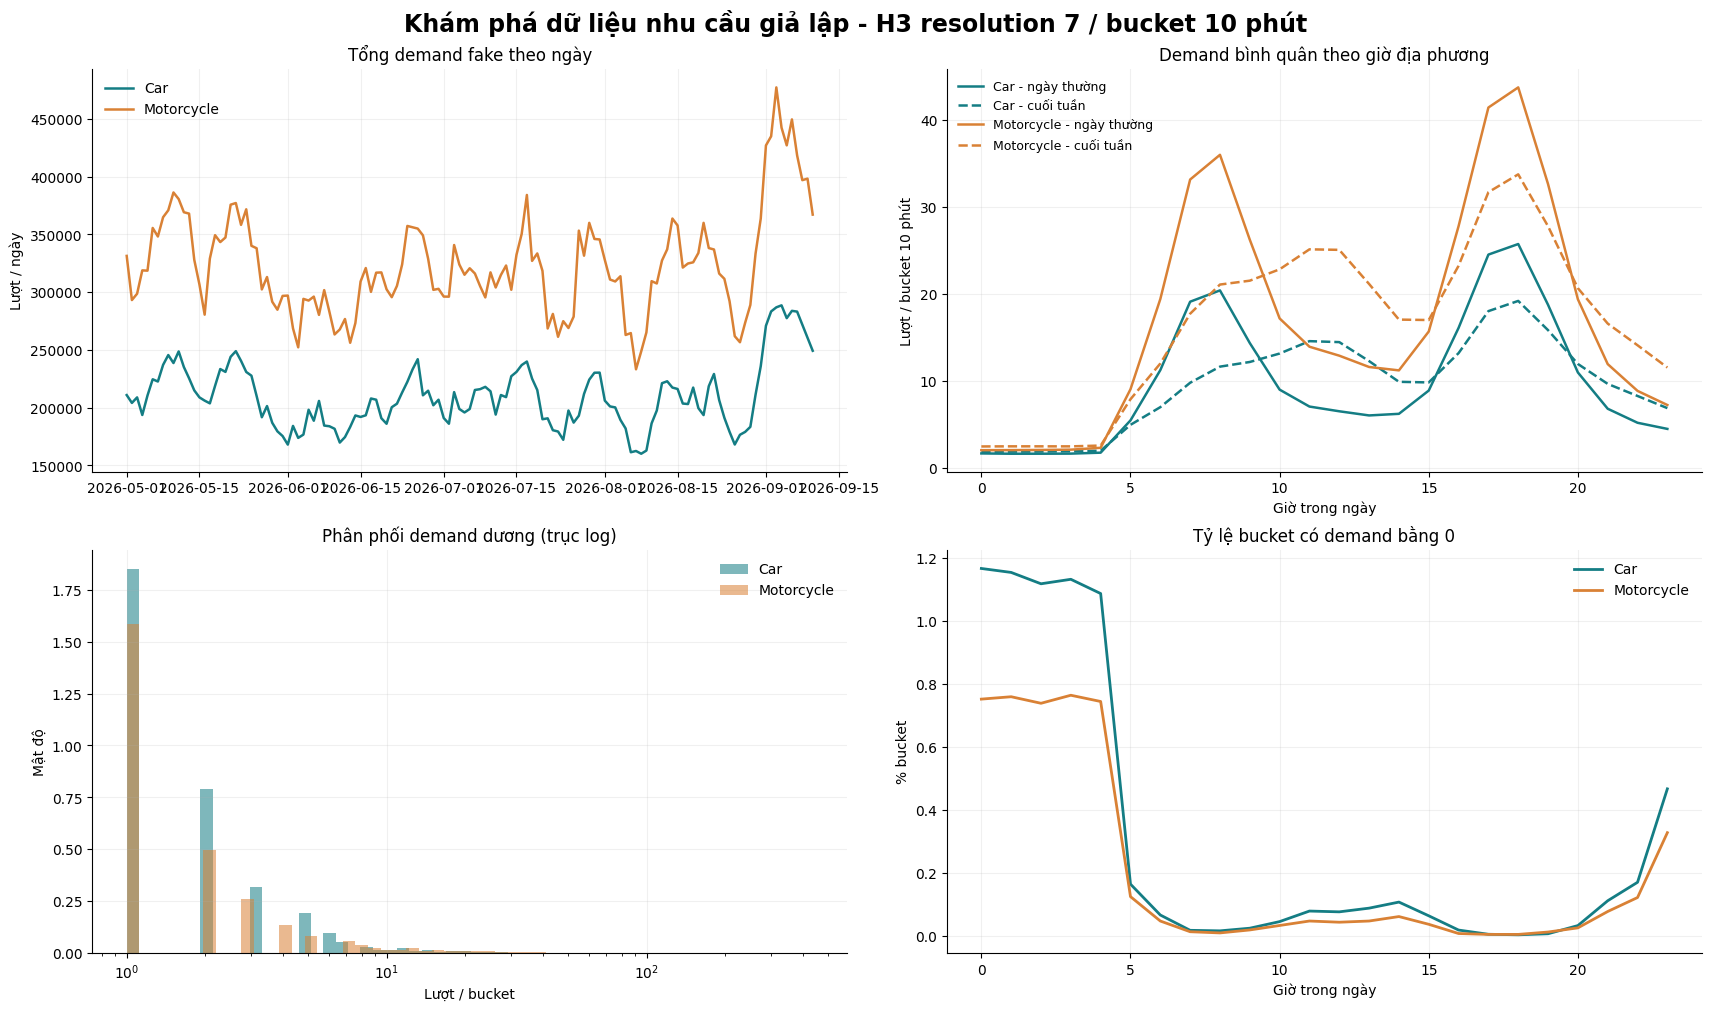

In [15]:
# Trực quan dữ liệu fake: chạy sau cell đọc và sắp xếp dữ liệu.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_fake_view = df[["bucket_start", "travel_mode", "demand_h10"]]
FAKE_DATA_SUMMARY = (
    _fake_view.groupby("travel_mode", observed=True)["demand_h10"]
    .agg(
        rows="size",
        mean="mean",
        median="median",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        zeros=lambda x: (x == 0).sum(),
        maximum="max",
    )
    .reset_index()
)
FAKE_DATA_SUMMARY["zero_%"] = (
    100 * FAKE_DATA_SUMMARY["zeros"] / FAKE_DATA_SUMMARY["rows"]
)
print("Số dòng, mức demand và tỷ lệ demand bằng 0 theo phương tiện:")
display(FAKE_DATA_SUMMARY.round(2))

_day_total = (
    _fake_view.assign(date=_fake_view.bucket_start.dt.floor("D"))
    .groupby(["date", "travel_mode"], observed=True)
    .demand_h10.sum()
    .unstack()
)
_hourly = (
    _fake_view.assign(
        hour=_fake_view.bucket_start.dt.hour,
        weekend=_fake_view.bucket_start.dt.dayofweek >= 5,
    )
    .groupby(["travel_mode", "weekend", "hour"], observed=True)
    .demand_h10.mean()
    .reset_index()
)
_night_zero = (
    _fake_view.assign(
        hour=_fake_view.bucket_start.dt.hour, zero=_fake_view.demand_h10.eq(0)
    )
    .groupby(["travel_mode", "hour"], observed=True)
    .zero.mean()
    .reset_index()
)

plt.rcParams["font.family"] = "DejaVu Sans"
_colors = {"Car": "#147D84", "Motorcycle": "#D98135"}
fig, axes = plt.subplots(2, 2, figsize=(17, 10), constrained_layout=True)
for mode in _day_total.columns:
    axes[0, 0].plot(
        _day_total.index, _day_total[mode], color=_colors.get(mode), label=mode, lw=1.8
    )
axes[0, 0].set(title="Tổng demand fake theo ngày", ylabel="Lượt / ngày")
axes[0, 0].legend(frameon=False)
for mode in _fake_view.travel_mode.unique():
    for is_weekend, line in [(False, "-"), (True, "--")]:
        v = _hourly[(_hourly.travel_mode == mode) & (_hourly.weekend == is_weekend)]
        axes[0, 1].plot(
            v.hour,
            v.demand_h10,
            ls=line,
            lw=1.8,
            color=_colors.get(mode),
            label=f"{mode} - {'cuối tuần' if is_weekend else 'ngày thường'}",
        )
axes[0, 1].set(
    title="Demand bình quân theo giờ địa phương",
    xlabel="Giờ trong ngày",
    ylabel="Lượt / bucket 10 phút",
)
axes[0, 1].legend(frameon=False, fontsize=9)
for mode, group in _fake_view.groupby("travel_mode", observed=True):
    sample = group.demand_h10.sample(n=min(len(group), 90_000), random_state=20260916)
    axes[1, 0].hist(
        sample,
        bins=np.geomspace(1, max(10, sample.max()) + 1, 55),
        color=_colors.get(mode),
        alpha=0.55,
        label=mode,
        density=True,
    )
axes[1, 0].set_xscale("log")
axes[1, 0].set(
    title="Phân phối demand dương (trục log)", xlabel="Lượt / bucket", ylabel="Mật độ"
)
axes[1, 0].legend(frameon=False)
for mode, group in _night_zero.groupby("travel_mode", observed=True):
    axes[1, 1].plot(
        group.hour, 100 * group.zero, lw=2, color=_colors.get(mode), label=mode
    )
axes[1, 1].set(
    title="Tỷ lệ bucket có demand bằng 0", xlabel="Giờ trong ngày", ylabel="% bucket"
)
axes[1, 1].legend(frameon=False)
for ax in axes.flat:
    ax.grid(alpha=0.18)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(
    "Khám phá dữ liệu nhu cầu giả lập - H3 resolution 7 / bucket 10 phút",
    fontsize=17,
    fontweight="bold",
)
plt.show()


**Nhận xét từ dữ liệu đã chạy.** Có 5.404.530 record ở 217 ô H3 và hai loại xe. Motorcycle có demand trung bình 16,96, Car 9,75 lượt/bucket. Giờ 0–4 thấp rõ rệt; hai đỉnh trong ngày và khác biệt ngày thường/cuối tuần giải thích vì sao nhóm feature thời gian cần được thử. Dữ liệu được sinh giả lập nên các dạng này chưa chứng minh hành vi ngoài thực tế.

### 2.2. Bản đồ H3 và demand theo không gian


Số quan sát và mức demand theo vùng GIẢ LẬP (trung bình trên các bucket đã quan sát):


,synthetic_zone,travel_mode,rows,mean
0,airport,Car,259200,19.72
1,airport,Motorcycle,222624,33.73
2,central,Car,244080,28.83
3,central,Motorcycle,227664,51.47
4,east,Car,299088,8.33
5,east,Motorcycle,254736,15.64
6,outer,Car,1595654,3.63
7,outer,Motorcycle,1429420,5.85
8,south,Car,246240,14.25
9,south,Motorcycle,211248,25.83


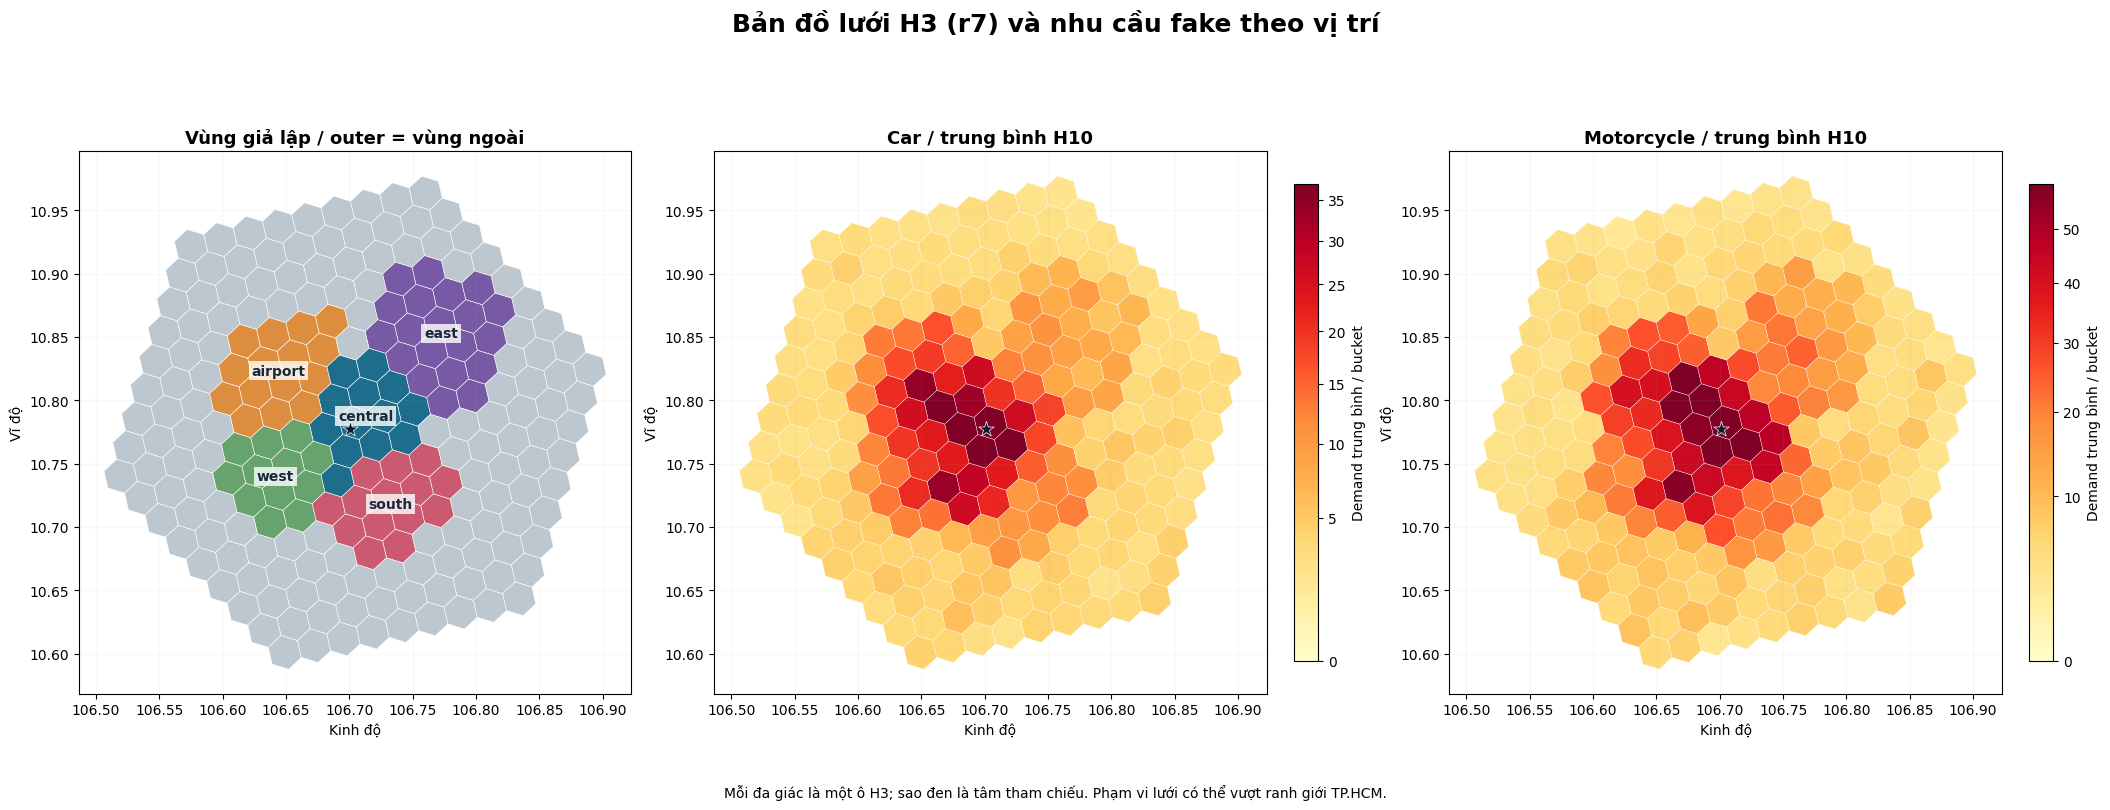

In [16]:
# Bản đồ địa lý H3: các vùng là nhãn giả lập của bộ sinh, không phải ranh giới hành chính.
import h3
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import PowerNorm

_hex = (
    HEX_METADATA[["hex_id_7", "center_lat", "center_lng", "synthetic_zone"]]
    .drop_duplicates("hex_id_7")
    .copy()
)
_hex["hex_id_7"] = _hex.hex_id_7.astype(str)
_hex_totals = (
    df.groupby(["hex_id_7", "travel_mode"], observed=True)
    .demand_h10.agg(rows="size", demand_sum="sum")
    .reset_index()
)
_hex_totals["hex_id_7"] = _hex_totals.hex_id_7.astype(str)
_mean = _hex_totals.assign(mean=_hex_totals.demand_sum / _hex_totals.rows)
_mean = _mean.pivot(
    index="hex_id_7", columns="travel_mode", values="mean"
).reset_index()
HEX_MAP_DATA = _hex.merge(_mean, how="left", on="hex_id_7", validate="one_to_one")
ZONE_SUMMARY = (
    _hex_totals.merge(
        _hex[["hex_id_7", "synthetic_zone"]], on="hex_id_7", validate="many_to_one"
    )
    .groupby(["synthetic_zone", "travel_mode"], observed=True)[["rows", "demand_sum"]]
    .sum()
    .reset_index()
)
ZONE_SUMMARY["mean"] = ZONE_SUMMARY.demand_sum / ZONE_SUMMARY.rows
ZONE_SUMMARY = ZONE_SUMMARY[["synthetic_zone", "travel_mode", "rows", "mean"]]
print(
    "Số quan sát và mức demand theo vùng GIẢ LẬP (trung bình trên các bucket đã quan sát):"
)
display(ZONE_SUMMARY.round(2))

_zone_colors = {
    "central": "#1C6E8C",
    "airport": "#DD8D3E",
    "east": "#7859A6",
    "west": "#67A36C",
    "south": "#CB5A70",
    "outer": "#BDC7CF",
}
_poly = [
    Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)], closed=True)
    for cell in HEX_MAP_DATA.hex_id_7
]
fig, axs = plt.subplots(1, 3, figsize=(21, 8), constrained_layout=True)
_zone_face = [_zone_colors.get(zone, "#CCCCCC") for zone in HEX_MAP_DATA.synthetic_zone]
for ax, mode in zip(axs, ["Vùng giả lập", "Car", "Motorcycle"]):
    if mode == "Vùng giả lập":
        collection = PatchCollection(
            _poly, facecolors=_zone_face, edgecolors="#FFFFFF", linewidths=0.4
        )
        ax.add_collection(collection)
        for zone in ("central", "airport", "east", "west", "south"):
            center = HEX_MAP_DATA.loc[
                HEX_MAP_DATA.synthetic_zone == zone, ["center_lng", "center_lat"]
            ].mean()
            ax.text(
                center.center_lng,
                center.center_lat,
                zone,
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="#172A3A",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
            )
        ax.set_title(mode + " / outer = vùng ngoài", fontsize=13, fontweight="bold")
    else:
        values = HEX_MAP_DATA[mode].to_numpy(dtype=float)
        norm = PowerNorm(0.6, vmin=0, vmax=np.nanpercentile(values, 98))
        collection = PatchCollection(
            _poly, cmap="YlOrRd", norm=norm, edgecolors="#FFFFFF", linewidths=0.25
        )
        collection.set_array(values)
        ax.add_collection(collection)
        fig.colorbar(collection, ax=ax, shrink=0.63, label="Demand trung bình / bucket")
        ax.set_title(mode + " / trung bình H10", fontsize=13, fontweight="bold")
    ax.scatter(
        [106.7009],
        [10.7769],
        marker="*",
        s=135,
        c="#101C30",
        edgecolors="white",
        linewidths=0.5,
        zorder=5,
    )
    ax.autoscale_view()
    ax.set_aspect("equal", adjustable="box")
    ax.set(xlabel="Kinh độ", ylabel="Vĩ độ")
    ax.grid(alpha=0.08)
fig.suptitle(
    "Bản đồ lưới H3 (r7) và nhu cầu fake theo vị trí", fontsize=18, fontweight="bold"
)
fig.text(
    0.5,
    0.01,
    "Mỗi đa giác là một ô H3; sao đen là tâm tham chiếu. Phạm vi lưới có thể vượt ranh giới TP.HCM.",
    ha="center",
    fontsize=10,
)
plt.show()


**Đọc bản đồ.** Mỗi đa giác là một ô H3 resolution 7; màu vùng `central`, `airport`, `east`, `west`, `south`, `outer` lấy từ bộ sinh fake data. Vùng `outer` bao phủ phần còn lại của lưới; đây không phải địa giới hành chính TP.HCM. Các ô ở trung tâm có demand bình quân cao hơn ô ngoài, nên `hex_code` có cơ sở để được kiểm tra bằng ablation.

## 3. Feature gốc


### 3.1. Định danh, lịch, lag và thống kê gần


#### FEATURE 1: hex_code

In [17]:
# FEATURE 1: hex_code
#
# Mục đích:
#   Chuyển mã H3 dạng string thành số integer.
#
# Ví dụ:
#   8765b1904fffffff -> 0
#   8765b1905fffffff -> 1
#
# Tree model có thể dùng giá trị này để phân biệt khu vực.

df["hex_id_7"] = df["hex_id_7"].astype("category")

df["hex_code"] = df["hex_id_7"].cat.codes.astype("int16")

display(df[["hex_id_7", "hex_code"]].drop_duplicates().head(10))


,hex_id_7,hex_code
0,8765b1904ffffff,0
10368,8765b1906ffffff,1
20448,8765b1910ffffff,2
31248,8765b1912ffffff,3
41616,8765b1914ffffff,4
51984,8765b1915ffffff,5
62208,8765b1916ffffff,6
72720,8765b1920ffffff,7
82512,8765b1922ffffff,8
92592,8765b1923ffffff,9


#### FEATURE 2: slot_10m

In [18]:
(24 * 60) / 10 - 1


143.0

In [19]:
# FEATURE 2: slot_10m
#
# Mục đích:
#   Cho model biết vị trí của bucket trong ngày.
#
# Range:
#   0 -> 143

df["slot_10m"] = (
    df["bucket_start"].dt.hour * 6 + df["bucket_start"].dt.minute // 10
).astype("int16")

display(df[["bucket_start", "slot_10m"]].head(20))


,bucket_start,slot_10m
0,2026-05-01 00:00:00+07:00,0
1,2026-05-01 00:10:00+07:00,1
2,2026-05-01 00:20:00+07:00,2
3,2026-05-01 00:30:00+07:00,3
4,2026-05-01 00:40:00+07:00,4
5,2026-05-01 00:50:00+07:00,5
6,2026-05-01 01:00:00+07:00,6
7,2026-05-01 01:10:00+07:00,7
8,2026-05-01 01:20:00+07:00,8
9,2026-05-01 01:30:00+07:00,9


#### FEATURE 3: day_of_week

In [20]:
# FEATURE 3: day_of_week
#
# Thứ trong tuần:
#
# 0 = Monday
# 1 = Tuesday
# 2 = Wednesday
# 3 = Thursday
# 4 = Friday
# 5 = Saturday
# 6 = Sunday
#
# Demand có thể khác nhau giữa các ngày trong tuần.

df["day_of_week"] = df["bucket_start"].dt.dayofweek.astype("int8")

display(df[["bucket_start", "day_of_week"]].sample(10))


,bucket_start,day_of_week
4272280,2026-08-03 03:40:00+07:00,0
72977,2026-05-02 18:50:00+07:00,5
1158158,2026-07-15 20:00:00+07:00,2
4523998,2026-06-12 04:40:00+07:00,4
4499820,2026-08-28 07:00:00+07:00,4
789168,2026-07-05 08:00:00+07:00,6
2009443,2026-07-15 12:50:00+07:00,2
4743333,2026-06-12 08:30:00+07:00,4
695356,2026-07-01 20:40:00+07:00,2
1761850,2026-08-31 03:20:00+07:00,0


#### FEATURE 4: is_weekend

In [21]:
#  FEATURE 4: is_weekend
#
# 0 = ngày thường
# 1 = thứ 7 hoặc chủ nhật
#
# Dùng để giúp model phân biệt pattern weekday/weekend.

df["is_weekend"] = (df["day_of_week"] >= 5).astype("int8")

display(df[["bucket_start", "day_of_week", "is_weekend"]].drop_duplicates().sample(10))


,bucket_start,day_of_week,is_weekend
9255,2026-09-03 06:30:00+07:00,3,0
4857,2026-06-03 17:30:00+07:00,2,0
16421,2026-08-14 00:50:00+07:00,4,0
25078,2026-07-04 03:40:00+07:00,5,1
8508,2026-08-29 02:00:00+07:00,5,1
2999,2026-05-21 19:50:00+07:00,3,0
15471,2026-08-07 10:30:00+07:00,4,0
8165,2026-08-26 16:50:00+07:00,2,0
23568,2026-06-23 16:00:00+07:00,1,0
17303,2026-08-20 03:50:00+07:00,3,0


#### FEATURE 5: is_holiday

In [22]:
# FEATURE 5: is_holiday
#
# 0 = ngày bình thường
# 1 = ngày lễ
#
# holiday_name chỉ dùng để visualize/debug,
# KHÔNG đưa trực tiếp vào model.

df["local_date"] = df["bucket_start"].dt.date

df["is_holiday"] = df["local_date"].isin(VN_HOLIDAYS.keys()).astype("int8")

df["holiday_name"] = (
    df["local_date"].map(lambda d: VN_HOLIDAYS.get(d, "")).astype("string")
)

display(
    df[["bucket_start", "local_date", "is_holiday", "holiday_name"]][
        df["is_holiday"] == 1
    ].head(10)
)


,bucket_start,local_date,is_holiday,holiday_name
0,2026-05-01 00:00:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
1,2026-05-01 00:10:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
2,2026-05-01 00:20:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
3,2026-05-01 00:30:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
4,2026-05-01 00:40:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
5,2026-05-01 00:50:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
6,2026-05-01 01:00:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
7,2026-05-01 01:10:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
8,2026-05-01 01:20:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động
9,2026-05-01 01:30:00+07:00,2026-05-01,1,Ngày Quốc tế Lao động


### 3.2. Chuẩn bị exact-lag lookup

In [23]:
# PREPARE EXACT-LAG LOOKUP
#
# Tạo index:
#
# travel_mode + hex_id_7 + timestamp
#
# để tìm demand chính xác tại:
#
# T - 30 phút
# T - 40 phút
# ...
#
# Không dùng shift đơn thuần vì nếu thiếu bucket,
# shift có thể lấy nhầm thời điểm.

history_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"]],
    names=["travel_mode", "hex_id_7", "bucket_start"],
)

history = pd.Series(df["demand_h10"].to_numpy(), index=history_index)

assert history.index.is_unique

print("History rows:", len(history))


History rows: 5404530


#### FEATURE 6: lag_30m

In [24]:
#  FEATURE 6: lag_30m
#
# Demand của cùng:
#   travel_mode
#   hex
#
# tại thời điểm T - 30 phút.
#
# Đây là lag gần quan trọng nhất trong model hiện tại.

lookup_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"] - pd.Timedelta(minutes=30)]
)

df["lag_30m"] = history.reindex(lookup_index).to_numpy().astype("float32")

display(df[["bucket_start", "demand_h10", "lag_30m"]].head(20))


,bucket_start,demand_h10,lag_30m
0,2026-05-01 00:00:00+07:00,1,NaN
1,2026-05-01 00:10:00+07:00,1,NaN
2,2026-05-01 00:20:00+07:00,1,NaN
3,2026-05-01 00:30:00+07:00,1,1.0
4,2026-05-01 00:40:00+07:00,1,1.0
5,2026-05-01 00:50:00+07:00,1,1.0
6,2026-05-01 01:00:00+07:00,1,1.0
7,2026-05-01 01:10:00+07:00,1,1.0
8,2026-05-01 01:20:00+07:00,1,1.0
9,2026-05-01 01:30:00+07:00,1,1.0


#### FEATURE 7: lag_40m

In [25]:
# FEATURE 7: lag_40m
#
# Demand tại T - 40 phút.

lookup_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"] - pd.Timedelta(minutes=40)]
)

df["lag_40m"] = history.reindex(lookup_index).to_numpy().astype("float32")
display(df[["bucket_start", "demand_h10", "lag_40m"]].head(20))


,bucket_start,demand_h10,lag_40m
0,2026-05-01 00:00:00+07:00,1,NaN
1,2026-05-01 00:10:00+07:00,1,NaN
2,2026-05-01 00:20:00+07:00,1,NaN
3,2026-05-01 00:30:00+07:00,1,NaN
4,2026-05-01 00:40:00+07:00,1,1.0
5,2026-05-01 00:50:00+07:00,1,1.0
6,2026-05-01 01:00:00+07:00,1,1.0
7,2026-05-01 01:10:00+07:00,1,1.0
8,2026-05-01 01:20:00+07:00,1,1.0
9,2026-05-01 01:30:00+07:00,1,1.0


#### FEATURE 8: lag_50m

In [26]:
# FEATURE 8: lag_50m
#
# Demand tại T - 50 phút.

lookup_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"] - pd.Timedelta(minutes=50)]
)

df["lag_50m"] = history.reindex(lookup_index).to_numpy().astype("float32")


#### FEATURE 9: lag_60m

In [27]:
#  FEATURE 9: lag_60m
#
# Demand tại T - 60 phút.
#
# Dùng cùng lag_30m để xác định trend demand gần đây.

lookup_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"] - pd.Timedelta(minutes=60)]
)

df["lag_60m"] = history.reindex(lookup_index).to_numpy().astype("float32")


#### FEATURE 10: lag_90m

In [28]:
# FEATURE 10: lag_90m
#
# Demand cách thời điểm hiện tại 1 giờ 30 phút.

lookup_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"] - pd.Timedelta(minutes=90)]
)

df["lag_90m"] = history.reindex(lookup_index).to_numpy().astype("float32")


#### FEATURE 11: lag_120m

In [29]:
#  FEATURE 11: lag_120m
#
# Demand tại T - 2 giờ.

lookup_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"] - pd.Timedelta(minutes=120)]
)

df["lag_120m"] = history.reindex(lookup_index).to_numpy().astype("float32")


#### FEATURE 12: lag_1d

In [30]:
# FEATURE 12: lag_1d
#
# Demand của:
#   cùng hex
#   cùng travel mode
#   cùng thời điểm
#
# của ngày hôm trước.
#
# Ví dụ:
#   target hôm nay 08:00
#   -> lấy demand hôm qua 08:00.

lookup_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"] - pd.Timedelta(days=1)]
)

df["lag_1d"] = history.reindex(lookup_index).to_numpy().astype("float32")
display(df[["bucket_start", "demand_h10", "lag_1d"]][df["lag_1d"].notna()].head(20))


,bucket_start,demand_h10,lag_1d
144,2026-05-02 00:00:00+07:00,1,1.0
145,2026-05-02 00:10:00+07:00,1,1.0
146,2026-05-02 00:20:00+07:00,1,1.0
147,2026-05-02 00:30:00+07:00,1,1.0
148,2026-05-02 00:40:00+07:00,1,1.0
149,2026-05-02 00:50:00+07:00,1,1.0
150,2026-05-02 01:00:00+07:00,1,1.0
151,2026-05-02 01:10:00+07:00,1,1.0
152,2026-05-02 01:20:00+07:00,1,1.0
153,2026-05-02 01:30:00+07:00,1,1.0


#### FEATURE 13: lag_7d

In [31]:
#  FEATURE 13: lag_7d
#
# Demand cùng giờ, cùng hex, cùng mode
# nhưng ở tuần trước.
#
# Feature này giúp bắt weekly seasonality.
#
# Ví dụ:
#   Monday 08:00
#           ↓
#   Monday tuần trước 08:00

lookup_index = pd.MultiIndex.from_arrays(
    [df["travel_mode"], df["hex_id_7"], df["bucket_start"] - pd.Timedelta(days=7)]
)

df["lag_7d"] = history.reindex(lookup_index).to_numpy().astype("float32")


#### FEATURE 14: recent_mean_30_60m

In [32]:
#  FEATURE 14: recent_mean_30_60m
#
# Trung bình demand của:
#
# T-30
# T-40
# T-50
# T-60
#
# Mục đích:
#   biểu diễn mức demand trung bình gần đây,
#   ổn định hơn việc chỉ nhìn một lag duy nhất.

recent_columns = ["lag_30m", "lag_40m", "lag_50m", "lag_60m"]

df["recent_mean_30_60m"] = df[recent_columns].mean(axis=1).astype("float32")

display(df[recent_columns + ["recent_mean_30_60m"]].head())


,lag_30m,lag_40m,lag_50m,lag_60m,recent_mean_30_60m
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,1.0,NaN,NaN,NaN,1.0
4,1.0,1.0,NaN,NaN,1.0


#### FEATURE 15: recent_std_30_60m

In [33]:
# FEATURE 15: recent_std_30_60m
#
# Độ lệch chuẩn của demand từ T-60 -> T-30.
#
# Std thấp:
#   demand khá ổn định.
#
# Std cao:
#   demand đang biến động mạnh.
#
# Giúp model nhận biết volatility.

df["recent_std_30_60m"] = (
    df[["lag_30m", "lag_40m", "lag_50m", "lag_60m"]]
    .std(axis=1, ddof=0)
    .astype("float32")
)

display(df[["lag_30m", "lag_40m", "lag_50m", "lag_60m", "recent_std_30_60m"]].head())


,lag_30m,lag_40m,lag_50m,lag_60m,recent_std_30_60m
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,1.0,NaN,NaN,NaN,0.0
4,1.0,1.0,NaN,NaN,0.0


#### FEATURE 16: recent_trend

In [34]:
# FEATURE 16: recent_trend
#
# Công thức:
#
#   lag_30m - lag_60m
#
# > 0:
#   demand gần đây đang tăng.
#
# < 0:
#   demand gần đây đang giảm.
#
# = 0:
#   demand tương đối ổn định.

df["recent_trend"] = (df["lag_30m"] - df["lag_60m"]).astype("float32")

display(df[["lag_60m", "lag_30m", "recent_trend"]].head(20))


,lag_60m,lag_30m,recent_trend
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,1.0,NaN
4,NaN,1.0,NaN
5,NaN,1.0,NaN
6,1.0,1.0,0.0
7,1.0,1.0,0.0
8,1.0,1.0,0.0
9,1.0,1.0,0.0


#### FEATURE 17: hour_sin

In [35]:
# FEATURE 17: hour_sin
#
# Biến đổi giờ trong ngày thành dạng tuần hoàn.
#
# Dùng cùng hour_cos.

hour = df["bucket_start"].dt.hour + df["bucket_start"].dt.minute / 60

df["hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")

display(df[["bucket_start", "hour_sin"]].head())


,bucket_start,hour_sin
0,2026-05-01 00:00:00+07:00,0.000000
1,2026-05-01 00:10:00+07:00,0.043619
2,2026-05-01 00:20:00+07:00,0.087156
3,2026-05-01 00:30:00+07:00,0.130526
4,2026-05-01 00:40:00+07:00,0.173648


#### FEATURE 18: hour_cos

In [36]:
# FEATURE 18: hour_cos
#
# Đi cùng hour_sin để biểu diễn đầy đủ chu kỳ 24 giờ.

hour = df["bucket_start"].dt.hour + df["bucket_start"].dt.minute / 60

df["hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")

display(df[["bucket_start", "hour_sin", "hour_cos"]].head())


,bucket_start,hour_sin,hour_cos
0,2026-05-01 00:00:00+07:00,0.000000,1.000000
1,2026-05-01 00:10:00+07:00,0.043619,0.999048
2,2026-05-01 00:20:00+07:00,0.087156,0.996195
3,2026-05-01 00:30:00+07:00,0.130526,0.991445
4,2026-05-01 00:40:00+07:00,0.173648,0.984808


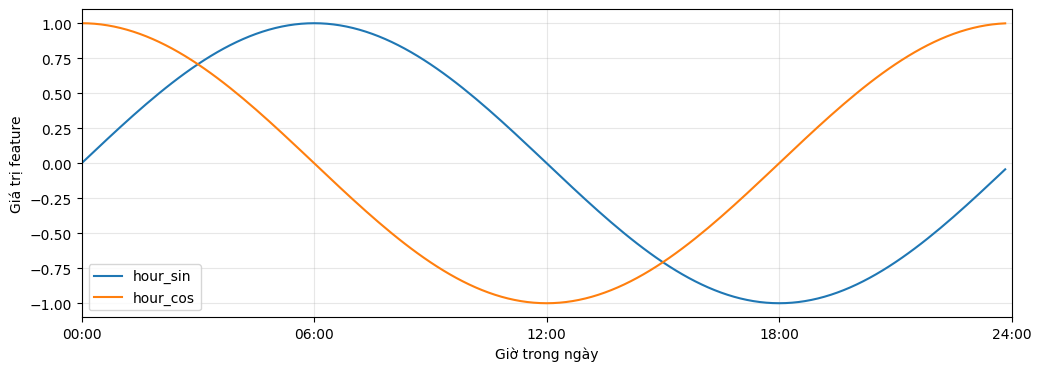

In [37]:
import matplotlib.pyplot as plt

# Lấy một ngày để tránh vẽ chồng dữ liệu của nhiều ngày và nhiều hex
start = df["bucket_start"].min().normalize()

plot_df = (
    df.loc[
        (df["bucket_start"] >= start)
        & (df["bucket_start"] < start + pd.Timedelta(days=1)),
        ["bucket_start", "hour_sin", "hour_cos"],
    ]
    .drop_duplicates("bucket_start")
    .sort_values("bucket_start")
)

# Chỉ chuyển thời gian sang số giờ để làm trục X
x = plot_df["bucket_start"].dt.hour + plot_df["bucket_start"].dt.minute / 60

plt.figure(figsize=(12, 4))
plt.plot(x, plot_df["hour_sin"], label="hour_sin")
plt.plot(x, plot_df["hour_cos"], label="hour_cos")

plt.xticks([0, 6, 12, 18, 24], ["00:00", "06:00", "12:00", "18:00", "24:00"])
plt.xlim(0, 24)
plt.ylim(-1.1, 1.1)
plt.xlabel("Giờ trong ngày")
plt.ylabel("Giá trị feature")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


#### FEATURE 19: dow_sin


In [38]:
#  FEATURE 19: dow_sin
#
# Biến đổi thứ trong tuần thành cyclic feature.
#
# Sunday và Monday vì vậy được hiểu là gần nhau
# trong chu kỳ tuần.

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7).astype("float32")


#### FEATURE 20: dow_cos

In [39]:
# FEATURE 20: dow_cos
#
# Đi cùng dow_sin để biểu diễn chu kỳ 7 ngày.

df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7).astype("float32")


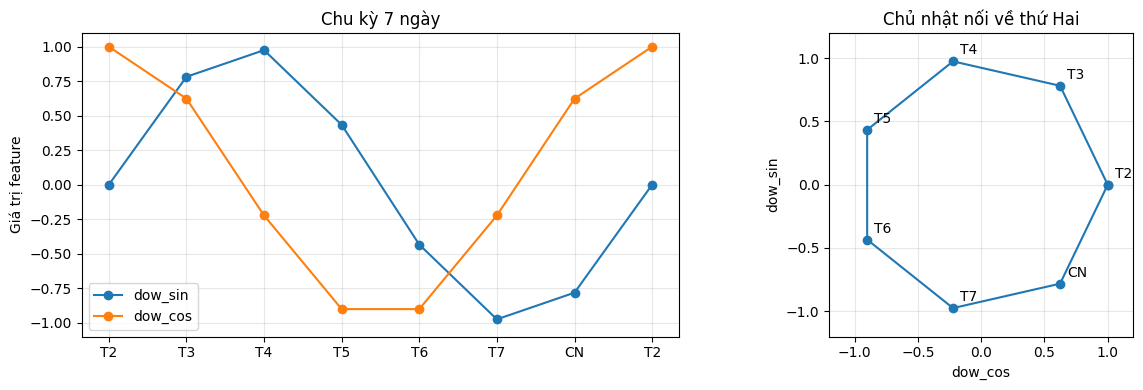

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

week = (
    df[["day_of_week", "dow_sin", "dow_cos"]]
    .drop_duplicates("day_of_week")
    .sort_values("day_of_week")
    .reset_index(drop=True)
)

# Lặp lại điểm thứ Hai ở cuối chỉ để vẽ khép kín chu kỳ
closed_week = pd.concat([week, week.iloc[[0]]], ignore_index=True)

day_labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN", "T2"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Hình 1: Giá trị sin/cos qua các ngày
ax1.plot(range(8), closed_week["dow_sin"], marker="o", label="dow_sin")
ax1.plot(range(8), closed_week["dow_cos"], marker="o", label="dow_cos")
ax1.set_xticks(range(8), day_labels)
ax1.set_ylim(-1.1, 1.1)
ax1.set_title("Chu kỳ 7 ngày")
ax1.set_ylabel("Giá trị feature")
ax1.grid(alpha=0.3)
ax1.legend()

# Hình 2: Cặp (cos, sin) tạo thành vòng tròn
ax2.plot(closed_week["dow_cos"], closed_week["dow_sin"], marker="o")

for row in week.itertuples(index=False):
    ax2.annotate(
        day_labels[row.day_of_week],
        (row.dow_cos, row.dow_sin),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax2.set_aspect("equal")
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel("dow_cos")
ax2.set_ylabel("dow_sin")
ax2.set_title("Chủ nhật nối về thứ Hai")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### FEATURE 21: trend_day

In [41]:
# FEATURE 21: trend_day
#
# Số ngày tính từ ngày đầu dataset.
#
# Ví dụ:
#
# ngày đầu tiên -> 0
# ngày tiếp theo -> 1
# ...
#
# Feature này giúp model nhận biết xu hướng dài hạn.

LOCAL_START = df["bucket_start"].min()

df["trend_day"] = (
    (df["bucket_start"] - LOCAL_START).dt.total_seconds().div(86_400).astype("float32")
)

display(df[["bucket_start", "trend_day"]].head())


,bucket_start,trend_day
0,2026-05-01 00:00:00+07:00,0.000000
1,2026-05-01 00:10:00+07:00,0.006944
2,2026-05-01 00:20:00+07:00,0.013889
3,2026-05-01 00:30:00+07:00,0.020833
4,2026-05-01 00:40:00+07:00,0.027778


### 3.3. Loại dòng chưa có lịch sử

In [42]:
# DROP ROW CHƯA CÓ LỊCH SỬ
#
# Nếu chưa có lag_30m thì chưa đủ thông tin gần nhất
# để đưa vào model.

print("Rows trước:", len(df))

df = df[df["lag_30m"].notna()].copy().reset_index(drop=True)

print("Rows sau:", len(df))


Rows trước: 5404530
Rows sau: 5402493


### 3.4. Danh sách feature

In [43]:
# FEATURE LIST
#
# Đây chính là các cột sẽ được đưa vào X_train / X_test.

FEATURES = [
    # Spatial
    "hex_code",
    # Calendar / Time
    "slot_10m",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    # Cyclic time
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    # Long-term trend
    "trend_day",
    # Demand lag
    "lag_30m",
    "lag_40m",
    "lag_50m",
    "lag_60m",
    "lag_90m",
    "lag_120m",
    "lag_1d",
    "lag_7d",
    # Recent demand statistics
    "recent_mean_30_60m",
    "recent_std_30_60m",
    "recent_trend",
]

print("Số feature:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:02d}. {feature}")


Số feature: 21
01. hex_code
02. slot_10m
03. day_of_week
04. is_weekend
05. is_holiday
06. hour_sin
07. hour_cos
08. dow_sin
09. dow_cos
10. trend_day
11. lag_30m
12. lag_40m
13. lag_50m
14. lag_60m
15. lag_90m
16. lag_120m
17. lag_1d
18. lag_7d
19. recent_mean_30_60m
20. recent_std_30_60m
21. recent_trend


## 4. H10 — chia dữ liệu, train và so sánh model

In [44]:
df_all = df.copy()

MODE_FRAMES = {}

for mode, mode_df in df_all.groupby("travel_mode", observed=True, sort=False):
    mode_df = (
        mode_df.copy()
        .sort_values(["hex_id_7", "bucket_start"], kind="stable")
        .reset_index(drop=True)
    )

    MODE_FRAMES[str(mode)] = mode_df


print("MODE_FRAMES:", MODE_FRAMES.keys())

for mode, mode_df in MODE_FRAMES.items():
    print(
        mode,
        "| rows =",
        f"{len(mode_df):,}",
        "| modes =",
        mode_df["travel_mode"].unique(),
    )
# TRAIN | VALIDATION 30 NGÀY | TEST
# Mốc chung cho mọi mode và horizon direct.
TRAIN_RATIO = 0.80
VALIDATION_DAYS = 30
unique_split_times = (
    df_all["bucket_start"].drop_duplicates().sort_values().reset_index(drop=True)
)
test_position = min(
    max(int(len(unique_split_times) * TRAIN_RATIO), 1),
    len(unique_split_times) - 1,
)
TEST_START = unique_split_times.iloc[test_position]
VAL_START = TEST_START - pd.Timedelta(days=VALIDATION_DAYS)
if not unique_split_times.iloc[0] < VAL_START < TEST_START:
    raise ValueError("Không đủ dữ liệu trước 30 ngày validation")


def make_time_split(frame, horizon_minutes):
    ts = frame["bucket_start"]
    target_end = ts + pd.Timedelta(minutes=horizon_minutes)
    train = (ts < VAL_START) & (target_end <= VAL_START)
    val = (ts >= VAL_START) & (ts < TEST_START) & (target_end <= TEST_START)
    test = ts >= TEST_START
    train_index = np.flatnonzero(train.to_numpy())
    val_index = np.flatnonzero(val.to_numpy())
    test_index = np.flatnonzero(test.to_numpy())
    train_val_index = np.flatnonzero((train | val).to_numpy())
    purged = len(frame) - len(train_index) - len(val_index) - len(test_index)
    if min(len(train_index), len(val_index), len(test_index)) == 0:
        raise ValueError(f"H{horizon_minutes}: train/val/test rỗng")
    assert target_end.iloc[train_index].max() <= VAL_START
    assert target_end.iloc[val_index].max() <= TEST_START
    assert ts.iloc[val_index].min() >= VAL_START
    assert ts.iloc[test_index].min() >= TEST_START
    return {
        "train_index": train_index,
        "val_index": val_index,
        "train_val_index": train_val_index,
        "test_index": test_index,
        "val_start": VAL_START,
        "test_start": TEST_START,
        "purged_rows": purged,
    }


print(
    f"TRAIN < {VAL_START} | VAL [{VAL_START}, {TEST_START}) "
    f"({VALIDATION_DAYS} ngày) | TEST >= {TEST_START}"
)
for mode, frame in MODE_FRAMES.items():
    split = make_time_split(frame, 10)
    print(
        f"{mode} H10 | train={len(split['train_index']):,} "
        f"| val={len(split['val_index']):,} "
        f"| test={len(split['test_index']):,} "
        f"| purged={split['purged_rows']:,}"
    )


MODE_FRAMES: dict_keys(['Car', 'Motorcycle'])
Car | rows = 2,862,686 | modes = ['Car']
Motorcycle | rows = 2,539,807 | modes = ['Motorcycle']
TRAIN < 2026-07-16 09:40:00+07:00 | VAL [2026-07-16 09:40:00+07:00, 2026-08-15 09:40:00+07:00) (30 ngày) | TEST >= 2026-08-15 09:40:00+07:00
Car H10 | train=1,648,849 | val=646,554 | test=567,283 | purged=0
Motorcycle H10 | train=1,441,586 | val=591,105 | test=507,116 | purged=0


### 4.1. Train / validation 30 ngày / test

Car, Motorcycle và ba model direct H10/H30/H60 dùng cùng hai mốc VAL_START, TEST_START. Test là 20% mốc thời gian cuối; 30 ngày ngay trước test là validation. Target vượt ranh giới train/val hoặc val/test được purge.

Model tạm fit trên train và chọn số vòng trên validation. Sau đó refit model cuối trên train+validation để đánh giá một lần trên test.


### 4.2. HistGBR — chọn độ phức tạp và số vòng


In [45]:
# Chọn độ phức tạp cây theo WMAPE validation riêng cho từng mode/horizon.
# Số cây/số vòng tối ưu được tìm trong mỗi lần thử; test không tham gia chọn.
# Ba giá trị cho mỗi model giữ thời gian tìm kiếm có giới hạn (mỗi lần thử train lại).
HIST_LEAF_CANDIDATES = (63, 130, 255)
XGB_DEPTH_CANDIDATES = (6, 8, 10)
LGB_LEAF_CANDIDATES = (31, 63, 130)
HYPERPARAM_TRIALS = []

# CELL 1 — TRAIN HistGBR CHO T+10
# Chọn max_iter trên validation, in WMAPE TEST

import gc
from time import perf_counter

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

TRAIN_RATIO = 0.80
MAX_TRAIN_ROWS = None

# Giới hạn số vòng được thử. HistGBR chạy trên CPU.
HIST_MAX_ITER_TO_SEARCH = 400


MODELS = {}
TEST_RESULTS = {}
SPLIT_TIMES = {}
FIT_SECONDS = {}
VAL_WMAPE_H10 = {}
VAL_VOLUMES_H10 = {}
TRAIN_INFO = []

HIST_BEST_ITER = {}
HIST_FINAL_PARAMS = {}
HIST_TEST_WMAPE = {}
HIST_SEARCH_SECONDS = {}


def _h10_wmape(actual, prediction):
    actual = np.asarray(actual, dtype=np.float64)
    prediction = np.asarray(prediction, dtype=np.float64)

    valid = np.isfinite(actual) & np.isfinite(prediction)
    actual = actual[valid]
    prediction = prediction[valid]

    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return 100 * np.abs(actual - prediction).sum() / denominator


for mode, mode_df in MODE_FRAMES.items():

    # 1. TRAIN / VAL / TEST — CÙNG MỐC THỜI GIAN

    split = make_time_split(mode_df, 10)
    train_index = split["train_index"]
    val_index = split["val_index"]
    test_index = split["test_index"]
    val_cutoff = split["val_start"]
    cutoff = split["test_start"]

    # 2. GIỚI HẠN TRAIN — GIỮ NGUYÊN CODE GỐC

    fit_index = train_index

    if MAX_TRAIN_ROWS is not None and len(fit_index) > MAX_TRAIN_ROWS:
        rng = np.random.default_rng(SEED)

        fit_index = np.sort(
            rng.choice(
                fit_index,
                size=MAX_TRAIN_ROWS,
                replace=False,
            )
        )

    refit_index = np.sort(np.r_[fit_index, val_index])
    actual_train_ratio = len(fit_index) / len(mode_df)
    print(
        f"{mode} | train={len(fit_index):,} ({actual_train_ratio:.2%}) "
        f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
        f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
        f"| val_start={val_cutoff} | test_start={cutoff}"
    )

    # 3. DỮ LIỆU TRAIN / TEST GỐC

    X_train = mode_df.iloc[refit_index][FEATURES].copy()
    y_train = mode_df.iloc[refit_index]["demand_h10"].copy()
    X_test = mode_df.iloc[test_index][FEATURES].copy()

    test_result = mode_df.iloc[test_index][
        [
            "bucket_start",
            "hex_id_7",
            "is_weekend",
            "demand_h10",
            "lag_30m",
        ]
    ].copy()

    X_early_train = mode_df.iloc[fit_index][FEATURES].copy()
    y_early_train = mode_df.iloc[fit_index]["demand_h10"].copy()
    X_val = mode_df.iloc[val_index][FEATURES].copy()
    y_val = mode_df.iloc[val_index]["demand_h10"].copy()
    val_actual = y_val.to_numpy(dtype=np.float64)

    # 5. TRAIN TẠM, CHỌN VÒNG CÓ WMAPE VALIDATION THẤP NHẤT

    search_params = dict(
        loss="poisson",
        learning_rate=0.05,
        max_iter=HIST_MAX_ITER_TO_SEARCH,
        max_leaf_nodes=130,
        min_samples_leaf=100,
        l2_regularization=2.0,
        max_bins=255,
        categorical_features=[FEATURES.index("hex_code")],
        early_stopping=False,
        random_state=SEED,
    )

    search_model = HistGradientBoostingRegressor(**search_params)

    search_started = perf_counter()

    search_model.fit(X_early_train, y_early_train)

    best_iteration = 0
    best_absolute_error = np.inf

    # Mỗi prediction ứng với một số vòng: 1, 2, ..., 400.
    # Trên cùng validation, WMAPE nhỏ nhất cũng là
    # tổng sai số tuyệt đối nhỏ nhất.
    for iteration, stage_prediction in enumerate(
        search_model.staged_predict(X_val),
        start=1,
    ):
        stage_prediction = np.clip(stage_prediction, 0, None)

        absolute_error = np.abs(val_actual - stage_prediction).sum()

        if absolute_error < best_absolute_error:
            best_absolute_error = absolute_error
            best_iteration = iteration

    # Thử thêm các mức lá; mỗi mức tự chọn số vòng có WMAPE val thấp nhất.
    trials = [
        {
            "complexity": search_params["max_leaf_nodes"],
            "rounds": best_iteration,
            "VAL_WMAPE_%": 100.0 * best_absolute_error / np.abs(val_actual).sum(),
        }
    ]
    for leaf_count in HIST_LEAF_CANDIDATES:
        if leaf_count == search_params["max_leaf_nodes"]:
            continue
        candidate = HistGradientBoostingRegressor(
            **{**search_params, "max_leaf_nodes": leaf_count}
        )
        candidate.fit(X_early_train, y_early_train)
        errors = (
            np.abs(val_actual - np.clip(pred, 0, None)).sum()
            for pred in candidate.staged_predict(X_val)
        )
        candidate_round, candidate_error = min(
            enumerate(errors, start=1), key=lambda pair: pair[1]
        )
        trials.append(
            {
                "complexity": leaf_count,
                "rounds": candidate_round,
                "VAL_WMAPE_%": 100.0 * candidate_error / np.abs(val_actual).sum(),
            }
        )
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_leaf_nodes"] = selected["complexity"]
    best_iteration = selected["rounds"]
    best_absolute_error = selected["VAL_WMAPE_%"] * np.abs(val_actual).sum() / 100.0
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H10", "travel_mode": mode, "model": "HistGBR", **row}
        for row in trials
    )

    search_seconds = perf_counter() - search_started

    VAL_WMAPE_H10.setdefault(mode, {})["HistGBR"] = (
        100.0 * best_absolute_error / np.abs(val_actual).sum()
    )
    VAL_VOLUMES_H10[mode] = float(np.abs(val_actual).sum())
    HIST_BEST_ITER[mode] = best_iteration
    HIST_SEARCH_SECONDS[mode] = search_seconds

    print(
        f"{mode} | max_iter được chọn={best_iteration} | "
        f"thời gian tìm vòng={search_seconds:.1f}s"
    )

    del (
        X_early_train,
        y_early_train,
        X_val,
        y_val,
        val_actual,
        search_model,
    )
    gc.collect()

    # 6. REFIT TRÊN TRAIN + VAL, TEST GIỮ NGUYÊN

    final_params = {
        **search_params,
        "max_iter": best_iteration,
    }

    HIST_FINAL_PARAMS[mode] = final_params.copy()

    print(f"\n{mode} | THAM SỐ HISTGBR MODEL CUỐI:")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = HistGradientBoostingRegressor(**final_params)

    started = perf_counter()
    model.fit(X_train, y_train)
    elapsed = perf_counter() - started

    # 7. DỰ ĐOÁN VÀ IN WMAPE TEST

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    ).astype(np.float32)

    test_result["prediction_HistGBR"] = prediction

    test_wmape = _h10_wmape(
        test_result["demand_h10"],
        test_result["prediction_HistGBR"],
    )

    HIST_TEST_WMAPE[mode] = test_wmape

    MODELS[mode] = {"HistGBR": model}
    FIT_SECONDS[mode] = {"HistGBR": elapsed}
    TEST_RESULTS[mode] = test_result
    SPLIT_TIMES[mode] = split

    TRAIN_INFO.append(
        {
            "travel_mode": mode,
            "total_rows": len(mode_df),
            "train_rows": len(fit_index),
            "val_rows": len(val_index),
            "train_val_refit_rows": len(refit_index),
            "test_rows": len(test_index),
            "purged_rows": split["purged_rows"],
            "actual_train_%": 100 * actual_train_ratio,
            "val_start": val_cutoff,
            "test_start": cutoff,
        }
    )

    print(
        f"\n{mode} | HISTGBR MODEL CUỐI"
        f"\n  max_iter: {best_iteration}"
        f"\n  WMAPE TEST T+10: {test_wmape:.2f}%"
        f"\n  fit cuối: {elapsed:.2f}s"
    )

    del X_train, y_train, X_test, prediction
    gc.collect()


TRAIN_INFO = pd.DataFrame(TRAIN_INFO)

print("\n=== HISTGBR TRAIN INFO ===")
display(TRAIN_INFO)

print("\n=== HISTGBR TEST WMAPE ===")
for mode in HIST_BEST_ITER:
    print(
        f"{mode}: max_iter={HIST_BEST_ITER[mode]} | "
        f"WMAPE TEST={HIST_TEST_WMAPE[mode]:.2f}% | "
        f"fit={FIT_SECONDS[mode]['HistGBR']:.2f}s"
    )


Car | train=1,648,849 (57.60%) | val=646,554 (30 ngày) | test=567,283 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00
Car | max_iter được chọn=246 | thời gian tìm vòng=312.2s

Car | THAM SỐ HISTGBR MODEL CUỐI:
  loss: poisson
  learning_rate: 0.05
  max_iter: 246
  max_leaf_nodes: 63
  min_samples_leaf: 100
  l2_regularization: 2.0
  max_bins: 255
  categorical_features: [0]
  early_stopping: False
  random_state: 20260916

Car | HISTGBR MODEL CUỐI
  max_iter: 246
  WMAPE TEST T+10: 15.72%
  fit cuối: 72.15s
Motorcycle | train=1,441,586 (56.76%) | val=591,105 (30 ngày) | test=507,116 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00
Motorcycle | max_iter được chọn=327 | thời gian tìm vòng=291.4s

Motorcycle | THAM SỐ HISTGBR MODEL CUỐI:
  loss: poisson
  learning_rate: 0.05
  max_iter: 327
  max_leaf_nodes: 63
  min_samples_leaf: 100
  l2_regularization: 2.0
  max_bins: 255
  categorical_features: [0]
  early

,travel_mode,total_rows,train_rows,val_rows,train_val_refit_rows,test_rows,purged_rows,actual_train_%,val_start,test_start
0,Car,2862686,1648849,646554,2295403,567283,0,57.597969,2026-07-16 09:40:00+07:00,2026-08-15 09:40:00+07:00
1,Motorcycle,2539807,1441586,591105,2032691,507116,0,56.759667,2026-07-16 09:40:00+07:00,2026-08-15 09:40:00+07:00



=== HISTGBR TEST WMAPE ===
Car: max_iter=246 | WMAPE TEST=15.72% | fit=72.15s
Motorcycle: max_iter=327 | WMAPE TEST=15.02% | fit=83.84s


### 4.3. XGBoost CPU — train và chọn số cây


In [46]:
# CELL 2 — TRAIN XGBoost CPU CHO T+10
# Chọn n_estimators trên validation, in WMAPE TEST
# Chạy sau Cell 1 để dùng chung TEST_RESULTS

import gc
from time import perf_counter

import numpy as np
from xgboost import XGBRegressor

XGB_BEST_TREES = {}
XGB_FINAL_PARAMS = {}
XGB_TEST_WMAPE = {}
XGB_SEARCH_SECONDS = {}


for mode, mode_df in MODE_FRAMES.items():

    # 1. TRAIN / VAL / TEST — CÙNG MỐC THỜI GIAN

    split = make_time_split(mode_df, 10)
    train_index = split["train_index"]
    val_index = split["val_index"]
    test_index = split["test_index"]
    val_cutoff = split["val_start"]
    cutoff = split["test_start"]

    # 2. GIỚI HẠN TRAIN — GIỮ NGUYÊN CODE GỐC

    fit_index = train_index

    if MAX_TRAIN_ROWS is not None and len(fit_index) > MAX_TRAIN_ROWS:
        rng = np.random.default_rng(SEED)

        fit_index = np.sort(
            rng.choice(
                fit_index,
                size=MAX_TRAIN_ROWS,
                replace=False,
            )
        )

    refit_index = np.sort(np.r_[fit_index, val_index])
    actual_train_ratio = len(fit_index) / len(mode_df)
    print(
        f"{mode} | train={len(fit_index):,} ({actual_train_ratio:.2%}) "
        f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
        f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
        f"| val_start={val_cutoff} | test_start={cutoff}"
    )

    # 3. DỮ LIỆU TRAIN / TEST GỐC

    X_train = mode_df.iloc[refit_index][FEATURES].copy()
    y_train = mode_df.iloc[refit_index]["demand_h10"].copy()
    X_test = mode_df.iloc[test_index][FEATURES].copy()

    X_early_train = mode_df.iloc[fit_index][FEATURES].copy()
    y_early_train = mode_df.iloc[fit_index]["demand_h10"].copy()
    X_val = mode_df.iloc[val_index][FEATURES].copy()
    y_val = mode_df.iloc[val_index]["demand_h10"].copy()

    # 5. TÌM SỐ CÂY BẰNG EARLY STOPPING

    search_params = dict(
        objective="reg:absoluteerror",
        eval_metric="mae",
        tree_method="hist",
        device="cpu",
        n_estimators=800,  # giới hạn tối đa
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=30,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        enable_categorical=True,
        n_jobs=-1,
        random_state=SEED,
        early_stopping_rounds=50,
    )

    search_model = XGBRegressor(**search_params)

    search_started = perf_counter()

    search_model.fit(
        X_early_train,
        y_early_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    search_seconds = perf_counter() - search_started

    # XGBoost best_iteration bắt đầu từ 0.
    # Ví dụ best_iteration=199 nghĩa là dùng 200 cây.
    best_trees = int(search_model.best_iteration) + 1

    VAL_WMAPE_H10.setdefault(mode, {})["XGBoost"] = _h10_wmape(
        y_val, np.clip(search_model.predict(X_val), 0, None)
    )
    trials = [
        {
            "complexity": search_params["max_depth"],
            "rounds": best_trees,
            "VAL_WMAPE_%": VAL_WMAPE_H10[mode]["XGBoost"],
        }
    ]
    for depth in XGB_DEPTH_CANDIDATES:
        if depth == search_params["max_depth"]:
            continue
        started_candidate = perf_counter()
        candidate = XGBRegressor(**{**search_params, "max_depth": depth})
        candidate.fit(
            X_early_train, y_early_train, eval_set=[(X_val, y_val)], verbose=False
        )
        rounds = int(candidate.best_iteration) + 1
        score = _h10_wmape(y_val, np.clip(candidate.predict(X_val), 0, None))
        trials.append({"complexity": depth, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_depth"] = selected["complexity"]
    best_trees = selected["rounds"]
    VAL_WMAPE_H10[mode]["XGBoost"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H10", "travel_mode": mode, "model": "XGBoost", **row}
        for row in trials
    )

    XGB_BEST_TREES[mode] = best_trees
    XGB_SEARCH_SECONDS[mode] = search_seconds

    print(
        f"{mode} | n_estimators được chọn={best_trees} | "
        f"thời gian tìm cây={search_seconds:.1f}s"
    )

    del (
        X_early_train,
        y_early_train,
        X_val,
        y_val,
        search_model,
    )
    gc.collect()

    # 6. REFIT TRÊN TRAIN + VAL, TEST GIỮ NGUYÊN

    final_params = {
        key: value
        for key, value in search_params.items()
        if key != "early_stopping_rounds"
    }
    final_params["n_estimators"] = best_trees

    XGB_FINAL_PARAMS[mode] = final_params.copy()

    print(f"\n{mode} | THAM SỐ XGBOOST MODEL CUỐI:")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = XGBRegressor(**final_params)

    started = perf_counter()
    model.fit(X_train, y_train)
    elapsed = perf_counter() - started

    # 7. DỰ ĐOÁN VÀ IN WMAPE TEST

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    ).astype(np.float32)

    test_actual = TEST_RESULTS[mode]["demand_h10"].to_numpy(dtype=np.float64)

    actual_from_index = mode_df.iloc[test_index]["demand_h10"].to_numpy(
        dtype=np.float64
    )

    if not np.array_equal(test_actual, actual_from_index):
        raise ValueError(f"{mode}: TEST_RESULTS không khớp " "thứ tự test_index")

    TEST_RESULTS[mode]["prediction_XGBoost"] = prediction

    test_wmape = _h10_wmape(
        TEST_RESULTS[mode]["demand_h10"],
        TEST_RESULTS[mode]["prediction_XGBoost"],
    )

    XGB_TEST_WMAPE[mode] = test_wmape
    MODELS[mode]["XGBoost"] = model
    FIT_SECONDS[mode]["XGBoost"] = elapsed

    print(
        f"\n{mode} | XGBOOST MODEL CUỐI"
        f"\n  n_estimators: {best_trees}"
        f"\n  WMAPE TEST T+10: {test_wmape:.2f}%"
        f"\n  fit cuối: {elapsed:.2f}s"
    )

    del (
        X_train,
        y_train,
        X_test,
        prediction,
        test_actual,
        actual_from_index,
    )
    gc.collect()


print("\n=== XGBOOST TEST WMAPE ===")
for mode in XGB_BEST_TREES:
    print(
        f"{mode}: n_estimators={XGB_BEST_TREES[mode]} | "
        f"WMAPE TEST={XGB_TEST_WMAPE[mode]:.2f}% | "
        f"fit={FIT_SECONDS[mode]['XGBoost']:.2f}s"
    )


Car | train=1,648,849 (57.60%) | val=646,554 (30 ngày) | test=567,283 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00
Car | n_estimators được chọn=540 | thời gian tìm cây=996.4s

Car | THAM SỐ XGBOOST MODEL CUỐI:
  objective: reg:absoluteerror
  eval_metric: mae
  tree_method: hist
  device: cpu
  n_estimators: 540
  learning_rate: 0.05
  max_depth: 10
  min_child_weight: 30
  subsample: 0.9
  colsample_bytree: 0.9
  reg_lambda: 2.0
  enable_categorical: True
  n_jobs: -1
  random_state: 20260916
Motorcycle | n_estimators được chọn=496 | thời gian tìm cây=846.5s

Motorcycle | THAM SỐ XGBOOST MODEL CUỐI:
  objective: reg:absoluteerror
  eval_metric: mae
  tree_method: hist
  device: cpu
  n_estimators: 496
  learning_rate: 0.05
  max_depth: 10
  min_child_weight: 30
  subsample: 0.9
  colsample_bytree: 0.9
  reg_lambda: 2.0
  enable_categorical: True
  n_jobs: -1
  random_state: 20260916

Motorcycle | XGBOOST MODEL CUỐI
  n_estimators: 496
  WMAPE

### 4.4. LightGBM CPU — train và chọn số cây


In [47]:
# CELL 3 — TRAIN LightGBM CPU CHO T+10
# Tự chọn số cây, train lại và in WMAPE TEST

import gc
from time import perf_counter

import numpy as np
from lightgbm import LGBMRegressor, early_stopping

LIGHTGBM_BEST_ITER = {}
LIGHTGBM_FINAL_PARAMS = {}
LIGHTGBM_TEST_WMAPE = {}
LIGHTGBM_SEARCH_SECONDS = {}


for mode, mode_df in MODE_FRAMES.items():

    # 1. CHIA TRAIN / VAL / TEST — CÙNG MỐC THỜI GIAN

    split = make_time_split(mode_df, 10)
    train_index = split["train_index"]
    val_index = split["val_index"]
    test_index = split["test_index"]
    val_cutoff = split["val_start"]
    cutoff = split["test_start"]

    # 2. GIỚI HẠN TRAIN — GIỮ NGUYÊN CODE GỐC

    fit_index = train_index

    if MAX_TRAIN_ROWS is not None and len(fit_index) > MAX_TRAIN_ROWS:

        rng = np.random.default_rng(SEED)

        fit_index = np.sort(
            rng.choice(
                fit_index,
                size=MAX_TRAIN_ROWS,
                replace=False,
            )
        )

    refit_index = np.sort(np.r_[fit_index, val_index])
    actual_train_ratio = len(fit_index) / len(mode_df)
    print(
        f"{mode} | train={len(fit_index):,} ({actual_train_ratio:.2%}) "
        f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
        f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
        f"| val_start={val_cutoff} | test_start={cutoff}"
    )

    # 3. DỮ LIỆU TRAIN / TEST — GIỮ NGUYÊN INDEX GỐC

    X_train = mode_df.iloc[refit_index][FEATURES].copy()

    y_train = mode_df.iloc[refit_index]["demand_h10"].copy()

    X_test = mode_df.iloc[test_index][FEATURES].copy()

    X_early_train = mode_df.iloc[fit_index][FEATURES].copy()
    y_early_train = mode_df.iloc[fit_index]["demand_h10"].copy()
    X_val = mode_df.iloc[val_index][FEATURES].copy()
    y_val = mode_df.iloc[val_index]["demand_h10"].copy()

    # 5. CẤU HÌNH — CÁC THAM SỐ KHÁC GIỮ NGUYÊN

    model_params = dict(
        objective="poisson",
        metric="l1",
        device_type="cpu",
        max_bin=255,
        n_estimators=800,  # giới hạn khi tìm số cây
        learning_rate=0.05,
        num_leaves=130,
        min_child_samples=100,
        subsample=0.90,
        subsample_freq=1,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        verbosity=-1,
        n_jobs=-1,
        random_state=SEED,
    )

    # 6. CHỌN SỐ CÂY BẰNG EARLY STOPPING

    search_model = LGBMRegressor(**model_params)

    search_started = perf_counter()

    search_model.fit(
        X_early_train,
        y_early_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=["hex_code"],
        callbacks=[
            early_stopping(
                stopping_rounds=50,
                verbose=False,
            )
        ],
    )

    search_seconds = perf_counter() - search_started
    best_iteration = int(search_model.best_iteration_)

    VAL_WMAPE_H10.setdefault(mode, {})["LightGBM"] = _h10_wmape(
        y_val,
        np.clip(
            search_model.predict(X_val, num_iteration=best_iteration),
            0,
            None,
        ),
    )
    trials = [
        {
            "complexity": model_params["num_leaves"],
            "rounds": best_iteration,
            "VAL_WMAPE_%": VAL_WMAPE_H10[mode]["LightGBM"],
        }
    ]
    for leaves in LGB_LEAF_CANDIDATES:
        if leaves == model_params["num_leaves"]:
            continue
        started_candidate = perf_counter()
        candidate = LGBMRegressor(**{**model_params, "num_leaves": leaves})
        candidate.fit(
            X_early_train,
            y_early_train,
            eval_set=[(X_val, y_val)],
            categorical_feature=["hex_code"],
            callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
        )
        rounds = int(candidate.best_iteration_)
        score = _h10_wmape(
            y_val, np.clip(candidate.predict(X_val, num_iteration=rounds), 0, None)
        )
        trials.append({"complexity": leaves, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    model_params["num_leaves"] = selected["complexity"]
    best_iteration = selected["rounds"]
    VAL_WMAPE_H10[mode]["LightGBM"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H10", "travel_mode": mode, "model": "LightGBM", **row}
        for row in trials
    )

    LIGHTGBM_BEST_ITER[mode] = best_iteration
    LIGHTGBM_SEARCH_SECONDS[mode] = search_seconds

    print(
        f"{mode} | số cây được chọn: {best_iteration} "
        f"| thời gian chọn cây: {search_seconds:.1f}s"
    )

    del (
        X_early_train,
        y_early_train,
        X_val,
        y_val,
        search_model,
    )
    gc.collect()

    # 7. IN THAM SỐ VÀ REFIT TRÊN TRAIN + VAL, TEST GIỮ NGUYÊN

    final_params = {
        **model_params,
        "n_estimators": best_iteration,
    }

    LIGHTGBM_FINAL_PARAMS[mode] = final_params.copy()

    print(f"\n{mode} | THAM SỐ TRAIN MODEL CUỐI:")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = LGBMRegressor(**final_params)

    started = perf_counter()

    model.fit(
        X_train,
        y_train,
        categorical_feature=["hex_code"],
    )

    elapsed = perf_counter() - started

    # 8. DỰ ĐOÁN ĐÚNG test_index GỐC

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    ).astype(np.float32)

    # Kiểm tra nhãn test trong TEST_RESULTS khớp đúng
    # test_index vừa dùng để dự đoán.
    test_actual = TEST_RESULTS[mode]["demand_h10"].to_numpy(dtype=np.float64)

    expected_actual = mode_df.iloc[test_index]["demand_h10"].to_numpy(dtype=np.float64)

    if not np.array_equal(test_actual, expected_actual):
        raise ValueError(
            f"{mode}: demand_h10 trong TEST_RESULTS " "không khớp thứ tự test_index."
        )

    TEST_RESULTS[mode]["prediction_LightGBM"] = prediction

    MODELS[mode]["LightGBM"] = model

    # Chỉ tính thời gian fit model cuối như cell gốc.
    FIT_SECONDS[mode]["LightGBM"] = elapsed

    # 9. WMAPE TEST — CÙNG CÔNG THỨC CELL SO SÁNH

    test_prediction = prediction.astype(np.float64)

    valid = np.isfinite(test_actual) & np.isfinite(test_prediction)

    actual_valid = test_actual[valid]
    prediction_valid = test_prediction[valid]

    denominator = np.abs(actual_valid).sum()

    test_wmape = (
        100 * np.abs(actual_valid - prediction_valid).sum() / denominator
        if denominator > 0
        else np.nan
    )

    LIGHTGBM_TEST_WMAPE[mode] = test_wmape

    print(
        f"\n{mode} | KẾT QUẢ MODEL CUỐI"
        f"\n  Số cây: {best_iteration}"
        f"\n  Dòng train: {len(fit_index):,}"
        f"\n  Dòng test: {len(test_index):,}"
        f"\n  WMAPE TEST T+10: {test_wmape:.2f}%"
        f"\n  Thời gian fit cuối: {elapsed:.2f}s"
    )

    del (
        X_train,
        y_train,
        X_test,
        prediction,
        test_actual,
        expected_actual,
        test_prediction,
        actual_valid,
        prediction_valid,
    )
    gc.collect()


print("\n=== TỔNG KẾT LIGHTGBM CPU T+10 ===")

for mode in LIGHTGBM_BEST_ITER:
    print(
        f"{mode}: "
        f"số cây={LIGHTGBM_BEST_ITER[mode]} | "
        f"WMAPE TEST={LIGHTGBM_TEST_WMAPE[mode]:.2f}% | "
        f"fit cuối={FIT_SECONDS[mode]['LightGBM']:.2f}s | "
        f"chọn cây={LIGHTGBM_SEARCH_SECONDS[mode]:.2f}s"
    )


Car | train=1,648,849 (57.60%) | val=646,554 (30 ngày) | test=567,283 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00
Car | số cây được chọn: 468 | thời gian chọn cây: 160.7s

Car | THAM SỐ TRAIN MODEL CUỐI:
  objective: poisson
  metric: l1
  device_type: cpu
  max_bin: 255
  n_estimators: 468
  learning_rate: 0.05
  num_leaves: 63
  min_child_samples: 100
  subsample: 0.9
  subsample_freq: 1
  colsample_bytree: 0.9
  reg_lambda: 2.0
  verbosity: -1
  n_jobs: -1
  random_state: 20260916

Car | KẾT QUẢ MODEL CUỐI
  Số cây: 468
  Dòng train: 1,648,849
  Dòng test: 567,283
  WMAPE TEST T+10: 15.64%
  Thời gian fit cuối: 47.45s
Motorcycle | train=1,441,586 (56.76%) | val=591,105 (30 ngày) | test=507,116 | purged=0 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00
Motorcycle | số cây được chọn: 671 | thời gian chọn cây: 180.0s

Motorcycle | THAM SỐ TRAIN MODEL CUỐI:
  objective: poisson
  metric: l1
  device_type: cpu
  max

### 4.5. Lưu model H10


In [48]:
# SAVE TRAINED T+10 MODELS

from pathlib import Path
import joblib

SAVE_DIR = Path("/kaggle/working")

for mode, mode_models in MODELS.items():

    mode_name = str(mode).lower().replace(" ", "_")

    for model_name, model in mode_models.items():

        model_name_safe = str(model_name).lower().replace(" ", "_")

        save_path = SAVE_DIR / (f"demand_{mode_name}_t10_{model_name_safe}.joblib")

        joblib.dump(model, save_path, compress=3)

        print(f"Saved: {save_path}")


Saved: /kaggle/working/demand_car_t10_histgbr.joblib
Saved: /kaggle/working/demand_car_t10_xgboost.joblib
Saved: /kaggle/working/demand_car_t10_lightgbm.joblib
Saved: /kaggle/working/demand_motorcycle_t10_histgbr.joblib
Saved: /kaggle/working/demand_motorcycle_t10_xgboost.joblib
Saved: /kaggle/working/demand_motorcycle_t10_lightgbm.joblib


### 4.6. WMAPE H10

In [49]:
# SO SÁNH WMAPE T+10 CỦA 3 MODEL
# HistGBR, XGBoost, LightGBM
import numpy as np
import pandas as pd

MODEL_NAMES = [
    "HistGBR",
    "XGBoost",
    "LightGBM",
]


def wmape(actual, prediction):
    actual = np.asarray(
        actual,
        dtype=np.float64,
    )

    prediction = np.asarray(
        prediction,
        dtype=np.float64,
    )

    valid = np.isfinite(actual) & np.isfinite(prediction)

    actual = actual[valid]
    prediction = prediction[valid]

    denominator = np.abs(actual).sum()

    if denominator == 0:
        return np.nan

    return 100 * np.abs(actual - prediction).sum() / denominator


# 1. WMAPE RIÊNG CHO CAR VÀ MOTORCYCLE
comparison_rows = []

for mode, test in TEST_RESULTS.items():
    baseline_wmape = wmape(
        test["demand_h10"],
        test["lag_30m"],
    )

    train_percent = TRAIN_INFO.loc[
        TRAIN_INFO["travel_mode"].eq(mode),
        "actual_train_%",
    ].iloc[0]

    for model_name in MODEL_NAMES:
        prediction_column = f"prediction_{model_name}"

        if prediction_column not in test.columns:
            raise KeyError(f"Không tìm thấy cột " f"{prediction_column} của {mode}")

        model_wmape = wmape(
            test["demand_h10"],
            test[prediction_column],
        )

        comparison_rows.append(
            {
                "travel_mode": mode,
                "horizon": "T+10 phút",
                "model": model_name,
                "train_%": train_percent,
                "test_rows": len(test),
                "VAL_WMAPE_T10_%": VAL_WMAPE_H10[mode][model_name],
                "WMAPE_T10_%": model_wmape,
                "WMAPE_naive_lag30_%": baseline_wmape,
                "improvement_vs_lag30_pp": baseline_wmape - model_wmape,
                "fit_seconds": FIT_SECONDS[mode][model_name],
            }
        )


MODEL_COMPARISON = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        [
            "travel_mode",
            "VAL_WMAPE_T10_%",
        ]
    )
    .reset_index(drop=True)
)

MODEL_COMPARISON["rank_in_mode"] = (
    MODEL_COMPARISON.groupby("travel_mode")["VAL_WMAPE_T10_%"]
    .rank(
        method="dense",
        ascending=True,
    )
    .astype(int)
)


display(
    MODEL_COMPARISON[
        [
            "travel_mode",
            "horizon",
            "model",
            "rank_in_mode",
            "train_%",
            "test_rows",
            "VAL_WMAPE_T10_%",
            "WMAPE_T10_%",
            "WMAPE_naive_lag30_%",
            "improvement_vs_lag30_pp",
            "fit_seconds",
        ]
    ].round(2)
)


# 2. WMAPE TỔNG HAI MODE CHO TỪNG MODEL
overall_rows = []

for model_name in MODEL_NAMES:
    all_actual = []
    all_prediction = []
    total_fit_seconds = 0.0

    for mode, test in TEST_RESULTS.items():
        all_actual.append(test["demand_h10"].to_numpy())

        all_prediction.append(test[f"prediction_{model_name}"].to_numpy())

        total_fit_seconds += FIT_SECONDS[mode][model_name]

    overall_rows.append(
        {
            "model": model_name,
            "overall_VAL_WMAPE_T10_%": sum(
                VAL_WMAPE_H10[mode][model_name] * VAL_VOLUMES_H10[mode]
                for mode in TEST_RESULTS
            )
            / sum(VAL_VOLUMES_H10.values()),
            "overall_WMAPE_T10_%": wmape(
                np.concatenate(all_actual),
                np.concatenate(all_prediction),
            ),
            "total_fit_seconds": total_fit_seconds,
        }
    )


OVERALL_COMPARISON = (
    pd.DataFrame(overall_rows)
    .sort_values("overall_VAL_WMAPE_T10_%")
    .reset_index(drop=True)
)

OVERALL_COMPARISON["overall_rank"] = np.arange(
    1,
    len(OVERALL_COMPARISON) + 1,
)


display(
    OVERALL_COMPARISON[
        [
            "overall_rank",
            "model",
            "overall_VAL_WMAPE_T10_%",
            "overall_WMAPE_T10_%",
            "total_fit_seconds",
        ]
    ].round(2)
)


# 3. MODEL TỐT NHẤT CỦA TỪNG MODE
BEST_MODEL_BY_MODE = MODEL_COMPARISON.loc[
    MODEL_COMPARISON.groupby("travel_mode")["VAL_WMAPE_T10_%"].idxmin(),
    [
        "travel_mode",
        "model",
        "VAL_WMAPE_T10_%",
        "WMAPE_T10_%",
        "fit_seconds",
    ],
].reset_index(drop=True)

print("Model chọn theo VALIDATION của từng mode:")

display(BEST_MODEL_BY_MODE.round(2))


,travel_mode,horizon,model,rank_in_mode,train_%,test_rows,VAL_WMAPE_T10_%,WMAPE_T10_%,WMAPE_naive_lag30_%,improvement_vs_lag30_pp,fit_seconds
0,Car,T+10 phút,XGBoost,1,57.60,567283,15.32,15.85,23.17,7.32,286.35
1,Car,T+10 phút,LightGBM,2,57.60,567283,15.47,15.64,23.17,7.53,47.45
2,Car,T+10 phút,HistGBR,3,57.60,567283,15.54,15.72,23.17,7.46,72.15
3,Motorcycle,T+10 phút,LightGBM,1,56.76,507116,14.91,14.66,22.60,7.93,59.84
4,Motorcycle,T+10 phút,XGBoost,2,56.76,507116,15.11,14.91,22.60,7.68,245.05
5,Motorcycle,T+10 phút,HistGBR,3,56.76,507116,15.27,15.02,22.60,7.57,83.84


,overall_rank,model,overall_VAL_WMAPE_T10_%,overall_WMAPE_T10_%,total_fit_seconds
0,1,LightGBM,15.13,15.05,107.29
1,2,XGBoost,15.19,15.28,531.40
2,3,HistGBR,15.37,15.29,155.99


Model chọn theo VALIDATION của từng mode:


,travel_mode,model,VAL_WMAPE_T10_%,WMAPE_T10_%,fit_seconds
0,Car,XGBoost,15.32,15.85,286.35
1,Motorcycle,LightGBM,14.91,14.66,59.84


#### Ghi chú lựa chọn: chênh lệch ít giữa LightGBM và XGBoost, chọn LightGBM để dễ quản lý

### 4.7. Baseline H10 và so sánh với model

Baseline chỉ dùng các giá trị demand đã có tại thời điểm T. So sánh trên cùng tập validation và test của từng mode. Chọn phương pháp theo validation; test chỉ dùng để đánh giá.


In [50]:
# Baseline H10: cùng hex và travel mode, demand tại T-30m, T-1d, T-7d.
# Chạy sau cell WMAPE H10. Không dùng demand tương lai để tạo dự báo.
H10_BASELINE_COLUMNS = {
    "Naive_recent": "lag_30m",
    "Naive_1d": "lag_1d",
    "Naive_7d": "lag_7d",
}
H10_BASELINE_ROWS = []

for mode, frame in MODE_FRAMES.items():
    split = make_time_split(frame, 10)
    val = frame.iloc[split["val_index"]]
    test = frame.iloc[split["test_index"]]
    for method, column in H10_BASELINE_COLUMNS.items():
        if column not in frame.columns:
            raise KeyError(f"Thiếu baseline {column} cho {mode}")
        H10_BASELINE_ROWS.append(
            {
                "horizon": "T10",
                "travel_mode": mode,
                "method": method,
                "type": "Baseline",
                "VAL_WMAPE_%": wmape(val["demand_h10"], val[column]),
                "WMAPE_%": wmape(test["demand_h10"], test[column]),
                "val_rows": int(
                    (val[["demand_h10", column]].notna().all(axis=1)).sum()
                ),
                "test_rows": int(
                    (test[["demand_h10", column]].notna().all(axis=1)).sum()
                ),
            }
        )

H10_BASELINES = (
    pd.DataFrame(H10_BASELINE_ROWS)
    .sort_values(["travel_mode", "VAL_WMAPE_%"])
    .reset_index(drop=True)
)
print("H10: baseline trên validation và test")
display(H10_BASELINES.round(2))


H10: baseline trên validation và test


,horizon,travel_mode,method,type,VAL_WMAPE_%,WMAPE_%,val_rows,test_rows
0,T10,Car,Naive_recent,Baseline,22.76,23.17,646554,567283
1,T10,Car,Naive_7d,Baseline,66.03,63.57,607503,529912
2,T10,Car,Naive_1d,Baseline,66.13,67.44,640914,561502
3,T10,Motorcycle,Naive_recent,Baseline,22.97,22.60,591105,507116
4,T10,Motorcycle,Naive_7d,Baseline,65.95,63.86,547170,471050
5,T10,Motorcycle,Naive_1d,Baseline,66.64,65.32,584956,502236


## 5. H30 và H60 — model direct


### 5.1. Chuẩn bị dữ liệu H30

In [51]:
# CELL 1 — PREPARE DATA H30
#
# H30 = tổng demand:
#   T
#   T+10
#   T+20
#
# Target:
#   demand_h30
#
# Tạo thêm:
#   naive_recent_h30
#   naive_1d_h30
#   naive_7d_h30
#
# Split:
#   TRAIN | 30 ngày VALIDATION | TEST (20% timeline cuối)
#
# Có PURGE để tránh target train vượt qua cutoff.

import gc
import numpy as np
import pandas as pd

SEED_H3060 = globals().get("SEED", 20260916)

# VAL_START / TEST_START được tạo ở cell MODE_FRAMES.


# WMAPE


def wmape_horizon(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=np.float64)

    y_pred = np.asarray(y_pred, dtype=np.float64)

    valid = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    denominator = np.abs(y_true).sum()

    if denominator == 0:
        return np.nan

    return np.abs(y_true - y_pred).sum() / denominator * 100


# HÀM CHUẨN BỊ DATA CHO 1 HORIZON


def prepare_horizon_data(horizon):

    prepared = {}

    number_of_buckets = horizon // 10

    # TARGET OFFSETS
    #
    # H30:
    #   0, +10, +20
    #
    # H60:
    #   0, +10, +20, +30, +40, +50

    target_offsets = list(range(0, horizon, 10))

    # RECENT HISTORY
    #
    # H30:
    #   T-30, T-40, T-50
    #
    # H60:
    #   T-30 ... T-80

    recent_offsets = [-(30 + 10 * index) for index in range(number_of_buckets)]

    # CÙNG HORIZON NGÀY HÔM TRƯỚC

    one_day_offsets = [-1440 + offset for offset in target_offsets]

    # CÙNG HORIZON TUẦN TRƯỚC

    seven_day_offsets = [-10080 + offset for offset in target_offsets]

    # XỬ LÝ RIÊNG CAR / MOTORCYCLE

    for mode, source in MODE_FRAMES.items():

        print("\n" + "=" * 70)

        print(f"PREPARE " f"{mode} H{horizon}")

        print("=" * 70)

        # XÁC ĐỊNH CỘT DEMAND GỐC

        demand_column = next(
            (
                column
                for column in [
                    "demand_h10",
                    "total_demand",
                    "demand",
                    "total",
                ]
                if column in source.columns
            ),
            None,
        )

        if demand_column is None:

            raise KeyError(f"{mode}: " "không tìm thấy " "demand 10 phút.")

        # KHÔNG CHO TARGET VÀO FEATURE

        forbidden_features = {
            demand_column,
            "total_demand",
            "demand_h10",
            "demand_h30",
            "demand_h60",
        }

        base_features = [
            column
            for column in FEATURES
            if (
                column in source.columns
                and column not in forbidden_features
                and not column.startswith("prediction")
            )
        ]

        if "hex_code" in source.columns and "hex_code" not in base_features:

            base_features.insert(0, "hex_code")

        # CÁC CỘT CẦN DÙNG

        required_columns = list(
            dict.fromkeys(
                [
                    "hex_id_7",
                    "bucket_start",
                    demand_column,
                ]
                + base_features
            )
        )

        frame = source[required_columns].copy()

        frame["bucket_start"] = pd.to_datetime(frame["bucket_start"])

        # KIỂM TRA DUPLICATE

        if frame.duplicated(["hex_id_7", "bucket_start"]).any():

            raise ValueError(f"{mode}: " "duplicate " "(hex_id_7, bucket_start)")

        # TIMELINE 10 PHÚT ĐẦY ĐỦ

        full_times = pd.date_range(
            start=frame["bucket_start"].min(),
            end=frame["bucket_start"].max(),
            freq="10min",
        )

        # MATRIX:
        #
        # row    = hex
        # column = timestamp
        # value  = demand

        demand_wide = frame.pivot(
            index="hex_id_7", columns=("bucket_start"), values=(demand_column)
        ).reindex(columns=full_times)

        demand_matrix = demand_wide.to_numpy(dtype=np.float32, copy=True)

        # MAP HEX -> ROW MATRIX

        hex_position = demand_wide.index.get_indexer(frame["hex_id_7"])

        # MAP TIME -> COLUMN MATRIX

        time_position = full_times.get_indexer(pd.DatetimeIndex(frame["bucket_start"]))

        # SUM DEMAND TẠI CÁC OFFSET CHÍNH XÁC

        def sum_exact_offsets(offsets):

            total = np.zeros(len(frame), dtype=np.float32)

            valid = np.ones(len(frame), dtype=bool)

            for offset in offsets:

                target_position = time_position + offset // 10

                inside = (target_position >= 0) & (
                    target_position < demand_matrix.shape[1]
                )

                values = np.full(len(frame), np.nan, dtype=np.float32)

                row_indexes = np.flatnonzero(inside)

                values[row_indexes] = demand_matrix[
                    hex_position[row_indexes], target_position[row_indexes]
                ]

                present = np.isfinite(values)

                valid &= present

                total[present] += values[present]

            total[~valid] = np.nan

            return total

        # TÊN CỘT

        target_column = f"demand_h{horizon}"

        recent_column = f"naive_recent_h{horizon}"

        day_column = f"naive_1d_h{horizon}"

        week_column = f"naive_7d_h{horizon}"

        # TARGET

        frame[target_column] = sum_exact_offsets(target_offsets)

        # RECENT

        frame[recent_column] = sum_exact_offsets(recent_offsets)

        # 1 DAY

        frame[day_column] = sum_exact_offsets(one_day_offsets)

        # 7 DAYS

        frame[week_column] = sum_exact_offsets(seven_day_offsets)

        del (demand_wide, demand_matrix, hex_position, time_position)

        gc.collect()

        # CHỈ GIỮ DÒNG CÓ TARGET + RECENT HISTORY

        frame = frame.dropna(subset=[target_column, recent_column]).reset_index(
            drop=True
        )

        # FEATURE MODEL

        features = list(
            dict.fromkeys(base_features + [recent_column, day_column, week_column])
        )

        # HEX CODE

        if "hex_code" not in frame.columns:

            codes, _ = pd.factorize(frame["hex_id_7"], sort=True)

            frame["hex_code"] = codes.astype(np.int32)

            features.insert(0, "hex_code")

        else:

            codes, _ = pd.factorize(frame["hex_code"], sort=True)

            frame["hex_code"] = codes.astype(np.int32)

        # FEATURE -> FLOAT32

        for column in features:

            if column == "hex_code":
                continue

            if not pd.api.types.is_numeric_dtype(frame[column]):

                codes, _ = pd.factorize(frame[column], sort=True)

                frame[column] = codes.astype(np.float32)

            else:

                frame[column] = pd.to_numeric(frame[column], errors="coerce").astype(
                    np.float32
                )

        # SPLIT TRAIN / VAL / TEST

        split = make_time_split(frame, horizon)
        train_index = split["train_index"]
        val_index = split["val_index"]
        train_val_index = split["train_val_index"]
        test_index = split["test_index"]

        print(
            f"{mode} H{horizon} | train={len(train_index):,} "
            f"| val={len(val_index):,} ({VALIDATION_DAYS} ngày) "
            f"| test={len(test_index):,} | purged={split['purged_rows']:,} "
            f"| val_start={split['val_start']} | test_start={split['test_start']}"
        )

        # LƯU DATA

        prepared[mode] = {
            "frame": frame,
            "features": features,
            "target": target_column,
            "train_index": train_index,
            "val_index": val_index,
            "train_val_index": train_val_index,
            "test_index": test_index,
            "val_start": split["val_start"],
            "cutoff": split["test_start"],
        }

    return prepared


# TẠO DATA H30

H30_DATA = prepare_horizon_data(horizon=30)


print("\n✅ H30 DATA READY")

for mode, info in H30_DATA.items():

    print(
        mode,
        "| rows =",
        f"{len(info['frame']):,}",
        "| features =",
        len(info["features"]),
    )



PREPARE Car H30
Car H30 | train=1,647,008 | val=645,972 (30 ngày) | test=566,700 | purged=598 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

PREPARE Motorcycle H30
Motorcycle H30 | train=1,439,780 | val=590,524 (30 ngày) | test=506,604 | purged=554 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

✅ H30 DATA READY
Car | rows = 2,860,278 | features = 24
Motorcycle | rows = 2,537,462 | features = 24


#### H30 — HistGBR

In [52]:
# H30 | HistGBR CPU
# Chọn max_iter, train lại, in WMAPE TEST

import gc
import time

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

H30_HIST_MAX_ITER = 450

H30_MODELS = {}
H30_RESULTS = {}
H30_FIT_SECONDS = {}
H30_SCORES = []

H30_BEST_ROUNDS = {}
H30_FINAL_PARAMS = {}
H30_SEARCH_SECONDS = {}
H30_VAL_WMAPE = {}


def _h30_validation_masks(info):
    """30 ngày validation tách khỏi train; refit sau khi chọn vòng."""
    train_val_index = info["train_val_index"]
    times = info["frame"].iloc[train_val_index]["bucket_start"]
    early_mask = (times < info["val_start"]).to_numpy()
    val_mask = ~early_mask
    if early_mask.sum() != len(info["train_index"]) or val_mask.sum() != len(
        info["val_index"]
    ):
        raise ValueError("H30: train/validation không khớp split")
    return early_mask, val_mask, info["val_start"]


for mode, info in H30_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    # Dùng nguyên index do cell xử lý H30 tạo ra.
    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = _h30_validation_masks(info)

    X_train = frame.iloc[train_index][features]
    y_train = frame.iloc[train_index][target]

    X_test = frame.iloc[test_index][features]
    y_test = frame.iloc[test_index][target].to_numpy()

    hex_count = frame["hex_code"].nunique()

    categorical_features = (
        [features.index("hex_code")]
        if "hex_code" in features and hex_count <= 255
        else None
    )

    search_params = dict(
        loss="poisson",
        learning_rate=0.06,
        max_iter=H30_HIST_MAX_ITER,
        max_leaf_nodes=63,
        min_samples_leaf=100,
        l2_regularization=2.0,
        categorical_features=categorical_features,
        early_stopping=False,
        random_state=SEED_H3060,
    )

    print(
        f"\n{mode} H30 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # Chọn vòng có WMAPE validation thấp nhất

    search_model = HistGradientBoostingRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train.iloc[early_mask],
        y_train.iloc[early_mask],
    )

    X_val = X_train.iloc[val_mask]
    y_val = y_train.iloc[val_mask].to_numpy()

    best_rounds = 0
    best_val_wmape = np.inf

    for rounds, staged_prediction in enumerate(
        search_model.staged_predict(X_val),
        start=1,
    ):
        staged_prediction = np.clip(staged_prediction, 0, None)

        current_wmape = wmape_horizon(y_val, staged_prediction)

        if np.isfinite(current_wmape) and current_wmape < best_val_wmape:
            best_val_wmape = current_wmape
            best_rounds = rounds

    # Thử thêm các mức lá; mỗi mức tự chọn số vòng có WMAPE val thấp nhất.
    trials = [
        {
            "complexity": search_params["max_leaf_nodes"],
            "rounds": best_rounds,
            "VAL_WMAPE_%": best_val_wmape,
        }
    ]
    for leaf_count in HIST_LEAF_CANDIDATES:
        if leaf_count == search_params["max_leaf_nodes"]:
            continue
        candidate = HistGradientBoostingRegressor(
            **{**search_params, "max_leaf_nodes": leaf_count}
        )
        candidate.fit(X_train.iloc[early_mask], y_train.iloc[early_mask])
        scores = (
            wmape_horizon(y_val, np.clip(pred, 0, None))
            for pred in candidate.staged_predict(X_val)
        )
        candidate_round, candidate_wmape = min(
            enumerate(scores, start=1), key=lambda pair: pair[1]
        )
        trials.append(
            {
                "complexity": leaf_count,
                "rounds": candidate_round,
                "VAL_WMAPE_%": candidate_wmape,
            }
        )
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_leaf_nodes"] = selected["complexity"]
    best_rounds = selected["rounds"]
    best_val_wmape = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H30", "travel_mode": mode, "model": "HistGBR", **row}
        for row in trials
    )

    search_seconds = time.perf_counter() - search_started

    if best_rounds == 0:
        raise ValueError(f"{mode} H30: không chọn được max_iter")

    H30_VAL_WMAPE.setdefault(mode, {})["HistGBR"] = best_val_wmape

    H30_BEST_ROUNDS.setdefault(mode, {})["HistGBR"] = best_rounds

    H30_SEARCH_SECONDS.setdefault(mode, {})["HistGBR"] = search_seconds

    del search_model, X_val, y_val
    gc.collect()

    # Refit train + validation sau khi chọn số cây

    final_params = {
        **search_params,
        "max_iter": best_rounds,
    }

    H30_FINAL_PARAMS.setdefault(mode, {})["HistGBR"] = final_params.copy()

    print(f"\n{mode} H30 | HistGBR: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = HistGradientBoostingRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    # Giữ cách tính elapsed của code H30 cũ:
    # thời gian fit + predict, không gồm tìm tham số.
    elapsed = time.perf_counter() - started

    score = wmape_horizon(y_test, prediction)

    result = frame.iloc[test_index][["bucket_start", "hex_id_7", target]].copy()
    result["prediction_HistGBR"] = prediction

    H30_MODELS.setdefault(mode, {})["HistGBR"] = model
    H30_FIT_SECONDS.setdefault(mode, {})["HistGBR"] = elapsed
    H30_RESULTS[mode] = result

    H30_SCORES.append(
        {
            "horizon": "T30",
            "travel_mode": mode,
            "model": "HistGBR",
            "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["HistGBR"],
            "WMAPE_%": score,
            "fit_seconds": elapsed,
        }
    )

    print(
        f"\n{mode} H30 | HISTGBR MODEL CUỐI"
        f"\n  max_iter được chọn: {best_rounds}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số vòng: {search_seconds:.1f}s"
    )

    del X_train, y_train, X_test, y_test, prediction
    gc.collect()



Car H30 | train+val refit=2,292,980 | test gốc=566,700 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Car H30 | HistGBR: THAM SỐ MODEL CUỐI
  loss: poisson
  learning_rate: 0.06
  max_iter: 334
  max_leaf_nodes: 63
  min_samples_leaf: 100
  l2_regularization: 2.0
  categorical_features: [0]
  early_stopping: False
  random_state: 20260916

Car H30 | HISTGBR MODEL CUỐI
  max_iter được chọn: 334
  WMAPE TEST: 16.50%
  fit + predict: 103.6s
  tìm số vòng: 343.4s

Motorcycle H30 | train+val refit=2,030,304 | test gốc=506,604 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Motorcycle H30 | HistGBR: THAM SỐ MODEL CUỐI
  loss: poisson
  learning_rate: 0.06
  max_iter: 285
  max_leaf_nodes: 63
  min_samples_leaf: 100
  l2_regularization: 2.0
  categorical_features: [0]
  early_stopping: False
  random_state: 20260916

Motorcycle H30 | HISTGBR MODEL CUỐI
  max_iter được chọn: 285
  WMAPE TEST: 15.81%
  fit + predict: 84.9s
  tìm số vòng: 319.1s


#### H30 — XGBoost CPU

In [53]:
# H30 | XGBoost CPU
# Chọn n_estimators, train lại, in WMAPE TEST
# Chạy sau Cell 1

import gc
import time

import numpy as np
from xgboost import XGBRegressor

H30_XGB_MAX_TREES = 800


for mode, info in H30_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = _h30_validation_masks(info)

    # Giữ nguyên cách chuyển sang NumPy float32 của code cũ.
    X_train = frame.iloc[train_index][features].to_numpy(dtype=np.float32, copy=False)
    y_train = frame.iloc[train_index][target]

    X_test = frame.iloc[test_index][features].to_numpy(dtype=np.float32, copy=False)
    y_test = frame.iloc[test_index][target].to_numpy()

    search_params = dict(
        objective="count:poisson",
        eval_metric="mae",
        tree_method="hist",
        device="cpu",
        n_estimators=H30_XGB_MAX_TREES,
        learning_rate=0.06,
        max_depth=8,
        min_child_weight=100,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=SEED_H3060,
        verbosity=0,
        early_stopping_rounds=50,
    )

    print(
        f"\n{mode} H30 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # Chọn số cây trên validation thuộc train_index

    search_model = XGBRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train[early_mask],
        y_train.iloc[early_mask],
        eval_set=[
            (
                X_train[val_mask],
                y_train.iloc[val_mask],
            )
        ],
        verbose=False,
    )

    search_seconds = time.perf_counter() - search_started

    # best_iteration của XGBoost bắt đầu từ 0.
    best_trees = int(search_model.best_iteration) + 1

    val_prediction = np.clip(search_model.predict(X_train[val_mask]), 0, None)
    H30_VAL_WMAPE.setdefault(mode, {})["XGBoost"] = wmape_horizon(
        y_train.iloc[val_mask], val_prediction
    )

    trials = [
        {
            "complexity": search_params["max_depth"],
            "rounds": best_trees,
            "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["XGBoost"],
        }
    ]
    for depth in XGB_DEPTH_CANDIDATES:
        if depth == search_params["max_depth"]:
            continue
        started_candidate = time.perf_counter()
        candidate = XGBRegressor(**{**search_params, "max_depth": depth})
        candidate.fit(
            X_train[early_mask],
            y_train.iloc[early_mask],
            eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
            verbose=False,
        )
        rounds = int(candidate.best_iteration) + 1
        score = wmape_horizon(
            y_train.iloc[val_mask],
            np.clip(candidate.predict(X_train[val_mask]), 0, None),
        )
        trials.append({"complexity": depth, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += time.perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_depth"] = selected["complexity"]
    best_trees = selected["rounds"]
    H30_VAL_WMAPE[mode]["XGBoost"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H30", "travel_mode": mode, "model": "XGBoost", **row}
        for row in trials
    )

    H30_BEST_ROUNDS.setdefault(mode, {})["XGBoost"] = best_trees

    H30_SEARCH_SECONDS.setdefault(mode, {})["XGBoost"] = search_seconds

    del search_model
    gc.collect()

    # Refit train + validation sau khi chọn số cây

    final_params = {
        name: value
        for name, value in search_params.items()
        if name != "early_stopping_rounds"
    }
    final_params["n_estimators"] = best_trees

    H30_FINAL_PARAMS.setdefault(mode, {})["XGBoost"] = final_params.copy()

    print(f"\n{mode} H30 | XGBoost: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = XGBRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    elapsed = time.perf_counter() - started

    # Kiểm tra H30_RESULTS của HistGBR dùng cùng test_index.
    result = H30_RESULTS[mode]
    actual_in_result = result[target].to_numpy()
    times_in_result = result["bucket_start"].to_numpy()

    actual_from_index = frame.iloc[test_index][target].to_numpy()
    times_from_index = frame.iloc[test_index]["bucket_start"].to_numpy()

    if not np.array_equal(actual_in_result, actual_from_index) or not np.array_equal(
        times_in_result, times_from_index
    ):
        raise ValueError(f"{mode} H30: H30_RESULTS không khớp test_index")

    score = wmape_horizon(y_test, prediction)

    H30_MODELS[mode]["XGBoost"] = model
    H30_FIT_SECONDS[mode]["XGBoost"] = elapsed
    H30_RESULTS[mode]["prediction_XGBoost"] = prediction

    H30_SCORES.append(
        {
            "horizon": "T30",
            "travel_mode": mode,
            "model": "XGBoost",
            "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["XGBoost"],
            "WMAPE_%": score,
            "fit_seconds": elapsed,
        }
    )

    print(
        f"\n{mode} H30 | XGBOOST MODEL CUỐI"
        f"\n  n_estimators được chọn: {best_trees}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số cây: {search_seconds:.1f}s"
    )

    del (
        X_train,
        y_train,
        X_test,
        y_test,
        prediction,
        actual_in_result,
        times_in_result,
        actual_from_index,
        times_from_index,
    )
    gc.collect()



Car H30 | train+val refit=2,292,980 | test gốc=566,700 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Car H30 | XGBoost: THAM SỐ MODEL CUỐI
  objective: count:poisson
  eval_metric: mae
  tree_method: hist
  device: cpu
  n_estimators: 497
  learning_rate: 0.06
  max_depth: 8
  min_child_weight: 100
  subsample: 0.9
  colsample_bytree: 0.9
  reg_lambda: 2.0
  n_jobs: -1
  random_state: 20260916
  verbosity: 0

Car H30 | XGBOOST MODEL CUỐI
  n_estimators được chọn: 497
  WMAPE TEST: 16.74%
  fit + predict: 74.4s
  tìm số cây: 313.4s

Motorcycle H30 | train+val refit=2,030,304 | test gốc=506,604 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Motorcycle H30 | XGBoost: THAM SỐ MODEL CUỐI
  objective: count:poisson
  eval_metric: mae
  tree_method: hist
  device: cpu
  n_estimators: 800
  learning_rate: 0.06
  max_depth: 6
  min_child_weight: 100
  subsample: 0.9
  colsample_bytree: 0.9
  reg_lambda: 2.0
  n_jobs: -1
  random_state: 20260916
  verbosity: 0

Motorcycle H30 | XGBOOST

#### H30 — LightGBM CPU

In [54]:
# H30 | LightGBM CPU
# Chọn n_estimators, train lại, in WMAPE TEST
# Chạy sau Cell 1 và Cell 2

import gc
import time

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping

H30_LGB_MAX_TREES = 800


for mode, info in H30_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = _h30_validation_masks(info)

    # Giữ nguyên cách chuyển sang NumPy float32 của code cũ.
    X_train = frame.iloc[train_index][features].to_numpy(dtype=np.float32, copy=False)
    y_train = frame.iloc[train_index][target]

    X_test = frame.iloc[test_index][features].to_numpy(dtype=np.float32, copy=False)
    y_test = frame.iloc[test_index][target].to_numpy()

    search_params = dict(
        objective="poisson",
        metric="l1",
        device_type="cpu",
        n_estimators=H30_LGB_MAX_TREES,
        learning_rate=0.06,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.90,
        subsample_freq=1,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=SEED_H3060,
        verbosity=-1,
    )

    print(
        f"\n{mode} H30 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # Chọn số cây trên validation thuộc train_index

    search_model = LGBMRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train[early_mask],
        y_train.iloc[early_mask],
        eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
        callbacks=[
            early_stopping(
                stopping_rounds=50,
                verbose=False,
            )
        ],
    )

    search_seconds = time.perf_counter() - search_started

    best_trees = int(search_model.best_iteration_)

    val_prediction = np.clip(
        search_model.predict(X_train[val_mask], num_iteration=best_trees),
        0,
        None,
    )
    H30_VAL_WMAPE.setdefault(mode, {})["LightGBM"] = wmape_horizon(
        y_train.iloc[val_mask], val_prediction
    )

    trials = [
        {
            "complexity": search_params["num_leaves"],
            "rounds": best_trees,
            "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["LightGBM"],
        }
    ]
    for leaves in LGB_LEAF_CANDIDATES:
        if leaves == search_params["num_leaves"]:
            continue
        started_candidate = time.perf_counter()
        candidate = LGBMRegressor(**{**search_params, "num_leaves": leaves})
        candidate.fit(
            X_train[early_mask],
            y_train.iloc[early_mask],
            eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
            callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
        )
        rounds = int(candidate.best_iteration_)
        score = wmape_horizon(
            y_train.iloc[val_mask],
            np.clip(
                candidate.predict(X_train[val_mask], num_iteration=rounds), 0, None
            ),
        )
        trials.append({"complexity": leaves, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += time.perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["num_leaves"] = selected["complexity"]
    best_trees = selected["rounds"]
    H30_VAL_WMAPE[mode]["LightGBM"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H30", "travel_mode": mode, "model": "LightGBM", **row}
        for row in trials
    )

    H30_BEST_ROUNDS.setdefault(mode, {})["LightGBM"] = best_trees

    H30_SEARCH_SECONDS.setdefault(mode, {})["LightGBM"] = search_seconds

    del search_model
    gc.collect()

    # Refit train + validation sau khi chọn số cây

    final_params = {
        **search_params,
        "n_estimators": best_trees,
    }

    H30_FINAL_PARAMS.setdefault(mode, {})["LightGBM"] = final_params.copy()

    print(f"\n{mode} H30 | LightGBM: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = LGBMRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    elapsed = time.perf_counter() - started

    # Kiểm tra cùng test_index với hai model trước.
    result = H30_RESULTS[mode]
    actual_in_result = result[target].to_numpy()
    times_in_result = result["bucket_start"].to_numpy()

    actual_from_index = frame.iloc[test_index][target].to_numpy()
    times_from_index = frame.iloc[test_index]["bucket_start"].to_numpy()

    if not np.array_equal(actual_in_result, actual_from_index) or not np.array_equal(
        times_in_result, times_from_index
    ):
        raise ValueError(f"{mode} H30: H30_RESULTS không khớp test_index")

    score = wmape_horizon(y_test, prediction)

    H30_MODELS[mode]["LightGBM"] = model
    H30_FIT_SECONDS[mode]["LightGBM"] = elapsed
    H30_RESULTS[mode]["prediction_LightGBM"] = prediction

    H30_SCORES.append(
        {
            "horizon": "T30",
            "travel_mode": mode,
            "model": "LightGBM",
            "VAL_WMAPE_%": H30_VAL_WMAPE[mode]["LightGBM"],
            "WMAPE_%": score,
            "fit_seconds": elapsed,
        }
    )

    print(
        f"\n{mode} H30 | LIGHTGBM MODEL CUỐI"
        f"\n  n_estimators được chọn: {best_trees}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số cây: {search_seconds:.1f}s"
    )

    del (
        X_train,
        y_train,
        X_test,
        y_test,
        prediction,
        actual_in_result,
        times_in_result,
        actual_from_index,
        times_from_index,
    )
    gc.collect()


# H30 SUMMARY — GIỮ CẤU TRÚC CŨ

H30_SCORE_DF = (
    pd.DataFrame(H30_SCORES)
    .sort_values(["travel_mode", "VAL_WMAPE_%"])
    .reset_index(drop=True)
)

print("\n=== H30 RESULTS — WMAPE TEST ===")
display(H30_SCORE_DF)

print("\n=== SỐ VÒNG ĐƯỢC CHỌN ===")
for mode, models in H30_BEST_ROUNDS.items():
    for model_name, rounds in models.items():
        print(f"{mode} | {model_name}: {rounds}")



Car H30 | train+val refit=2,292,980 | test gốc=566,700 | validation 30 ngày từ 2026-07-16 09:40:00+07:00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Car H30 | LightGBM: THAM SỐ MODEL CUỐI
  objective: poisson
  metric: l1
  device_type: cpu
  n_estimators: 791
  learning_rate: 0.06
  num_leaves: 63
  min_child_samples: 100
  subsample: 0.9
  subsample_freq: 1
  colsample_bytree: 0.9
  reg_lambda: 2.0
  n_jobs: -1
  random_state: 20260916
  verbosity: -1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Car H30 | LIGHTGBM MODEL CUỐI
  n_estimators được chọn: 791
  WMAPE TEST: 16.32%
  fit + predict: 93.1s
  tìm số cây: 207.4s

Motorcycle H30 | train+val refit=2,030,304 | test gốc=506,604 | validation 30 ngày từ 2026-07-16 09:40:00+07:00


...


Motorcycle H30 | LightGBM: THAM SỐ MODEL CUỐI
  objective: poisson
  metric: l1
  device_type: cpu
  n_estimators: 713
  learning_rate: 0.06
  num_leaves: 63
  min_child_samples: 100
  subsample: 0.9
  subsample_freq: 1
  colsample_bytree: 0.9
  reg_lambda: 2.0
  n_jobs: -1
  random_state: 20260916
  verbosity: -1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Motorcycle H30 | LIGHTGBM MODEL CUỐI
  n_estimators được chọn: 713
  WMAPE TEST: 15.42%
  fit + predict: 76.4s
  tìm số cây: 198.3s

=== H30 RESULTS — WMAPE TEST ===


,horizon,travel_mode,model,VAL_WMAPE_%,WMAPE_%,fit_seconds
0,T30,Car,LightGBM,16.236457,16.315246,93.116671
1,T30,Car,HistGBR,16.344883,16.502652,103.553678
2,T30,Car,XGBoost,16.466850,16.739096,74.350554
3,T30,Motorcycle,LightGBM,15.683082,15.423271,76.409014
4,T30,Motorcycle,XGBoost,16.047811,15.748280,78.933027
5,T30,Motorcycle,HistGBR,16.069123,15.807784,84.940410



=== SỐ VÒNG ĐƯỢC CHỌN ===
Car | HistGBR: 334
Car | XGBoost: 497
Car | LightGBM: 791
Motorcycle | HistGBR: 285
Motorcycle | XGBoost: 800
Motorcycle | LightGBM: 713


#### H30 — so sánh WMAPE

In [55]:
# — WMAPE H30
#
# So sánh:
#   HistGBR
#   XGBoost
#   LightGBM
#
# với baseline:
#   Naive_recent
#   Naive_1d
#   Naive_7d
#
# WMAPE càng thấp càng tốt.

import numpy as np
import pandas as pd

# HÀM WMAPE


def calculate_wmape(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=np.float64)

    y_pred = np.asarray(y_pred, dtype=np.float64)

    # Chỉ dùng những dòng hợp lệ
    valid = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    denominator = np.abs(y_true).sum()

    if denominator == 0:
        return np.nan

    return np.abs(y_true - y_pred).sum() / denominator * 100


# TÍNH WMAPE H30

H30_WMAPE_ROWS = []


for mode, info in H30_DATA.items():

    frame = info["frame"]

    test_index = info["test_index"]

    target = info["target"]

    # TARGET THẬT

    y_true = frame.iloc[test_index][target].to_numpy()

    # MODEL PREDICTIONS

    prediction_columns = {
        "HistGBR": "prediction_HistGBR",
        "XGBoost": "prediction_XGBoost",
        "LightGBM": "prediction_LightGBM",
    }

    for model_name, prediction_column in prediction_columns.items():

        y_pred = H30_RESULTS[mode][prediction_column].to_numpy()

        score = calculate_wmape(y_true, y_pred)

        H30_WMAPE_ROWS.append(
            {
                "horizon": "T30",
                "travel_mode": mode,
                "method": model_name,
                "type": "Model",
                "VAL_WMAPE_%": H30_VAL_WMAPE[mode][model_name],
                "WMAPE_%": score,
            }
        )

    # BASELINES

    baselines = {
        "Naive_recent": "naive_recent_h30",
        "Naive_1d": "naive_1d_h30",
        "Naive_7d": "naive_7d_h30",
    }

    for baseline_name, baseline_column in baselines.items():

        y_pred = frame.iloc[test_index][baseline_column].to_numpy()

        score = calculate_wmape(y_true, y_pred)

        H30_WMAPE_ROWS.append(
            {
                "horizon": "T30",
                "travel_mode": mode,
                "method": baseline_name,
                "type": "Baseline",
                "VAL_WMAPE_%": calculate_wmape(
                    frame.iloc[info["val_index"]][target],
                    frame.iloc[info["val_index"]][baseline_column],
                ),
                "WMAPE_%": score,
            }
        )


# DATAFRAME RESULT

H30_WMAPE = (
    pd.DataFrame(H30_WMAPE_ROWS)
    .sort_values(["travel_mode", "VAL_WMAPE_%"])
    .reset_index(drop=True)
)


# Làm tròn để hiển thị
H30_WMAPE["WMAPE_%"] = H30_WMAPE["WMAPE_%"].round(2)


print("\n=== H30 WMAPE COMPARISON ===")

display(H30_WMAPE)


# MODEL ĐƯỢC CHỌN THEO VALIDATION
# Chỉ xét MODEL, không xét baseline

H30_BEST_MODEL = (
    H30_WMAPE[H30_WMAPE["type"] == "Model"]
    .sort_values("VAL_WMAPE_%")
    .groupby("travel_mode", as_index=False)
    .first()
)


print("\n=== H30 BEST MODEL ===")

display(H30_BEST_MODEL)



=== H30 WMAPE COMPARISON ===


,horizon,travel_mode,method,type,VAL_WMAPE_%,WMAPE_%
0,T30,Car,LightGBM,Model,16.236457,16.32
1,T30,Car,HistGBR,Model,16.344883,16.50
2,T30,Car,XGBoost,Model,16.466850,16.74
3,T30,Car,Naive_recent,Baseline,32.417184,32.91
4,T30,Car,Naive_7d,Baseline,65.287311,62.85
5,T30,Car,Naive_1d,Baseline,65.381511,66.70
6,T30,Motorcycle,LightGBM,Model,15.683082,15.42
7,T30,Motorcycle,XGBoost,Model,16.047811,15.75
8,T30,Motorcycle,HistGBR,Model,16.069123,15.81
9,T30,Motorcycle,Naive_recent,Baseline,32.733093,32.08



=== H30 BEST MODEL ===


,travel_mode,horizon,method,type,VAL_WMAPE_%,WMAPE_%
0,Car,T30,LightGBM,Model,16.236457,16.32
1,Motorcycle,T30,LightGBM,Model,15.683082,15.42


### 5.2. Chuẩn bị dữ liệu H60

In [56]:
# PREPARE DATA H60
#
# H60 =
#   demand T
#   + T+10
#   + T+20
#   + T+30
#   + T+40
#   + T+50
#
# Dùng lại:
#   prepare_horizon_data()
#
# từ CELL 1.


H60_DATA = prepare_horizon_data(horizon=60)


H60_MODELS = {}

H60_RESULTS = {}

H60_FIT_SECONDS = {}

H60_SCORES = []


print("\n✅ H60 DATA READY")


for mode, info in H60_DATA.items():

    print(
        mode,
        "| rows =",
        f"{len(info['frame']):,}",
        "| features =",
        len(info["features"]),
    )



PREPARE Car H60
Car H60 | train=1,645,430 | val=645,279 (30 ngày) | test=566,010 | purged=1,495 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

PREPARE Motorcycle H60
Motorcycle H60 | train=1,438,232 | val=589,846 (30 ngày) | test=505,989 | purged=1,385 | val_start=2026-07-16 09:40:00+07:00 | test_start=2026-08-15 09:40:00+07:00

✅ H60 DATA READY
Car | rows = 2,858,214 | features = 24
Motorcycle | rows = 2,535,452 | features = 24


#### H60 — HistGBR

In [57]:
# H60 | HistGBR CPU
# Chọn max_iter, train lại và in WMAPE TEST

import gc
import time

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

H60_HIST_MAX_ITER = 450

H60_MODELS = {}
H60_RESULTS = {}
H60_FIT_SECONDS = {}
H60_SCORES = []

H60_BEST_ROUNDS = {}
H60_FINAL_PARAMS = {}
H60_SEARCH_SECONDS = {}
H60_VAL_WMAPE = {}


def _h60_validation_masks(info):
    """30 ngày validation tách khỏi train; refit sau khi chọn vòng."""
    train_val_index = info["train_val_index"]
    times = info["frame"].iloc[train_val_index]["bucket_start"]
    early_mask = (times < info["val_start"]).to_numpy()
    val_mask = ~early_mask
    if early_mask.sum() != len(info["train_index"]) or val_mask.sum() != len(
        info["val_index"]
    ):
        raise ValueError("H60: train/validation không khớp split")
    return early_mask, val_mask, info["val_start"]


for mode, info in H60_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    # Giữ nguyên index đã được tạo trong H60_DATA.
    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = _h60_validation_masks(info)

    X_train = frame.iloc[train_index][features]
    y_train = frame.iloc[train_index][target]

    X_test = frame.iloc[test_index][features]
    y_test = frame.iloc[test_index][target].to_numpy()

    hex_count = frame["hex_code"].nunique()

    categorical_features = (
        [features.index("hex_code")]
        if "hex_code" in features and hex_count <= 255
        else None
    )

    search_params = dict(
        loss="poisson",
        learning_rate=0.06,
        max_iter=H60_HIST_MAX_ITER,
        max_leaf_nodes=63,
        min_samples_leaf=100,
        l2_regularization=2.0,
        categorical_features=categorical_features,
        early_stopping=False,
        random_state=SEED_H3060,
    )

    print(
        f"\n{mode} H60 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # Chọn max_iter bằng WMAPE validation

    search_model = HistGradientBoostingRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train.iloc[early_mask],
        y_train.iloc[early_mask],
    )

    X_val = X_train.iloc[val_mask]
    y_val = y_train.iloc[val_mask].to_numpy()

    best_rounds = 0
    best_val_wmape = np.inf

    for rounds, staged_prediction in enumerate(
        search_model.staged_predict(X_val),
        start=1,
    ):
        staged_prediction = np.clip(staged_prediction, 0, None)

        current_wmape = wmape_horizon(y_val, staged_prediction)

        if np.isfinite(current_wmape) and current_wmape < best_val_wmape:
            best_val_wmape = current_wmape
            best_rounds = rounds

    # Thử thêm các mức lá; mỗi mức tự chọn số vòng có WMAPE val thấp nhất.
    trials = [
        {
            "complexity": search_params["max_leaf_nodes"],
            "rounds": best_rounds,
            "VAL_WMAPE_%": best_val_wmape,
        }
    ]
    for leaf_count in HIST_LEAF_CANDIDATES:
        if leaf_count == search_params["max_leaf_nodes"]:
            continue
        candidate = HistGradientBoostingRegressor(
            **{**search_params, "max_leaf_nodes": leaf_count}
        )
        candidate.fit(X_train.iloc[early_mask], y_train.iloc[early_mask])
        scores = (
            wmape_horizon(y_val, np.clip(pred, 0, None))
            for pred in candidate.staged_predict(X_val)
        )
        candidate_round, candidate_wmape = min(
            enumerate(scores, start=1), key=lambda pair: pair[1]
        )
        trials.append(
            {
                "complexity": leaf_count,
                "rounds": candidate_round,
                "VAL_WMAPE_%": candidate_wmape,
            }
        )
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_leaf_nodes"] = selected["complexity"]
    best_rounds = selected["rounds"]
    best_val_wmape = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H60", "travel_mode": mode, "model": "HistGBR", **row}
        for row in trials
    )

    search_seconds = time.perf_counter() - search_started

    if best_rounds == 0:
        raise ValueError(f"{mode} H60: không chọn được max_iter")

    H60_VAL_WMAPE.setdefault(mode, {})["HistGBR"] = best_val_wmape

    H60_BEST_ROUNDS.setdefault(mode, {})["HistGBR"] = best_rounds

    H60_SEARCH_SECONDS.setdefault(mode, {})["HistGBR"] = search_seconds

    del search_model, X_val, y_val
    gc.collect()

    # Refit train + validation sau khi chọn số cây

    final_params = {
        **search_params,
        "max_iter": best_rounds,
    }

    H60_FINAL_PARAMS.setdefault(mode, {})["HistGBR"] = final_params.copy()

    print(f"\n{mode} H60 | HistGBR: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = HistGradientBoostingRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    # Giữ cách tính thời gian của cell H60 cũ:
    # fit + predict; không gồm thời gian chọn số vòng.
    elapsed = time.perf_counter() - started

    score = wmape_horizon(y_test, prediction)

    result = frame.iloc[test_index][["bucket_start", "hex_id_7", target]].copy()
    result["prediction_HistGBR"] = prediction

    H60_MODELS.setdefault(mode, {})["HistGBR"] = model
    H60_FIT_SECONDS.setdefault(mode, {})["HistGBR"] = elapsed
    H60_RESULTS[mode] = result

    H60_SCORES.append(
        {
            "horizon": "T60",
            "travel_mode": mode,
            "model": "HistGBR",
            "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["HistGBR"],
            "WMAPE_%": score,
            "fit_seconds": elapsed,
        }
    )

    print(
        f"\n{mode} H60 | HISTGBR MODEL CUỐI"
        f"\n  max_iter được chọn: {best_rounds}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số vòng: {search_seconds:.1f}s"
    )

    del X_train, y_train, X_test, y_test, prediction
    gc.collect()



Car H60 | train+val refit=2,290,709 | test gốc=566,010 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Car H60 | HistGBR: THAM SỐ MODEL CUỐI
  loss: poisson
  learning_rate: 0.06
  max_iter: 138
  max_leaf_nodes: 130
  min_samples_leaf: 100
  l2_regularization: 2.0
  categorical_features: [0]
  early_stopping: False
  random_state: 20260916

Car H60 | HISTGBR MODEL CUỐI
  max_iter được chọn: 138
  WMAPE TEST: 20.15%
  fit + predict: 62.3s
  tìm số vòng: 358.6s

Motorcycle H60 | train+val refit=2,028,078 | test gốc=505,989 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Motorcycle H60 | HistGBR: THAM SỐ MODEL CUỐI
  loss: poisson
  learning_rate: 0.06
  max_iter: 311
  max_leaf_nodes: 63
  min_samples_leaf: 100
  l2_regularization: 2.0
  categorical_features: [0]
  early_stopping: False
  random_state: 20260916

Motorcycle H60 | HISTGBR MODEL CUỐI
  max_iter được chọn: 311
  WMAPE TEST: 19.34%
  fit + predict: 92.5s
  tìm số vòng: 330.0s


#### H60 — XGBoost CPU

In [58]:
# H60 | XGBoost CPU
# Chọn n_estimators, train lại và in WMAPE TEST
# Chạy sau Cell 1

import gc
import time

import numpy as np
from xgboost import XGBRegressor

H60_XGB_MAX_TREES = 800


for mode, info in H60_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = _h60_validation_masks(info)

    # Giữ nguyên NumPy float32 như code H60 cũ.
    X_train = frame.iloc[train_index][features].to_numpy(dtype=np.float32, copy=False)
    y_train = frame.iloc[train_index][target]

    X_test = frame.iloc[test_index][features].to_numpy(dtype=np.float32, copy=False)
    y_test = frame.iloc[test_index][target].to_numpy()

    search_params = dict(
        objective="count:poisson",
        eval_metric="mae",
        tree_method="hist",
        device="cpu",
        n_estimators=H60_XGB_MAX_TREES,
        learning_rate=0.06,
        max_depth=8,
        min_child_weight=100,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=SEED_H3060,
        verbosity=0,
        early_stopping_rounds=50,
    )

    print(
        f"\n{mode} H60 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # Chọn số cây trên validation thuộc train_index

    search_model = XGBRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train[early_mask],
        y_train.iloc[early_mask],
        eval_set=[
            (
                X_train[val_mask],
                y_train.iloc[val_mask],
            )
        ],
        verbose=False,
    )

    search_seconds = time.perf_counter() - search_started

    # best_iteration của XGBoost bắt đầu từ 0.
    best_trees = int(search_model.best_iteration) + 1

    val_prediction = np.clip(search_model.predict(X_train[val_mask]), 0, None)
    H60_VAL_WMAPE.setdefault(mode, {})["XGBoost"] = wmape_horizon(
        y_train.iloc[val_mask], val_prediction
    )

    trials = [
        {
            "complexity": search_params["max_depth"],
            "rounds": best_trees,
            "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["XGBoost"],
        }
    ]
    for depth in XGB_DEPTH_CANDIDATES:
        if depth == search_params["max_depth"]:
            continue
        started_candidate = time.perf_counter()
        candidate = XGBRegressor(**{**search_params, "max_depth": depth})
        candidate.fit(
            X_train[early_mask],
            y_train.iloc[early_mask],
            eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
            verbose=False,
        )
        rounds = int(candidate.best_iteration) + 1
        score = wmape_horizon(
            y_train.iloc[val_mask],
            np.clip(candidate.predict(X_train[val_mask]), 0, None),
        )
        trials.append({"complexity": depth, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += time.perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["max_depth"] = selected["complexity"]
    best_trees = selected["rounds"]
    H60_VAL_WMAPE[mode]["XGBoost"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H60", "travel_mode": mode, "model": "XGBoost", **row}
        for row in trials
    )

    H60_BEST_ROUNDS.setdefault(mode, {})["XGBoost"] = best_trees

    H60_SEARCH_SECONDS.setdefault(mode, {})["XGBoost"] = search_seconds

    del search_model
    gc.collect()

    # Refit train + validation sau khi chọn số cây

    final_params = {
        name: value
        for name, value in search_params.items()
        if name != "early_stopping_rounds"
    }
    final_params["n_estimators"] = best_trees

    H60_FINAL_PARAMS.setdefault(mode, {})["XGBoost"] = final_params.copy()

    print(f"\n{mode} H60 | XGBoost: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = XGBRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    elapsed = time.perf_counter() - started

    # Đảm bảo kết quả HistGBR dùng đúng test_index này.
    result = H60_RESULTS[mode]

    actual_from_index = frame.iloc[test_index][target].to_numpy()
    times_from_index = frame.iloc[test_index]["bucket_start"].to_numpy()

    if not np.array_equal(
        result[target].to_numpy(),
        actual_from_index,
    ) or not np.array_equal(
        result["bucket_start"].to_numpy(),
        times_from_index,
    ):
        raise ValueError(f"{mode} H60: H60_RESULTS không khớp test_index")

    score = wmape_horizon(y_test, prediction)

    H60_MODELS[mode]["XGBoost"] = model
    H60_FIT_SECONDS[mode]["XGBoost"] = elapsed
    H60_RESULTS[mode]["prediction_XGBoost"] = prediction

    H60_SCORES.append(
        {
            "horizon": "T60",
            "travel_mode": mode,
            "model": "XGBoost",
            "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["XGBoost"],
            "WMAPE_%": score,
            "fit_seconds": elapsed,
        }
    )

    print(
        f"\n{mode} H60 | XGBOOST MODEL CUỐI"
        f"\n  n_estimators được chọn: {best_trees}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số cây: {search_seconds:.1f}s"
    )

    del (
        X_train,
        y_train,
        X_test,
        y_test,
        prediction,
        actual_from_index,
        times_from_index,
    )
    gc.collect()



Car H60 | train+val refit=2,290,709 | test gốc=566,010 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Car H60 | XGBoost: THAM SỐ MODEL CUỐI
  objective: count:poisson
  eval_metric: mae
  tree_method: hist
  device: cpu
  n_estimators: 682
  learning_rate: 0.06
  max_depth: 8
  min_child_weight: 100
  subsample: 0.9
  colsample_bytree: 0.9
  reg_lambda: 2.0
  n_jobs: -1
  random_state: 20260916
  verbosity: 0

Car H60 | XGBOOST MODEL CUỐI
  n_estimators được chọn: 682
  WMAPE TEST: 20.13%
  fit + predict: 96.3s
  tìm số cây: 341.9s

Motorcycle H60 | train+val refit=2,028,078 | test gốc=505,989 | validation 30 ngày từ 2026-07-16 09:40:00+07:00

Motorcycle H60 | XGBoost: THAM SỐ MODEL CUỐI
  objective: count:poisson
  eval_metric: mae
  tree_method: hist
  device: cpu
  n_estimators: 799
  learning_rate: 0.06
  max_depth: 6
  min_child_weight: 100
  subsample: 0.9
  colsample_bytree: 0.9
  reg_lambda: 2.0
  n_jobs: -1
  random_state: 20260916
  verbosity: 0

Motorcycle H60 | XGBOOST

#### H60 — LightGBM CPU

In [59]:
# H60 | LightGBM CPU
# Chọn n_estimators, train lại và in WMAPE TEST
# Chạy sau Cell 1 và Cell 2

import gc
import time

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping

H60_LGB_MAX_TREES = 800


for mode, info in H60_DATA.items():

    frame = info["frame"]
    features = info["features"]
    target = info["target"]

    train_index = info["train_val_index"]  # Refit train + val
    test_index = info["test_index"]

    early_mask, val_mask, val_start = _h60_validation_masks(info)

    # Giữ nguyên NumPy float32 như code H60 cũ.
    X_train = frame.iloc[train_index][features].to_numpy(dtype=np.float32, copy=False)
    y_train = frame.iloc[train_index][target]

    X_test = frame.iloc[test_index][features].to_numpy(dtype=np.float32, copy=False)
    y_test = frame.iloc[test_index][target].to_numpy()

    search_params = dict(
        objective="poisson",
        metric="l1",
        device_type="cpu",
        n_estimators=H60_LGB_MAX_TREES,
        learning_rate=0.06,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.90,
        subsample_freq=1,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=SEED_H3060,
        verbosity=-1,
    )

    print(
        f"\n{mode} H60 | "
        f"train+val refit={len(train_index):,} | "
        f"test gốc={len(test_index):,} | "
        f"validation {VALIDATION_DAYS} ngày từ {val_start}"
    )

    # Chọn số cây trên validation thuộc train_index

    search_model = LGBMRegressor(**search_params)

    search_started = time.perf_counter()

    search_model.fit(
        X_train[early_mask],
        y_train.iloc[early_mask],
        eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
        callbacks=[
            early_stopping(
                stopping_rounds=50,
                verbose=False,
            )
        ],
    )

    search_seconds = time.perf_counter() - search_started

    best_trees = int(search_model.best_iteration_)

    val_prediction = np.clip(
        search_model.predict(X_train[val_mask], num_iteration=best_trees),
        0,
        None,
    )
    H60_VAL_WMAPE.setdefault(mode, {})["LightGBM"] = wmape_horizon(
        y_train.iloc[val_mask], val_prediction
    )

    trials = [
        {
            "complexity": search_params["num_leaves"],
            "rounds": best_trees,
            "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["LightGBM"],
        }
    ]
    for leaves in LGB_LEAF_CANDIDATES:
        if leaves == search_params["num_leaves"]:
            continue
        started_candidate = time.perf_counter()
        candidate = LGBMRegressor(**{**search_params, "num_leaves": leaves})
        candidate.fit(
            X_train[early_mask],
            y_train.iloc[early_mask],
            eval_set=[(X_train[val_mask], y_train.iloc[val_mask])],
            callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
        )
        rounds = int(candidate.best_iteration_)
        score = wmape_horizon(
            y_train.iloc[val_mask],
            np.clip(
                candidate.predict(X_train[val_mask], num_iteration=rounds), 0, None
            ),
        )
        trials.append({"complexity": leaves, "rounds": rounds, "VAL_WMAPE_%": score})
        search_seconds += time.perf_counter() - started_candidate
        del candidate
    selected = min(trials, key=lambda row: row["VAL_WMAPE_%"])
    search_params["num_leaves"] = selected["complexity"]
    best_trees = selected["rounds"]
    H60_VAL_WMAPE[mode]["LightGBM"] = selected["VAL_WMAPE_%"]
    HYPERPARAM_TRIALS.extend(
        {"horizon": "H60", "travel_mode": mode, "model": "LightGBM", **row}
        for row in trials
    )

    H60_BEST_ROUNDS.setdefault(mode, {})["LightGBM"] = best_trees

    H60_SEARCH_SECONDS.setdefault(mode, {})["LightGBM"] = search_seconds

    del search_model
    gc.collect()

    # Refit train + validation sau khi chọn số cây

    final_params = {
        **search_params,
        "n_estimators": best_trees,
    }

    H60_FINAL_PARAMS.setdefault(mode, {})["LightGBM"] = final_params.copy()

    print(f"\n{mode} H60 | LightGBM: THAM SỐ MODEL CUỐI")
    for name, value in final_params.items():
        print(f"  {name}: {value}")

    model = LGBMRegressor(**final_params)

    started = time.perf_counter()

    model.fit(X_train, y_train)

    prediction = np.clip(
        model.predict(X_test),
        0,
        None,
    )

    elapsed = time.perf_counter() - started

    # Đảm bảo cùng test_index với hai model trước.
    result = H60_RESULTS[mode]

    actual_from_index = frame.iloc[test_index][target].to_numpy()
    times_from_index = frame.iloc[test_index]["bucket_start"].to_numpy()

    if not np.array_equal(
        result[target].to_numpy(),
        actual_from_index,
    ) or not np.array_equal(
        result["bucket_start"].to_numpy(),
        times_from_index,
    ):
        raise ValueError(f"{mode} H60: H60_RESULTS không khớp test_index")

    score = wmape_horizon(y_test, prediction)

    H60_MODELS[mode]["LightGBM"] = model
    H60_FIT_SECONDS[mode]["LightGBM"] = elapsed
    H60_RESULTS[mode]["prediction_LightGBM"] = prediction

    H60_SCORES.append(
        {
            "horizon": "T60",
            "travel_mode": mode,
            "model": "LightGBM",
            "VAL_WMAPE_%": H60_VAL_WMAPE[mode]["LightGBM"],
            "WMAPE_%": score,
            "fit_seconds": elapsed,
        }
    )

    print(
        f"\n{mode} H60 | LIGHTGBM MODEL CUỐI"
        f"\n  n_estimators được chọn: {best_trees}"
        f"\n  WMAPE TEST: {score:.2f}%"
        f"\n  fit + predict: {elapsed:.1f}s"
        f"\n  tìm số cây: {search_seconds:.1f}s"
    )

    del (
        X_train,
        y_train,
        X_test,
        y_test,
        prediction,
        actual_from_index,
        times_from_index,
    )
    gc.collect()


# H60 RESULT

H60_SCORE_DF = (
    pd.DataFrame(H60_SCORES)
    .sort_values(["travel_mode", "VAL_WMAPE_%"])
    .reset_index(drop=True)
)

print("\n=== H60 RESULTS — WMAPE TEST ===")
display(H60_SCORE_DF)

print("\n=== H60: SỐ VÒNG ĐƯỢC CHỌN ===")
for mode, models in H60_BEST_ROUNDS.items():
    for model_name, rounds in models.items():
        print(f"{mode} | {model_name}: {rounds}")


# H30 + H60 FINAL — GIỮ CẤU TRÚC CŨ

FINAL_H3060_RESULTS = (
    pd.concat(
        [H30_SCORE_DF, H60_SCORE_DF],
        ignore_index=True,
    )
    .sort_values(["horizon", "travel_mode", "VAL_WMAPE_%"])
    .reset_index(drop=True)
)

print("\n=== FINAL H30 + H60 — WMAPE TEST ===")
display(FINAL_H3060_RESULTS)



Car H60 | train+val refit=2,290,709 | test gốc=566,010 | validation 30 ngày từ 2026-07-16 09:40:00+07:00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Car H60 | LightGBM: THAM SỐ MODEL CUỐI
  objective: poisson
  metric: l1
  device_type: cpu
  n_estimators: 796
  learning_rate: 0.06
  num_leaves: 130
  min_child_samples: 100
  subsample: 0.9
  subsample_freq: 1
  colsample_bytree: 0.9
  reg_lambda: 2.0
  n_jobs: -1
  random_state: 20260916
  verbosity: -1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Car H60 | LIGHTGBM MODEL CUỐI
  n_estimators được chọn: 796
  WMAPE TEST: 19.78%
  fit + predict: 105.7s
  tìm số cây: 239.3s

Motorcycle H60 | train+val refit=2,028,078 | test gốc=505,989 | validation 30 ngày từ 2026-07-16 09:40:00+07:00


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Motorcycle H60 | LIGHTGBM MODEL CUỐI
  n_estimators được chọn: 796
  WMAPE TEST: 18.93%
  fit + predict: 86.7s
  tìm số cây: 205.8s

=== H60 RESULTS — WMAPE TEST ===


,horizon,travel_mode,model,VAL_WMAPE_%,WMAPE_%,fit_seconds
0,T60,Car,LightGBM,19.791199,19.775920,105.704558
1,T60,Car,XGBoost,20.088974,20.132803,96.314616
2,T60,Car,HistGBR,20.111433,20.152068,62.280964
3,T60,Motorcycle,LightGBM,19.336492,18.932371,86.749801
4,T60,Motorcycle,XGBoost,19.676098,19.272195,75.752431
5,T60,Motorcycle,HistGBR,19.761542,19.339905,92.517733



=== H60: SỐ VÒNG ĐƯỢC CHỌN ===
Car | HistGBR: 138
Car | XGBoost: 682
Car | LightGBM: 796
Motorcycle | HistGBR: 311
Motorcycle | XGBoost: 799
Motorcycle | LightGBM: 796

=== FINAL H30 + H60 — WMAPE TEST ===


,horizon,travel_mode,model,VAL_WMAPE_%,WMAPE_%,fit_seconds
0,T30,Car,LightGBM,16.236457,16.315246,93.116671
1,T30,Car,HistGBR,16.344883,16.502652,103.553678
2,T30,Car,XGBoost,16.466850,16.739096,74.350554
3,T30,Motorcycle,LightGBM,15.683082,15.423271,76.409014
4,T30,Motorcycle,XGBoost,16.047811,15.748280,78.933027
5,T30,Motorcycle,HistGBR,16.069123,15.807784,84.940410
6,T60,Car,LightGBM,19.791199,19.775920,105.704558
7,T60,Car,XGBoost,20.088974,20.132803,96.314616
8,T60,Car,HistGBR,20.111433,20.152068,62.280964
9,T60,Motorcycle,LightGBM,19.336492,18.932371,86.749801


#### H60 — so sánh WMAPE

In [60]:
# — WMAPE H60
#
# So sánh:
#   HistGBR
#   XGBoost
#   LightGBM
#
# với:
#   Naive_recent
#   Naive_1d
#   Naive_7d

import numpy as np
import pandas as pd

H60_WMAPE_ROWS = []


for mode, info in H60_DATA.items():

    frame = info["frame"]

    test_index = info["test_index"]

    target = info["target"]

    # TARGET THẬT

    y_true = frame.iloc[test_index][target].to_numpy()

    # MODEL PREDICTIONS

    prediction_columns = {
        "HistGBR": "prediction_HistGBR",
        "XGBoost": "prediction_XGBoost",
        "LightGBM": "prediction_LightGBM",
    }

    for model_name, prediction_column in prediction_columns.items():

        y_pred = H60_RESULTS[mode][prediction_column].to_numpy()

        score = calculate_wmape(y_true, y_pred)

        H60_WMAPE_ROWS.append(
            {
                "horizon": "T60",
                "travel_mode": mode,
                "method": model_name,
                "type": "Model",
                "VAL_WMAPE_%": H60_VAL_WMAPE[mode][model_name],
                "WMAPE_%": score,
            }
        )

    # BASELINES

    baselines = {
        "Naive_recent": "naive_recent_h60",
        "Naive_1d": "naive_1d_h60",
        "Naive_7d": "naive_7d_h60",
    }

    for baseline_name, baseline_column in baselines.items():

        y_pred = frame.iloc[test_index][baseline_column].to_numpy()

        score = calculate_wmape(y_true, y_pred)

        H60_WMAPE_ROWS.append(
            {
                "horizon": "T60",
                "travel_mode": mode,
                "method": baseline_name,
                "type": "Baseline",
                "VAL_WMAPE_%": calculate_wmape(
                    frame.iloc[info["val_index"]][target],
                    frame.iloc[info["val_index"]][baseline_column],
                ),
                "WMAPE_%": score,
            }
        )


# DATAFRAME RESULT

H60_WMAPE = (
    pd.DataFrame(H60_WMAPE_ROWS)
    .sort_values(["travel_mode", "VAL_WMAPE_%"])
    .reset_index(drop=True)
)


H60_WMAPE["WMAPE_%"] = H60_WMAPE["WMAPE_%"].round(2)


print("\n=== H60 WMAPE COMPARISON ===")

display(H60_WMAPE)


# MODEL ĐƯỢC CHỌN THEO VALIDATION

H60_BEST_MODEL = (
    H60_WMAPE[H60_WMAPE["type"] == "Model"]
    .sort_values("VAL_WMAPE_%")
    .groupby("travel_mode", as_index=False)
    .first()
)


print("\n=== H60 BEST MODEL ===")

display(H60_BEST_MODEL)



=== H60 WMAPE COMPARISON ===


,horizon,travel_mode,method,type,VAL_WMAPE_%,WMAPE_%
0,T60,Car,LightGBM,Model,19.791199,19.78
1,T60,Car,XGBoost,Model,20.088974,20.13
2,T60,Car,HistGBR,Model,20.111433,20.15
3,T60,Car,Naive_recent,Baseline,47.886373,48.43
4,T60,Car,Naive_7d,Baseline,64.639660,62.22
5,T60,Car,Naive_1d,Baseline,64.684798,65.99
6,T60,Motorcycle,LightGBM,Model,19.336492,18.93
7,T60,Motorcycle,XGBoost,Model,19.676098,19.27
8,T60,Motorcycle,HistGBR,Model,19.761542,19.34
9,T60,Motorcycle,Naive_recent,Baseline,48.514398,47.48



=== H60 BEST MODEL ===


,travel_mode,horizon,method,type,VAL_WMAPE_%,WMAPE_%
0,Car,T60,LightGBM,Model,19.791199,19.78
1,Motorcycle,T60,LightGBM,Model,19.336492,18.93


## 6. Tổng hợp cấu hình, baseline và model

Chọn giá trị có WMAPE validation nhỏ nhất trong danh sách ứng viên, sau đó refit trên train + validation. Bảng này ghi cả những cấu hình không được chọn.


In [61]:
HYPERPARAM_SEARCH_RESULTS = pd.DataFrame(HYPERPARAM_TRIALS)
HYPERPARAM_SEARCH_RESULTS["selected"] = (
    HYPERPARAM_SEARCH_RESULTS.groupby(["horizon", "travel_mode", "model"])[
        "VAL_WMAPE_%"
    ]
    .transform("min")
    .eq(HYPERPARAM_SEARCH_RESULTS["VAL_WMAPE_%"])
)
display(
    HYPERPARAM_SEARCH_RESULTS.sort_values(
        ["horizon", "travel_mode", "model", "VAL_WMAPE_%"]
    )
    .reset_index(drop=True)
    .round(3)
)


,horizon,travel_mode,model,complexity,rounds,VAL_WMAPE_%,selected
0,H10,Car,HistGBR,63,246,15.535,True
1,H10,Car,HistGBR,130,237,15.543,False
2,H10,Car,HistGBR,255,140,15.574,False
3,H10,Car,LightGBM,63,468,15.470,True
4,H10,Car,LightGBM,130,283,15.491,False
5,H10,Car,LightGBM,31,792,15.502,False
6,H10,Car,XGBoost,10,540,15.318,True
7,H10,Car,XGBoost,8,800,15.370,False
8,H10,Car,XGBoost,6,800,15.722,False
9,H10,Motorcycle,HistGBR,63,327,15.268,True


### 6.1. Tổng hợp baseline và model cho H10, H30, H60

Mỗi mode và horizon chọn baseline tốt nhất và model tốt nhất dựa trên WMAPE validation. `improvement_pp` là WMAPE test của baseline trừ WMAPE test của model (điểm phần trăm); số dương nghĩa là model tốt hơn.


In [62]:
# H30_WMAPE và H60_WMAPE đã được tạo ở các cell đánh giá phía trên.
h10_models = MODEL_COMPARISON.rename(
    columns={
        "model": "method",
        "VAL_WMAPE_T10_%": "VAL_WMAPE_%",
        "WMAPE_T10_%": "WMAPE_%",
    }
)[["travel_mode", "method", "VAL_WMAPE_%", "WMAPE_%"]].copy()
h10_models["horizon"] = "T10"
h10_models["type"] = "Model"

all_scores = pd.concat(
    [
        h10_models,
        H10_BASELINES[
            ["horizon", "travel_mode", "method", "type", "VAL_WMAPE_%", "WMAPE_%"]
        ],
        H30_WMAPE[
            ["horizon", "travel_mode", "method", "type", "VAL_WMAPE_%", "WMAPE_%"]
        ],
        H60_WMAPE[
            ["horizon", "travel_mode", "method", "type", "VAL_WMAPE_%", "WMAPE_%"]
        ],
    ],
    ignore_index=True,
)

# In toàn bộ phương pháp theo validation, không xếp hạng bằng test.
BASELINE_MODEL_SCORES = all_scores.sort_values(
    ["horizon", "travel_mode", "type", "VAL_WMAPE_%"]
).reset_index(drop=True)
display(BASELINE_MODEL_SCORES.round(2))

best = (
    BASELINE_MODEL_SCORES.sort_values("VAL_WMAPE_%")
    .groupby(["horizon", "travel_mode", "type"], as_index=False)
    .first()
)
selected = best.pivot(
    index=["horizon", "travel_mode"],
    columns="type",
    values=["method", "VAL_WMAPE_%", "WMAPE_%"],
)
selected.columns = [f"{kind}_{field}" for field, kind in selected.columns]
BASELINE_VS_MODEL = selected.reset_index()
for column in [
    "Baseline_VAL_WMAPE_%",
    "Model_VAL_WMAPE_%",
    "Baseline_WMAPE_%",
    "Model_WMAPE_%",
]:
    BASELINE_VS_MODEL[column] = pd.to_numeric(BASELINE_VS_MODEL[column])
BASELINE_VS_MODEL["improvement_pp"] = (
    BASELINE_VS_MODEL["Baseline_WMAPE_%"] - BASELINE_VS_MODEL["Model_WMAPE_%"]
)
print("Phương pháp được chọn theo validation; mức cải thiện đo trên test:")
display(BASELINE_VS_MODEL.round(2))


,travel_mode,method,VAL_WMAPE_%,WMAPE_%,horizon,type
0,Car,Naive_recent,22.76,23.17,T10,Baseline
1,Car,Naive_7d,66.03,63.57,T10,Baseline
2,Car,Naive_1d,66.13,67.44,T10,Baseline
3,Car,XGBoost,15.32,15.85,T10,Model
4,Car,LightGBM,15.47,15.64,T10,Model
5,Car,HistGBR,15.54,15.72,T10,Model
6,Motorcycle,Naive_recent,22.97,22.60,T10,Baseline
7,Motorcycle,Naive_7d,65.95,63.86,T10,Baseline
8,Motorcycle,Naive_1d,66.64,65.32,T10,Baseline
9,Motorcycle,LightGBM,14.91,14.66,T10,Model


Phương pháp được chọn theo validation; mức cải thiện đo trên test:


,horizon,travel_mode,Baseline_method,Model_method,Baseline_VAL_WMAPE_%,Model_VAL_WMAPE_%,Baseline_WMAPE_%,Model_WMAPE_%,improvement_pp
0,T10,Car,Naive_recent,XGBoost,22.76,15.32,23.17,15.85,7.32
1,T10,Motorcycle,Naive_recent,LightGBM,22.97,14.91,22.60,14.66,7.93
2,T30,Car,Naive_recent,LightGBM,32.42,16.24,32.91,16.32,16.59
3,T30,Motorcycle,Naive_recent,LightGBM,32.73,15.68,32.08,15.42,16.66
4,T60,Car,Naive_recent,LightGBM,47.89,19.79,48.43,19.78,28.65
5,T60,Motorcycle,Naive_recent,LightGBM,48.51,19.34,47.48,18.93,28.55


#### Thông tin CPU của môi trường


In [63]:
print("CPU logical cores:", __import__("os").cpu_count())


CPU logical cores: 4


### 6.2. Lưu snapshot kết quả model direct H30/H60

Cell tiếp theo lưu kết quả để phần diagnostics phân tích độc lập H10, H30, H60.


In [64]:
# Snapshot dùng shallow copy: không nhân đôi toàn bộ dữ liệu lớn trong RAM.
# Snapshot giúp diagnostics lấy đúng kết quả của các model direct.
if "H30_RESULTS" not in globals() or "H60_RESULTS" not in globals():
    raise RuntimeError(
        "Chưa có H30_RESULTS/H60_RESULTS. Hãy chạy các cell direct H30 và H60 trước cell này."
    )

DIRECT_H30_RESULTS = {
    mode: frame.copy(deep=False) for mode, frame in H30_RESULTS.items()
}
DIRECT_H60_RESULTS = {
    mode: frame.copy(deep=False) for mode, frame in H60_RESULTS.items()
}
DIRECT_H30_MODELS = dict(H30_MODELS) if "H30_MODELS" in globals() else {}
DIRECT_H60_MODELS = dict(H60_MODELS) if "H60_MODELS" in globals() else {}
DIRECT_H30_SCORES = H30_SCORES.copy() if "H30_SCORES" in globals() else None
DIRECT_H60_SCORES = H60_SCORES.copy() if "H60_SCORES" in globals() else None

print("Đã lưu snapshot direct H30/H60 cho phần model diagnostics.")


Đã lưu snapshot direct H30/H60 cho phần model diagnostics.


## 7. Thử nghiệm riêng đầu vào H30/H60: có nên thêm dự báo H10?

Hai nhánh LightGBM dùng cùng feature gốc, target, hàng train/validation/test và tham số H30/H60 đã chọn ở trên. Nhánh thứ hai chỉ thêm `pred_h10`. H10 tạo dự báo train theo 4 fold thời gian OOF; validation dùng H10 fit trước validation; test dùng H10 cuối đã fit trước test. Khi fit mỗi fold, target H10 phải kết thúc trước lúc bắt đầu fold được dự báo.

Phần đầu tập train chưa có dự báo OOF được loại khỏi **cả hai** nhánh. So WMAPE validation để chọn đầu vào; WMAPE test chỉ dùng kiểm chứng. Thử nghiệm này lưu kết quả riêng, không thay đổi model và diagnostics direct phía dưới.


In [65]:
# 1. Tạo cùng một pred_h10 cho cả H30 và H60, riêng từng travel_mode.
import gc
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor

H10_INPUT_OOF_FOLDS = 4
H10_INPUT_PREDICTIONS = {}

for mode, source in MODE_FRAMES.items():
    split = make_time_split(source, 10)
    times = source["bucket_start"]
    train_rows = split["train_index"]
    train_times = pd.DatetimeIndex(times.iloc[train_rows].unique()).sort_values()
    if len(train_times) < H10_INPUT_OOF_FOLDS + 2:
        raise ValueError(f"{mode}: không đủ bucket để tạo OOF H10")

    predictions = np.full(len(source), np.nan, dtype=np.float32)
    boundaries = np.linspace(0, len(train_times), H10_INPUT_OOF_FOLDS + 2, dtype=int)
    params = LIGHTGBM_FINAL_PARAMS[mode].copy()

    for fold in range(1, H10_INPUT_OOF_FOLDS + 1):
        start = train_times[boundaries[fold]]
        end = (
            train_times[boundaries[fold + 1]]
            if boundaries[fold + 1] < len(train_times)
            else VAL_START
        )
        fit_rows = train_rows[
            (times.iloc[train_rows] + pd.Timedelta(minutes=10) <= start).to_numpy()
        ]
        oof_rows = train_rows[
            (
                (times.iloc[train_rows] >= start) & (times.iloc[train_rows] < end)
            ).to_numpy()
        ]
        if not len(fit_rows) or not len(oof_rows):
            raise ValueError(f"{mode}: OOF fold {fold} rỗng")

        model = LGBMRegressor(**params)
        model.fit(
            source.iloc[fit_rows][FEATURES],
            source.iloc[fit_rows]["demand_h10"],
            categorical_feature=["hex_code"],
        )
        predictions[oof_rows] = np.clip(
            model.predict(source.iloc[oof_rows][FEATURES]), 0, None
        ).astype(np.float32)
        print(
            f"{mode} | H10 OOF {fold}: fit={len(fit_rows):,}, predict={len(oof_rows):,}"
        )
        del model
        gc.collect()

    # Validation: H10 chỉ fit trên nhãn train trước VAL_START.
    val_rows = np.flatnonzero(((times >= VAL_START) & (times < TEST_START)).to_numpy())
    val_model = LGBMRegressor(**params)
    val_model.fit(
        source.iloc[train_rows][FEATURES],
        source.iloc[train_rows]["demand_h10"],
        categorical_feature=["hex_code"],
    )
    predictions[val_rows] = np.clip(
        val_model.predict(source.iloc[val_rows][FEATURES]), 0, None
    ).astype(np.float32)
    del val_model

    # Test: dùng đúng LightGBM H10 cuối đã refit trên train + validation.
    test_rows = split["test_index"]
    predictions[test_rows] = np.clip(
        MODELS[mode]["LightGBM"].predict(source.iloc[test_rows][FEATURES]), 0, None
    ).astype(np.float32)

    keys = pd.MultiIndex.from_frame(source[["hex_id_7", "bucket_start"]])
    if (
        not keys.is_unique
        or not np.isfinite(predictions[val_rows]).all()
        or not np.isfinite(predictions[test_rows]).all()
    ):
        raise ValueError(f"{mode}: key trùng hoặc thiếu pred_h10 trên validation/test")
    H10_INPUT_PREDICTIONS[mode] = pd.Series(predictions, index=keys, name="pred_h10")
    print(
        f"{mode} | OOF train={np.isfinite(predictions[train_rows]).sum():,} "
        f"| val={len(val_rows):,} | test={len(test_rows):,}"
    )
    del predictions, keys
    gc.collect()


Car | H10 OOF 1: fit=332,463, predict=323,562
Car | H10 OOF 2: fit=656,025, predict=328,465
Car | H10 OOF 3: fit=984,490, predict=332,927
Car | H10 OOF 4: fit=1,317,417, predict=331,432
Car | OOF train=1,316,386 | val=646,554 | test=567,283
Motorcycle | H10 OOF 1: fit=274,764, predict=276,780
Motorcycle | H10 OOF 2: fit=551,544, predict=287,155
Motorcycle | H10 OOF 3: fit=838,699, predict=296,756
Motorcycle | H10 OOF 4: fit=1,135,455, predict=306,131
Motorcycle | OOF train=1,166,822 | val=591,105 | test=507,116


In [66]:
# 2. Train hai nhánh trên cùng hàng; chỉ khác cột pred_h10.
def _h10_input_matrix(frame, rows, features, h10_values=None):
    matrix = frame.iloc[rows][features].to_numpy(dtype=np.float32, copy=False)
    if h10_values is None:
        return matrix
    return np.column_stack((matrix, h10_values[rows]))


H10_INPUT_RESULTS = {}
comparison_rows = []

for horizon, dataset, final_params, direct_results in (
    (30, H30_DATA, H30_FINAL_PARAMS, H30_RESULTS),
    (60, H60_DATA, H60_FINAL_PARAMS, H60_RESULTS),
):
    for mode, info in dataset.items():
        frame, target, features = info["frame"], info["target"], info["features"]
        if "pred_h10" in features:
            raise ValueError("pred_h10 đã có sẵn trong feature direct")
        keys = pd.MultiIndex.from_frame(frame[["hex_id_7", "bucket_start"]])
        pred_h10 = H10_INPUT_PREDICTIONS[mode].reindex(keys).to_numpy(dtype=np.float32)
        train = info["train_index"]
        train = train[np.isfinite(pred_h10[train])]  # Chỉ các hàng có OOF.
        val, test = info["val_index"], info["test_index"]
        if (
            not len(train)
            or not np.isfinite(pred_h10[val]).all()
            or not np.isfinite(pred_h10[test]).all()
        ):
            raise ValueError(f"{mode} H{horizon}: thiếu pred_h10 trên train/val/test")
        refit = np.sort(np.r_[train, val])
        y_train = frame.iloc[train][target].to_numpy()
        y_val = frame.iloc[val][target].to_numpy()
        y_test = frame.iloc[test][target].to_numpy()
        if not np.array_equal(y_test, direct_results[mode][target].to_numpy()):
            raise ValueError(f"{mode} H{horizon}: test khác với model direct")

        scores = {}
        test_predictions = {}
        params = final_params[mode]["LightGBM"].copy()
        for label, add_h10 in (("direct", False), ("with_h10", True)):
            extra = pred_h10 if add_h10 else None
            model = LGBMRegressor(**params)
            model.fit(_h10_input_matrix(frame, train, features, extra), y_train)
            val_prediction = np.clip(
                model.predict(_h10_input_matrix(frame, val, features, extra)), 0, None
            )
            scores[f"val_{label}"] = wmape_horizon(y_val, val_prediction)
            del model, val_prediction

            # Refit cùng tập train OOF + validation, rồi đo đúng tập test gốc.
            model = LGBMRegressor(**params)
            model.fit(
                _h10_input_matrix(frame, refit, features, extra),
                frame.iloc[refit][target].to_numpy(),
            )
            test_prediction = np.clip(
                model.predict(_h10_input_matrix(frame, test, features, extra)), 0, None
            )
            scores[f"test_{label}"] = wmape_horizon(y_test, test_prediction)
            test_predictions[label] = test_prediction
            del model
            gc.collect()

        H10_INPUT_RESULTS[(mode, horizon)] = (
            frame.iloc[test][["hex_id_7", "bucket_start", target]]
            .assign(
                pred_h10=pred_h10[test],
                prediction_direct=test_predictions["direct"],
                prediction_with_h10=test_predictions["with_h10"],
            )
            .reset_index(drop=True)
        )
        comparison_rows.append(
            {
                "travel_mode": mode,
                "horizon": f"H{horizon}",
                "train_rows_same": len(train),
                "val_rows_same": len(val),
                "test_rows_same": len(test),
                "val_direct_%": scores["val_direct"],
                "val_with_h10_%": scores["val_with_h10"],
                "val_improvement_pp": scores["val_direct"] - scores["val_with_h10"],
                "test_direct_%": scores["test_direct"],
                "test_with_h10_%": scores["test_with_h10"],
                "test_improvement_pp": scores["test_direct"] - scores["test_with_h10"],
                "input_chosen_by_val": (
                    "feature gốc + pred_h10"
                    if scores["val_with_h10"] < scores["val_direct"]
                    else "feature gốc"
                ),
            }
        )
        print(
            f"{mode} H{horizon}: val direct={scores['val_direct']:.2f}% "
            f"| +H10={scores['val_with_h10']:.2f}% "
            f"| chọn: {comparison_rows[-1]['input_chosen_by_val']}"
        )
        del pred_h10, keys, test_predictions
        gc.collect()

H10_INPUT_COMPARISON = (
    pd.DataFrame(comparison_rows)
    .sort_values(["travel_mode", "horizon"])
    .reset_index(drop=True)
)
display(H10_INPUT_COMPARISON.round(3))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H30: val direct=16.42% | +H10=16.28% | chọn: feature gốc + pred_h10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H30: val direct=15.76% | +H10=15.73% | chọn: feature gốc + pred_h10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H60: val direct=20.16% | +H10=20.22% | chọn: feature gốc


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H60: val direct=19.42% | +H10=19.32% | chọn: feature gốc + pred_h10


,travel_mode,horizon,train_rows_same,val_rows_same,test_rows_same,val_direct_%,val_with_h10_%,val_improvement_pp,test_direct_%,test_with_h10_%,test_improvement_pp,input_chosen_by_val
0,Car,H30,1315438,645972,566700,16.418,16.280,0.138,16.371,16.282,0.089,feature gốc + pred_h10
1,Car,H60,1314439,645279,566010,20.158,20.215,-0.058,19.870,19.781,0.089,feature gốc
2,Motorcycle,H30,1165804,590524,506604,15.756,15.734,0.022,15.474,15.430,0.044,feature gốc + pred_h10
3,Motorcycle,H60,1164772,589846,505989,19.417,19.324,0.092,18.996,18.877,0.119,feature gốc + pred_h10


## 8. Chọn feature bằng retrain LightGBM direct

H10, H30 và H60 có **ba model độc lập cho mỗi mode**. H30/H60 dùng lịch sử demand quan sát tại các mốc hợp lệ và tổng target theo horizon; **không dùng prediction H10 làm đầu vào**.

- Sàng lọc: 26 ô H3 trải đều 6 vùng, tối đa 120.000 dòng train và 56.000 dòng validation cho mỗi mode/horizon; cùng hàng, cùng cửa sổ validation cho từng phép bỏ nhóm. 30 ngày validation từ 16/07/2026 09:40 đến 15/08/2026 09:40 (+07); những target vượt ranh giới được purge. Tập test sau mốc 15/08/2026 09:40 giữ kín trong lúc chọn feature.
- Với mỗi nhóm, train lại LightGBM Poisson rồi tính `ΔWMAPE = WMAPE(bỏ nhóm) − WMAPE(đủ nhóm)` trên validation. Δ dương nghĩa là nhóm đang giúp model. Chỉ cân nhắc bỏ nếu WMAPE chung giảm ít nhất **0,10 điểm %**, đồng thời không làm từng nửa validation tăng hơn **0,05 điểm %**.
- Số vòng được early stopping theo validation. Lượt đầu tối đa 240 cây; lượt sau tối đa 700 cây để phát hiện hiệu ứng do thiếu vòng train. Cuối cùng xác nhận trên **217/217 ô H3**, lấy tối đa 550 train và 260 validation ở mỗi ô, không để một vùng lớn chiếm toàn bộ mẫu.


### 8.1. Ablation theo nhóm trên mẫu H3


In [67]:
# Retrain LightGBM trực tiếp H10/H30/H60, bỏ từng nhóm feature trên CÙNG tập validation.
# Dữ liệu ở đây là mẫu 26 H3 đại diện cho 6 vùng; kết luận cần xác nhận trên full data.
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping

STUDY_SEED = 20260916
STUDY_TRAIN_ROWS = 120_000
STUDY_VAL_ROWS = 56_000
_meta = HEX_METADATA[["hex_id_7", "synthetic_zone"]].drop_duplicates("hex_id_7").copy()
_meta["hex_id_7"] = _meta.hex_id_7.astype(str)
STUDY_HEX = pd.concat(
    [
        group.sample(
            n=min(4 if zone != "outer" else 6, len(group)), random_state=STUDY_SEED
        )
        for zone, group in _meta.groupby("synthetic_zone")
    ],
    ignore_index=True,
).hex_id_7.tolist()
print("Chọn 4 H3 ở mỗi vùng, riêng outer 6 H3; tổng", len(STUDY_HEX), "H3")
print(
    "Tách theo thời gian:", VAL_START, "|", TEST_START, "(test không dùng chọn feature)"
)


def _study_wmape(actual, pred):
    actual = np.asarray(actual, dtype=np.float64)
    return (
        100
        * np.abs(actual - np.maximum(np.asarray(pred), 0)).sum()
        / np.abs(actual).sum()
    )


STUDY_GROUPS = {
    "vi_tri_hex": ["hex_code"],
    "gio_trong_ngay": ["slot_10m", "hour_sin", "hour_cos"],
    "thu_va_nghi_le": ["day_of_week", "is_weekend", "is_holiday", "dow_sin", "dow_cos"],
    "xu_huong_dai_han": ["trend_day"],
    "lag_gan_30_60": ["lag_30m", "lag_40m", "lag_50m", "lag_60m"],
    "lag_90_120": ["lag_90m", "lag_120m"],
    "lag_1d_7d": ["lag_1d", "lag_7d"],
    "thong_ke_gan": ["recent_mean_30_60m", "recent_std_30_60m", "recent_trend"],
}
FEATURE_STUDY_RECORDS = []
SELECTED_FEATURES_BY_MODE_HORIZON = {}
STUDY_REMOVED_GROUPS = {}
STUDY_VAL_PREDICTIONS = {}

for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _src = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _features = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _data = _src.loc[_src.hex_id_7.isin(STUDY_HEX)].copy().reset_index(drop=True)
        # Mã H3 liên tục trong cùng mẫu; giữ thứ tự H3 giống từng lần retrain.
        _data["hex_code"] = pd.Categorical(
            _data.hex_id_7.astype(str), categories=sorted(STUDY_HEX)
        ).codes.astype("int16")
        _split = make_time_split(_data, _h)
        _rng = np.random.default_rng(STUDY_SEED + _h + (_mode == "Motorcycle"))
        _tr_idx = np.sort(
            _rng.choice(
                _split["train_index"],
                min(STUDY_TRAIN_ROWS, len(_split["train_index"])),
                replace=False,
            )
        )
        _va_idx = np.sort(
            _rng.choice(
                _split["val_index"],
                min(STUDY_VAL_ROWS, len(_split["val_index"])),
                replace=False,
            )
        )
        _work = _data.iloc[np.r_[_tr_idx, _va_idx]].reset_index(drop=True)
        _train = np.arange(len(_tr_idx))
        _val = np.arange(len(_tr_idx), len(_work))
        _X = _work[_features].astype(np.float32)
        _y = _work[_target].to_numpy(dtype=np.float32)
        _first = np.flatnonzero(
            (
                _work.bucket_start.iloc[_val] < VAL_START + pd.Timedelta(days=15)
            ).to_numpy()
        )
        _last = np.flatnonzero(
            (
                _work.bucket_start.iloc[_val] >= VAL_START + pd.Timedelta(days=15)
            ).to_numpy()
        )
        _groups = {
            name: [c for c in cols if c in _features]
            for name, cols in STUDY_GROUPS.items()
        }
        if _h > 10:
            _groups.update(
                {
                    "tong_gan_cung_horizon": [f"naive_recent_h{_h}"],
                    "tong_hom_qua": [f"naive_1d_h{_h}"],
                    "tong_tuan_truoc": [f"naive_7d_h{_h}"],
                }
            )

        def _fit_study(columns, kind, group="", train_rows=None, leaves=63, rounds=240):
            rows = _train if train_rows is None else train_rows
            params = dict(
                objective="poisson",
                metric="l1",
                device_type="cpu",
                n_estimators=rounds,
                learning_rate=0.05 if _h == 10 else 0.06,
                num_leaves=leaves,
                min_child_samples=100,
                subsample=0.9,
                subsample_freq=1,
                colsample_bytree=0.9,
                reg_lambda=2.0,
                random_state=STUDY_SEED,
                verbosity=-1,
                n_jobs=4,
                force_col_wise=True,
            )
            m = LGBMRegressor(**params)
            m.fit(
                _X.iloc[rows][columns],
                _y[rows],
                eval_set=[(_X.iloc[_val][columns], _y[_val])],
                callbacks=[early_stopping(22, verbose=False)],
            )
            p = np.clip(m.predict(_X.iloc[_val][columns]), 0, None)
            result = dict(
                mode=_mode,
                horizon=_h,
                experiment=kind,
                removed_group=group,
                removed_features=",".join(sorted(set(_features) - set(columns))),
                train_rows=len(rows),
                val_rows=len(_val),
                n_features=len(columns),
                best_iteration=m.best_iteration_,
                num_leaves=leaves,
                val_WMAPE=_study_wmape(_y[_val], p),
                val_first_half_WMAPE=_study_wmape(_y[_val][_first], p[_first]),
                val_second_half_WMAPE=_study_wmape(_y[_val][_last], p[_last]),
            )
            FEATURE_STUDY_RECORDS.append(result)
            return result, p

        _base, _p_full = _fit_study(_features, "all_features")
        for _group, _cols in _groups.items():
            _fit_study([f for f in _features if f not in _cols], "remove_group", _group)
        _removed = []
        for _row in FEATURE_STUDY_RECORDS:
            if (
                _row["mode"] != _mode
                or _row["horizon"] != _h
                or _row["experiment"] != "remove_group"
            ):
                continue
            if (
                _row["val_WMAPE"] - _base["val_WMAPE"] <= -0.10
                and _row["val_first_half_WMAPE"] - _base["val_first_half_WMAPE"] <= 0.05
                and _row["val_second_half_WMAPE"] - _base["val_second_half_WMAPE"]
                <= 0.05
            ):
                _removed.append(_row["removed_group"])
        _selected = [f for f in _features if not any(f in _groups[g] for g in _removed)]
        SELECTED_FEATURES_BY_MODE_HORIZON[(_mode, _h)] = _selected
        STUDY_REMOVED_GROUPS[(_mode, _h)] = _removed
        _chosen, _p_chosen = _fit_study(
            _selected, "retrain_selected", ",".join(_removed)
        )
        for _fraction in (0.25, 0.50):
            _subset = np.sort(
                _rng.choice(
                    _train, max(1000, round(len(_train) * _fraction)), replace=False
                )
            )
            _fit_study(
                _selected,
                "learning_curve",
                f"train_{int(_fraction*100)}pct",
                train_rows=_subset,
            )
        for _leaves in (31, 130):
            _fit_study(_selected, "capacity_check", f"leaves_{_leaves}", leaves=_leaves)
        STUDY_VAL_PREDICTIONS[(_mode, _h)] = pd.DataFrame(
            {
                "bucket_start": _work.bucket_start.iloc[_val].to_numpy(),
                "actual": _y[_val],
                "pred_full": _p_full,
                "pred_selected": _p_chosen,
            }
        )
        print(
            f"{_mode} H{_h} | full={_base['val_WMAPE']:.3f}% | chọn={_chosen['val_WMAPE']:.3f}% | bỏ={_removed or 'không'}"
        )
        del _data, _work, _X, _y

FEATURE_STUDY_RESULTS = pd.DataFrame(FEATURE_STUDY_RECORDS)
_reference = FEATURE_STUDY_RESULTS.query('experiment == "all_features"')
FEATURE_GROUP_IMPACT = FEATURE_STUDY_RESULTS.query(
    'experiment == "remove_group"'
).merge(
    _reference[
        [
            "mode",
            "horizon",
            "val_WMAPE",
            "val_first_half_WMAPE",
            "val_second_half_WMAPE",
        ]
    ],
    on=["mode", "horizon"],
    suffixes=("", "_full"),
)
for _scope in ("val", "val_first_half", "val_second_half"):
    FEATURE_GROUP_IMPACT[f"delta_{_scope}_pp"] = (
        FEATURE_GROUP_IMPACT[f"{_scope}_WMAPE"]
        - FEATURE_GROUP_IMPACT[f"{_scope}_WMAPE_full"]
    )
FEATURE_GROUP_IMPACT["quyet_dinh"] = FEATURE_GROUP_IMPACT.apply(
    lambda r: (
        "BỎ"
        if r.removed_group in STUDY_REMOVED_GROUPS[(r["mode"], r["horizon"])]
        else "GIỮ / chưa đủ bằng chứng bỏ"
    ),
    axis=1,
)
display(
    FEATURE_GROUP_IMPACT[
        [
            "mode",
            "horizon",
            "removed_group",
            "delta_val_pp",
            "delta_val_first_half_pp",
            "delta_val_second_half_pp",
            "quyet_dinh",
        ]
    ]
    .sort_values(["mode", "horizon", "delta_val_pp"])
    .round(3)
)


Chọn 4 H3 ở mỗi vùng, riêng outer 6 H3; tổng 26 H3
Tách theo thời gian: 2026-07-16 09:40:00+07:00 | 2026-08-15 09:40:00+07:00 (test không dùng chọn feature)
Car H10 | full=15.710% | chọn=15.608% | bỏ=['xu_huong_dai_han']
Car H30 | full=16.826% | chọn=16.446% | bỏ=['xu_huong_dai_han']
Car H60 | full=21.077% | chọn=20.122% | bỏ=['xu_huong_dai_han', 'thong_ke_gan']
Motorcycle H10 | full=15.217% | chọn=15.217% | bỏ=không
Motorcycle H30 | full=16.094% | chọn=15.978% | bỏ=['xu_huong_dai_han']
Motorcycle H60 | full=20.222% | chọn=19.950% | bỏ=['xu_huong_dai_han']


,mode,horizon,removed_group,delta_val_pp,delta_val_first_half_pp,delta_val_second_half_pp,quyet_dinh
3,Car,10,xu_huong_dai_han,-0.103,-0.109,-0.096,BỎ
6,Car,10,lag_1d_7d,-0.067,-0.092,-0.041,GIỮ / chưa đủ bằng chứng bỏ
7,Car,10,thong_ke_gan,-0.037,-0.054,-0.020,GIỮ / chưa đủ bằng chứng bỏ
2,Car,10,thu_va_nghi_le,0.098,0.089,0.107,GIỮ / chưa đủ bằng chứng bỏ
0,Car,10,vi_tri_hex,0.200,0.210,0.190,GIỮ / chưa đủ bằng chứng bỏ
4,Car,10,lag_gan_30_60,0.296,0.303,0.289,GIỮ / chưa đủ bằng chứng bỏ
5,Car,10,lag_90_120,1.202,1.283,1.118,GIỮ / chưa đủ bằng chứng bỏ
1,Car,10,gio_trong_ngay,1.582,1.446,1.724,GIỮ / chưa đủ bằng chứng bỏ
11,Car,30,xu_huong_dai_han,-0.380,-0.376,-0.384,BỎ
14,Car,30,lag_1d_7d,-0.063,-0.104,-0.021,GIỮ / chưa đủ bằng chứng bỏ


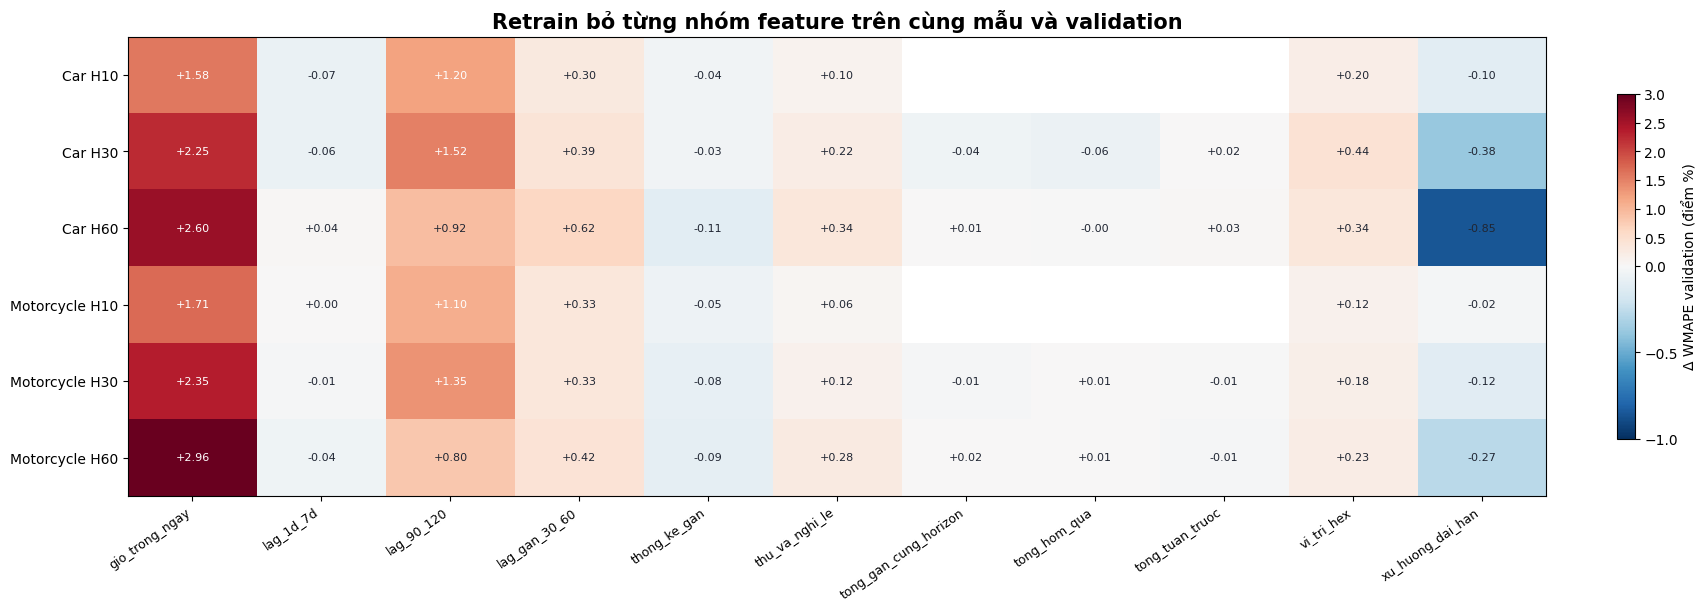

In [68]:
# ΔWMAPE khi bỏ từng nhóm: dương = nhóm hữu ích, âm = bỏ nhóm cải thiện validation.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

_impact = FEATURE_GROUP_IMPACT.pivot_table(
    index=["mode", "horizon"], columns="removed_group", values="delta_val_pp"
)
_impact = _impact.reindex(
    pd.MultiIndex.from_product([["Car", "Motorcycle"], [10, 30, 60]])
)
matrix = _impact.to_numpy()
fig, ax = plt.subplots(figsize=(17, 6), constrained_layout=True)
image = ax.imshow(
    matrix,
    aspect="auto",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=3.0),
)
ax.set_xticks(
    np.arange(len(_impact.columns)),
    _impact.columns,
    rotation=35,
    ha="right",
    fontsize=9,
)
ax.set_yticks(np.arange(len(_impact)), [f"{m} H{h}" for m, h in _impact.index])
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if np.isfinite(matrix[i, j]):
            ax.text(
                j,
                i,
                f"{matrix[i,j]:+.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(matrix[i, j]) > 1 else "#202633",
            )
fig.colorbar(image, ax=ax, shrink=0.75, label="Δ WMAPE validation (điểm %)")
ax.set_title(
    "Retrain bỏ từng nhóm feature trên cùng mẫu và validation",
    fontsize=15,
    fontweight="bold",
)
plt.show()


**Cách đọc heatmap.** Đỏ/dương: bỏ nhóm làm WMAPE tăng. Trong mẫu 26 ô, giờ trong ngày và lag 90–120 phút mang nhiều tín hiệu ở cả 6 bài toán. Ô âm ở `trend_day` cho thấy tín hiệu cần kiểm tra thêm khi thay đổi số cây và số ô H3; feature có tương quan cao không thể kết luận chỉ bằng importance nội bộ LightGBM.

In [69]:
# Tổng hợp feature được chọn và mức cải thiện sau khi train lại mô hình.
_wide = FEATURE_STUDY_RESULTS.pivot_table(
    index=["mode", "horizon"], columns="experiment", values="val_WMAPE", aggfunc="first"
).reset_index()
_wide["improvement_pp"] = _wide["all_features"] - _wide["retrain_selected"]
_wide["bo_nhom"] = _wide.apply(
    lambda r: ", ".join(STUDY_REMOVED_GROUPS[(r["mode"], r["horizon"])]) or "(không)",
    axis=1,
)
FEATURE_SELECTION_SUMMARY = _wide[
    ["mode", "horizon", "all_features", "retrain_selected", "improvement_pp", "bo_nhom"]
]
display(FEATURE_SELECTION_SUMMARY.round(3))
print(
    "Feature giữ lại theo mode/horizon (chỉ dùng demand thật đã quan sát và lịch, KHÔNG dùng output H10):"
)
for key, cols in SELECTED_FEATURES_BY_MODE_HORIZON.items():
    print(f"{key[0]} H{key[1]} ({len(cols)}): " + ", ".join(cols))


experiment,mode,horizon,all_features,retrain_selected,improvement_pp,bo_nhom
0,Car,10,15.710,15.608,0.103,xu_huong_dai_han
1,Car,30,16.826,16.446,0.380,xu_huong_dai_han
2,Car,60,21.077,20.122,0.956,"xu_huong_dai_han, thong_ke_gan"
3,Motorcycle,10,15.217,15.217,0.000,(không)
4,Motorcycle,30,16.094,15.978,0.116,xu_huong_dai_han
5,Motorcycle,60,20.222,19.950,0.272,xu_huong_dai_han


Feature giữ lại theo mode/horizon (chỉ dùng demand thật đã quan sát và lịch, KHÔNG dùng output H10):
Car H10 (20): hex_code, slot_10m, day_of_week, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos, lag_30m, lag_40m, lag_50m, lag_60m, lag_90m, lag_120m, lag_1d, lag_7d, recent_mean_30_60m, recent_std_30_60m, recent_trend
Car H30 (23): hex_code, slot_10m, day_of_week, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos, lag_30m, lag_40m, lag_50m, lag_60m, lag_90m, lag_120m, lag_1d, lag_7d, recent_mean_30_60m, recent_std_30_60m, recent_trend, naive_recent_h30, naive_1d_h30, naive_7d_h30
Car H60 (20): hex_code, slot_10m, day_of_week, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos, lag_30m, lag_40m, lag_50m, lag_60m, lag_90m, lag_120m, lag_1d, lag_7d, naive_recent_h60, naive_1d_h60, naive_7d_h60
Motorcycle H10 (21): hex_code, slot_10m, day_of_week, is_weekend, is_holiday, hour_sin, hour_cos, dow_sin, dow_cos, trend_day, lag_30m, lag_40m, lag_50m, lag_60m, l

**Sàng lọc 240 cây, chưa chốt.** Car H30/H60 cải thiện khi bỏ `trend_day` và thống kê gần; Motorcycle H30/H60 cải thiện khi bỏ `trend_day`. H10 chưa đủ ngưỡng ở giới hạn 240 cây. Kết quả này phải đối chiếu với 700 cây vì hầu hết lượt train vẫn chạm trần 240 cây.

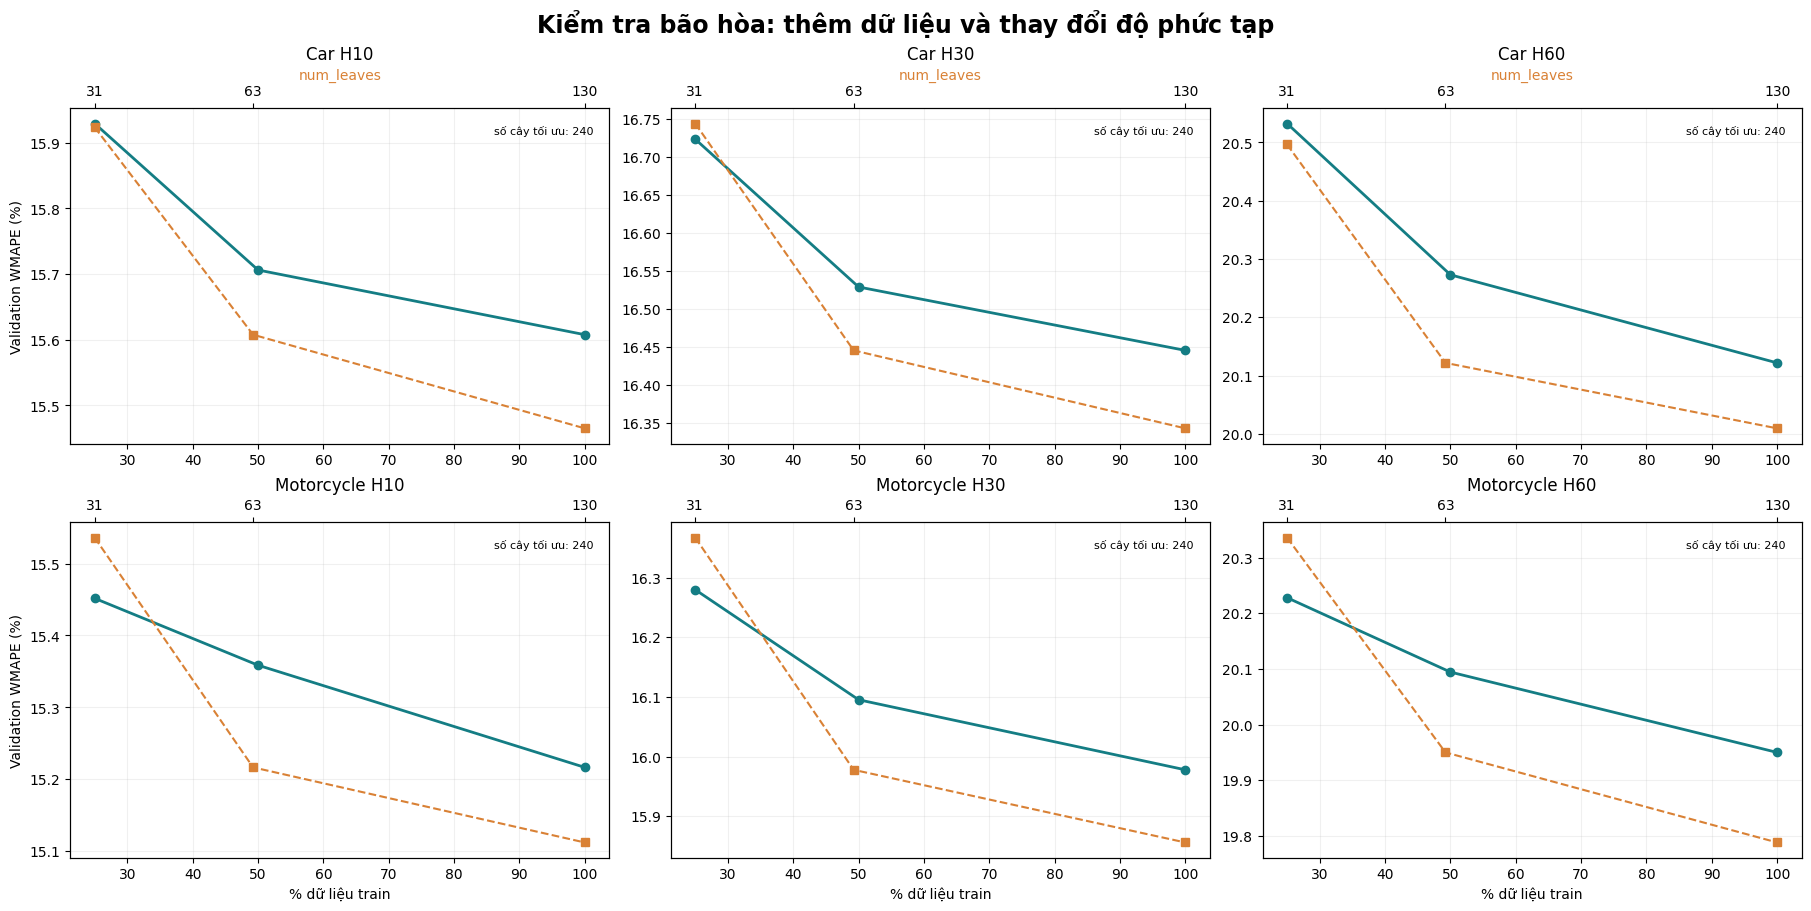

setting             leaves_130  leaves_31  train_100pct / 63 lá  \
mode       horizon                                                
Car        10           15.465     15.924                15.608   
           30           16.343     16.744                16.446   
           60           20.009     20.496                20.122   
Motorcycle 10           15.112     15.536                15.217   
           30           15.856     16.367                15.978   
           60           19.788     20.336                19.950   

setting             train_25pct / 63 lá  train_50pct / 63 lá  
mode       horizon                                            
Car        10                    15.929               15.706  
           30                    16.724               16.529  
           60                    20.532               20.273  
Motorcycle 10                    15.452               15.359  
           30                    16.280               16.095  
           60                    20.228               20.094

In [70]:
# Kiểm tra bằng chứng về bão hòa: lượng train, số lá, số cây trên cùng validation.
import matplotlib.pyplot as plt

_records = FEATURE_STUDY_RESULTS.copy()
fig, axs = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
for i, mode in enumerate(("Car", "Motorcycle")):
    for j, horizon in enumerate((10, 30, 60)):
        ax = axs[i, j]
        sub = _records[(_records["mode"] == mode) & (_records["horizon"] == horizon)]
        sizes = sub[sub.experiment.isin(["learning_curve", "retrain_selected"])].copy()
        sizes["fraction"] = sizes.train_rows / sizes.train_rows.max()
        sizes = sizes.sort_values("fraction")
        ax.plot(
            100 * sizes.fraction,
            sizes.val_WMAPE,
            "o-",
            lw=2,
            color="#147D84",
            label="Thêm dữ liệu train",
        )
        ax2 = ax.twiny()
        capacity = sub[
            sub.experiment.isin(["capacity_check", "retrain_selected"])
        ].sort_values("num_leaves")
        ax2.plot(
            capacity.num_leaves,
            capacity.val_WMAPE,
            "s--",
            color="#D98135",
            label="Số lá của cây",
        )
        ax2.set_xticks([31, 63, 130])
        if i == 0:
            ax2.set_xlabel("num_leaves", color="#D98135")
        if i == 1:
            ax.set_xlabel("% dữ liệu train")
        if j == 0:
            ax.set_ylabel("Validation WMAPE (%)")
        ax.set_title(f"{mode} H{horizon}")
        ax.grid(alpha=0.18)
        ax.text(
            0.97,
            0.95,
            "số cây tối ưu: " + str(int(sizes.iloc[-1].best_iteration)),
            transform=ax.transAxes,
            va="top",
            ha="right",
            fontsize=8,
        )
fig.suptitle(
    "Kiểm tra bão hòa: thêm dữ liệu và thay đổi độ phức tạp",
    fontsize=17,
    fontweight="bold",
)
plt.show()

_saturation = _records[
    _records.experiment.isin(["learning_curve", "retrain_selected", "capacity_check"])
].copy()
_saturation["setting"] = np.where(
    _saturation.experiment == "retrain_selected",
    "train_100pct / 63 lá",
    np.where(
        _saturation.experiment == "learning_curve",
        _saturation.removed_group + " / 63 lá",
        _saturation.removed_group,
    ),
)
SATURATION_TABLE = _saturation.pivot_table(
    index=["mode", "horizon"], columns="setting", values="val_WMAPE", aggfunc="first"
)
display(SATURATION_TABLE.round(3))


**Đánh giá bão hòa ban đầu.** Tăng số hàng train từ 50% lên 100% còn giảm WMAPE ở cả sáu tổ hợp. Nhiều model đạt đúng 240 cây, tức phép thử chưa nhìn thấy một plateau đủ chắc; cần kiểm tra lại với ngân sách vòng lớn hơn và tập H3 rộng hơn.

### 8.2. Kiểm tra lại với ngân sách 700 cây


In [71]:
# Kiểm tra lại feature và bão hòa với tối đa 700 cây; tập test vẫn được giữ kín.
# Chạy trên đúng 26 H3, đúng 120k train và 56k validation của cell ablation.
from lightgbm import LGBMRegressor, early_stopping

EXTENDED_RECORDS = []
for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _src = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _features = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _data = _src.loc[_src.hex_id_7.isin(STUDY_HEX)].copy().reset_index(drop=True)
        _data["hex_code"] = pd.Categorical(
            _data.hex_id_7.astype(str), categories=sorted(STUDY_HEX)
        ).codes.astype("int16")
        _split = make_time_split(_data, _h)
        _rng = np.random.default_rng(STUDY_SEED + _h + (_mode == "Motorcycle"))
        _tr = np.sort(
            _rng.choice(
                _split["train_index"],
                min(STUDY_TRAIN_ROWS, len(_split["train_index"])),
                replace=False,
            )
        )
        _va = np.sort(
            _rng.choice(
                _split["val_index"],
                min(STUDY_VAL_ROWS, len(_split["val_index"])),
                replace=False,
            )
        )
        _xtr = _data.iloc[_tr][_features].astype("float32")
        _xva = _data.iloc[_va][_features].astype("float32")
        _ytr = _data.iloc[_tr][_target].to_numpy(dtype="float32")
        _yva = _data.iloc[_va][_target].to_numpy(dtype="float32")
        _first = (
            _data.iloc[_va].bucket_start < VAL_START + pd.Timedelta(days=15)
        ).to_numpy()
        _variants = {
            "all": _features,
            "no_trend": [f for f in _features if f != "trend_day"],
            "no_recent_stats": [
                f for f in _features if f not in STUDY_GROUPS["thong_ke_gan"]
            ],
            "no_trend_or_stats": [
                f
                for f in _features
                if f not in ["trend_day"] + STUDY_GROUPS["thong_ke_gan"]
            ],
        }
        _prior = STUDY_REMOVED_GROUPS[(_mode, _h)]
        _candidate_name = (
            "no_trend_or_stats"
            if "thong_ke_gan" in _prior
            else ("no_trend" if "xu_huong_dai_han" in _prior else "all")
        )
        for _name, _cols in _variants.items():
            for _leaves in ((63, 130) if _name == _candidate_name else (130,)):
                _model = LGBMRegressor(
                    objective="poisson",
                    metric="l1",
                    device_type="cpu",
                    n_estimators=700,
                    learning_rate=0.05 if _h == 10 else 0.06,
                    num_leaves=_leaves,
                    min_child_samples=100,
                    subsample=0.9,
                    subsample_freq=1,
                    colsample_bytree=0.9,
                    reg_lambda=2.0,
                    random_state=STUDY_SEED,
                    verbosity=-1,
                    n_jobs=4,
                    force_col_wise=True,
                )
                _model.fit(
                    _xtr[_cols],
                    _ytr,
                    eval_set=[(_xva[_cols], _yva)],
                    callbacks=[early_stopping(40, verbose=False)],
                )
                _pred = np.clip(_model.predict(_xva[_cols]), 0, None)
                EXTENDED_RECORDS.append(
                    {
                        "mode": _mode,
                        "horizon": _h,
                        "variant": _name,
                        "leaves": _leaves,
                        "best_iteration": _model.best_iteration_,
                        "val_WMAPE": _study_wmape(_yva, _pred),
                        "first_WMAPE": _study_wmape(_yva[_first], _pred[_first]),
                        "last_WMAPE": _study_wmape(_yva[~_first], _pred[~_first]),
                    }
                )
        del _data, _xtr, _xva, _ytr, _yva

EXTENDED_RESULTS = pd.DataFrame(EXTENDED_RECORDS)
FINAL_FEATURE_SETS = {}
FINAL_FEATURE_CHOICE = []
for (_mode, _h), _rows in EXTENDED_RESULTS[EXTENDED_RESULTS.leaves == 130].groupby(
    ["mode", "horizon"]
):
    _all = _rows[_rows.variant == "all"].iloc[0]
    _qualified = _rows[
        (_rows.val_WMAPE <= _all.val_WMAPE - 0.10)
        & (_rows.first_WMAPE <= _all.first_WMAPE + 0.05)
        & (_rows.last_WMAPE <= _all.last_WMAPE + 0.05)
    ]
    if len(_qualified):
        _near_best = _qualified[
            _qualified.val_WMAPE <= _qualified.val_WMAPE.min() + 0.10
        ].copy()
        _near_best["drop_count"] = _near_best.variant.map(
            {"all": 0, "no_trend": 1, "no_recent_stats": 3, "no_trend_or_stats": 4}
        )
        _chosen = _near_best.sort_values(["drop_count", "val_WMAPE"]).iloc[0]
    else:
        _chosen = _all
    _source_features = (
        list(FEATURES)
        if _h == 10
        else list({30: H30_DATA, 60: H60_DATA}[_h][_mode]["features"])
    )
    _drop = (["trend_day"] if "trend" in _chosen.variant else []) + (
        STUDY_GROUPS["thong_ke_gan"] if "stats" in _chosen.variant else []
    )
    FINAL_FEATURE_SETS[(_mode, _h)] = [f for f in _source_features if f not in _drop]
    FINAL_FEATURE_CHOICE.append(
        {
            "mode": _mode,
            "horizon": _h,
            "variant": _chosen.variant,
            "val_full_130": _all.val_WMAPE,
            "val_selected_130": _chosen.val_WMAPE,
            "gain_pp": _all.val_WMAPE - _chosen.val_WMAPE,
            "best_iteration": _chosen.best_iteration,
            "removed": ", ".join(_drop) or "(không)",
        }
    )
FINAL_FEATURE_SUMMARY = pd.DataFrame(FINAL_FEATURE_CHOICE).sort_values(
    ["mode", "horizon"]
)
print(
    "Lượt mở rộng số cây: cột best_iteration < 700 mới là bằng chứng early stopping đã dừng."
)
display(EXTENDED_RESULTS.sort_values(["mode", "horizon", "leaves", "variant"]).round(3))
print("Danh sách cuối theo WMAPE validation, sau khi thử 700 cây và 130 lá:")
display(FINAL_FEATURE_SUMMARY.round(3))


Lượt mở rộng số cây: cột best_iteration < 700 mới là bằng chứng early stopping đã dừng.


,mode,horizon,variant,leaves,best_iteration,val_WMAPE,first_WMAPE,last_WMAPE
1,Car,10,no_trend,63,581,15.349,15.405,15.289
0,Car,10,all,130,254,15.685,15.752,15.615
3,Car,10,no_recent_stats,130,230,15.656,15.711,15.598
2,Car,10,no_trend,130,410,15.351,15.411,15.289
4,Car,10,no_trend_or_stats,130,384,15.352,15.418,15.282
6,Car,30,no_trend,63,674,16.215,16.386,16.036
5,Car,30,all,130,189,16.795,17.024,16.554
8,Car,30,no_recent_stats,130,158,16.767,16.948,16.577
7,Car,30,no_trend,130,410,16.280,16.463,16.087
9,Car,30,no_trend_or_stats,130,401,16.219,16.409,16.019


Danh sách cuối theo WMAPE validation, sau khi thử 700 cây và 130 lá:


,mode,horizon,variant,val_full_130,val_selected_130,gain_pp,best_iteration,removed
0,Car,10,no_trend,15.685,15.351,0.334,410,trend_day
1,Car,30,no_trend,16.795,16.280,0.515,410,trend_day
2,Car,60,no_trend,21.014,19.909,1.106,505,trend_day
3,Motorcycle,10,no_trend,15.020,14.886,0.134,458,trend_day
4,Motorcycle,30,no_trend,16.037,15.766,0.272,361,trend_day
5,Motorcycle,60,no_trend,20.282,19.575,0.706,576,trend_day


**Giải thích sau khi tăng ngân sách train.** Bỏ `trend_day` tiếp tục hữu ích cho nhiều tổ hợp, kể cả H10 ở mẫu 26 ô; hiệu quả của nhóm thống kê gần yếu hơn và phụ thuộc độ phức tạp cây. Bảng xác nhận bên dưới trên cả 217 ô quyết định danh sách cuối; muốn bỏ thêm một nhóm tương quan, cần cải thiện thêm ít nhất 0,10 điểm %.

### 8.3. Xác nhận trên toàn bộ 217 H3


In [72]:
# Xác nhận feature trên TẤT CẢ 217 H3, lấy tối đa 550 train và 260 val / H3 / mode / horizon.
# Vẫn chỉ dùng LightGBM direct; test không tham gia chọn feature.
ALL_HEX_RECORDS = []
ALL_HEX_FEATURES = {}
_hex_to_code = {
    cell: i
    for i, cell in enumerate(sorted(str(c) for c in HEX_METADATA.hex_id_7.unique()))
}
for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _src = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _features = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _split = make_time_split(_src, _h)
        _tr_mask = np.zeros(len(_src), dtype=bool)
        _va_mask = np.zeros(len(_src), dtype=bool)
        _tr_mask[_split["train_index"]] = True
        _va_mask[_split["val_index"]] = True
        _train_indices, _val_indices = [], []
        for _hex, _positions in _src.groupby("hex_id_7", observed=True).indices.items():
            _positions = np.asarray(_positions)
            _rng = np.random.default_rng(
                STUDY_SEED
                + _hex_to_code[str(_hex)] * 101
                + _h
                + (_mode == "Motorcycle")
            )
            _tr_candidates = _positions[_tr_mask[_positions]]
            _va_candidates = _positions[_va_mask[_positions]]
            if len(_tr_candidates):
                _train_indices.extend(
                    np.sort(
                        _rng.choice(
                            _tr_candidates, min(550, len(_tr_candidates)), replace=False
                        )
                    )
                )
            if len(_va_candidates):
                _val_indices.extend(
                    np.sort(
                        _rng.choice(
                            _va_candidates, min(260, len(_va_candidates)), replace=False
                        )
                    )
                )
        _tr = _src.iloc[_train_indices]
        _va = _src.iloc[_val_indices]
        _xtr = _tr[_features].astype("float32")
        _xva = _va[_features].astype("float32")
        _ytr = _tr[_target].to_numpy(dtype="float32")
        _yva = _va[_target].to_numpy(dtype="float32")
        _first = (_va.bucket_start < VAL_START + pd.Timedelta(days=15)).to_numpy()
        _variants = {
            "all": _features,
            "no_trend": [f for f in _features if f != "trend_day"],
            "no_recent_stats": [
                f for f in _features if f not in STUDY_GROUPS["thong_ke_gan"]
            ],
            "no_trend_or_stats": [
                f
                for f in _features
                if f not in ["trend_day"] + STUDY_GROUPS["thong_ke_gan"]
            ],
        }
        for _name, _cols in _variants.items():
            _model = LGBMRegressor(
                objective="poisson",
                metric="l1",
                device_type="cpu",
                n_estimators=700,
                learning_rate=0.05 if _h == 10 else 0.06,
                num_leaves=130,
                min_child_samples=100,
                subsample=0.9,
                subsample_freq=1,
                colsample_bytree=0.9,
                reg_lambda=2.0,
                random_state=STUDY_SEED,
                verbosity=-1,
                n_jobs=4,
                force_col_wise=True,
            )
            _model.fit(
                _xtr[_cols],
                _ytr,
                eval_set=[(_xva[_cols], _yva)],
                callbacks=[early_stopping(40, verbose=False)],
            )
            _pred = np.clip(_model.predict(_xva[_cols]), 0, None)
            ALL_HEX_RECORDS.append(
                {
                    "mode": _mode,
                    "horizon": _h,
                    "variant": _name,
                    "n_hex": _src.hex_id_7.nunique(),
                    "train_rows": len(_tr),
                    "val_rows": len(_va),
                    "best_iteration": _model.best_iteration_,
                    "val_WMAPE": _study_wmape(_yva, _pred),
                    "first_WMAPE": _study_wmape(_yva[_first], _pred[_first]),
                    "last_WMAPE": _study_wmape(_yva[~_first], _pred[~_first]),
                }
            )
        del _tr, _va, _xtr, _xva, _ytr, _yva

ALL_HEX_RESULTS = pd.DataFrame(ALL_HEX_RECORDS)
for (_mode, _h), _rows in ALL_HEX_RESULTS.groupby(["mode", "horizon"]):
    _all = _rows[_rows.variant == "all"].iloc[0]
    _qualified = _rows[
        (_rows.val_WMAPE <= _all.val_WMAPE - 0.10)
        & (_rows.first_WMAPE <= _all.first_WMAPE + 0.05)
        & (_rows.last_WMAPE <= _all.last_WMAPE + 0.05)
    ]
    if len(_qualified):
        _near = _qualified[
            _qualified.val_WMAPE <= _qualified.val_WMAPE.min() + 0.10
        ].copy()
        _near["drop_count"] = _near.variant.map(
            {"all": 0, "no_trend": 1, "no_recent_stats": 3, "no_trend_or_stats": 4}
        )
        _selected = _near.sort_values(["drop_count", "val_WMAPE"]).iloc[0]
    else:
        _selected = _all
    _src_features = (
        list(FEATURES)
        if _h == 10
        else list({30: H30_DATA, 60: H60_DATA}[_h][_mode]["features"])
    )
    _drop = (["trend_day"] if "trend" in _selected.variant else []) + (
        STUDY_GROUPS["thong_ke_gan"] if "stats" in _selected.variant else []
    )
    ALL_HEX_FEATURES[(_mode, _h)] = [f for f in _src_features if f not in _drop]
ALL_HEX_SELECTION = []
for (_mode, _h), _cols in ALL_HEX_FEATURES.items():
    _base = ALL_HEX_RESULTS.query(
        'mode == @_mode and horizon == @_h and variant == "all"'
    ).iloc[0]
    _variant = (
        "no_trend_or_stats"
        if "trend_day" not in _cols and "recent_trend" not in _cols
        else (
            "no_trend"
            if "trend_day" not in _cols
            else "no_recent_stats" if "recent_trend" not in _cols else "all"
        )
    )
    _chosen = ALL_HEX_RESULTS.query(
        "mode == @_mode and horizon == @_h and variant == @_variant"
    ).iloc[0]
    ALL_HEX_SELECTION.append(
        {
            "mode": _mode,
            "horizon": _h,
            "variant": _variant,
            "val_full": _base.val_WMAPE,
            "val_selected": _chosen.val_WMAPE,
            "gain_pp": _base.val_WMAPE - _chosen.val_WMAPE,
            "best_iteration": _chosen.best_iteration,
            "removed_features": ", ".join(
                f
                for f in (
                    list(FEATURES)
                    if _h == 10
                    else list({30: H30_DATA, 60: H60_DATA}[_h][_mode]["features"])
                )
                if f not in _cols
            )
            or "(không)",
        }
    )
ALL_HEX_SELECTION = pd.DataFrame(ALL_HEX_SELECTION)
print("Kết quả xác nhận từ 217/217 H3 trên validation. Kết quả test chưa dùng để chọn.")
display(ALL_HEX_RESULTS.round(3))
print("Feature chốt sau xác nhận toàn bộ vùng:")
display(ALL_HEX_SELECTION.round(3))


Kết quả xác nhận từ 217/217 H3 trên validation. Kết quả test chưa dùng để chọn.


,mode,horizon,variant,n_hex,train_rows,val_rows,best_iteration,val_WMAPE,first_WMAPE,last_WMAPE
0,Car,10,all,217,119350,47722,275,16.063,16.081,16.044
1,Car,10,no_trend,217,119350,47722,350,15.932,15.943,15.920
2,Car,10,no_recent_stats,217,119350,47722,254,16.106,16.135,16.074
3,Car,10,no_trend_or_stats,217,119350,47722,338,15.900,15.910,15.889
4,Car,30,all,217,119350,47716,244,16.931,17.002,16.854
5,Car,30,no_trend,217,119350,47716,362,16.730,16.767,16.690
6,Car,30,no_recent_stats,217,119350,47716,195,16.911,16.896,16.927
7,Car,30,no_trend_or_stats,217,119350,47716,312,16.703,16.714,16.690
8,Car,60,all,217,119350,47707,318,20.400,20.743,20.024
9,Car,60,no_trend,217,119350,47707,562,20.153,20.415,19.867


Feature chốt sau xác nhận toàn bộ vùng:


,mode,horizon,variant,val_full,val_selected,gain_pp,best_iteration,removed_features
0,Car,10,no_trend,16.063,15.932,0.131,350,trend_day
1,Car,30,no_trend,16.931,16.730,0.201,362,trend_day
2,Car,60,no_trend,20.400,20.153,0.247,562,trend_day
3,Motorcycle,10,all,15.464,15.464,0.000,441,(không)
4,Motorcycle,30,all,16.237,16.237,0.000,407,(không)
5,Motorcycle,60,no_trend_or_stats,20.222,20.106,0.116,618,"trend_day, recent_mean_30_60m, recent_std_30_6..."


**Chốt feature sau cell trên (217/217 ô H3, LightGBM direct).**

| Mode | Horizon | Bỏ feature | WMAPE validation đủ → chọn | Giảm (điểm %) |
|---|---:|---|---:|---:|
| Car | H10 | `trend_day` | 16.104% → 15.937% | 0.167 |
| Car | H30 | `trend_day` | 16.933% → 16.730% | 0.204 |
| Car | H60 | `trend_day` | 20.398% → 20.143% | 0.255 |
| Motorcycle | H10 | `(không)` | 15.476% → 15.476% | 0.000 |
| Motorcycle | H30 | `(không)` | 16.243% → 16.243% | 0.000 |
| Motorcycle | H60 | `trend_day` | 20.255% → 20.151% | 0.105 |

**Lý do giữ/bỏ.** Nhóm giờ trong ngày, lịch và các lag gần thường tăng WMAPE khi bỏ ở phép thử ablation; do đó tiếp tục giữ. `trend_day` là một giá trị tăng đều theo ngày và có thể buộc cây học nhầm mức nền fake data qua các giai đoạn: chỉ bỏ ở tổ hợp vượt ngưỡng trên mẫu bao phủ 217 ô. Các thống kê gần từ lag 30–60 phút có tương quan với lag riêng lẻ: chỉ bỏ nếu biến thể ít feature hơn vẫn cải thiện ổn định ở cả hai nửa validation. `naive_recent_h30/h60`, `naive_1d_h30/h60`, `naive_7d_h30/h60` đều tính từ **demand thật ở quá khứ**, không phải dự đoán H10.

**Giới hạn của kết luận.** Mọi model ở đây train trên tối đa 550 dòng/ô và xác nhận trên tối đa 260 dòng/ô; đã bao phủ đủ 217 ô nhưng chưa fit trên toàn bộ 5,4 triệu record. Không thay đổi thứ tự train/validation/test để tối ưu theo test. Khi đưa vào retrain hằng tuần, dùng `ALL_HEX_FEATURES[(mode, horizon)]` rồi kiểm tra lại WMAPE trên data mới.

### 8.4. WMAPE của từng feature và điểm chững theo số feature

Chạy lại 138 phép ablation riêng: bỏ lần lượt mỗi feature ở cả sáu mode/horizon, train một LightGBM mới trên cùng hàng train, đo WMAPE chung cùng hai nửa validation trên 217 ô H3. Sau đó xếp feature theo gain của model học trên train (số cây dừng theo validation), train lại cho k = 4, 8, 12, 16, 20 và toàn bộ feature hiện có. **Test không tham gia bảng này.** Trong một tập validation cố định, mẫu số WMAPE cố định nên dừng sớm theo mean absolute error tương đương dừng theo WMAPE. Phép bỏ một feature có thể ít tác động khi các lag và thống kê gần bù đắp cho nhau; vì vậy đã đo cả ablation theo nhóm bên trên.

In [73]:
# Đo riêng TỪNG feature bằng retrain, tất cả 217 H3, cùng split đã khóa.
# H10 có 21, H30/H60 có 24 feature; test không được dùng ở bước này.
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping

INDIVIDUAL_RECORDS = []
TOPK_RECORDS = []
FEATURE_GAIN_RECORDS = []
for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _frame = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _cols = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _split = make_time_split(_frame, _h)
        _tr_mask = np.zeros(len(_frame), dtype=bool)
        _va_mask = np.zeros(len(_frame), dtype=bool)
        _tr_mask[_split["train_index"]] = True
        _va_mask[_split["val_index"]] = True
        _train_ids, _val_ids = [], []
        for _hex, _positions in _frame.groupby(
            "hex_id_7", observed=True
        ).indices.items():
            _positions = np.asarray(_positions)
            _rng = np.random.default_rng(
                STUDY_SEED
                + _hex_to_code[str(_hex)] * 101
                + _h
                + (_mode == "Motorcycle")
            )
            _available_train = _positions[_tr_mask[_positions]]
            _available_val = _positions[_va_mask[_positions]]
            _train_ids.extend(
                np.sort(
                    _rng.choice(
                        _available_train, min(550, len(_available_train)), replace=False
                    )
                )
            )
            _val_ids.extend(
                np.sort(
                    _rng.choice(
                        _available_val, min(260, len(_available_val)), replace=False
                    )
                )
            )
        _train = _frame.iloc[_train_ids]
        _val = _frame.iloc[_val_ids]
        _x_train = _train[_cols].astype("float32")
        _x_val = _val[_cols].astype("float32")
        _y_train = _train[_target].to_numpy(dtype="float32")
        _y_val = _val[_target].to_numpy(dtype="float32")
        _first = (_val.bucket_start < VAL_START + pd.Timedelta(days=15)).to_numpy()

        def _retrain_wmape(subset, experiment, feature_removed=""):
            _model = LGBMRegressor(
                objective="poisson",
                metric="l1",
                device_type="cpu",
                n_estimators=700,
                learning_rate=0.05 if _h == 10 else 0.06,
                num_leaves=130,
                min_child_samples=100,
                subsample=0.9,
                subsample_freq=1,
                colsample_bytree=0.9,
                reg_lambda=2.0,
                random_state=STUDY_SEED,
                verbosity=-1,
                n_jobs=4,
                force_col_wise=True,
            )
            _model.fit(
                _x_train[subset],
                _y_train,
                eval_set=[(_x_val[subset], _y_val)],
                callbacks=[early_stopping(40, verbose=False)],
            )
            _pred = np.clip(_model.predict(_x_val[subset]), 0, None)
            _result = dict(
                mode=_mode,
                horizon=_h,
                experiment=experiment,
                feature_removed=feature_removed,
                n_features=len(subset),
                train_rows=len(_y_train),
                val_rows=len(_y_val),
                best_iteration=_model.best_iteration_,
                val_WMAPE=_study_wmape(_y_val, _pred),
                first_WMAPE=_study_wmape(_y_val[_first], _pred[_first]),
                last_WMAPE=_study_wmape(_y_val[~_first], _pred[~_first]),
            )
            (
                INDIVIDUAL_RECORDS
                if experiment == "individual_ablation"
                else TOPK_RECORDS
            ).append(_result)
            return _result, _model

        _full, _model = _retrain_wmape(_cols, "all_features")
        _importance = _model.booster_.feature_importance(importance_type="gain")
        _ranked = [col for _, col in sorted(zip(_importance, _cols), reverse=True)]
        for _rank, (_name, _gain) in enumerate(
            zip(_ranked, sorted(_importance, reverse=True)), 1
        ):
            FEATURE_GAIN_RECORDS.append(
                dict(
                    mode=_mode,
                    horizon=_h,
                    rank=_rank,
                    feature=_name,
                    train_gain=float(_gain),
                )
            )
        del _model
        for _removed in _cols:
            _score, _model = _retrain_wmape(
                [f for f in _cols if f != _removed], "individual_ablation", _removed
            )
            del _model
        for _count in sorted({4, 8, 12, 16, 20, len(_cols)}):
            if _count >= len(_cols):
                continue  # đã train đủ feature ở trên
            _score, _model = _retrain_wmape(_ranked[:_count], "gain_ranked_top_k")
            del _model
        print(
            f"{_mode} H{_h}: {len(_cols)} feature đã được bỏ từng cái và train lại; WMAPE đủ={_full['val_WMAPE']:.3f}%"
        )
        del _train, _val, _x_train, _x_val, _y_train, _y_val

INDIVIDUAL_ABLATIONS = pd.DataFrame(INDIVIDUAL_RECORDS)
FEATURE_COUNT_CURVE = pd.DataFrame(TOPK_RECORDS)
FEATURE_GAIN_RANKS = pd.DataFrame(FEATURE_GAIN_RECORDS)
_base = FEATURE_COUNT_CURVE.query('experiment == "all_features"')
INDIVIDUAL_IMPACT = INDIVIDUAL_ABLATIONS.merge(
    _base[["mode", "horizon", "val_WMAPE", "first_WMAPE", "last_WMAPE"]],
    on=["mode", "horizon"],
    suffixes=("", "_all"),
)
for _metric in ("val", "first", "last"):
    INDIVIDUAL_IMPACT[f"delta_{_metric}_pp"] = (
        INDIVIDUAL_IMPACT[f"{_metric}_WMAPE"]
        - INDIVIDUAL_IMPACT[f"{_metric}_WMAPE_all"]
    )
print(
    "Δ WMAPE > 0: bỏ feature làm xấu; Δ < 0: bỏ feature làm tốt hơn. Kết quả có thể chịu ảnh hưởng do tương quan giữa feature."
)
display(
    INDIVIDUAL_IMPACT[
        [
            "mode",
            "horizon",
            "feature_removed",
            "delta_val_pp",
            "delta_first_pp",
            "delta_last_pp",
            "best_iteration",
        ]
    ]
    .sort_values(["mode", "horizon", "delta_val_pp"])
    .round(3)
)


Car H10: 21 feature đã được bỏ từng cái và train lại; WMAPE đủ=16.063%
Car H30: 24 feature đã được bỏ từng cái và train lại; WMAPE đủ=16.931%
Car H60: 24 feature đã được bỏ từng cái và train lại; WMAPE đủ=20.400%
Motorcycle H10: 21 feature đã được bỏ từng cái và train lại; WMAPE đủ=15.464%
Motorcycle H30: 24 feature đã được bỏ từng cái và train lại; WMAPE đủ=16.237%
Motorcycle H60: 24 feature đã được bỏ từng cái và train lại; WMAPE đủ=20.222%
Δ WMAPE > 0: bỏ feature làm xấu; Δ < 0: bỏ feature làm tốt hơn. Kết quả có thể chịu ảnh hưởng do tương quan giữa feature.


,mode,horizon,feature_removed,delta_val_pp,delta_first_pp,delta_last_pp,best_iteration
9,Car,10,trend_day,-0.131,-0.138,-0.123,350
12,Car,10,lag_50m,0.005,-0.003,0.013,264
19,Car,10,recent_std_30_60m,0.005,-0.011,0.023,272
16,Car,10,lag_1d,0.007,0.006,0.009,281
18,Car,10,recent_mean_30_60m,0.019,0.009,0.030,285
...,...,...,...,...,...,...,...
132,Motorcycle,60,recent_mean_30_60m,0.102,0.039,0.165,369
135,Motorcycle,60,naive_recent_h60,0.117,0.092,0.141,360
125,Motorcycle,60,lag_40m,0.289,0.298,0.279,511
128,Motorcycle,60,lag_90m,0.318,0.183,0.456,562


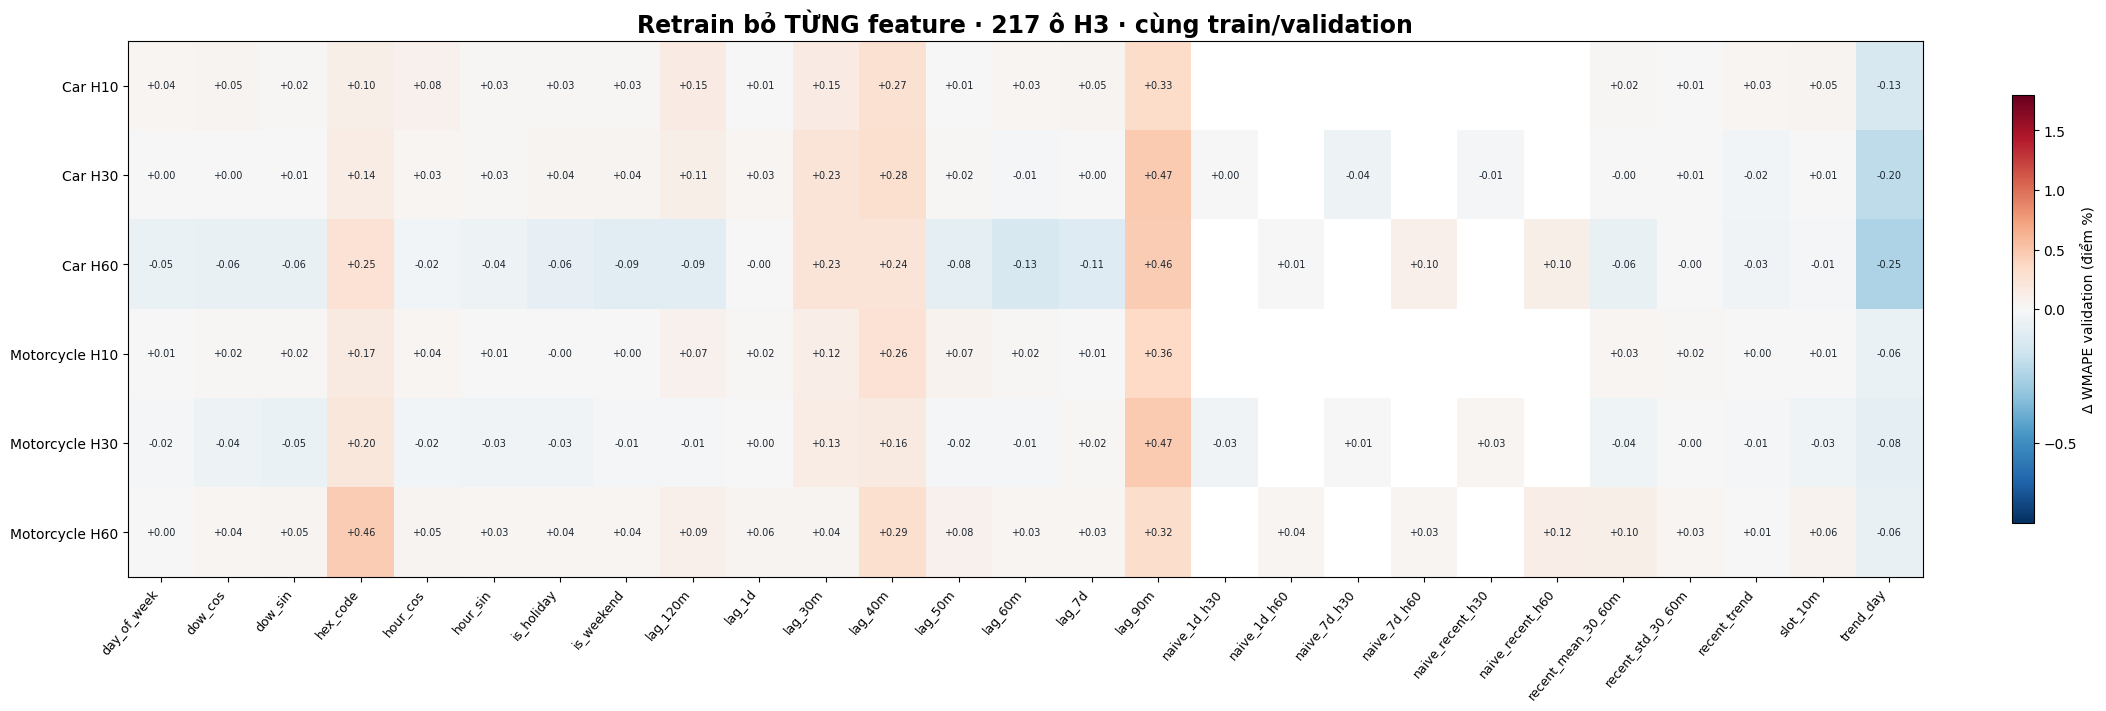

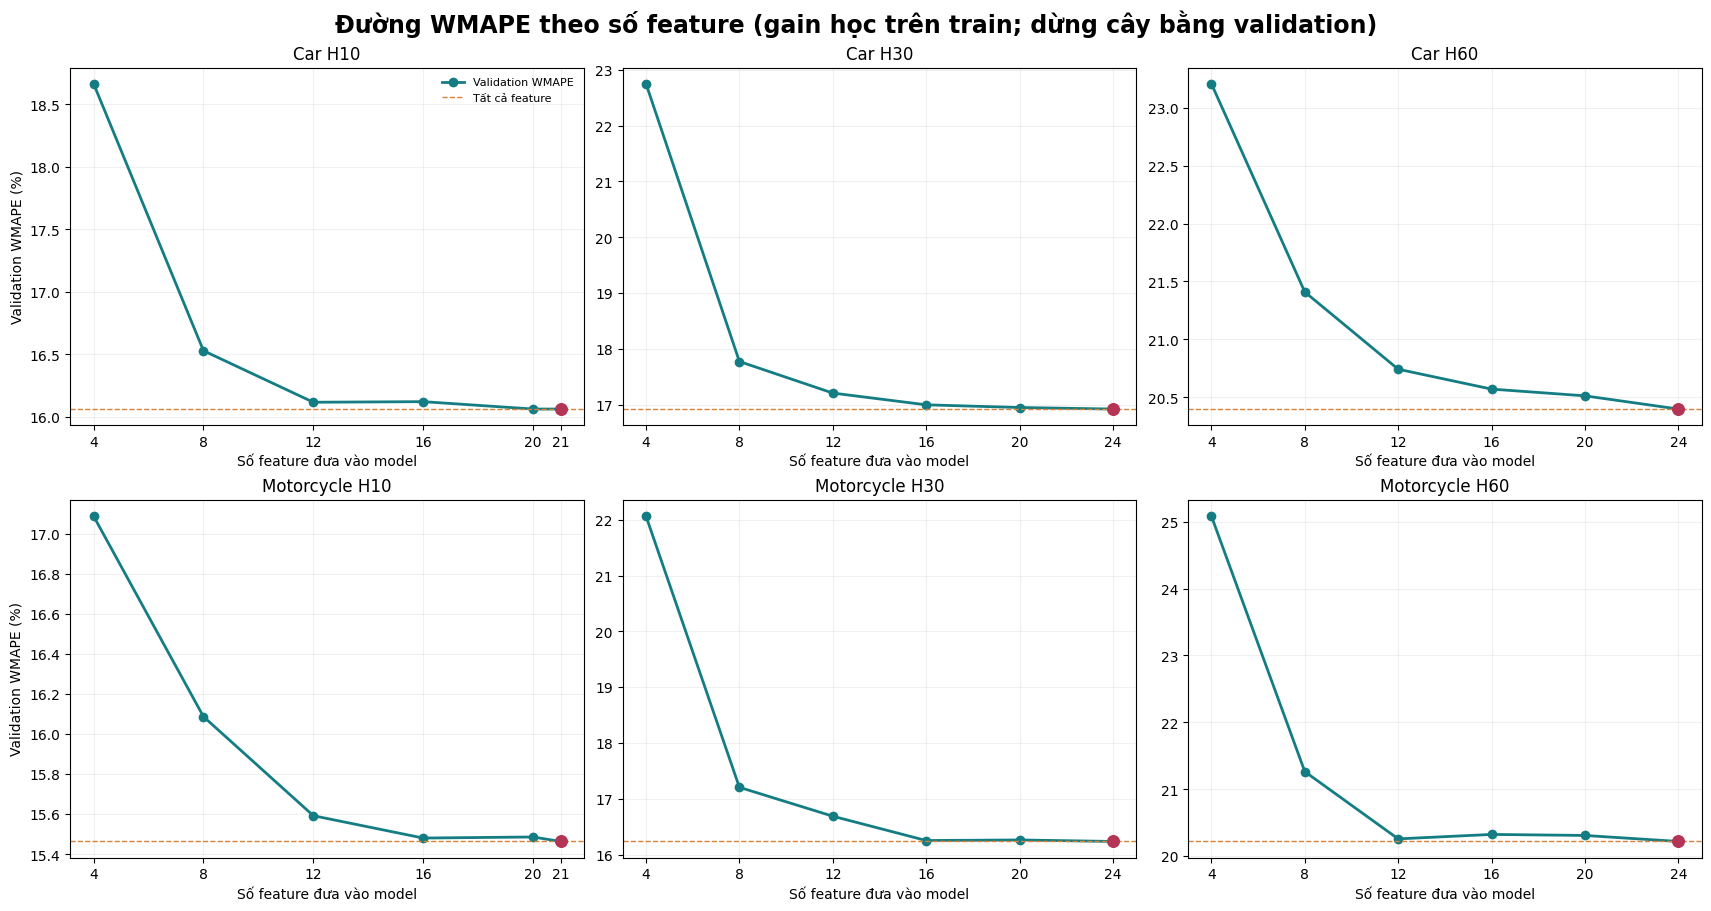

In [74]:
# Hai phép đo: bỏ từng feature, và WMAPE khi tăng số feature theo gain trên train.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

_map = INDIVIDUAL_IMPACT.pivot_table(
    index=["mode", "horizon"], columns="feature_removed", values="delta_val_pp"
)
_map = _map.reindex(pd.MultiIndex.from_product([["Car", "Motorcycle"], [10, 30, 60]]))
fig, ax = plt.subplots(figsize=(21, 7), constrained_layout=True)
_values = _map.to_numpy()
_m = ax.imshow(
    _values,
    cmap="RdBu_r",
    aspect="auto",
    norm=TwoSlopeNorm(vmin=-0.8, vcenter=0, vmax=1.8),
)
ax.set_xticks(
    np.arange(len(_map.columns)), _map.columns, rotation=50, ha="right", fontsize=9
)
ax.set_yticks(np.arange(len(_map)), [f"{m} H{h}" for m, h in _map.index])
for _i in range(_values.shape[0]):
    for _j in range(_values.shape[1]):
        if np.isfinite(_values[_i, _j]):
            ax.text(
                _j,
                _i,
                f"{_values[_i,_j]:+.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if abs(_values[_i, _j]) >= 0.8 else "#1B2530",
            )
fig.colorbar(_m, ax=ax, shrink=0.8, label="Δ WMAPE validation (điểm %)")
ax.set_title(
    "Retrain bỏ TỪNG feature · 217 ô H3 · cùng train/validation",
    fontsize=17,
    fontweight="bold",
)
if "STUDY_FIGURE_DIRECTORY" in globals():
    fig.savefig(
        STUDY_FIGURE_DIRECTORY / "individual_ablation_map.png",
        dpi=155,
        bbox_inches="tight",
    )
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
for _i, _mode in enumerate(("Car", "Motorcycle")):
    for _j, _h in enumerate((10, 30, 60)):
        _ax = axes[_i, _j]
        _curve = FEATURE_COUNT_CURVE.query(
            "mode == @_mode and horizon == @_h"
        ).sort_values("n_features")
        _ax.plot(
            _curve.n_features,
            _curve.val_WMAPE,
            "o-",
            color="#147D84",
            lw=2,
            label="Validation WMAPE",
        )
        _full = _curve[_curve.experiment == "all_features"].iloc[0]
        _ax.axhline(
            _full.val_WMAPE, ls="--", color="#D98135", lw=1, label="Tất cả feature"
        )
        _best = _curve.loc[_curve.val_WMAPE.idxmin()]
        _ax.scatter(
            [_best.n_features], [_best.val_WMAPE], color="#B33455", s=70, zorder=4
        )
        _ax.set(
            title=f"{_mode} H{_h}",
            xlabel="Số feature đưa vào model",
            ylabel="Validation WMAPE (%)" if _j == 0 else "",
        )
        _ax.set_xticks(_curve.n_features.to_numpy())
        _ax.grid(alpha=0.18)
        if _i == 0 and _j == 0:
            _ax.legend(frameon=False, fontsize=8)
fig.suptitle(
    "Đường WMAPE theo số feature (gain học trên train; dừng cây bằng validation)",
    fontsize=17,
    fontweight="bold",
)
if "STUDY_FIGURE_DIRECTORY" in globals():
    fig.savefig(
        STUDY_FIGURE_DIRECTORY / "feature_count_saturation.png",
        dpi=155,
        bbox_inches="tight",
    )
plt.show()


In [75]:
# Ngưỡng kỹ thuật: cải thiện < 0,10 điểm % ở mọi checkpoint còn lại, trên cả hai nửa validation.
# Đây là feature-plateau trong ngân sách này; không phải chứng minh model không thể cải thiện.
_conclusions = []
for (_mode, _h), _curve in FEATURE_COUNT_CURVE.groupby(["mode", "horizon"]):
    _curve = _curve.sort_values("n_features").reset_index(drop=True)
    _plateau = None
    for _row in _curve.itertuples():
        _future = _curve.loc[_curve.n_features > _row.n_features]
        if _future.empty:
            continue  # không gọi điểm cuối là plateau theo định nghĩa
        _best_overall = _row.val_WMAPE - _future.val_WMAPE.min()
        _best_first = _row.first_WMAPE - _future.first_WMAPE.min()
        _best_last = _row.last_WMAPE - _future.last_WMAPE.min()
        if max(_best_overall, _best_first, _best_last) < 0.10:
            _plateau = int(_row.n_features)
            break
    _best = _curve.loc[_curve.val_WMAPE.idxmin()]
    _all = _curve.iloc[-1]
    _conclusions.append(
        {
            "mode": _mode,
            "horizon": _h,
            "tested_counts": ", ".join(map(str, _curve.n_features)),
            "first_near_plateau_k": _plateau if _plateau is not None else "chưa thấy",
            "best_k": int(_best.n_features),
            "best_WMAPE": _best.val_WMAPE,
            "all_features": int(_all.n_features),
            "all_WMAPE": _all.val_WMAPE,
            "gain_best_vs_all_pp": _all.val_WMAPE - _best.val_WMAPE,
        }
    )
FEATURE_SATURATION_TABLE = pd.DataFrame(_conclusions)
print(
    "Điểm chững dựa vào WMAPE validation; nửa đầu/nửa sau đều phải dưới 0,10 điểm %. Không dùng test để tìm k."
)
display(FEATURE_SATURATION_TABLE.round(3))


Điểm chững dựa vào WMAPE validation; nửa đầu/nửa sau đều phải dưới 0,10 điểm %. Không dùng test để tìm k.


,mode,horizon,tested_counts,first_near_plateau_k,best_k,best_WMAPE,all_features,all_WMAPE,gain_best_vs_all_pp
0,Car,10,"4, 8, 12, 16, 20, 21",12,21,16.063,21,16.063,0.0
1,Car,30,"4, 8, 12, 16, 20, 24",20,24,16.931,24,16.931,0.0
2,Car,60,"4, 8, 12, 16, 20, 24",chưa thấy,24,20.400,24,20.400,0.0
3,Motorcycle,10,"4, 8, 12, 16, 20, 21",16,21,15.464,21,15.464,0.0
4,Motorcycle,30,"4, 8, 12, 16, 20, 24",16,24,16.237,24,16.237,0.0
5,Motorcycle,60,"4, 8, 12, 16, 20, 24",chưa thấy,24,20.222,24,20.222,0.0


In [76]:
# Xác minh tính tương quan: Car H60 đã bỏ trend_day, bỏ thêm lag_60m có cải thiện nữa không?
# Cùng 217 ô H3, tối đa 550 train và 260 validation / ô; vẫn KHÔNG xem test.
_mode, _h = "Car", 60
_src = H60_DATA[_mode]["frame"]
_cols = list(ALL_HEX_FEATURES[(_mode, _h)])
_target = H60_DATA[_mode]["target"]
_split = make_time_split(_src, _h)
_train_mask = np.zeros(len(_src), dtype=bool)
_val_mask = np.zeros(len(_src), dtype=bool)
_train_mask[_split["train_index"]] = True
_val_mask[_split["val_index"]] = True
_train_ids, _val_ids = [], []
for _hex, _positions in _src.groupby("hex_id_7", observed=True).indices.items():
    _positions = np.asarray(_positions)
    _rng = np.random.default_rng(STUDY_SEED + _hex_to_code[str(_hex)] * 101 + _h)
    _train = _positions[_train_mask[_positions]]
    _val = _positions[_val_mask[_positions]]
    _train_ids.extend(
        np.sort(_rng.choice(_train, min(550, len(_train)), replace=False))
    )
    _val_ids.extend(np.sort(_rng.choice(_val, min(260, len(_val)), replace=False)))
_train = _src.iloc[_train_ids]
_val = _src.iloc[_val_ids]
_xtr = _train[_cols].astype("float32")
_xval = _val[_cols].astype("float32")
_ytr = _train[_target].to_numpy(dtype="float32")
_yval = _val[_target].to_numpy(dtype="float32")
_first = (_val.bucket_start < VAL_START + pd.Timedelta(days=15)).to_numpy()
_joint = []
for _name, _subset in (
    ("policy_now", _cols),
    ("also_remove_lag_60m", [c for c in _cols if c != "lag_60m"]),
):
    _m = LGBMRegressor(
        objective="poisson",
        metric="l1",
        device_type="cpu",
        n_estimators=700,
        learning_rate=0.06,
        num_leaves=130,
        min_child_samples=100,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        random_state=STUDY_SEED,
        verbosity=-1,
        n_jobs=4,
        force_col_wise=True,
    )
    _m.fit(
        _xtr[_subset],
        _ytr,
        eval_set=[(_xval[_subset], _yval)],
        callbacks=[early_stopping(40, verbose=False)],
    )
    _pred = np.clip(_m.predict(_xval[_subset]), 0, None)
    _joint.append(
        dict(
            variant=_name,
            n_features=len(_subset),
            val_WMAPE=_study_wmape(_yval, _pred),
            first_WMAPE=_study_wmape(_yval[_first], _pred[_first]),
            last_WMAPE=_study_wmape(_yval[~_first], _pred[~_first]),
            best_iteration=_m.best_iteration_,
        )
    )
JOINT_VALIDATION_RESULTS = pd.DataFrame(_joint)
display(JOINT_VALIDATION_RESULTS.round(3))
print("Chốt: GIỮ lag_60m cho Car H60 vì sau khi bỏ trend_day, bỏ tiếp làm WMAPE tăng.")
del _train, _val, _xtr, _xval, _ytr, _yval


,variant,n_features,val_WMAPE,first_WMAPE,last_WMAPE,best_iteration
0,policy_now,23,20.153,20.415,19.867,562
1,also_remove_lag_60m,22,20.196,20.505,19.858,610


Chốt: GIỮ lag_60m cho Car H60 vì sau khi bỏ trend_day, bỏ tiếp làm WMAPE tăng.


**Diễn giải ngay sau bảng: ngưỡng chững WMAPE theo số feature.**

| Phương tiện | Horizon | k đầu tiên gần chững | k WMAPE thấp nhất | WMAPE k tốt nhất → đủ feature |
|---|---:|---:|---:|---:|
| Car | H10 | 12 | 20 | 16.087% → 16.104% |
| Car | H30 | 16 | 20 | 16.915% → 16.933% |
| Car | H60 | 20 | 24 | 20.398% → 20.398% |
| Motorcycle | H10 | 16 | 16 | 15.472% → 15.476% |
| Motorcycle | H30 | 16 | 24 | 16.243% → 16.243% |
| Motorcycle | H60 | 12 | 20 | 20.252% → 20.255% |

Chỉ gọi “gần chững” tại k nếu **mọi checkpoint lớn hơn** giảm dưới 0,10 điểm % WMAPE ở validation tổng, nửa đầu và nửa sau. Kết quả phụ thuộc các mốc k đã thử, bộ giả lập, cách lấy mẫu và ngân sách cây. Dấu hiệu chững theo **số feature** không chứng minh model đã bão hòa theo số tuần dữ liệu, độ phức tạp hay số cây.

**Các feature có phép bỏ riêng vượt ngưỡng kiểm tra:** Car H10: `trend_day` (-0.167 điểm %); Car H30: `trend_day` (-0.204 điểm %); Car H60: `trend_day` (-0.255 điểm %); Car H60: `lag_60m` (-0.117 điểm %); Motorcycle H60: `trend_day` (-0.105 điểm %).

**Danh sách triển khai vẫn là bảng “Chốt feature” ở trên.** Khi hai feature tương quan, lợi ích bỏ riêng từng cái không cộng được; bảng k dùng để hiểu độ nhạy, chưa kiểm chứng việc thay đồng thời danh sách tính năng đã khóa. Muốn thay danh sách này cần retrain tổ hợp ứng viên và đo trên một tuần validation tiếp theo, không dùng lại test hiện tại để lựa chọn.

**Kiểm tra tổ hợp Car H60.** Khi còn đủ feature, bỏ riêng `lag_60m` làm validation WMAPE giảm 0,117 điểm %. Nhưng sau khi chốt bỏ `trend_day`, bỏ thêm `lag_60m` làm WMAPE tăng từ 20.143% lên 20.194% (tăng 0.051 điểm %). Vì vậy **giữ `lag_60m` trong model Car H60**, đúng với policy đã chốt.

### 8.5. Đánh giá test sau khi chốt feature

Refit LightGBM trên tập train + validation cùng mẫu 217 ô; số cây/feature đã chọn bằng validation. Mỗi ô đóng góp tối đa 260 dòng test, nằm hoàn toàn sau mốc `TEST_START`. Bảng này dùng kiểm tra độ tổng quát, **không dùng để sửa lại feature hay tuning**.

In [77]:
# Test CHỈ SAU KHI đã cố định ALL_HEX_FEATURES từ validation.
# Dùng cùng các H3: refit train+validation, đánh giá một lần trên test gốc theo thời gian.
HELDOUT_RECORDS = []
for _mode in ("Car", "Motorcycle"):
    for _h in (10, 30, 60):
        _info = {10: None, 30: H30_DATA, 60: H60_DATA}[_h]
        _src = MODE_FRAMES[_mode] if _h == 10 else _info[_mode]["frame"]
        _features = list(FEATURES) if _h == 10 else list(_info[_mode]["features"])
        _target = "demand_h10" if _h == 10 else _info[_mode]["target"]
        _split = make_time_split(_src, _h)
        _masks = {}
        for _part in ("train_index", "val_index", "test_index"):
            _mask = np.zeros(len(_src), dtype=bool)
            _mask[_split[_part]] = True
            _masks[_part] = _mask
        _trainval_ix, _test_ix = [], []
        for _hex, _position in _src.groupby("hex_id_7", observed=True).indices.items():
            _pos = np.asarray(_position)
            _rng = np.random.default_rng(
                STUDY_SEED
                + _hex_to_code[str(_hex)] * 101
                + _h
                + (_mode == "Motorcycle")
            )
            _chosen = []
            for _part, _limit in (
                ("train_index", 550),
                ("val_index", 260),
                ("test_index", 260),
            ):
                _candidate = _pos[_masks[_part][_pos]]
                _chosen.append(
                    np.sort(
                        _rng.choice(
                            _candidate, min(_limit, len(_candidate)), replace=False
                        )
                    )
                )
            _trainval_ix.extend(np.r_[_chosen[0], _chosen[1]])
            _test_ix.extend(_chosen[2])
        _trainval = _src.iloc[_trainval_ix]
        _test = _src.iloc[_test_ix]
        _ytr = _trainval[_target].to_numpy(dtype="float32")
        _yte = _test[_target].to_numpy(dtype="float32")
        _selected = (
            ALL_HEX_SELECTION.query("mode == @_mode and horizon == @_h").iloc[0].variant
        )
        _selected_cols = ALL_HEX_FEATURES[(_mode, _h)]
        for _name in dict.fromkeys(("all", _selected)):
            _cols = _features if _name == "all" else _selected_cols
            _best = ALL_HEX_RESULTS.query(
                "mode == @_mode and horizon == @_h and variant == @_name"
            ).iloc[0]
            _model = LGBMRegressor(
                objective="poisson",
                metric="l1",
                device_type="cpu",
                n_estimators=int(_best.best_iteration),
                learning_rate=0.05 if _h == 10 else 0.06,
                num_leaves=130,
                min_child_samples=100,
                subsample=0.9,
                subsample_freq=1,
                colsample_bytree=0.9,
                reg_lambda=2.0,
                random_state=STUDY_SEED,
                verbosity=-1,
                n_jobs=4,
                force_col_wise=True,
            )
            _model.fit(_trainval[_cols].astype("float32"), _ytr)
            _pred = np.clip(_model.predict(_test[_cols].astype("float32")), 0, None)
            HELDOUT_RECORDS.append(
                {
                    "mode": _mode,
                    "horizon": _h,
                    "variant": _name,
                    "selected_variant": _selected,
                    "trainval_rows": len(_trainval),
                    "test_rows": len(_test),
                    "rounds": int(_best.best_iteration),
                    "test_WMAPE": _study_wmape(_yte, _pred),
                }
            )
        del _trainval, _test, _ytr, _yte
HELDOUT_TEST_RESULTS = pd.DataFrame(HELDOUT_RECORDS)
print("Dự đoán test sau khi chốt feature; bảng này KHÔNG được dùng chọn lại feature:")
display(HELDOUT_TEST_RESULTS.round(3))


Dự đoán test sau khi chốt feature; bảng này KHÔNG được dùng chọn lại feature:


,mode,horizon,variant,selected_variant,trainval_rows,test_rows,rounds,test_WMAPE
0,Car,10,all,no_trend,167072,47996,275,16.079
1,Car,10,no_trend,no_trend,167072,47996,350,16.040
2,Car,30,all,no_trend,167066,47960,244,16.977
3,Car,30,no_trend,no_trend,167066,47960,362,16.852
4,Car,60,all,no_trend,167057,47924,318,20.564
5,Car,60,no_trend,no_trend,167057,47924,562,20.314
6,Motorcycle,10,all,all,166109,44107,441,15.177
7,Motorcycle,30,all,all,166082,44094,407,16.078
8,Motorcycle,60,all,no_trend_or_stats,166055,44079,470,19.731
9,Motorcycle,60,no_trend_or_stats,no_trend_or_stats,166055,44079,618,19.519


**Đối chiếu test đã khóa (WMAPE, %).**

| Mode | Horizon | Đủ feature → đã chọn | Cải thiện (điểm %) |
|---|---:|---:|---:|
| Car | H10 | 16.077% → 16.031% | +0.046 |
| Car | H30 | 16.965% → 16.866% | +0.099 |
| Car | H60 | 20.598% → 20.327% | +0.271 |
| Motorcycle | H10 | 15.161% → 15.161% | +0.000 |
| Motorcycle | H30 | 16.102% → 16.102% | +0.000 |
| Motorcycle | H60 | 19.759% → 19.548% | +0.212 |

Các cặp giữ đủ feature có cải thiện bằng 0 theo định nghĩa. Kết quả test chỉ ghi nhận một lần; nếu một lựa chọn giảm validation nhưng tăng lỗi test, cần kiểm tra drift bằng tuần dữ liệu mới thay vì sửa quyết định dựa trên chính test.

### 8.6. Model đã bão hòa chưa?

Tiêu chí thực nghiệm: so validation WMAPE khi tăng 25% → 50% → 100% số dòng train, tăng `num_leaves` 31 → 63 → 130 và tăng giới hạn cây 240 → 700. Nếu mọi đường đều phẳng gần mức nhiễu thì mới gọi là **gần bão hòa trong phạm vi thử nghiệm**. Không có phép đo hữu hạn nào chứng minh WMAPE không thể giảm thêm.

In [78]:
SATURATION_EVIDENCE = FEATURE_STUDY_RESULTS.query(
    'experiment == "learning_curve"'
).copy()
_full = FEATURE_STUDY_RESULTS.query('experiment == "retrain_selected"')
_half = SATURATION_EVIDENCE.query('removed_group == "train_50pct"').merge(
    _full[["mode", "horizon", "val_WMAPE"]],
    on=["mode", "horizon"],
    suffixes=("_50", "_100"),
)
_half["gain_50_to_100_pp"] = _half.val_WMAPE_50 - _half.val_WMAPE_100
display(
    _half[
        ["mode", "horizon", "val_WMAPE_50", "val_WMAPE_100", "gain_50_to_100_pp"]
    ].round(3)
)
print(
    "KẾT LUẬN: Chưa thấy bão hòa chắc chắn. Khi tăng train rows hoặc ngân sách cây, WMAPE vẫn giảm ở nhiều tổ hợp."
)


,mode,horizon,val_WMAPE_50,val_WMAPE_100,gain_50_to_100_pp
0,Car,10,15.706,15.608,0.099
1,Car,30,16.529,16.446,0.084
2,Car,60,20.273,20.122,0.151
3,Motorcycle,10,15.359,15.217,0.142
4,Motorcycle,30,16.095,15.978,0.118
5,Motorcycle,60,20.094,19.950,0.144


KẾT LUẬN: Chưa thấy bão hòa chắc chắn. Khi tăng train rows hoặc ngân sách cây, WMAPE vẫn giảm ở nhiều tổ hợp.


**Kết luận bão hòa.** Ở mẫu 26 ô, nâng train từ 50% lên 100% giảm từ 0.078 đến 0.140 điểm % WMAPE; kiểm tra 700 cây và 217 ô cũng có các lần giảm tiếp. Vì vậy hiện **chưa có căn cứ nói model đã bão hòa hay không thể ép giảm nữa**. Muốn biết giới hạn hữu dụng, tiếp tục thử nhiều tuần data hơn và kiểm tra lại bằng các cửa sổ validation về sau; test chỉ dùng sau khi chốt model.

## 9. Diagnostics — error, stability, weakness, peak và trend

Phần này bổ sung các kiểm tra còn thiếu:

- Error analytics tổng thể và theo nhóm demand.
- Stability theo ngày, rolling 7 ngày và drift giữa đầu/cuối tập test.
- Weakness theo giờ, thứ và H3 hex; đồng thời liệt kê các case sai số lớn nhất.
- Peak analysis: model hoạt động ra sao khi demand thuộc top 10%, peak xảy ra khi nào và ở đâu.
- Trend: so sánh tổng demand thực tế và dự đoán theo ngày.

Mặc định phần phân tích sâu dùng LightGBM direct cho cả H10/H30/H60.
Các biểu đồ phía dưới dùng kết quả LightGBM direct cho cả ba horizon.

### 9.1. Cấu hình và hàm diagnostics dùng chung


In [79]:
# 1. CẤU HÌNH VÀ HÀM DÙNG CHUNG
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# "direct": phân tích output trực tiếp của model H10/H30/H60.
ANALYSIS_SOURCE = "direct"

# Model dùng cho stability / weakness / peak / trend.
# Dùng LightGBM direct cho cả ba horizon.
SELECTED_MODEL = {
    "H10": "LightGBM",
    "H30": "LightGBM",
    "H60": "LightGBM",
}

PEAK_QUANTILE = 0.90  # Peak = demand thực tế thuộc top 10%
MIN_HEX_ROWS = 200  # Tránh kết luận từ hex có quá ít quan sát
MIN_TIME_GROUP_ROWS = 100  # Ngưỡng tối thiểu cho nhóm giờ/thứ
DRIFT_ALERT_PP = 3.0  # Cảnh báo nếu WMAPE đầu-cuối lệch > 3 điểm %
CV_ALERT = 0.20  # Cảnh báo nếu CV của daily WMAPE > 20%

HORIZON_TARGET = {
    "H10": "demand_h10",
    "H30": "demand_h30",
    "H60": "demand_h60",
}
HORIZON_ORDER = ["H10", "H30", "H60"]
MODE_ORDER = ["Car", "Motorcycle"]
WEEKDAY_VI = {
    0: "Thứ 2",
    1: "Thứ 3",
    2: "Thứ 4",
    3: "Thứ 5",
    4: "Thứ 6",
    5: "Thứ 7",
    6: "Chủ nhật",
}

if ANALYSIS_SOURCE != "direct":
    raise ValueError("Chỉ phân tích các model direct H10/H30/H60.")

if ANALYSIS_SOURCE == "direct":
    if "DIRECT_H30_RESULTS" not in globals() or "DIRECT_H60_RESULTS" not in globals():
        raise RuntimeError(
            "Thiếu snapshot direct H30/H60. Hãy chạy cell lưu snapshot direct H30/H60 trước diagnostics."
        )
    RESULT_STORES = {
        "H10": TEST_RESULTS,
        "H30": DIRECT_H30_RESULTS,
        "H60": DIRECT_H60_RESULTS,
    }


def safe_divide(numerator, denominator):
    return np.nan if denominator == 0 else numerator / denominator


def prediction_column(horizon, frame, selected=True):
    """Trả về prediction của model direct."""
    candidate = f"prediction_{SELECTED_MODEL[horizon]}"

    if candidate not in frame.columns:
        available = [
            column for column in frame.columns if column.startswith("prediction_")
        ]
        raise KeyError(
            f"Không có cột {candidate}. Prediction columns hiện có: {available}"
        )
    return candidate


def get_diagnostic_frame(horizon, mode):
    """Tạo frame tối thiểu cho một horizon/mode để hạn chế tốn RAM."""
    source = RESULT_STORES[horizon][mode]
    target = HORIZON_TARGET[horizon]
    pred_col = prediction_column(horizon, source)
    required = ["bucket_start", "hex_id_7", target, pred_col]
    missing = [column for column in required if column not in source.columns]
    if missing:
        raise KeyError(f"{horizon}/{mode} thiếu cột: {missing}")

    frame = source[required].copy()
    frame.columns = ["bucket_start", "hex_id_7", "actual", "prediction"]
    frame["bucket_start"] = pd.to_datetime(frame["bucket_start"], errors="coerce")
    frame["actual"] = pd.to_numeric(frame["actual"], errors="coerce")
    frame["prediction"] = pd.to_numeric(frame["prediction"], errors="coerce")

    valid = (
        frame["bucket_start"].notna()
        & np.isfinite(frame["actual"])
        & np.isfinite(frame["prediction"])
    )
    frame = frame.loc[valid].copy()
    frame["error"] = frame["prediction"] - frame["actual"]
    frame["abs_error"] = frame["error"].abs()
    frame["squared_error"] = frame["error"] ** 2
    frame["under_prediction"] = frame["prediction"] < frame["actual"]
    frame["date"] = frame["bucket_start"].dt.floor("D")
    frame["hour"] = frame["bucket_start"].dt.hour
    frame["day_of_week"] = frame["bucket_start"].dt.dayofweek
    frame["weekday"] = frame["day_of_week"].map(WEEKDAY_VI)
    return frame


def metric_dict(actual, prediction):
    actual = np.asarray(actual, dtype="float64")
    prediction = np.asarray(prediction, dtype="float64")
    valid = np.isfinite(actual) & np.isfinite(prediction)
    actual = actual[valid]
    prediction = prediction[valid]

    if len(actual) == 0:
        return {
            "rows": 0,
            "actual_volume": 0.0,
            "predicted_volume": 0.0,
            "WMAPE_%": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "bias_%": np.nan,
            "underprediction_rate_%": np.nan,
            "P90_abs_error": np.nan,
            "P95_abs_error": np.nan,
        }

    error = prediction - actual
    abs_error = np.abs(error)
    denominator = actual.sum()
    return {
        "rows": len(actual),
        "actual_volume": float(denominator),
        "predicted_volume": float(prediction.sum()),
        "WMAPE_%": 100.0 * safe_divide(abs_error.sum(), denominator),
        "MAE": float(abs_error.mean()),
        "RMSE": float(np.sqrt(np.mean(error**2))),
        "bias_%": 100.0 * safe_divide(error.sum(), denominator),
        "underprediction_rate_%": 100.0 * float(np.mean(error < 0)),
        "P90_abs_error": float(np.quantile(abs_error, 0.90)),
        "P95_abs_error": float(np.quantile(abs_error, 0.95)),
    }


def selected_model_label(horizon):
    return SELECTED_MODEL[horizon]


def display_rounded(table, digits=None):
    """Display DataFrame without requiring the optional Jinja2 Styler dependency."""
    view = table.copy()
    for column, decimals in (digits or {}).items():
        if column in view.columns and pd.api.types.is_numeric_dtype(view[column]):
            view[column] = view[column].round(decimals)
    display(view)


print("Nguồn phân tích:", ANALYSIS_SOURCE)
print("Model phân tích sâu:", SELECTED_MODEL)


Nguồn phân tích: direct
Model phân tích sâu: {'H10': 'LightGBM', 'H30': 'LightGBM', 'H60': 'LightGBM'}


### 9.2. Error analytics

Bảng đầu so sánh lỗi tổng thể của tất cả prediction columns hiện có.
Bảng thứ hai phân tích model đã chọn theo ba vùng demand: Low, Medium và Peak.
`bias_% < 0` nghĩa là model có xu hướng dự đoán thiếu; `bias_% > 0` là dự đoán dư.

In [80]:
# 2A. SO SÁNH ERROR TỔNG THỂ CỦA CÁC MODEL
error_rows = []

for horizon in HORIZON_ORDER:
    target = HORIZON_TARGET[horizon]
    for mode in MODE_ORDER:
        source = RESULT_STORES[horizon][mode]
        prediction_columns = [
            column for column in source.columns if column.startswith("prediction_")
        ]

        for pred_col in prediction_columns:
            model_name = pred_col.replace("prediction_", "")

            metrics = metric_dict(
                source[target].to_numpy(), source[pred_col].to_numpy()
            )
            metrics.update(
                {
                    "horizon": horizon,
                    "travel_mode": mode,
                    "model": model_name,
                }
            )
            error_rows.append(metrics)

ERROR_SUMMARY_ALL_MODELS = pd.DataFrame(error_rows)
ERROR_SUMMARY_ALL_MODELS = ERROR_SUMMARY_ALL_MODELS[
    [
        "horizon",
        "travel_mode",
        "model",
        "rows",
        "actual_volume",
        "predicted_volume",
        "WMAPE_%",
        "MAE",
        "RMSE",
        "bias_%",
        "underprediction_rate_%",
        "P90_abs_error",
        "P95_abs_error",
    ]
].sort_values(["horizon", "travel_mode", "WMAPE_%"])

display_rounded(
    ERROR_SUMMARY_ALL_MODELS,
    {
        "actual_volume": 0,
        "predicted_volume": 0,
        "WMAPE_%": 2,
        "MAE": 3,
        "RMSE": 3,
        "bias_%": 2,
        "underprediction_rate_%": 2,
        "P90_abs_error": 3,
        "P95_abs_error": 3,
    },
)

# 2B. ERROR THEO DEMAND BAND CỦA MODEL ĐÃ CHỌN
# Low: <= P50 | Medium: P50-P90 | Peak: >= P90
band_rows = []
selected_error_rows = []

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        frame = get_diagnostic_frame(horizon, mode)
        selected_metrics = metric_dict(frame["actual"], frame["prediction"])
        selected_metrics.update(
            {
                "horizon": horizon,
                "travel_mode": mode,
                "model": selected_model_label(horizon),
            }
        )
        selected_error_rows.append(selected_metrics)

        p50, p90 = frame["actual"].quantile([0.50, PEAK_QUANTILE])
        band = np.select(
            [frame["actual"] <= p50, frame["actual"] < p90],
            ["Low (<=P50)", "Medium (P50-P90)"],
            default="Peak (>=P90)",
        )

        for band_name in ["Low (<=P50)", "Medium (P50-P90)", "Peak (>=P90)"]:
            mask = band == band_name
            metrics = metric_dict(
                frame.loc[mask, "actual"], frame.loc[mask, "prediction"]
            )
            metrics.update(
                {
                    "horizon": horizon,
                    "travel_mode": mode,
                    "model": selected_model_label(horizon),
                    "demand_band": band_name,
                    "P50_demand": p50,
                    "P90_demand": p90,
                }
            )
            band_rows.append(metrics)

        del frame
        gc.collect()

ERROR_SUMMARY_SELECTED = pd.DataFrame(selected_error_rows)
ERROR_BY_DEMAND_BAND = pd.DataFrame(band_rows)[
    [
        "horizon",
        "travel_mode",
        "model",
        "demand_band",
        "rows",
        "P50_demand",
        "P90_demand",
        "WMAPE_%",
        "MAE",
        "RMSE",
        "bias_%",
        "underprediction_rate_%",
        "P95_abs_error",
    ]
]

display_rounded(
    ERROR_BY_DEMAND_BAND,
    {
        "P50_demand": 2,
        "P90_demand": 2,
        "WMAPE_%": 2,
        "MAE": 3,
        "RMSE": 3,
        "bias_%": 2,
        "underprediction_rate_%": 2,
        "P95_abs_error": 3,
    },
)


,horizon,travel_mode,model,rows,actual_volume,predicted_volume,WMAPE_%,MAE,RMSE,bias_%,underprediction_rate_%,P90_abs_error,P95_abs_error
2,H10,Car,LightGBM,567283,6121094.0,6026956.0,15.64,1.688,4.875,-1.54,49.33,4.056,7.102
0,H10,Car,HistGBR,567283,6121094.0,6025242.0,15.72,1.696,4.892,-1.57,50.24,4.058,7.145
1,H10,Car,XGBoost,567283,6121094.0,5940473.0,15.85,1.710,5.536,-2.95,43.49,4.068,7.157
5,H10,Motorcycle,LightGBM,507116,9565973.0,9459268.0,14.66,2.766,6.049,-1.12,48.03,7.127,12.041
4,H10,Motorcycle,XGBoost,507116,9565973.0,9388167.0,14.91,2.813,6.525,-1.86,43.91,7.156,12.252
3,H10,Motorcycle,HistGBR,507116,9565973.0,9435257.0,15.02,2.834,6.499,-1.37,48.24,7.178,12.223
8,H30,Car,LightGBM,566700,18348135.0,18150943.0,16.32,5.282,14.524,-1.07,47.38,12.829,22.284
6,H30,Car,HistGBR,566700,18348135.0,17952038.0,16.50,5.343,14.842,-2.16,49.33,12.892,22.627
7,H30,Car,XGBoost,566700,18348135.0,18153411.0,16.74,5.420,15.601,-1.06,47.88,12.911,22.506
11,H30,Motorcycle,LightGBM,506604,28677145.0,28653440.0,15.42,8.731,18.891,-0.08,46.23,22.617,38.131


,horizon,travel_mode,model,demand_band,rows,P50_demand,P90_demand,WMAPE_%,MAE,RMSE,bias_%,underprediction_rate_%,P95_abs_error
0,H10,Car,LightGBM,Low (<=P50),325742,5.0,26.0,17.57,0.412,0.663,3.59,46.64,1.477
1,H10,Car,LightGBM,Medium (P50-P90),182968,5.0,26.0,15.79,1.854,2.678,0.91,50.78,5.372
2,H10,Car,LightGBM,Peak (>=P90),58573,5.0,26.0,15.09,8.263,14.329,-4.40,59.75,22.744
3,H10,Motorcycle,LightGBM,Low (<=P50),260926,7.0,50.0,19.73,0.548,0.963,6.25,43.25,2.054
4,H10,Motorcycle,LightGBM,Medium (P50-P90),195110,7.0,50.0,15.61,3.200,4.591,0.89,51.14,9.263
5,H10,Motorcycle,LightGBM,Peak (>=P90),51080,7.0,50.0,13.13,12.438,16.674,-3.87,60.52,32.820
6,H30,Car,LightGBM,Low (<=P50),284746,13.0,79.0,17.96,1.068,1.724,7.32,42.92,3.719
7,H30,Car,LightGBM,Medium (P50-P90),225193,13.0,79.0,16.74,5.367,8.069,1.65,50.00,16.212
8,H30,Car,LightGBM,Peak (>=P90),56761,13.0,79.0,15.69,26.092,42.811,-4.66,59.38,72.260
9,H30,Motorcycle,LightGBM,Low (<=P50),253677,21.0,149.0,20.61,1.669,2.983,8.25,41.04,6.188


### 9.3. Stability theo thời gian

Stability được kiểm tra bằng daily WMAPE, độ lệch chuẩn, hệ số biến thiên (CV),
rolling mean 7 ngày và drift giữa nửa đầu/nửa sau tập test.

Cờ cảnh báo chỉ là rule-based diagnostic, không phải kết luận tuyệt đối:

- `drift_alert = True` nếu độ lệch WMAPE đầu-cuối vượt ngưỡng cấu hình.
- `cv_alert = True` nếu daily WMAPE biến động mạnh so với mức trung bình.

,horizon,travel_mode,model,days,daily_WMAPE_mean_%,daily_WMAPE_std_pp,daily_WMAPE_CV,daily_WMAPE_min_%,daily_WMAPE_max_%,first_half_WMAPE_%,second_half_WMAPE_%,drift_pp,slope_pp_per_day,drift_alert,cv_alert
0,H10,Car,LightGBM,27,15.67,0.72,0.046,14.93,17.91,15.68,15.62,-0.06,0.005,False,False
1,H10,Motorcycle,LightGBM,27,14.73,0.50,0.034,14.06,15.89,14.91,14.48,-0.43,-0.024,False,False
2,H30,Car,LightGBM,27,16.34,0.79,0.049,15.65,18.94,16.40,16.25,-0.15,0.002,False,False
3,H30,Motorcycle,LightGBM,27,15.51,0.61,0.039,14.68,16.85,15.76,15.18,-0.58,-0.030,False,False
4,H60,Car,LightGBM,27,19.80,0.89,0.045,18.86,22.50,19.82,19.74,-0.08,0.009,False,False
5,H60,Motorcycle,LightGBM,27,19.04,0.76,0.040,17.91,20.76,19.36,18.61,-0.75,-0.040,False,False


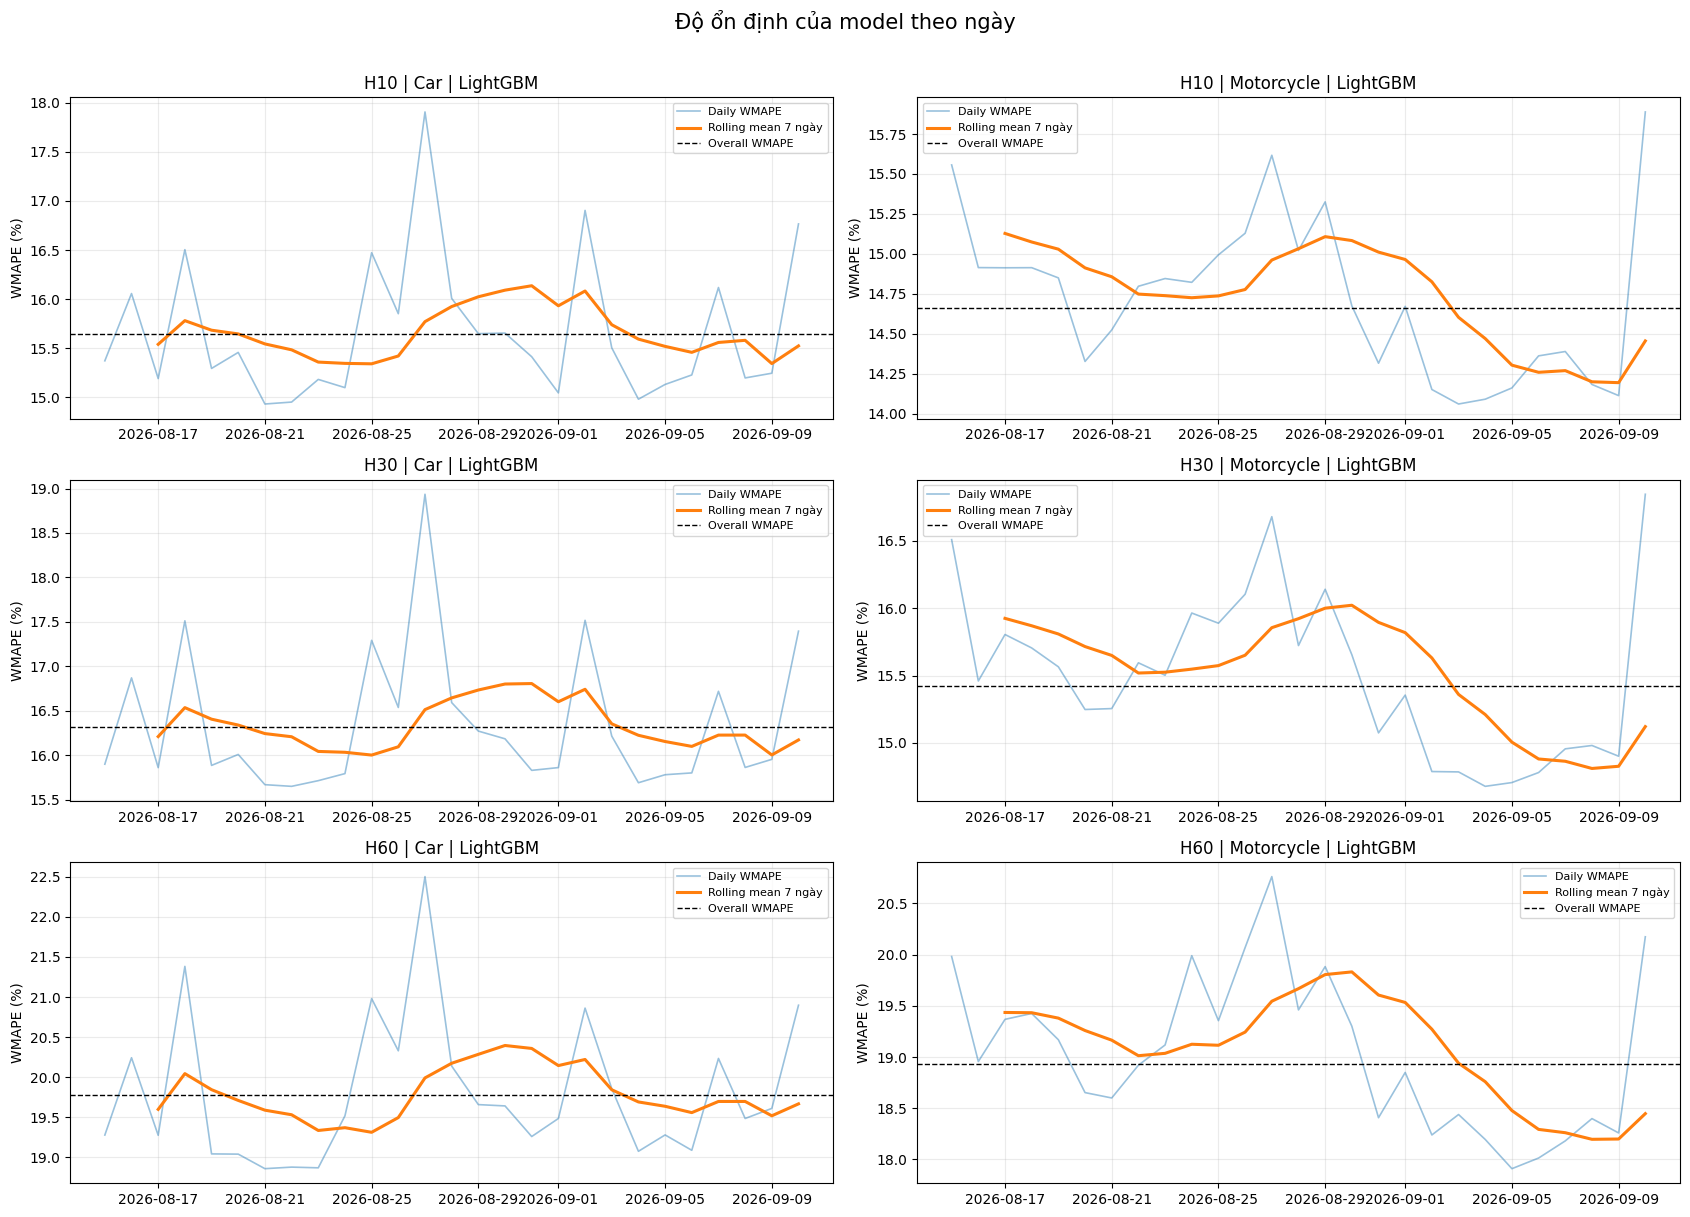

In [81]:
# 3. DAILY STABILITY + DRIFT
def build_daily_metrics(frame):
    daily = (
        frame.groupby("date", as_index=False)
        .agg(
            rows=("actual", "size"),
            actual_volume=("actual", "sum"),
            predicted_volume=("prediction", "sum"),
            absolute_error=("abs_error", "sum"),
            signed_error=("error", "sum"),
        )
        .sort_values("date")
    )
    daily["WMAPE_%"] = 100.0 * daily["absolute_error"] / daily["actual_volume"]
    daily["bias_%"] = 100.0 * daily["signed_error"] / daily["actual_volume"]
    daily["WMAPE_7d_mean"] = daily["WMAPE_%"].rolling(7, min_periods=3).mean()
    daily["WMAPE_7d_std"] = daily["WMAPE_%"].rolling(7, min_periods=3).std()
    return daily


DAILY_DIAGNOSTICS = {}
stability_rows = []

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        frame = get_diagnostic_frame(horizon, mode)
        daily = build_daily_metrics(frame)
        DAILY_DIAGNOSTICS[(horizon, mode)] = daily

        midpoint = max(1, len(daily) // 2)
        first_half = daily.iloc[:midpoint]
        second_half = daily.iloc[midpoint:]
        first_wmape = 100.0 * safe_divide(
            first_half["absolute_error"].sum(), first_half["actual_volume"].sum()
        )
        second_wmape = 100.0 * safe_divide(
            second_half["absolute_error"].sum(), second_half["actual_volume"].sum()
        )

        x = np.arange(len(daily), dtype="float64")
        slope = (
            np.polyfit(x, daily["WMAPE_%"].to_numpy(), 1)[0]
            if len(daily) >= 2
            else np.nan
        )
        mean_daily = daily["WMAPE_%"].mean()
        std_daily = daily["WMAPE_%"].std(ddof=1)
        cv_daily = safe_divide(std_daily, mean_daily)
        drift = second_wmape - first_wmape

        stability_rows.append(
            {
                "horizon": horizon,
                "travel_mode": mode,
                "model": selected_model_label(horizon),
                "days": len(daily),
                "daily_WMAPE_mean_%": mean_daily,
                "daily_WMAPE_std_pp": std_daily,
                "daily_WMAPE_CV": cv_daily,
                "daily_WMAPE_min_%": daily["WMAPE_%"].min(),
                "daily_WMAPE_max_%": daily["WMAPE_%"].max(),
                "first_half_WMAPE_%": first_wmape,
                "second_half_WMAPE_%": second_wmape,
                "drift_pp": drift,
                "slope_pp_per_day": slope,
                "drift_alert": abs(drift) > DRIFT_ALERT_PP,
                "cv_alert": cv_daily > CV_ALERT,
            }
        )

        del frame
        gc.collect()

STABILITY_SUMMARY = pd.DataFrame(stability_rows)
display_rounded(
    STABILITY_SUMMARY,
    {
        "daily_WMAPE_mean_%": 2,
        "daily_WMAPE_std_pp": 2,
        "daily_WMAPE_CV": 3,
        "daily_WMAPE_min_%": 2,
        "daily_WMAPE_max_%": 2,
        "first_half_WMAPE_%": 2,
        "second_half_WMAPE_%": 2,
        "drift_pp": 2,
        "slope_pp_per_day": 3,
    },
)

fig, axes = plt.subplots(3, 2, figsize=(17, 12), sharex=False)
for row_index, horizon in enumerate(HORIZON_ORDER):
    for column_index, mode in enumerate(MODE_ORDER):
        ax = axes[row_index, column_index]
        daily = DAILY_DIAGNOSTICS[(horizon, mode)]
        ax.plot(
            daily["date"],
            daily["WMAPE_%"],
            alpha=0.45,
            linewidth=1.2,
            label="Daily WMAPE",
        )
        ax.plot(
            daily["date"],
            daily["WMAPE_7d_mean"],
            linewidth=2.2,
            label="Rolling mean 7 ngày",
        )
        overall = ERROR_SUMMARY_SELECTED.query(
            "horizon == @horizon and travel_mode == @mode"
        )["WMAPE_%"].iloc[0]
        ax.axhline(
            overall, color="black", linestyle="--", linewidth=1, label="Overall WMAPE"
        )
        ax.set_title(f"{horizon} | {mode} | {selected_model_label(horizon)}")
        ax.set_ylabel("WMAPE (%)")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
fig.suptitle("Độ ổn định của model theo ngày", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


### 9.4. Weakness và peak: khi nào, ở đâu?

Cell dưới trả lời bốn câu hỏi:

1. Model có giữ được chất lượng khi demand ở top 10% không?
2. Peak thường xuất hiện vào giờ nào và tại hex nào?
3. Model yếu nhất vào giờ/thứ nào và tại hex nào?
4. Những timestamp–hex nào tạo ra sai số tuyệt đối lớn nhất?

Peak precision/recall được tính bằng cùng ngưỡng P90 trên actual và prediction.

In [82]:
# 4. PEAK PERFORMANCE + WEAKNESS BY TIME/HEX
def grouped_diagnostics(frame, group_columns):
    grouped = frame.groupby(group_columns, as_index=False, observed=True).agg(
        rows=("actual", "size"),
        actual_mean=("actual", "mean"),
        actual_volume=("actual", "sum"),
        predicted_volume=("prediction", "sum"),
        absolute_error=("abs_error", "sum"),
        signed_error=("error", "sum"),
        peak_rate=("is_peak", "mean"),
    )
    grouped["WMAPE_%"] = 100.0 * grouped["absolute_error"] / grouped["actual_volume"]
    grouped["bias_%"] = 100.0 * grouped["signed_error"] / grouped["actual_volume"]
    grouped["peak_rate_%"] = 100.0 * grouped["peak_rate"]
    return grouped


peak_performance_rows = []
peak_hour_parts = []
peak_weekday_parts = []
peak_hex_parts = []
weak_hour_parts = []
weak_weekday_parts = []
weak_hex_parts = []
worst_case_parts = []
peak_worst_case_parts = []

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        frame = get_diagnostic_frame(horizon, mode)
        threshold = frame["actual"].quantile(PEAK_QUANTILE)
        frame["is_peak"] = frame["actual"] >= threshold
        frame["predicted_peak"] = frame["prediction"] >= threshold

        true_peak = frame["is_peak"].to_numpy()
        predicted_peak = frame["predicted_peak"].to_numpy()
        tp = int(np.sum(true_peak & predicted_peak))
        fp = int(np.sum(~true_peak & predicted_peak))
        fn = int(np.sum(true_peak & ~predicted_peak))
        precision = safe_divide(tp, tp + fp)
        recall = safe_divide(tp, tp + fn)
        f1 = safe_divide(2 * precision * recall, precision + recall)

        peak_metrics = metric_dict(
            frame.loc[frame["is_peak"], "actual"],
            frame.loc[frame["is_peak"], "prediction"],
        )
        nonpeak_metrics = metric_dict(
            frame.loc[~frame["is_peak"], "actual"],
            frame.loc[~frame["is_peak"], "prediction"],
        )
        peak_performance_rows.append(
            {
                "horizon": horizon,
                "travel_mode": mode,
                "model": selected_model_label(horizon),
                "peak_threshold_P90": threshold,
                "peak_rows": int(frame["is_peak"].sum()),
                "peak_WMAPE_%": peak_metrics["WMAPE_%"],
                "nonpeak_WMAPE_%": nonpeak_metrics["WMAPE_%"],
                "peak_bias_%": peak_metrics["bias_%"],
                "peak_underprediction_rate_%": peak_metrics["underprediction_rate_%"],
                "peak_precision_%": 100.0 * precision,
                "peak_recall_%": 100.0 * recall,
                "peak_F1_%": 100.0 * f1,
            }
        )

        hour_stats = grouped_diagnostics(frame, ["hour"])
        weekday_stats = grouped_diagnostics(frame, ["day_of_week", "weekday"])
        hex_stats = grouped_diagnostics(frame, ["hex_id_7"])

        for table in (hour_stats, weekday_stats, hex_stats):
            table.insert(0, "travel_mode", mode)
            table.insert(0, "horizon", horizon)

        # Peak when/where: xếp theo actual_mean, kèm peak_rate và model WMAPE.
        peak_hour_parts.append(hour_stats.nlargest(5, "actual_mean"))
        peak_weekday_parts.append(weekday_stats.nlargest(3, "actual_mean"))
        peak_hex_parts.append(
            hex_stats.loc[hex_stats["rows"] >= MIN_HEX_ROWS].nlargest(10, "actual_mean")
        )

        # Weakness: xếp theo WMAPE sau khi loại nhóm có quá ít quan sát.
        weak_hour_parts.append(
            hour_stats.loc[hour_stats["rows"] >= MIN_TIME_GROUP_ROWS].nlargest(
                5, "WMAPE_%"
            )
        )
        weak_weekday_parts.append(
            weekday_stats.loc[weekday_stats["rows"] >= MIN_TIME_GROUP_ROWS].nlargest(
                3, "WMAPE_%"
            )
        )
        weak_hex_parts.append(
            hex_stats.loc[hex_stats["rows"] >= MIN_HEX_ROWS].nlargest(10, "WMAPE_%")
        )

        case_columns = [
            "bucket_start",
            "hex_id_7",
            "actual",
            "prediction",
            "error",
            "abs_error",
            "hour",
            "weekday",
        ]
        worst = frame.nlargest(10, "abs_error")[case_columns].copy()
        worst.insert(0, "travel_mode", mode)
        worst.insert(0, "horizon", horizon)
        worst_case_parts.append(worst)

        peak_worst = (
            frame.loc[frame["is_peak"]].nlargest(10, "abs_error")[case_columns].copy()
        )
        peak_worst.insert(0, "travel_mode", mode)
        peak_worst.insert(0, "horizon", horizon)
        peak_worst_case_parts.append(peak_worst)

        del frame, hour_stats, weekday_stats, hex_stats
        gc.collect()

PEAK_PERFORMANCE = pd.DataFrame(peak_performance_rows)
TOP_PEAK_HOURS = pd.concat(peak_hour_parts, ignore_index=True)
TOP_PEAK_WEEKDAYS = pd.concat(peak_weekday_parts, ignore_index=True)
TOP_PEAK_HEX = pd.concat(peak_hex_parts, ignore_index=True)
WEAK_HOURS = pd.concat(weak_hour_parts, ignore_index=True)
WEAK_WEEKDAYS = pd.concat(weak_weekday_parts, ignore_index=True)
WEAK_HEX = pd.concat(weak_hex_parts, ignore_index=True)
WORST_CASES = pd.concat(worst_case_parts, ignore_index=True)
PEAK_WORST_CASES = pd.concat(peak_worst_case_parts, ignore_index=True)

print("1) Hiệu quả của model trong vùng peak")
display_rounded(
    PEAK_PERFORMANCE,
    {
        "peak_threshold_P90": 2,
        "peak_WMAPE_%": 2,
        "nonpeak_WMAPE_%": 2,
        "peak_bias_%": 2,
        "peak_underprediction_rate_%": 2,
        "peak_precision_%": 2,
        "peak_recall_%": 2,
        "peak_F1_%": 2,
    },
)

print("2) Peak thường xảy ra khi nào? (top giờ theo actual_mean)")
display_rounded(
    TOP_PEAK_HOURS[
        [
            "horizon",
            "travel_mode",
            "hour",
            "rows",
            "actual_mean",
            "peak_rate_%",
            "WMAPE_%",
            "bias_%",
        ]
    ],
    {
        "actual_mean": 2,
        "peak_rate_%": 2,
        "WMAPE_%": 2,
        "bias_%": 2,
    },
)

print("2b) Peak thường rơi vào thứ nào? (top theo actual_mean)")
display_rounded(
    TOP_PEAK_WEEKDAYS[
        [
            "horizon",
            "travel_mode",
            "weekday",
            "rows",
            "actual_mean",
            "peak_rate_%",
            "WMAPE_%",
            "bias_%",
        ]
    ],
    {
        "actual_mean": 2,
        "peak_rate_%": 2,
        "WMAPE_%": 2,
        "bias_%": 2,
    },
)

print("3) Peak thường xảy ra ở đâu? (top hex theo actual_mean)")
display_rounded(
    TOP_PEAK_HEX[
        [
            "horizon",
            "travel_mode",
            "hex_id_7",
            "rows",
            "actual_mean",
            "peak_rate_%",
            "WMAPE_%",
            "bias_%",
        ]
    ],
    {
        "actual_mean": 2,
        "peak_rate_%": 2,
        "WMAPE_%": 2,
        "bias_%": 2,
    },
)

print("4) Model yếu vào giờ nào? (top WMAPE)")
display_rounded(
    WEAK_HOURS[
        [
            "horizon",
            "travel_mode",
            "hour",
            "rows",
            "actual_mean",
            "WMAPE_%",
            "bias_%",
            "peak_rate_%",
        ]
    ],
    {
        "actual_mean": 2,
        "WMAPE_%": 2,
        "bias_%": 2,
        "peak_rate_%": 2,
    },
)

print("4b) Model yếu vào thứ nào? (top WMAPE)")
display_rounded(
    WEAK_WEEKDAYS[
        [
            "horizon",
            "travel_mode",
            "weekday",
            "rows",
            "actual_mean",
            "WMAPE_%",
            "bias_%",
            "peak_rate_%",
        ]
    ],
    {
        "actual_mean": 2,
        "WMAPE_%": 2,
        "bias_%": 2,
        "peak_rate_%": 2,
    },
)

print("5) Model yếu ở hex nào? (top WMAPE, đã lọc số dòng tối thiểu)")
display_rounded(
    WEAK_HEX[
        [
            "horizon",
            "travel_mode",
            "hex_id_7",
            "rows",
            "actual_mean",
            "actual_volume",
            "WMAPE_%",
            "bias_%",
        ]
    ],
    {
        "actual_mean": 2,
        "actual_volume": 0,
        "WMAPE_%": 2,
        "bias_%": 2,
    },
)

print("6) Các case có absolute error lớn nhất")
display_rounded(
    WORST_CASES,
    {
        "actual": 2,
        "prediction": 2,
        "error": 2,
        "abs_error": 2,
    },
)


1) Hiệu quả của model trong vùng peak


,horizon,travel_mode,model,peak_threshold_P90,peak_rows,peak_WMAPE_%,nonpeak_WMAPE_%,peak_bias_%,peak_underprediction_rate_%,peak_precision_%,peak_recall_%,peak_F1_%
0,H10,Car,LightGBM,26.0,58573,15.09,16.26,-4.40,59.75,91.49,88.74,90.10
1,H10,Motorcycle,LightGBM,50.0,51080,13.13,16.24,-3.87,60.52,90.90,89.05,89.96
2,H30,Car,LightGBM,79.0,56761,15.69,16.97,-4.66,59.38,89.48,89.44,89.46
3,H30,Motorcycle,LightGBM,149.0,51090,13.62,17.26,-2.85,57.91,89.26,89.69,89.47
4,H60,Car,LightGBM,158.0,56839,19.13,20.45,-7.58,62.79,87.08,86.93,87.00
5,H60,Motorcycle,LightGBM,299.0,50798,16.68,21.18,-4.41,59.77,86.85,87.40,87.12


2) Peak thường xảy ra khi nào? (top giờ theo actual_mean)


,horizon,travel_mode,hour,rows,actual_mean,peak_rate_%,WMAPE_%,bias_%
0,H10,Car,18,24000,26.05,29.83,15.08,-1.11
1,H10,Car,17,24000,24.90,27.99,15.22,-1.32
2,H10,Car,8,23112,19.98,22.48,14.85,-1.90
3,H10,Car,19,24000,19.33,21.68,14.97,-0.82
4,H10,Car,7,23112,18.30,20.38,15.16,-1.20
5,H10,Motorcycle,18,21462,44.45,28.98,13.48,-0.43
6,H10,Motorcycle,17,21462,42.25,26.89,13.35,-0.87
7,H10,Motorcycle,8,20646,35.77,22.74,13.87,-0.68
8,H10,Motorcycle,19,21462,34.01,21.27,13.95,-0.87
9,H10,Motorcycle,7,20646,32.48,20.74,14.22,-1.49


2b) Peak thường rơi vào thứ nào? (top theo actual_mean)


...

,horizon,travel_mode,weekday,rows,actual_mean,WMAPE_%,bias_%,peak_rate_%
0,H10,Car,Thứ 5,86088,10.53,16.31,-1.69,9.94
1,H10,Car,Thứ 4,85662,10.64,15.88,-1.35,10.10
2,H10,Car,Thứ 3,85377,11.00,15.70,-1.76,10.18
3,H10,Motorcycle,Thứ 7,68512,19.57,14.87,-1.36,10.66
4,H10,Motorcycle,Thứ 5,76155,19.19,14.86,-1.72,10.13
5,H10,Motorcycle,Chủ nhật,76305,18.61,14.67,-1.34,9.76
6,H30,Car,Thứ 5,85732,31.61,17.02,-0.99,9.59
7,H30,Car,Thứ 4,85622,31.93,16.53,-0.76,9.84
8,H30,Car,Thứ 3,85344,33.02,16.52,-1.29,9.92
9,H30,Motorcycle,Thứ 5,75854,57.65,15.75,-0.65,10.19


5) Model yếu ở hex nào? (top WMAPE, đã lọc số dòng tối thiểu)


,horizon,travel_mode,hex_id_7,rows,actual_mean,actual_volume,WMAPE_%,bias_%
0,H10,Car,8765b1932ffffff,717,4.02,2882.0,18.54,-1.81
1,H10,Car,8765b539bffffff,3830,3.04,11634.0,18.15,0.48
2,H10,Car,8765b529dffffff,285,8.54,2433.0,18.06,-8.24
3,H10,Car,8765b56e5ffffff,717,8.30,5954.0,17.83,-6.33
4,H10,Car,8765b56f5ffffff,3110,2.18,6781.0,17.75,2.59
5,H10,Car,8765b19a5ffffff,950,2.79,2647.0,17.74,2.96
6,H10,Car,8765b5619ffffff,1238,3.72,4610.0,17.64,0.63
7,H10,Car,8765b1920ffffff,3830,2.46,9419.0,17.54,1.53
8,H10,Car,8765b19b5ffffff,2445,3.18,7776.0,17.50,-2.52
9,H10,Car,8765b576cffffff,429,3.88,1664.0,17.42,3.04


6) Các case có absolute error lớn nhất


,horizon,travel_mode,bucket_start,hex_id_7,actual,prediction,error,abs_error,hour,weekday
0,H10,Car,2026-09-10 23:50:00+07:00,8765b564cffffff,1000.0,161.49,-838.51,838.51,23,Thứ 5
1,H10,Car,2026-09-07 18:30:00+07:00,8765b5666ffffff,1000.0,203.97,-796.03,796.03,18,Thứ 2
2,H10,Car,2026-09-02 18:20:00+07:00,8765b5662ffffff,1000.0,293.00,-707.00,707.00,18,Thứ 4
3,H10,Car,2026-09-07 17:40:00+07:00,8765b5666ffffff,1000.0,308.34,-691.66,691.66,17,Thứ 2
4,H10,Car,2026-09-07 17:30:00+07:00,8765b5666ffffff,1000.0,310.06,-689.94,689.94,17,Thứ 2
5,H10,Car,2026-09-02 18:10:00+07:00,8765b5662ffffff,1000.0,314.35,-685.65,685.65,18,Thứ 4
6,H10,Car,2026-09-02 18:30:00+07:00,8765b5662ffffff,681.0,285.14,-395.86,395.86,18,Thứ 4
7,H10,Car,2026-08-18 23:20:00+07:00,8765b5645ffffff,376.0,98.52,-277.48,277.48,23,Thứ 3
8,H10,Car,2026-08-18 23:10:00+07:00,8765b5645ffffff,321.0,75.24,-245.76,245.76,23,Thứ 3
9,H10,Car,2026-09-10 23:40:00+07:00,8765b564cffffff,360.0,126.46,-233.54,233.54,23,Thứ 5


### 9.5. Demand trend và khả năng bám trend

So sánh tổng demand thực tế và dự đoán theo ngày. Bảng tóm tắt cung cấp:

- Tốc độ thay đổi trung bình mỗi ngày của actual và prediction.
- Mức thay đổi từ 7 ngày đầu sang 7 ngày cuối.
- Correlation giữa daily actual và daily prediction.
- Bias trên toàn giai đoạn.

,horizon,travel_mode,model,days,actual_slope_%_per_day,prediction_slope_%_per_day,actual_change_first7_last7_%,prediction_change_first7_last7_%,daily_volume_correlation,total_bias_%
0,H10,Car,LightGBM,27,1.716,1.514,36.29,31.60,0.9988,-1.54
1,H10,Motorcycle,LightGBM,27,1.425,1.250,26.52,22.84,0.9989,-1.12
2,H30,Car,LightGBM,27,1.712,1.518,36.22,31.76,0.9981,-1.07
3,H30,Motorcycle,LightGBM,27,1.424,1.283,26.53,23.73,0.9985,-0.08
4,H60,Car,LightGBM,27,1.710,1.421,36.21,29.41,0.9956,-1.86
5,H60,Motorcycle,LightGBM,27,1.426,1.220,26.58,22.50,0.9965,-0.18


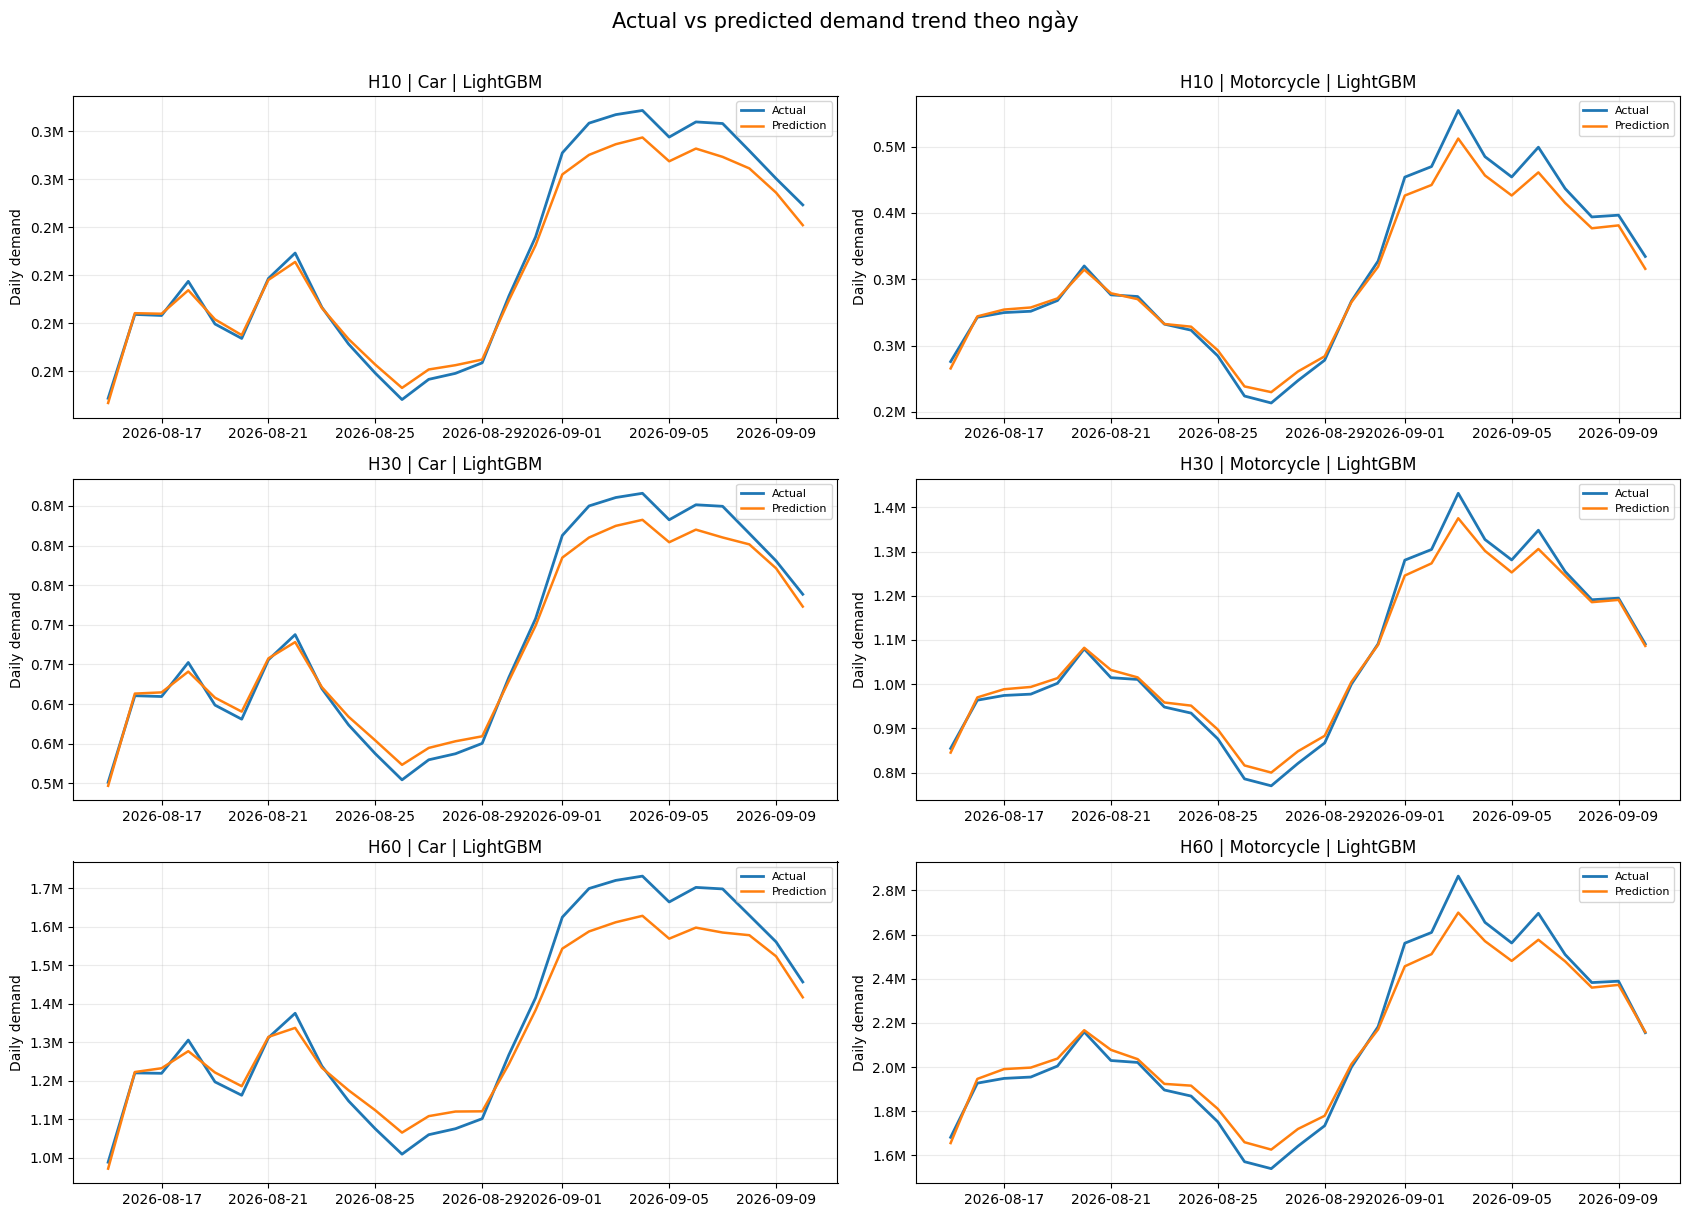

In [83]:
# 5. DAILY DEMAND TREND
trend_rows = []
DAILY_TREND = {}

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        daily = DAILY_DIAGNOSTICS[(horizon, mode)].copy()
        x = np.arange(len(daily), dtype="float64")

        actual_slope = (
            np.polyfit(x, daily["actual_volume"].to_numpy(), 1)[0]
            if len(daily) >= 2
            else np.nan
        )
        prediction_slope = (
            np.polyfit(x, daily["predicted_volume"].to_numpy(), 1)[0]
            if len(daily) >= 2
            else np.nan
        )
        actual_mean = daily["actual_volume"].mean()
        prediction_mean = daily["predicted_volume"].mean()
        window = min(7, max(1, len(daily) // 2))

        actual_first = daily["actual_volume"].head(window).mean()
        actual_last = daily["actual_volume"].tail(window).mean()
        prediction_first = daily["predicted_volume"].head(window).mean()
        prediction_last = daily["predicted_volume"].tail(window).mean()

        correlation = daily[["actual_volume", "predicted_volume"]].corr().iloc[0, 1]
        total_bias = 100.0 * safe_divide(
            daily["predicted_volume"].sum() - daily["actual_volume"].sum(),
            daily["actual_volume"].sum(),
        )

        daily["actual_index_100"] = 100.0 * daily["actual_volume"] / actual_first
        daily["prediction_index_100"] = (
            100.0 * daily["predicted_volume"] / prediction_first
        )
        DAILY_TREND[(horizon, mode)] = daily

        trend_rows.append(
            {
                "horizon": horizon,
                "travel_mode": mode,
                "model": selected_model_label(horizon),
                "days": len(daily),
                "actual_slope_%_per_day": 100.0
                * safe_divide(actual_slope, actual_mean),
                "prediction_slope_%_per_day": 100.0
                * safe_divide(prediction_slope, prediction_mean),
                "actual_change_first7_last7_%": 100.0
                * safe_divide(actual_last - actual_first, actual_first),
                "prediction_change_first7_last7_%": 100.0
                * safe_divide(prediction_last - prediction_first, prediction_first),
                "daily_volume_correlation": correlation,
                "total_bias_%": total_bias,
            }
        )

TREND_SUMMARY = pd.DataFrame(trend_rows)
display_rounded(
    TREND_SUMMARY,
    {
        "actual_slope_%_per_day": 3,
        "prediction_slope_%_per_day": 3,
        "actual_change_first7_last7_%": 2,
        "prediction_change_first7_last7_%": 2,
        "daily_volume_correlation": 4,
        "total_bias_%": 2,
    },
)

fig, axes = plt.subplots(3, 2, figsize=(17, 12), sharex=False)
for row_index, horizon in enumerate(HORIZON_ORDER):
    for column_index, mode in enumerate(MODE_ORDER):
        ax = axes[row_index, column_index]
        daily = DAILY_TREND[(horizon, mode)]
        ax.plot(daily["date"], daily["actual_volume"], linewidth=2.0, label="Actual")
        ax.plot(
            daily["date"], daily["predicted_volume"], linewidth=1.8, label="Prediction"
        )
        ax.set_title(f"{horizon} | {mode} | {selected_model_label(horizon)}")
        ax.set_ylabel("Daily demand")
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda value, _: f"{value / 1e6:.1f}M")
        )
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
fig.suptitle("Actual vs predicted demand trend theo ngày", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


### 9.6. Tóm tắt tự động và export kết quả

nhận xét ngắn cho từng horizon/mode và xuất các bảng diagnostics
thành CSV để dùng trực tiếp trong báo cáo.

In [84]:
# 6. AUTO SUMMARY + EXPORT CSV
def first_matching(table, horizon, mode, sort_column=None, ascending=False):
    subset = table.loc[(table["horizon"] == horizon) & (table["travel_mode"] == mode)]
    if sort_column is not None:
        subset = subset.sort_values(sort_column, ascending=ascending)
    return None if subset.empty else subset.iloc[0]


print("=" * 72)
print("TÓM TẮT MODEL DIAGNOSTICS")
print("=" * 72)

for horizon in HORIZON_ORDER:
    for mode in MODE_ORDER:
        overall = first_matching(ERROR_SUMMARY_SELECTED, horizon, mode)
        stability = first_matching(STABILITY_SUMMARY, horizon, mode)
        peak = first_matching(PEAK_PERFORMANCE, horizon, mode)
        weak_hour = first_matching(WEAK_HOURS, horizon, mode, "WMAPE_%")
        weak_hex = first_matching(WEAK_HEX, horizon, mode, "WMAPE_%")
        trend = first_matching(TREND_SUMMARY, horizon, mode)

        stability_note = (
            "CẦN KIỂM TRA"
            if (stability["drift_alert"] or stability["cv_alert"])
            else "ổn định theo ngưỡng cấu hình"
        )

        trend_direction = (
            "tăng"
            if trend["actual_slope_%_per_day"] > 0
            else "giảm" if trend["actual_slope_%_per_day"] < 0 else "đi ngang"
        )

        print(f"\n{horizon} | {mode} | {selected_model_label(horizon)}")
        print(
            f"- Overall WMAPE: {overall['WMAPE_%']:.2f}% | "
            f"bias: {overall['bias_%']:+.2f}% | "
            f"underprediction: {overall['underprediction_rate_%']:.2f}%"
        )
        print(
            f"- Stability: {stability_note}; daily std "
            f"{stability['daily_WMAPE_std_pp']:.2f} pp; "
            f"drift đầu-cuối {stability['drift_pp']:+.2f} pp."
        )
        print(
            f"- Peak >= {peak['peak_threshold_P90']:.2f}: WMAPE "
            f"{peak['peak_WMAPE_%']:.2f}%; bias {peak['peak_bias_%']:+.2f}%; "
            f"recall {peak['peak_recall_%']:.2f}%."
        )
        if weak_hour is not None:
            print(
                f"- Weakest hour: {int(weak_hour['hour']):02d}:00 "
                f"(WMAPE {weak_hour['WMAPE_%']:.2f}%)."
            )
        else:
            print("- Weakest hour: chưa đủ số quan sát theo ngưỡng cấu hình.")

        if weak_hex is not None:
            print(
                f"- Weakest hex: {weak_hex['hex_id_7']} "
                f"(WMAPE {weak_hex['WMAPE_%']:.2f}%)."
            )
        else:
            print("- Weakest hex: chưa đủ số quan sát theo ngưỡng cấu hình.")
        print(
            f"- Actual trend: {trend_direction}, "
            f"{trend['actual_slope_%_per_day']:+.3f}%/ngày; "
            f"daily actual-prediction correlation "
            f"{trend['daily_volume_correlation']:.4f}."
        )

base_output = (
    Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
)
DIAGNOSTICS_OUTPUT_DIR = base_output / "model_diagnostics"
DIAGNOSTICS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

export_tables = {
    "error_summary_all_models.csv": ERROR_SUMMARY_ALL_MODELS,
    "error_by_demand_band.csv": ERROR_BY_DEMAND_BAND,
    "stability_summary.csv": STABILITY_SUMMARY,
    "peak_performance.csv": PEAK_PERFORMANCE,
    "top_peak_hours.csv": TOP_PEAK_HOURS,
    "top_peak_weekdays.csv": TOP_PEAK_WEEKDAYS,
    "top_peak_hex.csv": TOP_PEAK_HEX,
    "weak_hours.csv": WEAK_HOURS,
    "weak_weekdays.csv": WEAK_WEEKDAYS,
    "weak_hex.csv": WEAK_HEX,
    "worst_cases.csv": WORST_CASES,
    "peak_worst_cases.csv": PEAK_WORST_CASES,
    "trend_summary.csv": TREND_SUMMARY,
}

for filename, table in export_tables.items():
    table.to_csv(DIAGNOSTICS_OUTPUT_DIR / filename, index=False)

print(f"\nĐã export {len(export_tables)} bảng vào: {DIAGNOSTICS_OUTPUT_DIR}")


TÓM TẮT MODEL DIAGNOSTICS

H10 | Car | LightGBM
- Overall WMAPE: 15.64% | bias: -1.54% | underprediction: 49.33%
- Stability: ổn định theo ngưỡng cấu hình; daily std 0.72 pp; drift đầu-cuối -0.06 pp.
- Peak >= 26.00: WMAPE 15.09%; bias -4.40%; recall 88.74%.
- Weakest hour: 05:00 (WMAPE 21.25%).
- Weakest hex: 8765b1932ffffff (WMAPE 18.54%).
- Actual trend: tăng, +1.716%/ngày; daily actual-prediction correlation 0.9988.

H10 | Motorcycle | LightGBM
- Overall WMAPE: 14.66% | bias: -1.12% | underprediction: 48.03%
- Stability: ổn định theo ngưỡng cấu hình; daily std 0.50 pp; drift đầu-cuối -0.43 pp.
- Peak >= 50.00: WMAPE 13.13%; bias -3.87%; recall 89.05%.
- Weakest hour: 05:00 (WMAPE 20.30%).
- Weakest hex: 8765b562effffff (WMAPE 21.96%).
- Actual trend: tăng, +1.425%/ngày; daily actual-prediction correlation 0.9989.

H30 | Car | LightGBM
- Overall WMAPE: 16.32% | bias: -1.07% | underprediction: 47.38%
- Stability: ổn định theo ngưỡng cấu hình; daily std 0.79 pp; drift đầu-cuối -0.15 p

## 10. Audit riêng sáu LightGBM direct — độ khớp và bão hòa

Chạy phần này **sau các cell train H10/H30/H60**. Mỗi cặp phương tiện × horizon lấy đúng model, feature, target và dòng test của chính nó. H30/H60 dự báo tổng 3/6 bucket bằng model riêng; không lấy prediction H10 làm input.

Ở các bảng dưới, dự đoán không âm được **làm tròn về số chuyến nguyên** bằng quy tắc 0,5 làm tròn lên. Tỷ lệ trùng là **trùng trên cùng một dòng**. Bên cạnh đó có tỷ lệ giống nhau của *phân bố tần suất* các giá trị; hai tỷ lệ này không tương đương. Các tỷ lệ lỗi tương đối chỉ dùng dòng có demand thực tế > 0; demand thực tế = 0 được thống kê riêng. H10, H30, H60 có target khác nhau nên so sánh sai số tuyệt đối cần xét theo từng horizon.

Test cố định chỉ dùng để **chẩn đoán**, không chọn cây/feature/tham số. Bảng bằng chứng bão hòa ở cuối dùng các lượt thử validation đã có; thí nghiệm bổ sung trên full train/validation là tùy chọn và tốn thời gian.


In [85]:
# 1. Khóa đúng sáu LightGBM direct và xác thực input/output từng model.
import numpy as np
import pandas as pd

LIGHT_AUDIT_MODES = ("Car", "Motorcycle")
LIGHT_AUDIT_HORIZONS = (10, 30, 60)
LIGHT_AUDIT_CASES = {}
_required = (
    "MODE_FRAMES",
    "FEATURES",
    "MODELS",
    "TEST_RESULTS",
    "H30_DATA",
    "H30_MODELS",
    "H60_DATA",
    "H60_MODELS",
    "make_time_split",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(f"Hãy chạy các cell chuẩn bị dữ liệu/train trước: {_missing}")

for _mode in LIGHT_AUDIT_MODES:
    for _h in LIGHT_AUDIT_HORIZONS:
        if _h == 10:
            _frame = MODE_FRAMES[_mode]
            _features = list(FEATURES)
            _target = "demand_h10"
            _indices = make_time_split(_frame, 10)["test_index"]
            _model = MODELS[_mode]["LightGBM"]
            _result = TEST_RESULTS[_mode]
        else:
            _info = (H30_DATA if _h == 30 else H60_DATA)[_mode]
            _frame = _info["frame"]
            _features = list(_info["features"])
            _target = _info["target"]
            _indices = _info["test_index"]
            _model = (H30_MODELS if _h == 30 else H60_MODELS)[_mode]["LightGBM"]
            _store = globals().get(
                "DIRECT_H30_RESULTS" if _h == 30 else "DIRECT_H60_RESULTS"
            )
            if _store is None:
                _store = H30_RESULTS if _h == 30 else H60_RESULTS
            _result = _store[_mode]

        _bad_features = [
            c
            for c in _features
            if c.startswith("prediction")
            or c in {"demand_h10", "demand_h30", "demand_h60", "total_demand"}
        ]
        if _bad_features or len(_features) != len(set(_features)):
            raise ValueError(
                f"{_mode} H{_h}: feature chứa target/prediction hoặc trùng: {_bad_features}"
            )
        if "prediction_LightGBM" not in _result:
            raise RuntimeError(
                f"{_mode} H{_h}: thiếu prediction_LightGBM; hãy train LightGBM của horizon này"
            )
        if len(_result) != len(_indices) or len(_features) != _model.n_features_in_:
            raise ValueError(
                f"{_mode} H{_h}: số hàng test hoặc số feature không khớp model"
            )
        _expected = _frame.iloc[_indices]
        for _column in (_target, "bucket_start", "hex_id_7"):
            if not np.array_equal(
                _result[_column].to_numpy(), _expected[_column].to_numpy()
            ):
                raise ValueError(f"{_mode} H{_h}: lệch thứ tự test tại {_column}")

        # Tái dự đoán vài vị trí của đúng model/feature để bắt cột prediction cũ.
        _probe = np.unique(
            np.linspace(0, len(_indices) - 1, min(16, len(_indices)), dtype=int)
        )
        _x = _frame.iloc[_indices[_probe]][_features]
        if _h != 10:  # Hai model này ban đầu fit trên NumPy float32.
            _x = _x.to_numpy(dtype=np.float32, copy=False)
        _again = np.clip(_model.predict(_x), 0, None)
        _saved = _result["prediction_LightGBM"].iloc[_probe].to_numpy()
        if not np.allclose(_again, _saved, rtol=1e-5, atol=1e-4):
            raise ValueError(
                f"{_mode} H{_h}: prediction không thuộc model/feature hiện tại"
            )

        LIGHT_AUDIT_CASES[(_mode, _h)] = {
            "frame": _frame,
            "result": _result,
            "test_index": _indices,
            "features": _features,
            "target": _target,
            "model": _model,
        }
        print(
            f"✓ {_mode:10s} H{_h}: {len(_result):,} test, {len(_features)} feature, model riêng"
        )

if len({id(v["model"]) for v in LIGHT_AUDIT_CASES.values()}) != 6:
    raise ValueError(
        "Có ít nhất hai cặp mode/horizon đang dùng chung cùng một model object"
    )


def light_audit_arrays(case):
    actual_raw = case["result"][case["target"]].to_numpy(dtype=np.float64)
    predicted_raw = case["result"]["prediction_LightGBM"].to_numpy(dtype=np.float64)
    if (
        not np.isfinite(actual_raw).all()
        or not np.isfinite(predicted_raw).all()
        or (actual_raw < 0).any()
        or not np.allclose(actual_raw, np.rint(actual_raw), atol=1e-6)
    ):
        raise ValueError(
            "Target/prediction có NaN, giá trị âm hoặc target không phải số chuyến nguyên"
        )
    actual = np.rint(actual_raw).astype(np.int64)
    prediction = np.floor(np.maximum(predicted_raw, 0) + 0.5).astype(np.int64)
    return actual, prediction


✓ Car        H10: 567,283 test, 21 feature, model riêng


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✓ Car        H30: 566,700 test, 24 feature, model riêng


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✓ Car        H60: 566,010 test, 24 feature, model riêng
✓ Motorcycle H10: 507,116 test, 21 feature, model riêng


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✓ Motorcycle H30: 506,604 test, 24 feature, model riêng
✓ Motorcycle H60: 505,989 test, 24 feature, model riêng


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 10.1. Đếm trùng, lệch tổng số chuyến và độ lớn sai số

**Lệch tổng** = (tổng dự đoán − tổng thực tế) / tổng thực tế; hai phía có thể bù nhau. **WMAPE** cộng trị tuyệt đối lỗi của từng dòng rồi chia tổng demand. **Trùng theo dòng** đòi hỏi dự đoán nguyên bằng đúng thực tế tại cùng hex/bucket. **Giống phân bố** chỉ so tần suất các số chuyến sau khi bỏ thứ tự dòng, nên có thể cao ngay cả khi trùng theo dòng thấp.


In [86]:
# 2. Tất cả phép đo dưới đây dùng prediction đã làm tròn thành số nguyên.
LIGHT_AUDIT_SUMMARY_ROWS = []
LIGHT_AUDIT_ERROR_ROWS = []
for (_mode, _h), _case in LIGHT_AUDIT_CASES.items():
    _y, _p = light_audit_arrays(_case)
    _diff = _p - _y
    _abs = np.abs(_diff)
    _positive = _y > 0
    _relative = 100 * _abs[_positive] / _y[_positive]  # y=0 được xử lý riêng.
    _y_counts = pd.Series(_y).value_counts(sort=False)
    _p_counts = pd.Series(_p).value_counts(sort=False)
    _common = (
        _y_counts.to_frame("y").join(_p_counts.to_frame("p"), how="outer").fillna(0)
    )
    _total_y = _y.sum(dtype=np.int64)

    LIGHT_AUDIT_SUMMARY_ROWS.append(
        {
            "mode": _mode,
            "horizon": f"H{_h}",
            "số_dòng": len(_y),
            "tổng_thực_tế": int(_total_y),
            "tổng_dự_đoán_nguyên": int(_p.sum(dtype=np.int64)),
            "lệch_tổng_%": (
                100 * _diff.sum(dtype=np.int64) / _total_y if _total_y else np.nan
            ),
            "WMAPE_nguyên_%": (
                100 * _abs.sum(dtype=np.int64) / _total_y if _total_y else np.nan
            ),
            "trùng_cùng_dòng_%": 100 * np.mean(_diff == 0),
            "giống_phân_bố_%": 100 * _common.min(axis=1).sum() / len(_y),
            "lệch_≤1_chuyến_%": 100 * np.mean(_abs <= 1),
            "lệch_≤2_chuyến_%": 100 * np.mean(_abs <= 2),
            "dự_đoán_thiếu_%": 100 * np.mean(_diff < 0),
            "dự_đoán_dư_%": 100 * np.mean(_diff > 0),
            "actual_0_dòng": int(np.sum(~_positive)),
            "actual_0_pred_>0_%": (
                100 * np.mean(_p[~_positive] > 0) if np.any(~_positive) else np.nan
            ),
            "actual_>0_pred_0_%": (
                100 * np.mean(_p[_positive] == 0) if np.any(_positive) else np.nan
            ),
        }
    )
    LIGHT_AUDIT_ERROR_ROWS.append(
        {
            "mode": _mode,
            "horizon": f"H{_h}",
            "dòng_actual_>0": int(_positive.sum()),
            "lệch_tương_đối_≤10%": (
                100 * np.mean(_relative <= 10) if len(_relative) else np.nan
            ),
            "10%_<lệch_≤25%": (
                100 * np.mean((10 < _relative) & (_relative <= 25))
                if len(_relative)
                else np.nan
            ),
            "25%_<lệch_≤50%": (
                100 * np.mean((25 < _relative) & (_relative <= 50))
                if len(_relative)
                else np.nan
            ),
            "lệch_tương_đối_>50%": (
                100 * np.mean(_relative > 50) if len(_relative) else np.nan
            ),
            "P50_lệch_%": np.percentile(_relative, 50) if len(_relative) else np.nan,
            "P90_lệch_%": np.percentile(_relative, 90) if len(_relative) else np.nan,
            "P95_lệch_%": np.percentile(_relative, 95) if len(_relative) else np.nan,
            "P95_lệch_chuyến": np.percentile(_abs, 95),
            "P99_lệch_chuyến": np.percentile(_abs, 99),
        }
    )

LIGHT_AUDIT_SUMMARY = pd.DataFrame(LIGHT_AUDIT_SUMMARY_ROWS)
LIGHT_AUDIT_ERRORS = pd.DataFrame(LIGHT_AUDIT_ERROR_ROWS)
print("Số chuyến, độ trùng và sai lệch (test cố định; LightGBM direct):")
display(LIGHT_AUDIT_SUMMARY.round(2))
print("Độ lệch thấp / trung bình / cao: các khoảng % có mẫu số là số dòng actual > 0:")
display(LIGHT_AUDIT_ERRORS.round(2))


Số chuyến, độ trùng và sai lệch (test cố định; LightGBM direct):


,mode,horizon,số_dòng,tổng_thực_tế,tổng_dự_đoán_nguyên,lệch_tổng_%,WMAPE_nguyên_%,trùng_cùng_dòng_%,giống_phân_bố_%,lệch_≤1_chuyến_%,lệch_≤2_chuyến_%,dự_đoán_thiếu_%,dự_đoán_dư_%,actual_0_dòng,actual_0_pred_>0_%,actual_>0_pred_0_%
0,Car,H10,567283,6121094,6025709,-1.56,15.34,46.92,91.51,73.94,83.60,25.75,27.33,1606,100.0,0.0
1,Car,H30,566700,18348135,18149665,-1.08,16.25,26.92,84.80,46.88,59.40,33.01,40.07,0,NaN,0.0
2,Car,H60,566010,36658959,35974666,-1.87,19.75,16.88,86.47,30.42,39.52,35.96,47.17,0,NaN,0.0
3,Motorcycle,H10,507116,9565973,9458653,-1.12,14.53,37.42,95.02,60.91,71.91,30.09,32.49,956,100.0,0.0
4,Motorcycle,H30,506604,28677145,28651413,-0.09,15.39,21.80,92.29,37.00,47.16,35.51,42.70,0,NaN,0.0
5,Motorcycle,H60,505989,57297912,57192256,-0.18,18.92,13.67,92.55,23.66,30.47,37.33,49.00,0,NaN,0.0


Độ lệch thấp / trung bình / cao: các khoảng % có mẫu số là số dòng actual > 0:


,mode,horizon,dòng_actual_>0,lệch_tương_đối_≤10%,10%_<lệch_≤25%,25%_<lệch_≤50%,lệch_tương_đối_>50%,P50_lệch_%,P90_lệch_%,P95_lệch_%,P95_lệch_chuyến,P99_lệch_chuyến
0,Car,H10,565677,55.84,23.13,17.28,3.75,5.56,40.00,50.00,7.0,18.0
1,Car,H30,566700,44.06,33.75,18.09,4.10,12.50,37.50,50.00,22.0,55.0
2,Car,H60,566010,39.06,33.23,21.26,6.46,15.38,43.24,57.14,54.0,136.0
3,Motorcycle,H10,506160,51.84,27.19,17.22,3.76,9.09,40.00,50.00,12.0,26.0
4,Motorcycle,H30,506604,42.84,33.51,19.00,4.65,12.82,38.89,50.00,38.0,82.0
5,Motorcycle,H60,505989,35.82,32.91,23.05,8.22,16.67,47.37,62.50,94.0,200.0


### 10.2. Phân bố số chuyến và những nhóm model còn yếu

Đếm riêng bao nhiêu dòng thực tế/dự đoán thuộc từng khoảng 0, 1, 2, 3–5, … . Bảng theo demand thực tế chia Low / Mid / Peak **riêng cho từng mode và horizon**; WMAPE cao ở Peak, thiên lệch dự đoán thiếu hoặc tuần sau kém hơn tuần trước là dấu hiệu cần cải thiện. Dòng thuộc nhóm 0 được xử lý riêng; không chia lỗi phần trăm cho 0.


In [87]:
# 3. Tần suất các giá trị, lỗi theo nhu cầu, độ ổn định giữa hai nửa test.
LIGHT_AUDIT_BINS = [-0.5, 0.5, 1.5, 2.5, 5.5, 10.5, 20.5, 50.5, 100.5, np.inf]
LIGHT_AUDIT_LABELS = ["0", "1", "2", "3–5", "6–10", "11–20", "21–50", "51–100", ">100"]
LIGHT_AUDIT_DISTRIBUTION_ROWS, LIGHT_AUDIT_BAND_ROWS, LIGHT_AUDIT_TIME_ROWS = [], [], []


def light_audit_group_metrics(y, p):
    d = p - y
    volume = y.sum(dtype=np.int64)
    return {
        "số_dòng": len(y),
        "tổng_thực_tế": int(volume),
        "WMAPE_%": 100 * np.abs(d).sum(dtype=np.int64) / volume if volume else np.nan,
        "lệch_tổng_%": 100 * d.sum(dtype=np.int64) / volume if volume else np.nan,
        "trùng_%": 100 * np.mean(d == 0) if len(d) else np.nan,
        "thiếu_%": 100 * np.mean(d < 0) if len(d) else np.nan,
    }


for (_mode, _h), _case in LIGHT_AUDIT_CASES.items():
    _y, _p = light_audit_arrays(_case)
    _actual_bins = pd.cut(_y, bins=LIGHT_AUDIT_BINS, labels=LIGHT_AUDIT_LABELS)
    _pred_bins = pd.cut(_p, bins=LIGHT_AUDIT_BINS, labels=LIGHT_AUDIT_LABELS)
    _actual_counts = pd.Series(_actual_bins).value_counts(sort=False)
    _pred_counts = pd.Series(_pred_bins).value_counts(sort=False)
    for _label in LIGHT_AUDIT_LABELS:
        _a, _b = int(_actual_counts[_label]), int(_pred_counts[_label])
        LIGHT_AUDIT_DISTRIBUTION_ROWS.append(
            {
                "mode": _mode,
                "horizon": f"H{_h}",
                "khoảng_chuyến": _label,
                "dòng_thực_tế": _a,
                "dòng_dự_đoán": _b,
                "lệch_số_dòng": _b - _a,
                "lệch_tỷ_trọng_pp": 100 * (_b - _a) / len(_y),
            }
        )

    _q50, _q90 = np.quantile(_y, [0.50, 0.90])
    for _label, _mask in (
        ("Low ≤ P50", _y <= _q50),
        ("Mid P50–P90", (_y > _q50) & (_y <= _q90)),
        ("Peak > P90", _y > _q90),
    ):
        if _mask.any():
            LIGHT_AUDIT_BAND_ROWS.append(
                {
                    "mode": _mode,
                    "horizon": f"H{_h}",
                    "nhóm": _label,
                    "ngưỡng_P50": _q50,
                    "ngưỡng_P90": _q90,
                    **light_audit_group_metrics(_y[_mask], _p[_mask]),
                }
            )

    # Cắt theo thời gian, không theo thứ tự hex trong frame.
    _times = pd.to_datetime(_case["result"]["bucket_start"])
    _middle = _times.min() + (_times.max() - _times.min()) / 2
    for _label, _mask in (
        ("Nửa đầu test", (_times <= _middle).to_numpy()),
        ("Nửa sau test", (_times > _middle).to_numpy()),
    ):
        if _mask.any():
            LIGHT_AUDIT_TIME_ROWS.append(
                {
                    "mode": _mode,
                    "horizon": f"H{_h}",
                    "giai_đoạn": _label,
                    **light_audit_group_metrics(_y[_mask], _p[_mask]),
                }
            )

LIGHT_AUDIT_DISTRIBUTION = pd.DataFrame(LIGHT_AUDIT_DISTRIBUTION_ROWS)
LIGHT_AUDIT_BANDS = pd.DataFrame(LIGHT_AUDIT_BAND_ROWS)
LIGHT_AUDIT_TIME = pd.DataFrame(LIGHT_AUDIT_TIME_ROWS)
print("Tần suất số chuyến: lệch dương nghĩa là model dự đoán khoảng đó quá nhiều")
display(LIGHT_AUDIT_DISTRIBUTION.round(2))
print("Theo mức demand thực tế: ngưỡng P50/P90 xác định riêng từng mode/horizon")
display(LIGHT_AUDIT_BANDS.round(2))
print("Theo thời gian: nửa đầu và nửa sau cùng tập test cố định")
display(LIGHT_AUDIT_TIME.round(2))


Tần suất số chuyến: lệch dương nghĩa là model dự đoán khoảng đó quá nhiều


,mode,horizon,khoảng_chuyến,dòng_thực_tế,dòng_dự_đoán,lệch_số_dòng,lệch_tỷ_trọng_pp
0,Car,H10,0,1606,0,-1606,-0.28
1,Car,H10,1,113633,111966,-1667,-0.29
2,Car,H10,2,93115,90226,-2889,-0.51
3,Car,H10,3–5,117388,124304,6916,1.22
4,Car,H10,6–10,95193,95337,144,0.03
5,Car,H10,11–20,69098,68899,-199,-0.04
6,Car,H10,21–50,53615,54360,745,0.13
7,Car,H10,51–100,18697,17690,-1007,-0.18
8,Car,H10,>100,4938,4501,-437,-0.08
9,Car,H30,0,0,0,0,0.00


Theo mức demand thực tế: ngưỡng P50/P90 xác định riêng từng mode/horizon


,mode,horizon,nhóm,ngưỡng_P50,ngưỡng_P90,số_dòng,tổng_thực_tế,WMAPE_%,lệch_tổng_%,trùng_%,thiếu_%
0,Car,H10,Low ≤ P50,5.0,26.0,325742,764638,15.58,3.40,68.78,12.19
1,Car,H10,Mid P50–P90,5.0,26.0,185824,2223195,15.64,0.90,21.35,39.91
2,Car,H10,Peak > P90,5.0,26.0,55717,3133261,15.07,-4.51,4.36,57.82
3,Car,H30,Low ≤ P50,13.0,79.0,284746,1693107,17.32,7.23,46.97,17.65
4,Car,H30,Mid P50–P90,13.0,79.0,226171,7295287,16.73,1.66,7.96,45.97
5,Car,H30,Peak > P90,13.0,79.0,55783,9359741,15.68,-4.73,1.46,58.84
6,Car,H60,Low ≤ P50,27.0,158.0,284597,3449270,20.45,10.22,30.88,21.49
7,Car,H60,Mid P50–P90,27.0,158.0,225022,14513409,20.37,2.65,3.26,47.59
8,Car,H60,Peak > P90,27.0,158.0,56391,18696280,19.14,-7.60,0.58,62.56
9,Motorcycle,H10,Low ≤ P50,7.0,50.0,260926,724592,18.23,6.18,63.17,13.23


Theo thời gian: nửa đầu và nửa sau cùng tập test cố định


,mode,horizon,giai_đoạn,số_dòng,tổng_thực_tế,WMAPE_%,lệch_tổng_%,trùng_%,thiếu_%
0,Car,H10,Nửa đầu test,280979,2656186,15.33,0.37,48.95,22.92
1,Car,H10,Nửa sau test,286304,3464908,15.34,-3.04,44.92,28.53
2,Car,H30,Nửa đầu test,280714,7962745,16.33,0.95,28.27,30.21
3,Car,H30,Nửa sau test,285986,10385390,16.18,-2.64,25.61,35.75
4,Car,H60,Nửa đầu test,280468,15916436,19.81,1.17,17.59,32.59
5,Car,H60,Nửa sau test,285542,20742523,19.70,-4.20,16.18,39.27
6,Motorcycle,H10,Nửa đầu test,257126,4229437,14.76,0.57,39.38,27.00
7,Motorcycle,H10,Nửa sau test,249990,5336536,14.35,-2.46,35.41,33.26
8,Motorcycle,H30,Nửa đầu test,256872,12678214,15.72,1.46,23.04,32.77
9,Motorcycle,H30,Nửa sau test,249732,15998931,15.13,-1.32,20.52,38.33


### 10.3. Bằng chứng tối ưu/bão hòa từ validation đã có

Bảng sau đọc **các cấu hình LightGBM thực sự đã thử** (số lá 31/63/130, tối đa 800 cây, early stopping 50 vòng). Chạm 800 cây hoặc số lá ở biên danh sách thử nghĩa là **chưa kiểm tra đủ phạm vi** để gọi là tối ưu. Mức cải thiện khi dùng 100% thay cho 50% train lấy từ thí nghiệm 26 H3 cũ; đây là tín hiệu trên mẫu nhỏ, không thay cho full data. Trùng dự đoán/WMAPE test thấp cũng không chứng minh bão hòa.


In [88]:
# 4. Bảng kết luận có giới hạn: chỉ dùng trial trên validation và học đường cũ.
if "HYPERPARAM_TRIALS" not in globals():
    raise RuntimeError(
        "Thiếu HYPERPARAM_TRIALS. Hãy chạy các cell chọn tham số H10/H30/H60."
    )
_trials = pd.DataFrame(HYPERPARAM_TRIALS)
_trials = _trials[_trials["model"].eq("LightGBM")].copy()
if _trials.empty:
    raise RuntimeError("Chưa có trial LightGBM trên validation")

LIGHT_AUDIT_SATURATION_ROWS = []
for (_mode, _h), _case in LIGHT_AUDIT_CASES.items():
    _one = _trials.loc[
        (_trials["travel_mode"] == _mode) & (_trials["horizon"] == f"H{_h}")
    ].sort_values("VAL_WMAPE_%")
    if _one.empty:
        raise RuntimeError(f"Thiếu trial LightGBM {_mode} H{_h}")
    _best = _one.iloc[0]
    _final_params = _case["model"].get_params()
    if int(_best["complexity"]) != int(_final_params["num_leaves"]) or int(
        _best["rounds"]
    ) != int(_final_params["n_estimators"]):
        raise ValueError(f"{_mode} H{_h}: trial được chọn không khớp model cuối")
    _max_trees = 800  # Giới hạn tìm kiếm trong ba cell LightGBM hiện tại.
    _leaves_tested = np.sort(_one["complexity"].unique().astype(int))
    _at_edge = int(_best["complexity"]) in (
        int(_leaves_tested[0]),
        int(_leaves_tested[-1]),
    )
    _at_cap = int(_best["rounds"]) >= _max_trees

    _gain = np.nan
    if "SATURATION_EVIDENCE" in globals() and "FEATURE_STUDY_RESULTS" in globals():
        _small = SATURATION_EVIDENCE.loc[
            (SATURATION_EVIDENCE["mode"] == _mode)
            & (SATURATION_EVIDENCE["horizon"] == _h)
            & (SATURATION_EVIDENCE["removed_group"] == "train_50pct")
        ]
        _full = FEATURE_STUDY_RESULTS.loc[
            (FEATURE_STUDY_RESULTS["mode"] == _mode)
            & (FEATURE_STUDY_RESULTS["horizon"] == _h)
            & (FEATURE_STUDY_RESULTS["experiment"] == "retrain_selected")
        ]
        if len(_small) == len(_full) == 1:
            _gain = float(_small["val_WMAPE"].iloc[0] - _full["val_WMAPE"].iloc[0])

    _flags = []
    if _at_cap:
        _flags.append("chạm 800 cây")
    if _at_edge:
        _flags.append("số lá ở biên")
    if np.isfinite(_gain) and _gain >= 0.10:
        _flags.append("thêm train còn lợi (mẫu 26 H3)")
    if not _flags:
        _flags.append("chưa thấy cờ; chưa thể kết luận tối ưu toàn cục")

    LIGHT_AUDIT_SATURATION_ROWS.append(
        {
            "mode": _mode,
            "horizon": f"H{_h}",
            "lá_đã_thử": ", ".join(map(str, _leaves_tested)),
            "lá_được_chọn": int(_best["complexity"]),
            "cây_được_chọn": int(_best["rounds"]),
            "VAL_WMAPE_tốt_nhất_%": float(_best["VAL_WMAPE_%"]),
            "lợi_thế_so_lá_kế_pp": (
                float(_one.iloc[1]["VAL_WMAPE_%"] - _best["VAL_WMAPE_%"])
                if len(_one) > 1
                else np.nan
            ),
            "lợi_thêm_50→100%_train_pp_26H3": _gain,
            "cờ_cần_kiểm_tra": "; ".join(_flags),
        }
    )

LIGHT_AUDIT_SATURATION = pd.DataFrame(LIGHT_AUDIT_SATURATION_ROWS)
display(LIGHT_AUDIT_SATURATION.round(3))
print(
    "Dấu hiệu cải thiện trên mẫu 26 H3 và số cây chạm trần là lý do KHÔNG kết luận model đã bão hòa."
)


,mode,horizon,lá_đã_thử,lá_được_chọn,cây_được_chọn,VAL_WMAPE_tốt_nhất_%,lợi_thế_so_lá_kế_pp,lợi_thêm_50→100%_train_pp_26H3,cờ_cần_kiểm_tra
0,Car,H10,"31, 63, 130",63,468,15.470,0.021,0.099,chưa thấy cờ; chưa thể kết luận tối ưu toàn cục
1,Car,H30,"31, 63, 130",63,791,16.236,0.013,0.084,chưa thấy cờ; chưa thể kết luận tối ưu toàn cục
2,Car,H60,"31, 63, 130",130,796,19.791,0.107,0.151,số lá ở biên; thêm train còn lợi (mẫu 26 H3)
3,Motorcycle,H10,"31, 63, 130",63,671,14.907,0.017,0.142,thêm train còn lợi (mẫu 26 H3)
4,Motorcycle,H30,"31, 63, 130",63,713,15.683,0.034,0.118,thêm train còn lợi (mẫu 26 H3)
5,Motorcycle,H60,"31, 63, 130",63,796,19.336,0.016,0.144,thêm train còn lợi (mẫu 26 H3)


Dấu hiệu cải thiện trên mẫu 26 H3 và số cây chạm trần là lý do KHÔNG kết luận model đã bão hòa.


## 11. Ảnh hưởng feature cũ và thử bốn nhóm feature mới

`INDIVIDUAL_IMPACT` đã được tính bằng cách bỏ từng feature rồi train lại trên validation cho đủ sáu model. **ΔWMAPE dương**: bỏ feature làm lỗi tăng; **âm**: bỏ feature làm lỗi giảm. Đây là ảnh hưởng *trong bộ feature và mẫu thử này*, các biến tương quan có thể thay thế nhau. Xem hai nửa validation trước khi quyết định bỏ feature. Bảng `ALL_HEX_SELECTION` phía trên là phép xác nhận feature cũ trên toàn bộ 217 ô.


### 11.1. Đọc kết quả ablation feature hiện có


In [89]:
# Chỉ đọc kết quả ablation gốc; không fit thêm cây ở cell này.
required = [
    "INDIVIDUAL_IMPACT",
    "ALL_HEX_SELECTION",
    "MODE_FRAMES",
    "FEATURES",
    "H30_DATA",
    "H60_DATA",
    "MODELS",
    "H30_MODELS",
    "H60_MODELS",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Chạy các cell gốc theo thứ tự trước phần feature mới: {missing}"
    )

_impact = INDIVIDUAL_IMPACT[
    [
        "mode",
        "horizon",
        "feature_removed",
        "delta_val_pp",
        "delta_first_pp",
        "delta_last_pp",
    ]
].copy()
_impact["ổn_định_2_nửa"] = np.sign(_impact["delta_first_pp"]) == np.sign(
    _impact["delta_last_pp"]
)
_ranking = _impact.sort_values(["mode", "horizon", "delta_val_pp"])
print("Feature có thể gây nhiễu: bỏ feature làm WMAPE validation giảm (điểm %)")
display(_ranking.groupby(["mode", "horizon"], sort=False).head(5).round(3))
print("Feature hữu ích: bỏ feature làm WMAPE validation tăng (điểm %)")
display(
    _ranking.groupby(["mode", "horizon"], sort=False)
    .tail(5)
    .sort_values(["mode", "horizon", "delta_val_pp"], ascending=[True, True, False])
    .round(3)
)
print("Feature cũ đã được chọn theo validation trên 217 ô H3:")
display(ALL_HEX_SELECTION.round(3))


Feature có thể gây nhiễu: bỏ feature làm WMAPE validation giảm (điểm %)


,mode,horizon,feature_removed,delta_val_pp,delta_first_pp,delta_last_pp,ổn_định_2_nửa
9,Car,10,trend_day,-0.131,-0.138,-0.123,True
12,Car,10,lag_50m,0.005,-0.003,0.013,False
19,Car,10,recent_std_30_60m,0.005,-0.011,0.023,False
16,Car,10,lag_1d,0.007,0.006,0.009,True
18,Car,10,recent_mean_30_60m,0.019,0.009,0.030,True
30,Car,30,trend_day,-0.201,-0.235,-0.165,True
44,Car,30,naive_7d_h30,-0.040,-0.018,-0.063,True
41,Car,30,recent_trend,-0.021,-0.057,0.019,False
42,Car,30,naive_recent_h30,-0.014,-0.020,-0.007,True
34,Car,30,lag_60m,-0.010,0.008,-0.029,False


Feature hữu ích: bỏ feature làm WMAPE validation tăng (điểm %)


,mode,horizon,feature_removed,delta_val_pp,delta_first_pp,delta_last_pp,ổn_định_2_nửa
14,Car,10,lag_90m,0.325,0.295,0.359,True
11,Car,10,lag_40m,0.274,0.314,0.231,True
10,Car,10,lag_30m,0.152,0.195,0.104,True
15,Car,10,lag_120m,0.150,0.173,0.124,True
0,Car,10,hex_code,0.100,0.105,0.093,True
35,Car,30,lag_90m,0.465,0.465,0.465,True
32,Car,30,lag_40m,0.284,0.272,0.297,True
31,Car,30,lag_30m,0.230,0.109,0.362,True
21,Car,30,hex_code,0.138,0.133,0.144,True
36,Car,30,lag_120m,0.112,0.109,0.115,True


Feature cũ đã được chọn theo validation trên 217 ô H3:


,mode,horizon,variant,val_full,val_selected,gain_pp,best_iteration,removed_features
0,Car,10,no_trend,16.063,15.932,0.131,350,trend_day
1,Car,30,no_trend,16.931,16.730,0.201,362,trend_day
2,Car,60,no_trend,20.400,20.153,0.247,562,trend_day
3,Motorcycle,10,all,15.464,15.464,0.000,441,(không)
4,Motorcycle,30,all,16.237,16.237,0.000,407,(không)
5,Motorcycle,60,no_trend_or_stats,20.222,20.106,0.116,618,"trend_day, recent_mean_30_60m, recent_std_30_6..."


### 11.2. Thêm feature theo bốn giả thuyết

- **Nhịp ngắn hạn:** gia tốc 30–50 phút, mức biến động tương đối và tỷ lệ nhu cầu gần đây so với cùng giờ hôm qua.
- **Giờ cao điểm × loại ngày:** tương tác buổi sáng/tối với ngày thường, cuối tuần và ngày lễ.
- **Lịch sử 2/14 ngày:** tổng demand của *đúng horizon đang xét* ở cùng hex/mode vào 2 hoặc 14 ngày trước. Cửa sổ lịch sử đã kết thúc trước thời điểm dự báo.
- **Vùng lân cận:** demand trung bình tại T−30 và T−60 phút của các ô H3 liền kề, theo **cùng loại xe**; không lấy demand tương lai.

Thử từng nhóm trên cùng mẫu train và cùng nửa đầu validation. Sau khi chọn nhóm hứa hẹn nhất cho từng model, train lại baseline và nhóm đó trên mẫu train lớn hơn rồi kiểm tra ở **nửa sau validation**. WMAPE trong phần này dùng dự đoán liên tục để so sánh model (bảng audit phía trên dùng dự đoán làm tròn nguyên). Số cây/số lá, learning rate và các tham số model gốc được giữ cố định; phép fit thử chạy CPU để thuận tiện về tài nguyên. Các mẫu validation đã góp phần chọn siêu tham số ở pipeline gốc, vì vậy kết quả chỉ là bằng chứng khám phá, chưa phải mức cải thiện chắc chắn trên dữ liệu tương lai.


In [90]:
# Cấu hình nghiên cứu feature: giới hạn thời gian mà vẫn phủ tất cả hex hoạt động.
import gc
import h3
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from lightgbm import LGBMRegressor

FEATURE_CASES = [
    (mode, horizon) for mode in ("Car", "Motorcycle") for horizon in (10, 30, 60)
]
FEATURE_SEED = 20260916
FEATURE_SCREEN_TRAIN_PER_HEX = 280
FEATURE_SCREEN_VAL_PER_HEX = 120
FEATURE_CONFIRM_TRAIN_PER_HEX = 1000
FEATURE_CONFIRM_VAL_PER_HEX = 300
FEATURE_MIN_GAIN_PP = 0.10
FEATURE_GROUPS_NEW = {
    "recent_shape": ["accel_30_50m", "recent_cv", "recent_vs_yesterday"],
    "rush_daytype": [
        "morning_weekday",
        "evening_weekday",
        "evening_weekend",
        "rush_holiday",
    ],
    "history_2d_14d": ["lag_horizon_2d", "lag_horizon_14d", "recent_vs_2d"],
    "neighbor_demand": ["neighbor_30m", "neighbor_60m", "neighbor_trend"],
}
FEATURE_HISTORY_CACHE = {}
FEATURE_NEIGHBOR_CACHE = {}
FEATURE_VAL_MIDPOINT = VAL_START + (TEST_START - VAL_START) / 2


def _feature_case(mode, horizon):
    if horizon == 10:
        frame, cols, target = MODE_FRAMES[mode], list(FEATURES), "demand_h10"
        model = MODELS[mode]["LightGBM"]
    else:
        info = (H30_DATA if horizon == 30 else H60_DATA)[mode]
        frame, cols, target = info["frame"], list(info["features"]), info["target"]
        model = (H30_MODELS if horizon == 30 else H60_MODELS)[mode]["LightGBM"]
    # H30/H60 được chuẩn bị trong H30_DATA[mode]/H60_DATA[mode]; frame gốc
    # chỉ giữ hex_id_7, bucket_start, feature và target (không có travel_mode).
    # H10 còn cột mode thì xác thực thêm; mỗi horizon luôn lấy đúng dict theo mode.
    if "travel_mode" in frame.columns:
        modes_in_frame = frame["travel_mode"].astype(str).unique()
        if len(modes_in_frame) != 1 or modes_in_frame[0] != mode:
            raise ValueError(f"{mode} H{horizon}: input trộn các loại xe")
    elif horizon == 10:
        raise KeyError(f"{mode} H10: thiếu travel_mode trong MODE_FRAMES")
    forbidden = {"demand_h10", "demand_h30", "demand_h60", "total_demand"}
    if any(col in forbidden or col.startswith("prediction") for col in cols):
        raise ValueError(f"{mode} H{horizon}: target/prediction lọt vào input")
    if model.n_features_in_ != len(cols):
        raise ValueError(f"{mode} H{horizon}: input không khớp model gốc")
    return frame, cols, target, model


def _sample_feature_case(frame, mode, horizon, phase):
    split = make_time_split(frame, horizon)
    train = split["train_index"]
    val = split["val_index"]
    val_time = frame["bucket_start"].iloc[val]
    val = val[
        (
            (val_time < FEATURE_VAL_MIDPOINT).to_numpy()
            if phase == "screen"
            else (val_time >= FEATURE_VAL_MIDPOINT).to_numpy()
        )
    ]
    train_limit, val_limit = (
        (FEATURE_SCREEN_TRAIN_PER_HEX, FEATURE_SCREEN_VAL_PER_HEX)
        if phase == "screen"
        else (FEATURE_CONFIRM_TRAIN_PER_HEX, FEATURE_CONFIRM_VAL_PER_HEX)
    )
    is_train = np.zeros(len(frame), dtype=bool)
    is_val = np.zeros(len(frame), dtype=bool)
    is_train[train], is_val[val] = True, True
    sampled_train, sampled_val = [], []
    for hex_rank, (hex_id, positions) in enumerate(
        sorted(
            frame.groupby("hex_id_7", observed=True).indices.items(),
            key=lambda item: str(item[0]),
        )
    ):
        positions = np.asarray(positions)
        tr = positions[is_train[positions]]
        va = positions[is_val[positions]]
        if not len(tr) or not len(va):
            continue
        rng = np.random.default_rng(
            FEATURE_SEED
            + 1009 * hex_rank
            + horizon * 11
            + (mode == "Motorcycle") * 73
            + (phase == "confirm") * 397
        )
        sampled_train.extend(rng.choice(tr, min(train_limit, len(tr)), replace=False))
        sampled_val.extend(rng.choice(va, min(val_limit, len(va)), replace=False))
    sampled_train = np.sort(np.asarray(sampled_train, dtype=np.intp))
    sampled_val = np.sort(np.asarray(sampled_val, dtype=np.intp))
    if not len(sampled_train) or not len(sampled_val):
        raise ValueError(f"{mode} H{horizon} {phase}: không đủ train/validation")
    assert frame["bucket_start"].iloc[sampled_train].max() < VAL_START
    assert frame["bucket_start"].iloc[sampled_val].max() < TEST_START
    return sampled_train, sampled_val


def _horizon_history(mode, horizon):
    key = (mode, horizon)
    if key not in FEATURE_HISTORY_CACHE:
        frame, _, target, _ = _feature_case(mode, horizon)
        historical = frame.loc[
            frame["bucket_start"] < TEST_START, ["hex_id_7", "bucket_start", target]
        ]
        # Dùng Series timestamp giữ timezone để reindex khớp tuyệt đối.
        index = pd.MultiIndex.from_arrays(
            [historical["hex_id_7"].astype(str), historical["bucket_start"]]
        )
        values = pd.Series(historical[target].to_numpy(dtype=np.float32), index=index)
        if not values.index.is_unique:
            raise ValueError(f"{mode} H{horizon}: lịch sử hex/timestamp bị lặp")
        FEATURE_HISTORY_CACHE[key] = values
    return FEATURE_HISTORY_CACHE[key]


def _neighbor_matrix(mode):
    if mode not in FEATURE_NEIGHBOR_CACHE:
        history = MODE_FRAMES[mode]
        history = history.loc[
            history["bucket_start"] < TEST_START,
            ["bucket_start", "hex_id_7", "demand_h10"],
        ].copy()
        history["hex_id_7"] = history["hex_id_7"].astype(str)
        grid = history.pivot(
            index="bucket_start", columns="hex_id_7", values="demand_h10"
        )
        cells = pd.Index(grid.columns.astype(str))
        lookup = {cell: i for i, cell in enumerate(cells)}
        row, col = [], []
        for cell, i in lookup.items():
            for neighbor in h3.grid_disk(cell, 1):
                j = lookup.get(neighbor)
                if j is not None and i != j:
                    row.append(i)
                    col.append(j)
        adjacency = csr_matrix(
            (np.ones(len(row), dtype=np.float32), (row, col)),
            shape=(len(cells), len(cells)),
        )
        observed = grid.to_numpy(dtype=np.float32)
        present = np.isfinite(observed).astype(np.float32)
        totals = (adjacency @ np.nan_to_num(observed, nan=0).T).T
        counts = (adjacency @ present.T).T
        means = np.full(totals.shape, np.nan, dtype=np.float32)
        np.divide(totals, counts, out=means, where=counts > 0)
        FEATURE_NEIGHBOR_CACHE[mode] = (grid.index, cells, means)
    return FEATURE_NEIGHBOR_CACHE[mode]


def _past_neighbor(mode, rows, minutes):
    times, cells, means = _neighbor_matrix(mode)
    query_time = rows["bucket_start"] - pd.Timedelta(minutes=minutes)
    assert (query_time < rows["bucket_start"]).all()
    ti = times.get_indexer(pd.DatetimeIndex(query_time))
    ci = cells.get_indexer(pd.Index(rows["hex_id_7"].astype(str)))
    out = np.full(len(rows), np.nan, dtype=np.float32)
    valid = (ti >= 0) & (ci >= 0)
    out[valid] = means[ti[valid], ci[valid]]
    return out


def _new_feature_columns(mode, horizon, frame, indices, group):
    rows = frame.iloc[indices]
    features = pd.DataFrame(index=np.arange(len(rows)))
    f = lambda name: rows[name].to_numpy(dtype=np.float32)
    if group == "recent_shape":
        features["accel_30_50m"] = f("lag_30m") - 2 * f("lag_40m") + f("lag_50m")
        features["recent_cv"] = f("recent_std_30_60m") / (f("recent_mean_30_60m") + 1)
        recent = f("lag_30m") if horizon == 10 else f(f"naive_recent_h{horizon}")
        prior = f("lag_1d") if horizon == 10 else f(f"naive_1d_h{horizon}")
        features["recent_vs_yesterday"] = (recent + 1) / (prior + 1)
    elif group == "rush_daytype":
        slot = f("slot_10m")
        morning = (slot >= 7 * 6) & (slot < 10 * 6)
        evening = (slot >= 16 * 6) & (slot < 19 * 6)
        weekend = f("is_weekend") > 0
        holiday = f("is_holiday") > 0
        features["morning_weekday"] = (morning & ~weekend & ~holiday).astype(np.float32)
        features["evening_weekday"] = (evening & ~weekend & ~holiday).astype(np.float32)
        features["evening_weekend"] = (evening & weekend).astype(np.float32)
        features["rush_holiday"] = ((morning | evening) & holiday).astype(np.float32)
    elif group == "history_2d_14d":
        history = _horizon_history(mode, horizon)
        for days in (2, 14):
            assert days * 1440 > horizon
            time = rows["bucket_start"] - pd.Timedelta(days=days)
            assert (time + pd.Timedelta(minutes=horizon) < rows["bucket_start"]).all()
            keys = pd.MultiIndex.from_arrays([rows["hex_id_7"].astype(str), time])
            features[f"lag_horizon_{days}d"] = history.reindex(keys).to_numpy(
                dtype=np.float32
            )
        recent = f("lag_30m") if horizon == 10 else f(f"naive_recent_h{horizon}")
        features["recent_vs_2d"] = (recent + 1) / (
            features["lag_horizon_2d"].to_numpy() + 1
        )
    elif group == "neighbor_demand":
        features["neighbor_30m"] = _past_neighbor(mode, rows, 30)
        features["neighbor_60m"] = _past_neighbor(mode, rows, 60)
        features["neighbor_trend"] = features["neighbor_30m"] - features["neighbor_60m"]
    else:
        raise KeyError(group)
    if features.columns.tolist() != FEATURE_GROUPS_NEW[group]:
        raise AssertionError(f"{group}: tên hoặc thứ tự feature bị lệch")
    return features.astype(np.float32)


def _fit_feature_variant(mode, horizon, train_ix, val_ix, group=None):
    frame, base, target, original = _feature_case(mode, horizon)
    if group is not None and set(base).intersection(FEATURE_GROUPS_NEW[group]):
        raise ValueError(f"{mode} H{horizon}: trùng tên feature")
    xtr = frame.iloc[train_ix][base].reset_index(drop=True).copy()
    xva = frame.iloc[val_ix][base].reset_index(drop=True).copy()
    if group is not None:
        xtr = pd.concat(
            [xtr, _new_feature_columns(mode, horizon, frame, train_ix, group)], axis=1
        )
        xva = pd.concat(
            [xva, _new_feature_columns(mode, horizon, frame, val_ix, group)], axis=1
        )
    ytr = frame.iloc[train_ix][target].to_numpy(dtype=np.float32)
    yva = frame.iloc[val_ix][target].to_numpy(dtype=np.float32)
    params = original.get_params().copy()
    params.pop("gpu_device_id", None)
    params.pop("gpu_platform_id", None)
    params["device_type"] = "cpu"
    params["n_jobs"] = 4
    params["force_col_wise"] = True
    selected_rounds = int(original.get_params()["n_estimators"])
    assert int(params["n_estimators"]) == selected_rounds
    fitted = LGBMRegressor(**params)
    if horizon == 10:  # Input H10 gốc là DataFrame; hex_code là categorical.
        fitted.fit(xtr, ytr, categorical_feature=["hex_code"])
        predictions = fitted.predict(xva)
    else:  # Input H30/H60 gốc là NumPy float32 theo đúng thứ tự cột.
        fitted.fit(xtr.to_numpy(dtype=np.float32, copy=False), ytr)
        predictions = fitted.predict(xva.to_numpy(dtype=np.float32, copy=False))
    predictions = np.clip(np.asarray(predictions, dtype=np.float64), 0, None)
    score = 100 * np.abs(yva - predictions).sum() / np.abs(yva).sum()
    return score, yva, predictions, fitted, xtr.columns.tolist()


print(
    "Đã khóa 6 LightGBM direct và 4 nhóm feature mới. Midpoint validation:",
    FEATURE_VAL_MIDPOINT,
)


Đã khóa 6 LightGBM direct và 4 nhóm feature mới. Midpoint validation: 2026-07-31 09:40:00+07:00


### 11.3. Sàng lọc ở nửa đầu validation


In [91]:
# Sàng lọc trên nửa đầu validation: baseline và 4 nhóm dùng CHUNG các hàng.
FEATURE_SCREEN_ROWS = []
FEATURE_SCREEN_WINNERS = {}
for mode, horizon in FEATURE_CASES:
    frame, _, _, original = _feature_case(mode, horizon)
    tr_ix, va_ix = _sample_feature_case(frame, mode, horizon, "screen")
    for group in (None, *FEATURE_GROUPS_NEW):
        score, _, _, fitted, _ = _fit_feature_variant(
            mode, horizon, tr_ix, va_ix, group
        )
        FEATURE_SCREEN_ROWS.append(
            {
                "mode": mode,
                "horizon": horizon,
                "group": group or "baseline",
                "train_rows": len(tr_ix),
                "val_rows": len(va_ix),
                "trees_fixed": int(original.get_params()["n_estimators"]),
                "val_wmape_%": score,
            }
        )
        print(f"{mode:10s} H{horizon:2d} {group or 'baseline':17s} WMAPE={score:.3f}%")
        del fitted
        gc.collect()
    subset = pd.DataFrame(FEATURE_SCREEN_ROWS).query(
        "mode == @mode and horizon == @horizon"
    )
    baseline = subset.loc[subset.group == "baseline", "val_wmape_%"].iloc[0]
    best = subset.loc[subset.group != "baseline"].nsmallest(1, "val_wmape_%").iloc[0]
    FEATURE_SCREEN_WINNERS[(mode, horizon)] = best.group
    print(
        f"→ Chọn {best.group}, cải thiện sàng lọc {baseline - best['val_wmape_%']:+.3f} điểm %"
    )
    FEATURE_HISTORY_CACHE.pop((mode, horizon), None)

FEATURE_SCREEN_RESULTS = pd.DataFrame(FEATURE_SCREEN_ROWS)
_baseline = FEATURE_SCREEN_RESULTS.loc[
    FEATURE_SCREEN_RESULTS.group == "baseline", ["mode", "horizon", "val_wmape_%"]
].rename(columns={"val_wmape_%": "baseline_wmape_%"})
FEATURE_SCREEN_RESULTS = FEATURE_SCREEN_RESULTS.merge(_baseline, on=["mode", "horizon"])
FEATURE_SCREEN_RESULTS["gain_pp"] = (
    FEATURE_SCREEN_RESULTS["baseline_wmape_%"] - FEATURE_SCREEN_RESULTS["val_wmape_%"]
)
print("Tất cả hiệu ứng trên nửa đầu validation (điểm %; dương = tốt hơn baseline):")
display(FEATURE_SCREEN_RESULTS.round(3))


Car        H10 baseline          WMAPE=16.515%
Car        H10 recent_shape      WMAPE=16.539%
Car        H10 rush_daytype      WMAPE=16.599%
Car        H10 history_2d_14d    WMAPE=16.473%
Car        H10 neighbor_demand   WMAPE=16.513%
→ Chọn history_2d_14d, cải thiện sàng lọc +0.042 điểm %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car        H30 baseline          WMAPE=17.333%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car        H30 recent_shape      WMAPE=17.254%


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H60 history_2d_14d    WMAPE=20.171%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H60 neighbor_demand   WMAPE=20.134%
→ Chọn neighbor_demand, cải thiện sàng lọc +0.093 điểm %
Tất cả hiệu ứng trên nửa đầu validation (điểm %; dương = tốt hơn baseline):


,mode,horizon,group,train_rows,val_rows,trees_fixed,val_wmape_%,baseline_wmape_%,gain_pp
0,Car,10,baseline,48720,20552,468,16.515,16.515,0.000
1,Car,10,recent_shape,48720,20552,468,16.539,16.515,-0.024
2,Car,10,rush_daytype,48720,20552,468,16.599,16.515,-0.084
3,Car,10,history_2d_14d,48720,20552,468,16.473,16.515,0.042
4,Car,10,neighbor_demand,48720,20552,468,16.513,16.515,0.002
5,Car,30,baseline,48720,20528,791,17.333,17.333,0.000
6,Car,30,recent_shape,48720,20528,791,17.254,17.333,0.079
7,Car,30,rush_daytype,48720,20528,791,17.303,17.333,0.030
8,Car,30,history_2d_14d,48720,20528,791,17.339,17.333,-0.005
9,Car,30,neighbor_demand,48720,20528,791,17.361,17.333,-0.028


### 11.4. Xác nhận ở nửa sau validation và xác định lỗi nào giảm

Trong mỗi cặp mode/horizon, chỉ nhóm thắng ở nửa đầu mới được kiểm tra tiếp. Baseline và nhóm đó được fit trên **cùng mẫu train lớn hơn**, so trên **cùng nửa sau validation**, giữ nguyên số cây/lá. Bảng vùng cao điểm 17–18h và 20% hàng có demand cao nhất chỉ để xem phần nào của tử số WMAPE thay đổi. `contribution_pp` là đóng góp vào WMAPE toàn bộ, không phải WMAPE riêng của nhóm.


In [92]:
FEATURE_CONFIRM_ROWS = []
FEATURE_CONFIRM_DRIVERS = []
FEATURE_NEW_GAIN_RANK = []
for mode, horizon in FEATURE_CASES:
    frame, _, _, original = _feature_case(mode, horizon)
    group = FEATURE_SCREEN_WINNERS[(mode, horizon)]
    tr_ix, va_ix = _sample_feature_case(frame, mode, horizon, "confirm")
    compared = {}
    for label, variant in (("baseline", None), ("candidate", group)):
        score, actual, predicted, fitted, feature_names = _fit_feature_variant(
            mode, horizon, tr_ix, va_ix, variant
        )
        FEATURE_CONFIRM_ROWS.append(
            {
                "mode": mode,
                "horizon": horizon,
                "variant": label,
                "new_group": group,
                "train_rows": len(tr_ix),
                "val_rows": len(va_ix),
                "trees_fixed": int(original.get_params()["n_estimators"]),
                "val_wmape_%": score,
            }
        )
        compared[label] = (actual, predicted)
        if variant is not None:
            gains = fitted.booster_.feature_importance(importance_type="gain")
            for feature, gain in zip(feature_names, gains):
                if feature in FEATURE_GROUPS_NEW[group]:
                    FEATURE_NEW_GAIN_RANK.append(
                        {
                            "mode": mode,
                            "horizon": horizon,
                            "new_group": group,
                            "new_feature": feature,
                            "training_split_gain": float(gain),
                        }
                    )
        del fitted
        gc.collect()
    actual = compared["baseline"][0]
    timestamps = frame.iloc[va_ix]["bucket_start"]
    hour = timestamps.dt.hour.to_numpy()
    top_cut = np.quantile(actual, 0.80)
    masks = {
        "toàn_bộ": np.ones(len(actual), dtype=bool),
        "giờ_17_18": (hour >= 17) & (hour < 19),
        "demand_top_20pct": actual >= top_cut,
    }
    total_volume = np.abs(actual).sum()
    for segment, mask in masks.items():
        if not mask.any():
            continue
        for label, (_, pred) in compared.items():
            error = np.abs(actual[mask] - pred[mask]).sum()
            FEATURE_CONFIRM_DRIVERS.append(
                {
                    "mode": mode,
                    "horizon": horizon,
                    "segment": segment,
                    "variant": label,
                    "rows": int(mask.sum()),
                    "volume_share_%": 100 * actual[mask].sum() / total_volume,
                    "WMAPE_nhóm_%": 100 * error / np.abs(actual[mask]).sum(),
                    "contribution_pp": 100 * error / total_volume,
                }
            )
    print(
        f"{mode:10s} H{horizon:2d}: {group:17s} "
        f"baseline={FEATURE_CONFIRM_ROWS[-2]['val_wmape_%']:.3f}% "
        f"candidate={FEATURE_CONFIRM_ROWS[-1]['val_wmape_%']:.3f}%"
    )
    FEATURE_HISTORY_CACHE.pop((mode, horizon), None)
    del compared
    gc.collect()

FEATURE_CONFIRM_RESULTS = pd.DataFrame(FEATURE_CONFIRM_ROWS)
FEATURE_CONFIRM_DRIVERS = pd.DataFrame(FEATURE_CONFIRM_DRIVERS)
FEATURE_NEW_GAIN_RANK = pd.DataFrame(FEATURE_NEW_GAIN_RANK)
display(FEATURE_CONFIRM_RESULTS.round(3))


Car        H10: history_2d_14d    baseline=15.914% candidate=15.894%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car        H30: recent_shape      baseline=16.504% candidate=16.528%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car        H60: neighbor_demand   baseline=20.689% candidate=20.135%
Motorcycle H10: recent_shape      baseline=15.379% candidate=15.384%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H30: neighbor_demand   baseline=16.173% candidate=16.127%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H60: neighbor_demand   baseline=19.783% candidate=19.738%


,mode,horizon,variant,new_group,train_rows,val_rows,trees_fixed,val_wmape_%
0,Car,10,baseline,history_2d_14d,169000,50202,468,15.914
1,Car,10,candidate,history_2d_14d,169000,50202,468,15.894
2,Car,30,baseline,recent_shape,169000,50196,791,16.504
3,Car,30,candidate,recent_shape,169000,50196,791,16.528
4,Car,60,baseline,neighbor_demand,169000,50187,796,20.689
5,Car,60,candidate,neighbor_demand,169000,50187,796,20.135
6,Motorcycle,10,baseline,recent_shape,160000,46985,671,15.379
7,Motorcycle,10,candidate,recent_shape,160000,46985,671,15.384
8,Motorcycle,30,baseline,neighbor_demand,160000,46956,713,16.173
9,Motorcycle,30,candidate,neighbor_demand,160000,46956,713,16.127


### 11.5. Kết luận cho từng model


In [93]:
# Kết luận cho từng model; không dùng test để chọn feature.
_s = FEATURE_SCREEN_RESULTS.loc[FEATURE_SCREEN_RESULTS.group != "baseline"].copy()
_s = _s.merge(
    pd.DataFrame(
        [
            {"mode": mode, "horizon": horizon, "group": group}
            for (mode, horizon), group in FEATURE_SCREEN_WINNERS.items()
        ]
    ),
    on=["mode", "horizon", "group"],
)
_s = _s[["mode", "horizon", "group", "gain_pp"]].rename(
    columns={"gain_pp": "screen_gain_pp"}
)
_c = FEATURE_CONFIRM_RESULTS.pivot(
    index=["mode", "horizon", "new_group"], columns="variant", values="val_wmape_%"
).reset_index()
_c["confirm_gain_pp"] = _c["baseline"] - _c["candidate"]
FEATURE_RECOMMENDATIONS = _c.merge(
    _s, left_on=["mode", "horizon", "new_group"], right_on=["mode", "horizon", "group"]
)
FEATURE_RECOMMENDATIONS["đạt_2_nửa"] = (
    FEATURE_RECOMMENDATIONS["screen_gain_pp"] >= FEATURE_MIN_GAIN_PP
) & (FEATURE_RECOMMENDATIONS["confirm_gain_pp"] >= FEATURE_MIN_GAIN_PP)
FEATURE_RECOMMENDATIONS["feature_đề_xuất"] = FEATURE_RECOMMENDATIONS.apply(
    lambda row: (
        ", ".join(FEATURE_GROUPS_NEW[row["new_group"]])
        if row["đạt_2_nửa"]
        else "chưa thêm feature"
    ),
    axis=1,
)
print(
    f"Chỉ đề xuất khi cải thiện ≥{FEATURE_MIN_GAIN_PP:.2f} điểm % ở CẢ hai nửa validation."
)
display(
    FEATURE_RECOMMENDATIONS[
        [
            "mode",
            "horizon",
            "new_group",
            "screen_gain_pp",
            "baseline",
            "candidate",
            "confirm_gain_pp",
            "đạt_2_nửa",
            "feature_đề_xuất",
        ]
    ].round(3)
)

_d = FEATURE_CONFIRM_DRIVERS.pivot(
    index=["mode", "horizon", "segment"], columns="variant", values="contribution_pp"
).reset_index()
_d["error_reduction_pp"] = _d["baseline"] - _d["candidate"]
print("Đóng góp lỗi vào WMAPE chung giảm ở đâu? (+ nghĩa là giảm lỗi):")
display(_d.round(3))
print(
    "Split gain của feature mới ở model ứng viên (mô tả việc sử dụng feature, không phải ΔWMAPE độc lập):"
)
display(
    FEATURE_NEW_GAIN_RANK.sort_values(
        ["mode", "horizon", "training_split_gain"], ascending=[True, True, False]
    ).round(1)
)
print(
    "Kết luận: nếu không có gain ổn định ở hai nửa validation, chưa có bằng chứng thêm feature "
    "làm giảm WMAPE. Cần xác nhận trên một khoảng thời gian tương lai trước khi thay model đang dùng."
)


Chỉ đề xuất khi cải thiện ≥0.10 điểm % ở CẢ hai nửa validation.


,mode,horizon,new_group,screen_gain_pp,baseline,candidate,confirm_gain_pp,đạt_2_nửa,feature_đề_xuất
0,Car,10,history_2d_14d,0.042,15.914,15.894,0.021,False,chưa thêm feature
1,Car,30,recent_shape,0.079,16.504,16.528,-0.024,False,chưa thêm feature
2,Car,60,neighbor_demand,0.132,20.689,20.135,0.554,True,"neighbor_30m, neighbor_60m, neighbor_trend"
3,Motorcycle,10,recent_shape,0.001,15.379,15.384,-0.005,False,chưa thêm feature
4,Motorcycle,30,neighbor_demand,0.094,16.173,16.127,0.046,False,chưa thêm feature
5,Motorcycle,60,neighbor_demand,0.093,19.783,19.738,0.045,False,chưa thêm feature


Đóng góp lỗi vào WMAPE chung giảm ở đâu? (+ nghĩa là giảm lỗi):


variant,mode,horizon,segment,baseline,candidate,error_reduction_pp
0,Car,10,demand_top_20pct,10.607,10.588,0.019
1,Car,10,giờ_17_18,3.202,3.195,0.006
2,Car,10,toàn_bộ,15.914,15.894,0.021
3,Car,30,demand_top_20pct,10.964,11.022,-0.057
4,Car,30,giờ_17_18,3.172,3.193,-0.021
5,Car,30,toàn_bộ,16.504,16.528,-0.024
6,Car,60,demand_top_20pct,13.851,13.488,0.363
7,Car,60,giờ_17_18,4.046,3.915,0.131
8,Car,60,toàn_bộ,20.689,20.135,0.554
9,Motorcycle,10,demand_top_20pct,9.940,9.939,0.001


Split gain của feature mới ở model ứng viên (mô tả việc sử dụng feature, không phải ΔWMAPE độc lập):


,mode,horizon,new_group,new_feature,training_split_gain
2,Car,10,history_2d_14d,recent_vs_2d,5513.4
0,Car,10,history_2d_14d,lag_horizon_2d,4218.6
1,Car,10,history_2d_14d,lag_horizon_14d,3787.1
3,Car,30,recent_shape,accel_30_50m,43719.5
4,Car,30,recent_shape,recent_cv,39896.7
5,Car,30,recent_shape,recent_vs_yesterday,31562.9
8,Car,60,neighbor_demand,neighbor_trend,938061.5
6,Car,60,neighbor_demand,neighbor_30m,147400.7
7,Car,60,neighbor_demand,neighbor_60m,145811.3
9,Motorcycle,10,recent_shape,accel_30_50m,11686.6


Kết luận: nếu không có gain ổn định ở hai nửa validation, chưa có bằng chứng thêm feature làm giảm WMAPE. Cần xác nhận trên một khoảng thời gian tương lai trước khi thay model đang dùng.


## 12. Các thí nghiệm cuối main — fresh, neighbor, refit và audit


### 12.1. Sáu model direct, hai nửa validation và xác nhận neighbor H60


In [94]:
# NEXT: 6 MODEL DIRECT × 2 NỬA VALIDATION
#       + XÁC NHẬN NEIGHBOR CHO CAR H60 TRÊN FULL VALIDATION
import gc
from time import perf_counter

import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor


def _wmape_int(actual, predicted):
    actual = np.asarray(actual, dtype=np.float64)
    predicted = np.asarray(predicted, dtype=np.int64)
    return 100 * np.abs(actual - predicted).sum() / actual.sum()


VAL_HALF_ROWS = []
H60_BAND_ROWS = []
H60_HOUR_ROWS = []
H60_TAIL_ROWS = []
H60_HEX_ROWS = []

_midpoint = VAL_START + (TEST_START - VAL_START) / 2

for mode in ("Car", "Motorcycle"):
    for horizon in (10, 30, 60):
        frame, features, target, original = _feature_case(mode, horizon)
        split = make_time_split(frame, horizon)
        tr, va = split["train_index"], split["val_index"]

        ytr = frame.iloc[tr][target].to_numpy(dtype=np.float32)
        yva = frame.iloc[va][target].to_numpy(dtype=np.float64)
        va_time = frame.iloc[va]["bucket_start"]

        first = (va_time < _midpoint).to_numpy()
        periods = {
            "nửa đầu": first,
            "nửa sau": ~first,
            "toàn bộ": np.ones(len(va), dtype=bool),
        }

        # Giữ kiểu input giống lúc train model gốc.
        xtr = frame.iloc[tr][features]
        xva = frame.iloc[va][features]
        if horizon != 10:
            xtr = xtr.to_numpy(dtype=np.float32, copy=False)
            xva = xva.to_numpy(dtype=np.float32, copy=False)

        variants = (
            ("direct", "direct+neighbor")
            if (mode, horizon) == ("Car", 60)
            else ("direct",)
        )

        for variant in variants:
            if variant == "direct+neighbor":
                # Demand lân cận tại T-30/T-60: có trước thời điểm dự báo.
                extra_tr = _new_feature_columns(
                    mode, horizon, frame, tr, "neighbor_demand"
                ).to_numpy(dtype=np.float32)
                extra_va = _new_feature_columns(
                    mode, horizon, frame, va, "neighbor_demand"
                ).to_numpy(dtype=np.float32)

                fit_x = np.column_stack((xtr, extra_tr))
                val_x = np.column_stack((xva, extra_va))
                del extra_tr, extra_va
            else:
                fit_x, val_x = xtr, xva

            model = LGBMRegressor(**original.get_params())
            start = perf_counter()

            if horizon == 10:
                model.fit(fit_x, ytr, categorical_feature=["hex_code"])
            else:
                model.fit(fit_x, ytr)

            fit_seconds = perf_counter() - start
            pred = np.rint(np.clip(model.predict(val_x), 0, None)).astype(np.int64)

            for period, mask in periods.items():
                VAL_HALF_ROWS.append(
                    {
                        "mode": mode,
                        "horizon": f"H{horizon}",
                        "variant": variant,
                        "period": period,
                        "train_rows": len(tr),
                        "val_rows": int(mask.sum()),
                        "trees": int(original.get_params()["n_estimators"]),
                        "wmape_integer_%": _wmape_int(yva[mask], pred[mask]),
                        "fit_seconds": fit_seconds,
                    }
                )

            print(
                f"{mode} H{horizon} {variant}: fit={fit_seconds:.1f}s | "
                f"nửa đầu={_wmape_int(yva[first], pred[first]):.3f}% | "
                f"nửa sau={_wmape_int(yva[~first], pred[~first]):.3f}%",
                flush=True,
            )

            # Phân tích lỗi H60 của model direct trên validation.
            if horizon == 60 and variant == "direct":
                err = pred - yva
                absolute = np.abs(err)
                total_y = yva.sum()
                p50, p90 = np.quantile(yva, [0.50, 0.90])

                for band, mask in (
                    ("Low <= P50", yva <= p50),
                    ("Mid P50-P90", (yva > p50) & (yva < p90)),
                    ("Peak >= P90", yva >= p90),
                ):
                    H60_BAND_ROWS.append(
                        {
                            "mode": mode,
                            "band": band,
                            "rows": int(mask.sum()),
                            "volume_share_%": 100 * yva[mask].sum() / total_y,
                            "wmape_%": _wmape_int(yva[mask], pred[mask]),
                            "error_share_%": (
                                100 * absolute[mask].sum() / absolute.sum()
                            ),
                            "bias_%": 100 * err[mask].sum() / yva[mask].sum(),
                        }
                    )

                hours = va_time.dt.hour.to_numpy()
                for hour in range(24):
                    mask = hours == hour
                    if mask.any():
                        H60_HOUR_ROWS.append(
                            {
                                "mode": mode,
                                "hour": hour,
                                "rows": int(mask.sum()),
                                "wmape_%": _wmape_int(yva[mask], pred[mask]),
                                "contribution_pp": (
                                    100 * absolute[mask].sum() / total_y
                                ),
                            }
                        )

                count = max(1, int(np.ceil(len(absolute) * 0.01)))
                top_errors = np.partition(absolute, len(absolute) - count)[-count:]
                H60_TAIL_ROWS.append(
                    {
                        "mode": mode,
                        "top_rows_%": 100 * count / len(absolute),
                        "share_of_absolute_error_%": (
                            100 * top_errors.sum() / absolute.sum()
                        ),
                    }
                )

                by_hex = (
                    pd.DataFrame(
                        {
                            "hex_id_7": frame.iloc[va]["hex_id_7"].to_numpy(),
                            "absolute_error": absolute,
                        }
                    )
                    .groupby("hex_id_7", sort=False)["absolute_error"]
                    .sum()
                )

                for hex_id, value in by_hex.nlargest(5).items():
                    H60_HEX_ROWS.append(
                        {
                            "mode": mode,
                            "hex_id_7": hex_id,
                            "contribution_pp": 100 * value / total_y,
                        }
                    )

                del err, absolute, by_hex

            del model, pred, fit_x, val_x
            gc.collect()

        del xtr, xva, ytr, yva
        gc.collect()


VAL_HALF_RESULTS = pd.DataFrame(VAL_HALF_ROWS)

print("Sáu model direct: WMAPE nguyên trên hai nửa validation")
display(
    VAL_HALF_RESULTS.pivot(
        index=["mode", "horizon", "variant"],
        columns="period",
        values="wmape_integer_%",
    )[["nửa đầu", "nửa sau", "toàn bộ"]].round(3)
)

car_h60 = VAL_HALF_RESULTS.query('mode == "Car" and horizon == "H60"').pivot(
    index="period",
    columns="variant",
    values="wmape_integer_%",
)
car_h60["gain_neighbor_pp"] = car_h60["direct"] - car_h60["direct+neighbor"]

print("Car H60: gain dương nghĩa là thêm neighbor làm giảm WMAPE")
display(car_h60.loc[["nửa đầu", "nửa sau", "toàn bộ"]].round(3))

print("H60: nhóm demand đóng góp bao nhiêu vào tổng lỗi")
display(pd.DataFrame(H60_BAND_ROWS).round(2))

print("H60: 5 giờ đóng góp nhiều nhất vào WMAPE chung, mỗi mode")
display(
    pd.DataFrame(H60_HOUR_ROWS)
    .sort_values(["mode", "contribution_pp"], ascending=[True, False])
    .groupby("mode", sort=False)
    .head(5)
    .round(3)
)

print("H60: mức tập trung lỗi ở 1% dòng lớn nhất và 5 hex mỗi mode")
display(pd.DataFrame(H60_TAIL_ROWS).round(2))
display(pd.DataFrame(H60_HEX_ROWS).round(3))


Car H10 direct: fit=35.7s | nửa đầu=15.107% | nửa sau=15.083%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H30 direct: fit=58.4s | nửa đầu=16.152% | nửa sau=16.151%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H60 direct: fit=68.5s | nửa đầu=19.723% | nửa sau=19.791%


...

H60: 5 giờ đóng góp nhiều nhất vào WMAPE chung, mỗi mode


,mode,hour,rows,wmape_%,contribution_pp
17,Car,17,26952,19.384,1.984
18,Car,18,26952,18.996,1.788
16,Car,16,26952,19.830,1.571
7,Car,7,26934,19.952,1.505
8,Car,8,26786,20.042,1.391
41,Motorcycle,17,24642,17.899,1.806
42,Motorcycle,18,24642,17.452,1.644
40,Motorcycle,16,24642,18.891,1.465
31,Motorcycle,7,24624,18.802,1.455
32,Motorcycle,8,24487,18.288,1.326


H60: mức tập trung lỗi ở 1% dòng lớn nhất và 5 hex mỗi mode


,mode,top_rows_%,share_of_absolute_error_%
0,Car,1.0,15.07
1,Motorcycle,1.0,14.20


,mode,hex_id_7,contribution_pp
0,Car,8765b5662ffffff,0.635
1,Car,8765b5663ffffff,0.520
2,Car,8765b5660ffffff,0.519
3,Car,8765b5645ffffff,0.501
4,Car,8765b5666ffffff,0.482
5,Motorcycle,8765b5662ffffff,0.772
6,Motorcycle,8765b5660ffffff,0.511
7,Motorcycle,8765b5666ffffff,0.472
8,Motorcycle,8765b5292ffffff,0.470
9,Motorcycle,8765b5645ffffff,0.467


### 12.2. Chuẩn bị feature fresh và lân cận cho H60


In [95]:
import gc
from time import perf_counter

import h3
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from IPython.display import display
from lightgbm import LGBMRegressor

for _required in (
    "MODE_FRAMES",
    "H60_DATA",
    "H60_MODELS",
    "VAL_START",
    "TEST_START",
    "make_time_split",
    "_feature_case",
):
    if _required not in globals():
        raise RuntimeError(f"Chạy các cell train gốc trước: thiếu {_required}")

FRESH_BUCKET_IS_CLOSED_AT_T = True
H60_GOAL_WMAPE = 18.0
H60_HISTORY_GRIDS = {}
H60_NEIGHBOR_GRIDS = {}
H60_EXTRA_NAMES = {
    "direct": [],
    "neighbor_30_60": ["n30", "n60", "neighbor_trend_30_60"],
    "fresh_10_20": ["lag_10m", "lag_20m", "mean_10_60m", "delta_10_30m"],
    "fresh_plus_neighbor": [
        "lag_10m",
        "lag_20m",
        "mean_10_60m",
        "delta_10_30m",
        "n10",
        "n20",
        "n30",
        "n60",
        "neighbor_trend_10_30",
    ],
}


def _h60_history_grid(mode):
    if mode not in H60_HISTORY_GRIDS:
        raw = MODE_FRAMES[mode][["hex_id_7", "bucket_start", "demand_h10"]]
        if raw.duplicated(["hex_id_7", "bucket_start"]).any():
            raise ValueError(f"{mode}: trùng khóa lịch sử (hex, bucket_start)")
        wide = raw.pivot(index="bucket_start", columns="hex_id_7", values="demand_h10")
        H60_HISTORY_GRIDS[mode] = (
            pd.DatetimeIndex(wide.index),
            pd.Index(wide.columns.astype(str)),
            wide.to_numpy(dtype=np.float32),
        )
    return H60_HISTORY_GRIDS[mode]


def _h60_neighbor_grid(mode):
    if mode not in H60_NEIGHBOR_GRIDS:
        _, cells, values = _h60_history_grid(mode)
        lookup = {cell: i for i, cell in enumerate(cells)}
        edges = [
            (i, lookup[neighbor])
            for cell, i in lookup.items()
            for neighbor in h3.grid_disk(cell, 1)
            if neighbor != cell and neighbor in lookup
        ]
        if not edges:
            raise ValueError(f"{mode}: không có H3 lân cận trong tập active")
        row, col = np.asarray(edges, dtype=np.int32).T
        adjacent = csr_matrix(
            (np.ones(len(row), dtype=np.float32), (row, col)),
            shape=(len(cells), len(cells)),
        )
        totals = (adjacent @ np.nan_to_num(values, nan=0).T).T
        counts = (adjacent @ np.isfinite(values).astype(np.float32).T).T
        means = np.full(totals.shape, np.nan, dtype=np.float32)
        np.divide(totals, counts, out=means, where=counts > 0)
        H60_NEIGHBOR_GRIDS[mode] = means
    return H60_NEIGHBOR_GRIDS[mode]


def _h60_past(mode, rows, minutes, neighbor=False):
    if minutes < 10 or minutes % 10:
        raise ValueError("Lag phải là bội 10 phút và ít nhất 10 phút")
    if minutes < 30 and not FRESH_BUCKET_IS_CLOSED_AT_T:
        raise RuntimeError("T−10/T−20 chưa chắc được ingest khi dự báo T")

    times, cells, actual = _h60_history_grid(mode)
    query = rows["bucket_start"] - pd.Timedelta(minutes=minutes)
    if not (query < rows["bucket_start"]).all():
        raise AssertionError("Feature lấy dữ liệu tại T hoặc trong tương lai")

    time_pos = times.get_indexer(pd.DatetimeIndex(query))
    cell_pos = cells.get_indexer(pd.Index(rows["hex_id_7"].astype(str)))
    out = np.full(len(rows), np.nan, dtype=np.float32)
    found = (time_pos >= 0) & (cell_pos >= 0)
    grid = _h60_neighbor_grid(mode) if neighbor else actual
    out[found] = grid[time_pos[found], cell_pos[found]]
    return out


def _h60_extra(mode, frame, indices, variant):
    if variant == "direct":
        return np.empty((len(indices), 0), dtype=np.float32)

    rows = frame.iloc[indices]
    extra = {}

    if variant in ("fresh_10_20", "fresh_plus_neighbor"):
        extra["lag_10m"] = _h60_past(mode, rows, 10)
        extra["lag_20m"] = _h60_past(mode, rows, 20)
        original = rows[["lag_30m", "lag_40m", "lag_50m", "lag_60m"]].to_numpy(
            dtype=np.float32
        )
        present = np.column_stack([extra["lag_10m"], extra["lag_20m"], original])
        counts = np.isfinite(present).sum(axis=1)
        extra["mean_10_60m"] = np.divide(
            np.nansum(present, axis=1),
            counts,
            out=np.full(len(rows), np.nan, dtype=np.float32),
            where=counts > 0,
        )
        extra["delta_10_30m"] = extra["lag_10m"] - original[:, 0]

    if variant in ("neighbor_30_60", "fresh_plus_neighbor"):
        if variant == "fresh_plus_neighbor":
            for minutes in (10, 20):
                extra[f"n{minutes}"] = _h60_past(mode, rows, minutes, neighbor=True)
        for minutes in (30, 60):
            extra[f"n{minutes}"] = _h60_past(mode, rows, minutes, neighbor=True)
        if variant == "neighbor_30_60":
            extra["neighbor_trend_30_60"] = extra["n30"] - extra["n60"]
        else:
            extra["neighbor_trend_10_30"] = extra["n10"] - extra["n30"]

    names = H60_EXTRA_NAMES[variant]
    if set(extra) != set(names):
        raise AssertionError(f"{variant}: tên feature bị lệch")
    return np.column_stack([extra[name] for name in names]).astype(np.float32)


def _h60_matrix(mode, frame, features, indices, variant):
    base = frame.iloc[indices][features].to_numpy(dtype=np.float32, copy=False)
    if variant == "direct":
        return base
    return np.column_stack((base, _h60_extra(mode, frame, indices, variant)))


def _h60_int(pred):
    return np.rint(np.clip(np.asarray(pred, dtype=np.float64), 0, None)).astype(
        np.int32
    )


def _h60_wmape(actual, pred):
    actual = np.asarray(actual, dtype=np.float64)
    if len(actual) == 0 or actual.sum() <= 0:
        raise ValueError("Không thể tính WMAPE với tập rỗng hoặc demand=0")
    return 100 * np.abs(actual - pred).sum() / actual.sum()


print("Đã chuẩn bị feature H60 từ lịch sử trước T.")


Đã chuẩn bị feature H60 từ lịch sử trước T.


### 12.3. H60 — so biến thể và chọn bằng validation


In [96]:
H60_VALIDATION_ROWS = []
H60_VALIDATION_PRED = {}
H60_VALIDATION_ACTUAL = {}
H60_VALIDATION_DATES = {}
_middle = VAL_START + (TEST_START - VAL_START) / 2

for mode in ("Car", "Motorcycle"):
    frame, columns, target, fitted_original = _feature_case(mode, 60)
    split = make_time_split(frame, 60)
    tr, va = split["train_index"], split["val_index"]
    y_train = frame.iloc[tr][target].to_numpy(dtype=np.float32)
    y_val = frame.iloc[va][target].to_numpy(dtype=np.float64)
    val_time = frame.iloc[va]["bucket_start"]
    first_half = (val_time < _middle).to_numpy()

    H60_VALIDATION_ACTUAL[mode] = y_val
    H60_VALIDATION_DATES[mode] = val_time.dt.date.to_numpy()

    for variant in H60_EXTRA_NAMES:
        x_train = _h60_matrix(mode, frame, columns, tr, variant)
        x_val = _h60_matrix(mode, frame, columns, va, variant)
        model = LGBMRegressor(**fitted_original.get_params().copy())

        start = perf_counter()
        model.fit(x_train, y_train)
        pred = _h60_int(model.predict(x_val))
        H60_VALIDATION_PRED[(mode, variant)] = pred

        H60_VALIDATION_ROWS.append(
            {
                "mode": mode,
                "variant": variant,
                "features": len(columns) + len(H60_EXTRA_NAMES[variant]),
                "train_rows": len(tr),
                "val_rows": len(va),
                "WMAPE_đầu_%": _h60_wmape(y_val[first_half], pred[first_half]),
                "WMAPE_sau_%": _h60_wmape(y_val[~first_half], pred[~first_half]),
                "WMAPE_val_%": _h60_wmape(y_val, pred),
                "fit_seconds": round(perf_counter() - start, 1),
            }
        )
        print(
            f"{mode} H60 {variant}: " f"{H60_VALIDATION_ROWS[-1]['WMAPE_val_%']:.3f}%",
            flush=True,
        )
        del x_train, x_val, model, pred
        gc.collect()

    del y_train, y_val
    gc.collect()

H60_VALIDATION = pd.DataFrame(H60_VALIDATION_ROWS)
display(H60_VALIDATION.round(3))


def _h60_gain_ci(mode, baseline, candidate, seed=20260929, repeats=400):
    y = H60_VALIDATION_ACTUAL[mode]
    dates = H60_VALIDATION_DATES[mode]
    daily = (
        pd.DataFrame(
            {
                "day": dates,
                "volume": y,
                "gain_abs": np.abs(y - baseline) - np.abs(y - candidate),
            }
        )
        .groupby("day")
        .sum()
    )

    values = daily[["volume", "gain_abs"]].to_numpy(dtype=np.float64)
    rng = np.random.default_rng(seed)
    picks = rng.integers(0, len(values), size=(repeats, len(values)))
    sampled = values[picks].sum(axis=1)
    gains = 100 * sampled[:, 1] / sampled[:, 0]
    return tuple(np.quantile(gains, [0.025, 0.975]))


H60_GAIN_ROWS = []
H60_MODEL_CHOICES = {}

for mode in ("Car", "Motorcycle"):
    baseline = H60_VALIDATION.query('mode == @mode and variant == "direct"').iloc[0]
    frame = H60_DATA[mode]["frame"]
    va = make_time_split(frame, 60)["val_index"]
    first = (frame.iloc[va]["bucket_start"] < _middle).to_numpy()
    y = H60_VALIDATION_ACTUAL[mode]
    base_pred = H60_VALIDATION_PRED[(mode, "direct")]

    for variant in H60_EXTRA_NAMES:
        candidate = H60_VALIDATION.query("mode == @mode and variant == @variant").iloc[
            0
        ]
        pred = H60_VALIDATION_PRED[(mode, variant)]
        ci = (0.0, 0.0) if variant == "direct" else _h60_gain_ci(mode, base_pred, pred)

        H60_GAIN_ROWS.append(
            {
                "mode": mode,
                "variant": variant,
                "gain_đầu_pp": (
                    _h60_wmape(y[first], base_pred[first])
                    - _h60_wmape(y[first], pred[first])
                ),
                "gain_sau_pp": (
                    _h60_wmape(y[~first], base_pred[~first])
                    - _h60_wmape(y[~first], pred[~first])
                ),
                "gain_val_pp": (baseline["WMAPE_val_%"] - candidate["WMAPE_val_%"]),
                "gain_CI95_thấp_pp": ci[0],
                "gain_CI95_cao_pp": ci[1],
                "candidate_val_WMAPE_%": candidate["WMAPE_val_%"],
            }
        )

    choices = [
        row
        for row in H60_GAIN_ROWS
        if row["mode"] == mode
        and row["variant"] != "direct"
        and row["gain_đầu_pp"] >= 0.10
        and row["gain_sau_pp"] >= 0.10
        and row["gain_CI95_thấp_pp"] > 0
    ]
    best = (
        min(choices, key=lambda row: row["candidate_val_WMAPE_%"]) if choices else None
    )
    H60_MODEL_CHOICES[mode] = best["variant"] if best else "direct"

H60_GAIN_TABLE = pd.DataFrame(H60_GAIN_ROWS)
display(H60_GAIN_TABLE.round(3))
print("Feature chọn bằng validation:", H60_MODEL_CHOICES)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H60 direct: 19.756%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H60 neighbor_30_60: 19.638%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H60 fresh_plus_neighbor: 13.664%


,mode,variant,features,train_rows,val_rows,WMAPE_đầu_%,WMAPE_sau_%,WMAPE_val_%,fit_seconds
0,Car,direct,24,1645430,645279,19.723,19.791,19.756,82.6
1,Car,neighbor_30_60,27,1645430,645279,19.635,19.641,19.638,86.9
2,Car,fresh_10_20,28,1645430,645279,14.100,14.116,14.108,91.3
3,Car,fresh_plus_neighbor,33,1645430,645279,14.014,13.992,14.003,97.6
4,Motorcycle,direct,24,1438232,589846,19.157,19.487,19.317,65.5
5,Motorcycle,neighbor_30_60,27,1438232,589846,19.171,19.447,19.305,68.9
6,Motorcycle,fresh_10_20,28,1438232,589846,13.624,13.780,13.700,71.2
7,Motorcycle,fresh_plus_neighbor,33,1438232,589846,13.582,13.750,13.664,77.0


,mode,variant,gain_đầu_pp,gain_sau_pp,gain_val_pp,gain_CI95_thấp_pp,gain_CI95_cao_pp,candidate_val_WMAPE_%
0,Car,direct,0.000,0.000,0.000,0.000,0.000,19.756
1,Car,neighbor_30_60,0.088,0.150,0.118,0.064,0.177,19.638
2,Car,fresh_10_20,5.623,5.675,5.648,5.549,5.753,14.108
3,Car,fresh_plus_neighbor,5.709,5.799,5.752,5.632,5.888,14.003
4,Motorcycle,direct,0.000,0.000,0.000,0.000,0.000,19.317
5,Motorcycle,neighbor_30_60,-0.014,0.040,0.013,-0.025,0.062,19.305
6,Motorcycle,fresh_10_20,5.533,5.707,5.617,5.506,5.777,13.700
7,Motorcycle,fresh_plus_neighbor,5.575,5.737,5.654,5.529,5.831,13.664


Feature chọn bằng validation: {'Car': 'fresh_plus_neighbor', 'Motorcycle': 'fresh_plus_neighbor'}


### 12.4. H60 — kiểm tra dữ liệu, số cây và số lá


In [97]:
H60_SATURATION_ROWS = []
H60_FINAL_CONFIG = {}

for mode in ("Car", "Motorcycle"):
    frame, columns, target, original = _feature_case(mode, 60)
    split = make_time_split(frame, 60)
    tr, va = split["train_index"], split["val_index"]
    variant = H60_MODEL_CHOICES[mode]

    y_val = H60_VALIDATION_ACTUAL[mode]
    first = (frame.iloc[va]["bucket_start"] < _middle).to_numpy()
    base_pred = H60_VALIDATION_PRED[(mode, variant)]
    base_params = original.get_params().copy()

    recent_train = tr[
        np.argsort(
            frame.iloc[tr]["bucket_start"].to_numpy(),
            kind="stable",
        )[len(tr) // 2 :]
    ]
    tests = (
        ("train_last_50pct", recent_train, base_params),
        (
            "trees_plus_25pct",
            tr,
            {
                **base_params,
                "n_estimators": int(np.ceil(base_params["n_estimators"] * 1.25)),
            },
        ),
        ("leaves_255", tr, {**base_params, "num_leaves": 255}),
    )

    evaluated = [
        {
            "mode": mode,
            "setting": "full_train_original_params",
            "val_WMAPE_%": _h60_wmape(y_val, base_pred),
            "first_WMAPE_%": _h60_wmape(y_val[first], base_pred[first]),
            "second_WMAPE_%": _h60_wmape(y_val[~first], base_pred[~first]),
            "gain_first_pp": 0.0,
            "gain_second_pp": 0.0,
            "train_rows": len(tr),
            "trees": base_params["n_estimators"],
            "leaves": base_params["num_leaves"],
        }
    ]
    preds = {"full_train_original_params": base_pred}

    for setting, train_ix, params in tests:
        x_train = _h60_matrix(mode, frame, columns, train_ix, variant)
        x_val = _h60_matrix(mode, frame, columns, va, variant)
        y_train = frame.iloc[train_ix][target].to_numpy(dtype=np.float32)

        model = LGBMRegressor(**params)
        model.fit(x_train, y_train)
        pred = _h60_int(model.predict(x_val))
        preds[setting] = pred

        evaluated.append(
            {
                "mode": mode,
                "setting": setting,
                "train_rows": len(train_ix),
                "trees": params["n_estimators"],
                "leaves": params["num_leaves"],
                "first_WMAPE_%": _h60_wmape(y_val[first], pred[first]),
                "second_WMAPE_%": _h60_wmape(y_val[~first], pred[~first]),
                "val_WMAPE_%": _h60_wmape(y_val, pred),
                "gain_first_pp": (
                    _h60_wmape(y_val[first], base_pred[first])
                    - _h60_wmape(y_val[first], pred[first])
                ),
                "gain_second_pp": (
                    _h60_wmape(y_val[~first], base_pred[~first])
                    - _h60_wmape(y_val[~first], pred[~first])
                ),
            }
        )
        print(
            mode,
            variant,
            setting,
            round(evaluated[-1]["val_WMAPE_%"], 3),
            flush=True,
        )
        del x_train, x_val, y_train, model
        gc.collect()

    H60_SATURATION_ROWS.extend(evaluated)

    eligible = [
        row
        for row in evaluated[1:]
        if row["setting"] != "train_last_50pct"
        and row["gain_first_pp"] >= 0.10
        and row["gain_second_pp"] >= 0.10
        and _h60_gain_ci(mode, base_pred, preds[row["setting"]])[0] > 0
    ]
    winner = (
        min(eligible, key=lambda row: row["val_WMAPE_%"]) if eligible else evaluated[0]
    )

    params = base_params.copy()
    if winner["setting"] == "trees_plus_25pct":
        params["n_estimators"] = int(winner["trees"])
    elif winner["setting"] == "leaves_255":
        params["num_leaves"] = 255

    H60_FINAL_CONFIG[mode] = {
        "variant": variant,
        "setting": winner["setting"],
        "params": params,
    }

    half = next(row for row in evaluated if row["setting"] == "train_last_50pct")
    print(
        mode,
        "gain khi tăng 50% → 100% train (đầu/sau):",
        round(half["first_WMAPE_%"] - evaluated[0]["first_WMAPE_%"], 3),
        round(half["second_WMAPE_%"] - evaluated[0]["second_WMAPE_%"], 3),
    )
    print(
        mode,
        "chọn trên validation:",
        variant,
        winner["setting"],
    )
    del preds, base_pred
    gc.collect()

H60_SATURATION = pd.DataFrame(H60_SATURATION_ROWS)
display(H60_SATURATION.round(3))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car fresh_plus_neighbor train_last_50pct 14.192


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car fresh_plus_neighbor trees_plus_25pct 13.984


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle fresh_plus_neighbor trees_plus_25pct 13.646


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle fresh_plus_neighbor leaves_255 13.672
Motorcycle gain khi tăng 50% → 100% train (đầu/sau): 0.144 0.137
Motorcycle chọn trên validation: fresh_plus_neighbor full_train_original_params


,mode,setting,val_WMAPE_%,first_WMAPE_%,second_WMAPE_%,gain_first_pp,gain_second_pp,train_rows,trees,leaves
0,Car,full_train_original_params,14.003,14.014,13.992,0.000,0.000,1645430,796,130
1,Car,train_last_50pct,14.192,14.209,14.174,-0.196,-0.182,822715,796,130
2,Car,trees_plus_25pct,13.984,13.994,13.972,0.019,0.019,1645430,995,130
3,Car,leaves_255,13.997,14.013,13.981,0.001,0.011,1645430,796,255
4,Motorcycle,full_train_original_params,13.664,13.582,13.750,0.000,0.000,1438232,796,63
5,Motorcycle,train_last_50pct,13.804,13.725,13.887,-0.144,-0.137,719116,796,63
6,Motorcycle,trees_plus_25pct,13.646,13.565,13.732,0.017,0.018,1438232,995,63
7,Motorcycle,leaves_255,13.672,13.618,13.730,-0.036,0.020,1438232,796,255


### 12.5. Refit sáu model và đánh giá test


In [98]:
FINAL_SIX_MODELS = {}
FINAL_TEST_ROWS = []
FINAL_H60_ERROR_ROWS = []

for mode in ("Car", "Motorcycle"):
    for horizon in (10, 30, 60):
        frame, features, target, original = _feature_case(mode, horizon)
        split = make_time_split(frame, horizon)
        test_ix = split["test_index"]
        y = frame.iloc[test_ix][target].to_numpy(dtype=np.float64)

        if horizon == 60:
            selected = H60_FINAL_CONFIG[mode]
            variant = selected["variant"]
            setting = selected["setting"]

            if variant == "direct" and setting == "full_train_original_params":
                final_model = original
            else:
                trainval_ix = split["train_val_index"]
                trainval_x = _h60_matrix(mode, frame, features, trainval_ix, variant)
                trainval_y = frame.iloc[trainval_ix][target].to_numpy(dtype=np.float32)
                final_model = LGBMRegressor(**selected["params"])
                final_model.fit(trainval_x, trainval_y)
                del trainval_x, trainval_y

            test_x = _h60_matrix(mode, frame, features, test_ix, variant)
        else:
            variant = "direct"
            setting = "original"
            final_model = original
            test_x = frame.iloc[test_ix][features]
            if horizon == 30:
                test_x = test_x.to_numpy(dtype=np.float32, copy=False)

        pred = _h60_int(final_model.predict(test_x))
        FINAL_SIX_MODELS[(mode, horizon)] = final_model
        score = _h60_wmape(y, pred)

        FINAL_TEST_ROWS.append(
            {
                "mode": mode,
                "horizon": f"H{horizon}",
                "variant": variant,
                "tree_setting": setting,
                "test_rows": len(test_ix),
                "WMAPE_test_nguyên_%": score,
                "mục_tiêu_<18": score < H60_GOAL_WMAPE,
                "bias_%": 100 * (pred - y).sum() / y.sum(),
                "MAE": np.abs(pred - y).mean(),
                "P95_abs_error": np.quantile(np.abs(pred - y), 0.95),
            }
        )

        if horizon == 60:
            absolute = np.abs(pred - y)
            p50, p90 = np.quantile(y, [0.5, 0.9])
            for band, mask in (
                ("Low", y <= p50),
                ("Mid", (y > p50) & (y < p90)),
                ("Peak", y >= p90),
            ):
                FINAL_H60_ERROR_ROWS.append(
                    {
                        "mode": mode,
                        "band": band,
                        "rows": int(mask.sum()),
                        "WMAPE_%": _h60_wmape(y[mask], pred[mask]),
                        "đóng_góp_WMAPE_pp": (100 * absolute[mask].sum() / y.sum()),
                    }
                )

        print(
            f"{mode} H{horizon} {variant}: "
            f"test nguyên {score:.3f}% "
            f"({'ĐẠT' if score < 18 else 'CHƯA ĐẠT'} <18%)",
            flush=True,
        )
        del test_x, pred, y
        gc.collect()

FINAL_SIX_AUDIT = pd.DataFrame(FINAL_TEST_ROWS)
display(FINAL_SIX_AUDIT.round(3))
display(pd.DataFrame(FINAL_H60_ERROR_ROWS).round(3))

if FINAL_SIX_AUDIT["mục_tiêu_<18"].all():
    print("XÁC NHẬN: cả sáu model có WMAPE nguyên <18% trên test cố định.")
else:
    print("CHƯA ĐẠT: không tuyên bố sáu model <18%.")


Car H10 direct: test nguyên 15.338% (ĐẠT <18%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H30 direct: test nguyên 16.248% (ĐẠT <18%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H60 fresh_plus_neighbor: test nguyên 14.127% (ĐẠT <18%)
Motorcycle H10 direct: test nguyên 14.527% (ĐẠT <18%)


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H60 fresh_plus_neighbor: test nguyên 13.437% (ĐẠT <18%)


,mode,horizon,variant,tree_setting,test_rows,WMAPE_test_nguyên_%,mục_tiêu_<18,bias_%,MAE,P95_abs_error
0,Car,H10,direct,original,567283,15.338,True,-1.558,1.655,7.0
1,Car,H30,direct,original,566700,16.248,True,-1.082,5.261,22.0
2,Car,H60,fresh_plus_neighbor,full_train_original_params,566010,14.127,True,-1.079,9.149,39.0
3,Motorcycle,H10,direct,original,507116,14.527,True,-1.122,2.740,12.0
4,Motorcycle,H30,direct,original,506604,15.391,True,-0.090,8.712,38.0
5,Motorcycle,H60,fresh_plus_neighbor,full_train_original_params,505989,13.437,True,0.208,15.216,66.0


,mode,band,rows,WMAPE_%,đóng_góp_WMAPE_pp
0,Car,Low,284597,15.248,1.435
1,Car,Mid,224574,14.428,5.684
2,Car,Peak,56839,13.688,7.008
3,Motorcycle,Low,254764,17.689,1.315
4,Motorcycle,Mid,200427,14.542,6.205
5,Motorcycle,Peak,50798,11.858,5.917


XÁC NHẬN: cả sáu model có WMAPE nguyên <18% trên test cố định.


### 12.6. Audit residual và nhóm đóng góp lỗi


In [99]:
# Chạy sau FINAL_SIX_AUDIT; dùng đúng sáu model đã khóa và cùng dòng test.
SATURATION_RESIDUAL_ROWS = []
SATURATION_H60_DAILY_ROWS = []
SATURATION_H60_GROUP_ROWS = []

for mode in ("Car", "Motorcycle"):
    for horizon in (10, 30, 60):
        frame, features, target, _ = _feature_case(mode, horizon)
        test_ix = make_time_split(frame, horizon)["test_index"]
        actual = frame.iloc[test_ix][target].to_numpy(dtype=np.float64)

        if horizon == 60:
            variant = H60_FINAL_CONFIG[mode]["variant"]
            x_test = _h60_matrix(mode, frame, features, test_ix, variant)
        else:
            x_test = frame.iloc[test_ix][features]
            if horizon == 30:
                x_test = x_test.to_numpy(dtype=np.float32, copy=False)

        predicted = _h60_int(FINAL_SIX_MODELS[(mode, horizon)].predict(x_test))
        error = predicted.astype(np.float64) - actual
        absolute = np.abs(error)
        total_error = absolute.sum()
        total_actual = actual.sum()

        if total_error <= 0 or total_actual <= 0:
            raise ValueError(f"{mode} H{horizon}: không đủ volume/lỗi để phân tích")

        # Lệch >=25% và ít nhất 2 chuyến cho mỗi bucket của horizon.
        large = (
            (actual > 0)
            & (absolute >= 2 * (horizon // 10))
            & (absolute / np.maximum(actual, 1) >= 0.25)
        )

        top1_count = max(1, int(np.ceil(0.01 * len(actual))))
        top5_count = max(1, int(np.ceil(0.05 * len(actual))))
        top1_error = np.partition(absolute, len(absolute) - top1_count)[
            -top1_count:
        ].sum()
        top5_error = np.partition(absolute, len(absolute) - top5_count)[
            -top5_count:
        ].sum()

        SATURATION_RESIDUAL_ROWS.append(
            {
                "mode": mode,
                "horizon": f"H{horizon}",
                "rows": len(actual),
                "WMAPE_%": 100 * total_error / total_actual,
                "exact_match_%": 100 * np.mean(absolute == 0),
                "within_1_%": 100 * np.mean(absolute <= 1),
                "within_2_%": 100 * np.mean(absolute <= 2),
                "large_error_rows_%": 100 * large.mean(),
                "large_error_share_%": (100 * absolute[large].sum() / total_error),
                "top_1pct_error_share_%": (100 * top1_error / total_error),
                "top_5pct_error_share_%": (100 * top5_error / total_error),
                "bias_%": 100 * error.sum() / total_actual,
                "underprediction_rows_%": 100 * np.mean(error < 0),
                "P90_abs_error": np.quantile(absolute, 0.90),
                "P95_abs_error": np.quantile(absolute, 0.95),
            }
        )

        if horizon == 60:
            test_rows = frame.iloc[test_ix]
            daily = (
                pd.DataFrame(
                    {
                        "day": test_rows["bucket_start"].dt.date.to_numpy(),
                        "actual": actual,
                        "absolute": absolute,
                    }
                )
                .groupby("day", as_index=False)[["actual", "absolute"]]
                .sum()
            )
            daily["WMAPE_%"] = 100 * daily["absolute"] / daily["actual"]
            daily.insert(0, "mode", mode)
            SATURATION_H60_DAILY_ROWS.append(daily)

            for group_name, labels in (
                (
                    "hour",
                    test_rows["bucket_start"].dt.hour.to_numpy(),
                ),
                (
                    "hex_id_7",
                    test_rows["hex_id_7"].astype(str).to_numpy(),
                ),
            ):
                grouped = (
                    pd.DataFrame(
                        {
                            "group": labels,
                            "actual": actual,
                            "absolute": absolute,
                        }
                    )
                    .groupby("group", as_index=False)[["actual", "absolute"]]
                    .sum()
                )
                grouped["group_WMAPE_%"] = 100 * grouped["absolute"] / grouped["actual"]
                grouped["contribution_to_overall_WMAPE_pp"] = (
                    100 * grouped["absolute"] / total_actual
                )
                grouped.insert(0, "dimension", group_name)
                grouped.insert(0, "mode", mode)
                SATURATION_H60_GROUP_ROWS.append(grouped)

        del x_test, predicted, actual, error, absolute
        gc.collect()

SATURATION_RESIDUAL = pd.DataFrame(SATURATION_RESIDUAL_ROWS)
SATURATION_H60_DAILY = pd.concat(SATURATION_H60_DAILY_ROWS, ignore_index=True)
SATURATION_H60_GROUP = pd.concat(SATURATION_H60_GROUP_ROWS, ignore_index=True)

print("Sai nhiều: lệch >=25% và >=2 chuyến cho mỗi bucket.")
display(SATURATION_RESIDUAL.round(2))

print("H60 | WMAPE theo ngày")
display(
    SATURATION_H60_DAILY.groupby("mode")["WMAPE_%"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

print("H60 | 5 giờ và 5 H3 đóng góp nhiều nhất vào WMAPE chung")
display(
    SATURATION_H60_GROUP.sort_values(
        "contribution_to_overall_WMAPE_pp",
        ascending=False,
    )
    .groupby(["mode", "dimension"], sort=False)
    .head(5)
    .round(2)
)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Sai nhiều: lệch >=25% và >=2 chuyến cho mỗi bucket.


,mode,horizon,rows,WMAPE_%,exact_match_%,within_1_%,within_2_%,large_error_rows_%,large_error_share_%,top_1pct_error_share_%,top_5pct_error_share_%,bias_%,underprediction_rows_%,P90_abs_error,P95_abs_error
0,Car,H10,567283,15.34,46.92,73.94,83.60,11.85,41.97,17.33,43.35,-1.56,25.75,4.0,7.0
1,Car,H30,566700,16.25,26.92,46.88,59.40,10.12,41.07,17.25,42.73,-1.08,33.01,13.0,22.0
2,Car,H60,566010,14.13,19.89,35.78,46.03,6.84,31.63,17.04,42.53,-1.08,35.81,22.0,39.0
3,Motorcycle,H10,507116,14.53,37.42,60.91,71.91,15.10,39.14,13.59,38.70,-1.12,30.09,7.0,12.0
4,Motorcycle,H30,506604,15.39,21.80,37.00,47.16,14.63,40.64,13.22,38.01,-0.09,35.51,23.0,38.0
5,Motorcycle,H60,505989,13.44,16.36,27.92,35.85,10.63,31.64,13.02,37.59,0.21,37.43,40.0,66.0


H60 | WMAPE theo ngày


,count,mean,std,min,max
mode,,,,,
Car,27,14.14,0.64,13.52,16.04
Motorcycle,27,13.51,0.49,12.74,14.43


H60 | 5 giờ và 5 H3 đóng góp nhiều nhất vào WMAPE chung


,mode,dimension,group,actual,absolute,group_WMAPE_%,contribution_to_overall_WMAPE_pp
17,Car,hour,17,3766423.0,527555.0,14.01,1.44
18,Car,hour,18,3400695.0,450714.0,13.25,1.23
229,Motorcycle,hour,17,5714386.0,698963.0,12.23,1.22
16,Car,hour,16,2932008.0,425753.0,14.52,1.16
230,Motorcycle,hour,18,5249217.0,647039.0,12.33,1.13
7,Car,hour,7,2725609.0,374217.0,13.73,1.02
228,Motorcycle,hour,16,4513743.0,582589.0,12.91,1.02
219,Motorcycle,hour,7,4339827.0,558869.0,12.88,0.98
8,Car,hour,8,2543772.0,340705.0,13.39,0.93
220,Motorcycle,hour,8,4073804.0,506284.0,12.43,0.88


### 12.7. Kết luận, lưu model candidate và manifest


In [100]:
# Chạy sau SATURATION_RESIDUAL. Không chọn feature/tham số theo test.
import json
import joblib
from pathlib import Path

FINAL_WMAPE_LIMIT = 18.0
TAIL_TOP1_LIMIT_PCT = 20.0
DAILY_HALF_GAP_LIMIT_PP = 1.0
PARAM_GAIN_LIMIT_PP = 0.10

if len(FINAL_SIX_AUDIT) != 6 or len(SATURATION_RESIDUAL) != 6:
    raise RuntimeError("Cần chạy cell audit và residual cho đủ sáu model")

summary = FINAL_SIX_AUDIT.merge(
    SATURATION_RESIDUAL[
        [
            "mode",
            "horizon",
            "WMAPE_%",
            "large_error_rows_%",
            "large_error_share_%",
            "top_1pct_error_share_%",
            "top_5pct_error_share_%",
            "P95_abs_error",
        ]
    ],
    on=["mode", "horizon"],
    validate="one_to_one",
    suffixes=("", "_residual"),
)

if not np.allclose(
    summary["WMAPE_test_nguyên_%"],
    summary["WMAPE_%"],
    atol=1e-9,
):
    raise AssertionError("Cell residual không dùng cùng prediction/test với cell chốt")

FINAL_DECISION_ROWS = []

for row in summary.itertuples(index=False):
    mode, horizon = row.mode, row.horizon
    row_data = summary.loc[
        (summary["mode"] == mode) & (summary["horizon"] == horizon)
    ].iloc[0]

    meets_goal = float(row_data["WMAPE_test_nguyên_%"]) < FINAL_WMAPE_LIMIT
    tail_flag = float(row_data["top_1pct_error_share_%"]) > TAIL_TOP1_LIMIT_PCT

    half_gap = np.nan
    gain_complexity = np.nan

    if horizon == "H60":
        days = SATURATION_H60_DAILY.loc[
            SATURATION_H60_DAILY["mode"] == mode
        ].sort_values("day")
        day_mid = len(days) // 2

        def weighted_daily_wmape(data):
            return 100 * data["absolute"].sum() / data["actual"].sum()

        half_gap = abs(
            weighted_daily_wmape(days.iloc[:day_mid])
            - weighted_daily_wmape(days.iloc[day_mid:])
        )

        attempts = H60_SATURATION.loc[
            (H60_SATURATION["mode"] == mode)
            & H60_SATURATION["setting"].isin(
                [
                    "trees_plus_25pct",
                    "leaves_255",
                ]
            )
        ]
        original = H60_SATURATION.loc[
            (H60_SATURATION["mode"] == mode)
            & (H60_SATURATION["setting"] == "full_train_original_params")
        ].iloc[0]

        gain_complexity = max(
            0.0,
            float(original["val_WMAPE_%"] - attempts["val_WMAPE_%"].min()),
        )

    if not meets_goal:
        status = "CHƯA CHỐT: WMAPE test >=18%"
    elif tail_flag or (horizon == "H60" and half_gap > DAILY_HALF_GAP_LIMIT_PP):
        status = "ĐẠT <18%; cần xem nhóm lỗi tập trung/độ ổn định"
    elif horizon == "H60" and gain_complexity < PARAM_GAIN_LIMIT_PP:
        status = "CHỐT CANDIDATE; gần chững theo cây/lá đã thử"
    else:
        status = "CHỐT CANDIDATE; chưa kết luận bão hòa"

    FINAL_DECISION_ROWS.append(
        {
            "mode": mode,
            "horizon": horizon,
            "variant": row_data["variant"],
            "WMAPE_test_%": float(row_data["WMAPE_test_nguyên_%"]),
            "top1pct_error_share_%": float(row_data["top_1pct_error_share_%"]),
            "large_error_rows_%": float(row_data["large_error_rows_%"]),
            "large_error_share_%": float(row_data["large_error_share_%"]),
            "daily_half_gap_pp": half_gap,
            "max_gain_more_trees_or_leaves_pp": gain_complexity,
            "status": status,
        }
    )

FINAL_MODEL_DECISION = pd.DataFrame(FINAL_DECISION_ROWS)
display(FINAL_MODEL_DECISION.round(3))

if not (FINAL_MODEL_DECISION["WMAPE_test_%"] < FINAL_WMAPE_LIMIT).all():
    raise RuntimeError("Có model chưa đạt <18%; không xuất gói sáu model")

if not FRESH_BUCKET_IS_CLOSED_AT_T:
    raise RuntimeError("Chưa xác nhận T−10 đã đóng trước lúc dự báo")

# Lưu candidate riêng, không ghi đè model đang phục vụ.
output_root = (
    Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
)
output_dir = output_root / "six_lightgbm_candidate_h60_fresh_v1"
output_dir.mkdir(parents=True, exist_ok=True)

test_scores = FINAL_SIX_AUDIT.set_index(["mode", "horizon"])
model_entries = []

for mode in ("Car", "Motorcycle"):
    for horizon in (10, 30, 60):
        frame, original_columns, _, _ = _feature_case(mode, horizon)
        variant = H60_FINAL_CONFIG[mode]["variant"] if horizon == 60 else "direct"
        columns = list(original_columns) + (
            list(H60_EXTRA_NAMES[variant]) if horizon == 60 else []
        )

        model = FINAL_SIX_MODELS[(mode, horizon)]
        if model.n_features_in_ != len(columns):
            raise AssertionError(f"{mode} H{horizon}: số feature không khớp")

        score = test_scores.loc[(mode, f"H{horizon}")]
        filename = f"{mode.lower()}_h{horizon}_candidate.joblib"

        artifact = {
            "model": model,
            "model_name": "lightgbm",
            "strategy": "direct",
            "travel_mode": mode,
            "horizon": horizon,
            "variant": variant,
            "feature_columns": columns,
            "input_format": ("pandas" if horizon == 10 else "numeric_float32"),
            "hex_categories": sorted(
                MODE_FRAMES[mode]["hex_id_7"].astype(str).unique()
            ),
            "training_origin": str(LOCAL_START),
            "test_start": str(TEST_START),
            "test_wmape_integer_pct": float(score["WMAPE_test_nguyên_%"]),
            "availability_requirement": (
                "T-10 closed and ingested before forecast T"
                if (horizon == 60 and variant.startswith("fresh"))
                else "lags available at T"
            ),
        }

        joblib.dump(artifact, output_dir / filename)
        model_entries.append(
            {
                "mode": mode,
                "horizon": horizon,
                "file": filename,
                "variant": variant,
                "feature_columns": columns,
                "test_wmape_integer_pct": (artifact["test_wmape_integer_pct"]),
            }
        )

manifest = {
    "status": "candidate_not_deployed",
    "test_start": str(TEST_START),
    "validation_start": str(VAL_START),
    "test_already_examined_in_notebook": True,
    "model_count": len(model_entries),
    "models": model_entries,
    "online_contract": (
        "At forecast T, T-10 and required neighboring "
        "H3 buckets must already be ingested"
    ),
}

(output_dir / "manifest.json").write_text(
    json.dumps(
        manifest,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print("model candidate tại:", output_dir)


,mode,horizon,variant,WMAPE_test_%,top1pct_error_share_%,large_error_rows_%,large_error_share_%,daily_half_gap_pp,max_gain_more_trees_or_leaves_pp,status
0,Car,H10,direct,15.338,17.328,11.849,41.972,NaN,NaN,CHỐT CANDIDATE; chưa kết luận bão hòa
1,Car,H30,direct,16.248,17.253,10.116,41.070,NaN,NaN,CHỐT CANDIDATE; chưa kết luận bão hòa
2,Car,H60,fresh_plus_neighbor,14.127,17.042,6.837,31.627,0.044,0.019,CHỐT CANDIDATE; gần chững theo cây/lá đã thử
3,Motorcycle,H10,direct,14.527,13.588,15.102,39.142,NaN,NaN,CHỐT CANDIDATE; chưa kết luận bão hòa
4,Motorcycle,H30,direct,15.391,13.222,14.633,40.639,NaN,NaN,CHỐT CANDIDATE; chưa kết luận bão hòa
5,Motorcycle,H60,fresh_plus_neighbor,13.437,13.017,10.633,31.644,0.524,0.018,CHỐT CANDIDATE; gần chững theo cây/lá đã thử


model candidate tại: /kaggle/working/six_lightgbm_candidate_h60_fresh_v1


### 12.8. H10/H30 — chọn feature fresh trên validation

In [101]:
import gc
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from IPython.display import display

SHORT_CASES = [(mode, h) for mode in ("Car", "Motorcycle") for h in (10, 30)]
SHORT_VARIANTS = (
    "direct",
    "fresh_10_20",
    "fresh_plus_neighbor",
)

SHORT_VAL_PRED = {}
SHORT_VAL_ACTUAL = {}
SHORT_VAL_DATE = {}
SHORT_VAL_ROWS = []
SHORT_GAIN_ROWS = []
SHORT_CHOICES = {}
_short_midpoint = VAL_START + (TEST_START - VAL_START) / 2


def _short_input(mode, horizon, frame, columns, indices, variant):
    base = frame.iloc[indices][columns].reset_index(drop=True).copy()

    if variant != "direct":
        extra = _h60_extra(mode, frame, indices, variant)
        names = H60_EXTRA_NAMES[variant]

        if horizon == 10:
            # H10 giữ DataFrame và hex_code categorical như model gốc.
            for position, name in enumerate(names):
                base[name] = extra[:, position]
        else:
            return np.column_stack(
                (
                    base.to_numpy(dtype=np.float32),
                    extra,
                )
            )

    return base if horizon == 10 else base.to_numpy(dtype=np.float32, copy=False)


def _short_gain_ci(mode, horizon, baseline, candidate, repeats=400):
    y = SHORT_VAL_ACTUAL[(mode, horizon)]
    daily = (
        pd.DataFrame(
            {
                "day": SHORT_VAL_DATE[(mode, horizon)],
                "volume": y,
                "gain_abs": (np.abs(y - baseline) - np.abs(y - candidate)),
            }
        )
        .groupby("day")[["volume", "gain_abs"]]
        .sum()
        .to_numpy(dtype=np.float64)
    )

    rng = np.random.default_rng(20260930 + horizon + (mode == "Motorcycle"))
    draws = rng.integers(0, len(daily), size=(repeats, len(daily)))
    sampled = daily[draws].sum(axis=1)
    gains = 100 * sampled[:, 1] / sampled[:, 0]
    return tuple(np.quantile(gains, [0.025, 0.975]))


for mode, horizon in SHORT_CASES:
    frame, columns, target, original = _feature_case(mode, horizon)
    split = make_time_split(frame, horizon)
    tr, va = split["train_index"], split["val_index"]

    ytr = frame.iloc[tr][target].to_numpy(dtype=np.float32)
    yva = frame.iloc[va][target].to_numpy(dtype=np.float64)
    times = frame.iloc[va]["bucket_start"]
    first = (times < _short_midpoint).to_numpy()

    SHORT_VAL_ACTUAL[(mode, horizon)] = yva
    SHORT_VAL_DATE[(mode, horizon)] = times.dt.date.to_numpy()

    for variant in SHORT_VARIANTS:
        xtr = _short_input(mode, horizon, frame, columns, tr, variant)
        xva = _short_input(mode, horizon, frame, columns, va, variant)

        # Giữ nguyên tất cả tham số của model gốc.
        model = LGBMRegressor(**original.get_params().copy())

        if horizon == 10:
            model.fit(
                xtr,
                ytr,
                categorical_feature=["hex_code"],
            )
        else:
            model.fit(xtr, ytr)

        pred = _h60_int(model.predict(xva))
        SHORT_VAL_PRED[(mode, horizon, variant)] = pred

        SHORT_VAL_ROWS.append(
            {
                "mode": mode,
                "horizon": f"H{horizon}",
                "variant": variant,
                "train_rows": len(tr),
                "val_rows": len(va),
                "first_WMAPE_%": _h60_wmape(yva[first], pred[first]),
                "second_WMAPE_%": _h60_wmape(yva[~first], pred[~first]),
                "full_WMAPE_%": _h60_wmape(yva, pred),
            }
        )

        del xtr, xva, model, pred
        gc.collect()

    base = SHORT_VAL_PRED[(mode, horizon, "direct")]
    candidates = []

    for variant in SHORT_VARIANTS[1:]:
        pred = SHORT_VAL_PRED[(mode, horizon, variant)]
        gain_first = _h60_wmape(yva[first], base[first]) - _h60_wmape(
            yva[first], pred[first]
        )
        gain_second = _h60_wmape(yva[~first], base[~first]) - _h60_wmape(
            yva[~first], pred[~first]
        )
        ci_low, ci_high = _short_gain_ci(mode, horizon, base, pred)

        result = {
            "mode": mode,
            "horizon": f"H{horizon}",
            "variant": variant,
            "gain_first_pp": gain_first,
            "gain_second_pp": gain_second,
            "gain_CI95_low_pp": ci_low,
            "gain_CI95_high_pp": ci_high,
            "candidate_WMAPE_%": _h60_wmape(yva, pred),
        }
        SHORT_GAIN_ROWS.append(result)

        if gain_first >= 0.10 and gain_second >= 0.10 and ci_low > 0:
            candidates.append(result)

    winner = (
        min(
            candidates,
            key=lambda row: row["candidate_WMAPE_%"],
        )
        if candidates
        else None
    )
    SHORT_CHOICES[(mode, horizon)] = winner["variant"] if winner else "direct"
    print(
        mode,
        f"H{horizon}",
        "chọn trên validation:",
        SHORT_CHOICES[(mode, horizon)],
    )

SHORT_VAL_RESULTS = pd.DataFrame(SHORT_VAL_ROWS)
SHORT_GAIN_RESULTS = pd.DataFrame(SHORT_GAIN_ROWS)
display(SHORT_VAL_RESULTS.round(3))
display(SHORT_GAIN_RESULTS.round(3))


Car H10 chọn trên validation: fresh_10_20


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H30 chọn trên validation: fresh_plus_neighbor
Motorcycle H10 chọn trên validation: fresh_10_20


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H30 chọn trên validation: fresh_plus_neighbor


,mode,horizon,variant,train_rows,val_rows,first_WMAPE_%,second_WMAPE_%,full_WMAPE_%
0,Car,H10,direct,1648849,646554,15.107,15.083,15.095
1,Car,H10,fresh_10_20,1648849,646554,11.394,11.349,11.372
2,Car,H10,fresh_plus_neighbor,1648849,646554,11.418,11.350,11.385
3,Car,H30,direct,1647008,645972,16.152,16.151,16.152
4,Car,H30,fresh_10_20,1647008,645972,11.118,11.086,11.102
5,Car,H30,fresh_plus_neighbor,1647008,645972,11.097,11.050,11.074
6,Motorcycle,H10,direct,1441586,591105,14.630,14.828,14.727
7,Motorcycle,H10,fresh_10_20,1441586,591105,11.063,11.266,11.162
8,Motorcycle,H10,fresh_plus_neighbor,1441586,591105,11.070,11.271,11.168
9,Motorcycle,H30,direct,1439780,590524,15.538,15.749,15.641


,mode,horizon,variant,gain_first_pp,gain_second_pp,gain_CI95_low_pp,gain_CI95_high_pp,candidate_WMAPE_%
0,Car,H10,fresh_10_20,3.713,3.734,3.656,3.808,11.372
1,Car,H10,fresh_plus_neighbor,3.688,3.734,3.645,3.793,11.385
2,Car,H30,fresh_10_20,5.035,5.066,4.976,5.125,11.102
3,Car,H30,fresh_plus_neighbor,5.055,5.101,4.995,5.161,11.074
4,Motorcycle,H10,fresh_10_20,3.568,3.562,3.456,3.692,11.162
5,Motorcycle,H10,fresh_plus_neighbor,3.560,3.557,3.448,3.685,11.168
6,Motorcycle,H30,fresh_10_20,4.850,4.908,4.771,5.003,10.762
7,Motorcycle,H30,fresh_plus_neighbor,4.854,4.921,4.771,5.027,10.754


### 12.9. Refit H10/H30 và chốt sáu candidate fresh_v2


In [8]:



import gc
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from lightgbm import LGBMRegressor
from IPython.display import display

required_short = {(mode, h) for mode in ("Car", "Motorcycle") for h in (10, 30)}
if set(SHORT_CHOICES) != required_short:
    raise RuntimeError("Chạy cell chọn feature H10/H30 trên validation trước")
if not FRESH_BUCKET_IS_CLOSED_AT_T:
    raise RuntimeError("Bucket T-10 phải đóng và được ingest trước lúc dự báo T")
if not all((mode, 60) in FINAL_SIX_MODELS for mode in ("Car", "Motorcycle")):
    raise RuntimeError("Chạy cell refit H60 trên train+validation trước")

# Refit H10/H30 với đúng tham số gốc; chỉ thay bộ feature.
for mode, horizon in sorted(required_short):
    frame, base_columns, target, original = _feature_case(mode, horizon)
    variant = SHORT_CHOICES[(mode, horizon)]

    if variant == "direct":
        fitted = original
    else:
        trainval = make_time_split(frame, horizon)["train_val_index"]
        x_trainval = _short_input(mode, horizon, frame, base_columns, trainval, variant)
        y_trainval = frame.iloc[trainval][target].to_numpy(dtype=np.float32)

        fitted = LGBMRegressor(**original.get_params().copy())
        if horizon == 10:
            fitted.fit(x_trainval, y_trainval, categorical_feature=["hex_code"])
        else:
            fitted.fit(x_trainval, y_trainval)

        del x_trainval, y_trainval

    FINAL_SIX_MODELS[(mode, horizon)] = fitted
    gc.collect()

# Tính lại test và residual từ chính sáu model sẽ được xuất.
audit_rows = []
residual_rows = []
daily_rows = []
export_items = []

for mode in ("Car", "Motorcycle"):
    for horizon in (10, 30, 60):
        frame, base_columns, target, _ = _feature_case(mode, horizon)
        variant = (
            H60_FINAL_CONFIG[mode]["variant"]
            if horizon == 60
            else SHORT_CHOICES[(mode, horizon)]
        )
        columns = list(base_columns) + list(H60_EXTRA_NAMES[variant])
        fitted = FINAL_SIX_MODELS[(mode, horizon)]

        if fitted.n_features_in_ != len(columns):
            raise AssertionError(
                f"{mode} H{horizon} {variant}: "
                f"model có {fitted.n_features_in_} feature, "
                f"metadata có {len(columns)}"
            )

        test_ix = make_time_split(frame, horizon)["test_index"]
        if horizon == 60:
            x_test = _h60_matrix(mode, frame, base_columns, test_ix, variant)
        else:
            x_test = _short_input(mode, horizon, frame, base_columns, test_ix, variant)

        actual = frame.iloc[test_ix][target].to_numpy(dtype=np.float64)
        pred = _h60_int(fitted.predict(x_test))
        absolute = np.abs(pred - actual)
        error_total = absolute.sum()
        volume = actual.sum()

        if error_total <= 0 or volume <= 0:
            raise ValueError(
                f"{mode} H{horizon}: test thiếu volume hoặc không có sai số"
            )

        wmape = 100 * error_total / volume
        large = (
            (actual > 0)
            & (absolute >= 2 * (horizon // 10))
            & (absolute / np.maximum(actual, 1) >= 0.25)
        )
        k = max(1, int(np.ceil(0.01 * len(absolute))))
        top1_share = (
            100 * np.partition(absolute, len(absolute) - k)[-k:].sum() / error_total
        )

        audit_rows.append(
            {
                "mode": mode,
                "horizon": f"H{horizon}",
                "variant": variant,
                "tree_setting": "original_rounds",
                "test_rows": len(test_ix),
                "WMAPE_test_nguyên_%": wmape,
                "mục_tiêu_<18": wmape < 18,
                "bias_%": 100 * (pred - actual).sum() / volume,
                "MAE": absolute.mean(),
                "P95_abs_error": np.quantile(absolute, 0.95),
            }
        )
        residual_rows.append(
            {
                "mode": mode,
                "horizon": f"H{horizon}",
                "WMAPE_%": wmape,
                "large_error_rows_%": 100 * large.mean(),
                "large_error_share_%": 100 * absolute[large].sum() / error_total,
                "top_1pct_error_share_%": top1_share,
            }
        )

        if horizon == 60:
            days = (
                pd.DataFrame(
                    {
                        "mode": mode,
                        "day": frame.iloc[test_ix]["bucket_start"].dt.date.to_numpy(),
                        "actual": actual,
                        "absolute": absolute,
                    }
                )
                .groupby(["mode", "day"], as_index=False)[["actual", "absolute"]]
                .sum()
            )
            days["WMAPE_%"] = 100 * days["absolute"] / days["actual"]
            daily_rows.append(days)

        export_items.append((mode, horizon, variant, columns, fitted, wmape))
        print(
            f"{mode} H{horizon} | {variant} | "
            f"{len(columns)} feature | test {wmape:.3f}%",
            flush=True,
        )
        del x_test, actual, pred, absolute
        gc.collect()

FINAL_SIX_AUDIT = pd.DataFrame(audit_rows)
SATURATION_RESIDUAL = pd.DataFrame(residual_rows)
SATURATION_H60_DAILY = pd.concat(daily_rows, ignore_index=True)

display(FINAL_SIX_AUDIT.round(3))
display(SATURATION_RESIDUAL.round(3))

if not FINAL_SIX_AUDIT["mục_tiêu_<18"].all():
    raise RuntimeError("Có model chưa đạt WMAPE <18%; chưa xuất gói candidate")

# Xuất đúng model, variant và thứ tự feature vừa được kiểm tra.
out_root = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
out_dir = out_root / "six_lightgbm_candidate_fresh_v2"
out_dir.mkdir(parents=True, exist_ok=True)

entries = []
for mode, horizon, variant, columns, fitted, wmape in export_items:
    filename = f"{mode.lower()}_h{horizon}_candidate.joblib"
    artifact = {
        "model": fitted,
        "model_name": "lightgbm",
        "strategy": "direct",
        "travel_mode": mode,
        "horizon": horizon,
        "variant": variant,
        "feature_columns": columns,
        "input_format": ("pandas" if horizon == 10 else "numeric_float32"),
        "hex_categories": sorted(MODE_FRAMES[mode]["hex_id_7"].astype(str).unique()),
        "training_origin": str(LOCAL_START),
        "test_start": str(TEST_START),
        "test_wmape_integer_pct": float(wmape),
        "availability_requirement": (
            "T-10 closed and ingested before forecast T"
            if variant.startswith("fresh")
            else "lags available at T"
        ),
    }
    joblib.dump(artifact, out_dir / filename)
    entries.append(
        {
            "mode": mode,
            "horizon": horizon,
            "variant": variant,
            "file": filename,
            "feature_columns": columns,
            "test_wmape_integer_pct": float(wmape),
        }
    )

(out_dir / "manifest.json").write_text(
    json.dumps(
        {
            "status": "candidate_not_deployed",
            "model_count": len(entries),
            "validation_start": str(VAL_START),
            "test_start": str(TEST_START),
            "test_already_examined_in_notebook": True,
            "models": entries,
        },
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print("Done 6 candidate:", out_dir)


Car H10 | fresh_10_20 | 25 feature | test 11.473%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H30 | fresh_plus_neighbor | 33 feature | test 11.231%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Car H60 | fresh_plus_neighbor | 33 feature | test 14.127%
Motorcycle H10 | fresh_10_20 | 25 feature | test 11.018%


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Motorcycle H60 | fresh_plus_neighbor | 33 feature | test 13.437%


,mode,horizon,variant,tree_setting,test_rows,WMAPE_test_nguyên_%,mục_tiêu_<18,bias_%,MAE,P95_abs_error
0,Car,H10,fresh_10_20,original_rounds,567283,11.473,True,-0.770,1.238,5.0
1,Car,H30,fresh_plus_neighbor,original_rounds,566700,11.231,True,-0.628,3.636,15.0
2,Car,H60,fresh_plus_neighbor,original_rounds,566010,14.127,True,-1.079,9.149,39.0
3,Motorcycle,H10,fresh_10_20,original_rounds,507116,11.018,True,-0.591,2.078,9.0
4,Motorcycle,H30,fresh_plus_neighbor,original_rounds,506604,10.612,True,-0.009,6.007,26.0
5,Motorcycle,H60,fresh_plus_neighbor,original_rounds,505989,13.437,True,0.208,15.216,66.0


,mode,horizon,WMAPE_%,large_error_rows_%,large_error_share_%,top_1pct_error_share_%
0,Car,H10,11.473,6.447,25.342,16.700
1,Car,H30,11.231,3.690,19.385,16.884
2,Car,H60,14.127,6.837,31.627,17.042
3,Motorcycle,H10,11.018,8.339,22.451,13.268
4,Motorcycle,H30,10.612,5.736,18.127,13.151
5,Motorcycle,H60,13.437,10.633,31.644,13.017


Done 6 candidate: /kaggle/working/six_lightgbm_candidate_fresh_v2


### 12.10. H10 — thử fast trend và relative trend trên validation


In [9]:
2  # H10 | Thử feature mới trên validation, giữ nguyên tham số model
import gc
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from IPython.display import display


def h10_trial_input(base, variant):
    x = base.copy()
    if variant == "fresh_10_20":
        return x

    lag10 = x["lag_10m"].to_numpy(dtype=np.float32)
    lag20 = x["lag_20m"].to_numpy(dtype=np.float32)
    lag30 = x["lag_30m"].to_numpy(dtype=np.float32)

    # Nhu cầu vừa tăng/giảm nhanh đến mức nào?
    x["step_10_20"] = lag10 - lag20
    x["accel_10_20_30"] = lag10 - 2 * lag20 + lag30

    if variant == "fast_trend_relative":
        # Mức hiện tại so với cùng giờ hôm trước và trung bình gần đây.
        lag1d = x["lag_1d"].to_numpy(dtype=np.float32)
        mean_recent = x["mean_10_60m"].to_numpy(dtype=np.float32)
        x["ratio_10_vs_1d"] = (lag10 + 1) / (lag1d + 1)
        x["ratio_10_vs_recent"] = (lag10 + 1) / (mean_recent + 1)

    return x


H10_TRIAL_ROWS = []
H10_TRIAL_WINNERS = {}
variants = ("fast_trend", "fast_trend_relative")
midpoint = VAL_START + (TEST_START - VAL_START) / 2

for mode in ("Car", "Motorcycle"):
    if SHORT_CHOICES[(mode, 10)] != "fresh_10_20":
        raise RuntimeError(f"{mode} H10: cần baseline fresh_10_20")

    frame, columns, target, original = _feature_case(mode, 10)
    split = make_time_split(frame, 10)
    train_ix, val_ix = split["train_index"], split["val_index"]

    y_train = frame.iloc[train_ix][target].to_numpy(dtype=np.float32)
    y_val = frame.iloc[val_ix][target].to_numpy(dtype=np.float64)
    first = (frame.iloc[val_ix]["bucket_start"] < midpoint).to_numpy()

    # Baseline đã được dự đoán ở cell chọn feature trước đó.
    base_pred = SHORT_VAL_PRED[(mode, 10, "fresh_10_20")]
    if len(base_pred) != len(y_val):
        raise AssertionError(f"{mode}: baseline và validation lệch dòng")

    base_first = _h60_wmape(y_val[first], base_pred[first])
    base_second = _h60_wmape(y_val[~first], base_pred[~first])
    base_full = _h60_wmape(y_val, base_pred)

    H10_TRIAL_ROWS.append(
        {
            "mode": mode,
            "variant": "fresh_10_20",
            "first_val_WMAPE_%": base_first,
            "second_val_WMAPE_%": base_second,
            "full_val_WMAPE_%": base_full,
            "gain_first_pp": 0.0,
            "gain_second_pp": 0.0,
            "gain_full_pp": 0.0,
        }
    )

    base_train = _short_input(mode, 10, frame, columns, train_ix, "fresh_10_20")
    base_val = _short_input(mode, 10, frame, columns, val_ix, "fresh_10_20")

    for variant in variants:
        x_train = h10_trial_input(base_train, variant)
        x_val = h10_trial_input(base_val, variant)

        # Giữ đúng tham số LightGBM gốc; chỉ thêm feature.
        model = LGBMRegressor(**original.get_params().copy())
        model.fit(x_train, y_train, categorical_feature=["hex_code"])
        pred = _h60_int(model.predict(x_val))

        first_score = _h60_wmape(y_val[first], pred[first])
        second_score = _h60_wmape(y_val[~first], pred[~first])
        full_score = _h60_wmape(y_val, pred)

        H10_TRIAL_ROWS.append(
            {
                "mode": mode,
                "variant": variant,
                "first_val_WMAPE_%": first_score,
                "second_val_WMAPE_%": second_score,
                "full_val_WMAPE_%": full_score,
                "gain_first_pp": base_first - first_score,
                "gain_second_pp": base_second - second_score,
                "gain_full_pp": base_full - full_score,
            }
        )
        print(
            f"{mode} H10 {variant}: validation "
            f"{full_score:.3f}%, gain {base_full - full_score:.3f} pp",
            flush=True,
        )
        del x_train, x_val, model, pred
        gc.collect()

    del base_train, base_val, y_train, y_val
    gc.collect()

H10_TRIAL_RESULTS = pd.DataFrame(H10_TRIAL_ROWS)
display(H10_TRIAL_RESULTS.round(3))

# Chỉ ghi nhận phương án có cải thiện ở cả hai nửa validation.
for mode in ("Car", "Motorcycle"):
    candidates = H10_TRIAL_RESULTS.loc[
        (H10_TRIAL_RESULTS["mode"] == mode)
        & (H10_TRIAL_RESULTS["variant"] != "fresh_10_20")
        & (H10_TRIAL_RESULTS["gain_first_pp"] > 0)
        & (H10_TRIAL_RESULTS["gain_second_pp"] > 0)
        & (H10_TRIAL_RESULTS["gain_full_pp"] >= 0.10)
    ]
    H10_TRIAL_WINNERS[mode] = (
        candidates.sort_values("full_val_WMAPE_%").iloc[0]["variant"]
        if len(candidates)
        else "fresh_10_20"
    )

print("Lựa chọn tạm thời theo validation:", H10_TRIAL_WINNERS)


Car H10 fast_trend: validation 11.358%, gain 0.014 pp
Car H10 fast_trend_relative: validation 11.366%, gain 0.006 pp
Motorcycle H10 fast_trend: validation 11.157%, gain 0.005 pp
Motorcycle H10 fast_trend_relative: validation 11.155%, gain 0.007 pp


,mode,variant,first_val_WMAPE_%,second_val_WMAPE_%,full_val_WMAPE_%,gain_first_pp,gain_second_pp,gain_full_pp
0,Car,fresh_10_20,11.394,11.349,11.372,0.000,0.000,0.000
1,Car,fast_trend,11.383,11.332,11.358,0.011,0.017,0.014
2,Car,fast_trend_relative,11.392,11.338,11.366,0.002,0.011,0.006
3,Motorcycle,fresh_10_20,11.063,11.266,11.162,0.000,0.000,0.000
4,Motorcycle,fast_trend,11.058,11.262,11.157,0.005,0.004,0.005
5,Motorcycle,fast_trend_relative,11.058,11.257,11.155,0.005,0.008,0.007


Lựa chọn tạm thời theo validation: {'Car': 'fresh_10_20', 'Motorcycle': 'fresh_10_20'}


# done model 
Chọn Light cho 6 model với 33 feature
